<a href="https://colab.research.google.com/github/kiranavhaddata/marketing-mix-modeling-case-study/blob/main/MMM_Leakage_Safe_Case_Study_Finalized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Marketing Mix Modeling — Leakage-Safe OLS Case Study

## Project objective
Build an end-to-end weekly Marketing Mix Model (MMM) that links media activity, promotions, price, trend, and seasonality to sales while keeping model selection and transformation fitting strictly chronological.

## What this notebook demonstrates
- Weekly data ingestion and validation across sales, media inputs, media spend, and promotion sources.
- Media-family aggregation for Print, TV, Meta, Instagram, and YouTube.
- Leakage-safe scaling learned from development data only.
- Fourier seasonality, geometric adstock, and zero-anchored logistic saturation.
- Chronological rolling cross-validation for adstock and saturation tuning.
- OLS estimation on the development period and evaluation on an untouched final holdout.
- Historical refit after validation for contribution, ROAS, and response-curve analysis.


## Validation design
The final 20% of the time-ordered dataset is reserved as an untouched holdout. Learned quantities—including media scaling, saturation references, price centering, transformation parameters, and regression coefficients—are estimated only from the relevant training period.




## The leakage problem this project addressed

An early MMM specification could accidentally allow future information to influence the model through transformation parameters. The project was rebuilt so that:

1. media-family scaling is learned from outer-training data,
2. trend and price-centering references do not use future rows,
3. saturation parameters are learned inside each rolling-CV training fold, and
4. the final holdout is not used to tune the model.

That change is the central technical story of this project: **validation leakage is a pipeline problem, not just a regression problem.**


# Imports and Environment

**Why this step:** keep all Python dependencies in one place so the notebook is easier to read, rerun, and maintain.

The notebook does not reinstall packages. It imports each required library once from the active Python environment.


In [4]:
# ============================================================
# IMPORTS
# ============================================================

from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
import statsmodels.api as sm
from statsmodels.stats.diagnostic import (
    het_breuschpagan,
    acorr_breusch_godfrey,
    acorr_ljungbox,
    linear_reset,
)
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
    OLSInfluence,
)
from statsmodels.stats.stattools import (
    durbin_watson,
    jarque_bera,
)


# Step 1 — Load Raw Data and Initial Data Inspection

**Why this step:** establish the four weekly source datasets, confirm that the expected files are available, and inspect dimensions, columns, and data types before any transformation.

**Modeling principle:** this is source-data inspection only; no target-based model decisions are made here.


In [5]:
# ============================================================
# STEP 1: LOAD RAW DATA AND INITIAL DATA INSPECTION
# ============================================================


# ------------------------------------------------------------
# 1. Locate the folder containing the four CSV files
# ------------------------------------------------------------

required_files = [
    "Brand_Soap_Sales.csv",
    "Brand_Media_Input.csv",
    "Brand_Media_Spends.csv",
    "Brand_Soap_Promo.csv"
]

# First look in the current Jupyter working directory
base_path = Path.cwd()

# If files are not found there, also check /mnt/data
if not all((base_path / file).exists() for file in required_files):
    if Path("/mnt/data").exists():
        base_path = Path("/mnt/data")

# Check again
missing_files = [
    file for file in required_files
    if not (base_path / file).exists()
]

if missing_files:
    raise FileNotFoundError(
        f"The following files were not found:\n{missing_files}\n\n"
        f"Current folder checked: {base_path.resolve()}\n\n"
        "Please keep all four CSV files in the same folder as the notebook."
    )

print("Files found successfully in:")
print(base_path.resolve())


# ------------------------------------------------------------
# 2. Define file paths
# ------------------------------------------------------------

sales_file = base_path / "Brand_Soap_Sales.csv"
media_input_file = base_path / "Brand_Media_Input.csv"
media_spend_file = base_path / "Brand_Media_Spends.csv"
promo_file = base_path / "Brand_Soap_Promo.csv"


# ------------------------------------------------------------
# 3. Load the four datasets
# ------------------------------------------------------------

sales_df = pd.read_csv(sales_file)
media_input_df = pd.read_csv(media_input_file)
media_spend_df = pd.read_csv(media_spend_file)
promo_df = pd.read_csv(promo_file)


# ------------------------------------------------------------
# 4. Display shape of each dataset
# ------------------------------------------------------------

print("\nDataset Shapes")
print("-" * 50)

print(f"Sales Data       : {sales_df.shape}")
print(f"Media Input Data : {media_input_df.shape}")
print(f"Media Spend Data : {media_spend_df.shape}")
print(f"Promo Data       : {promo_df.shape}")


# ------------------------------------------------------------
# 5. Display column names
# ------------------------------------------------------------

print("\nSales Columns")
print("-" * 50)
print(sales_df.columns.tolist())

print("\nMedia Input Columns")
print("-" * 50)
print(media_input_df.columns.tolist())

print("\nMedia Spend Columns")
print("-" * 50)
print(media_spend_df.columns.tolist())

print("\nPromo Columns")
print("-" * 50)
print(promo_df.columns.tolist())


# ------------------------------------------------------------
# 6. Display data types
# ------------------------------------------------------------

print("\nSales Data Types")
print("-" * 50)
print(sales_df.dtypes)

print("\nMedia Input Data Types")
print("-" * 50)
print(media_input_df.dtypes)

print("\nMedia Spend Data Types")
print("-" * 50)
print(media_spend_df.dtypes)

print("\nPromo Data Types")
print("-" * 50)
print(promo_df.dtypes)


# ------------------------------------------------------------
# 7. Display first 5 rows
# ------------------------------------------------------------


print("\nSales Data - First 5 Rows")
display(sales_df.head())

print("\nMedia Input Data - First 5 Rows")
display(media_input_df.head())

print("\nMedia Spend Data - First 5 Rows")
display(media_spend_df.head())

print("\nPromo Data - First 5 Rows")
display(promo_df.head())

Files found successfully in:
/content

Dataset Shapes
--------------------------------------------------
Sales Data       : (156, 5)
Media Input Data : (156, 18)
Media Spend Data : (156, 18)
Promo Data       : (156, 9)

Sales Columns
--------------------------------------------------
['Week', 'Week_Start', 'Sales_Volume_kgs', 'Sales_Value_INR', 'AVG_Price_Per_kgs']

Media Input Columns
--------------------------------------------------
['Week', 'Week_Start', 'Print_Gentle_Start', 'Print_Moms_Trust', 'TV_Classic_Care_15s', 'TV_Apollo_Gentle_Bath_20s', 'TV_Motherbrand_Safest_Touch_15s', 'TV_Soap_Core_Rejuvenate_15s', 'Meta_First_Touch_Reach', 'Meta_Gentle_Bath_Video', 'Meta_Moms_Trust_Retargeting', 'Instagram_Baby_Bath_Reels', 'Instagram_Mom_Creator_Stories', 'Instagram_Gentle_Skin_Carousel', 'YouTube_Safest_Touch_15s', 'YouTube_Gentle_Bath_20s', 'YouTube_Mom_Stories_30s', 'YouTube_Soap_Core_Bumper_6s']

Media Spend Columns
--------------------------------------------------
['Week', 'Wee

,Week,Week_Start,Sales_Volume_kgs,Sales_Value_INR,AVG_Price_Per_kgs
0,1,02-01-2023,"2,858.50","7,83,229",274
1,2,09-01-2023,"2,646.10","5,58,327",211
2,3,16-01-2023,"2,711.10","6,72,353",248
3,4,23-01-2023,"2,944.90","7,89,233",268
4,5,30-01-2023,"3,068.50","8,28,495",270



Media Input Data - First 5 Rows


,Week,Week_Start,Print_Gentle_Start,Print_Moms_Trust,TV_Classic_Care_15s,TV_Apollo_Gentle_Bath_20s,TV_Motherbrand_Safest_Touch_15s,TV_Soap_Core_Rejuvenate_15s,Meta_First_Touch_Reach,Meta_Gentle_Bath_Video,Meta_Moms_Trust_Retargeting,Instagram_Baby_Bath_Reels,Instagram_Mom_Creator_Stories,Instagram_Gentle_Skin_Carousel,YouTube_Safest_Touch_15s,YouTube_Gentle_Bath_20s,YouTube_Mom_Stories_30s,YouTube_Soap_Core_Bumper_6s
0,1,02-01-2023,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-
1,2,09-01-2023,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-
2,3,16-01-2023,-,-,-,-,-,-,-,-,-,-,"23,54,694",-,-,-,"39,11,243",-
3,4,23-01-2023,-,-,-,-,-,-,-,-,-,-,"37,46,450",-,-,-,"66,53,351",-
4,5,30-01-2023,-,-,-,-,-,-,"22,08,265",-,-,-,"34,86,661",-,-,-,"43,06,985","51,53,048"



Media Spend Data - First 5 Rows


,Week,Week_Start,Print_Gentle_Start,Print_Moms_Trust,TV_Classic_Care_15s,TV_Apollo_Gentle_Bath_20s,TV_Motherbrand_Safest_Touch_15s,TV_Soap_Core_Rejuvenate_15s,Meta_First_Touch_Reach,Meta_Gentle_Bath_Video,Meta_Moms_Trust_Retargeting,Instagram_Baby_Bath_Reels,Instagram_Mom_Creator_Stories,Instagram_Gentle_Skin_Carousel,YouTube_Safest_Touch_15s,YouTube_Gentle_Bath_20s,YouTube_Mom_Stories_30s,YouTube_Soap_Core_Bumper_6s
0,1,02-01-2023,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-
1,2,09-01-2023,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-
2,3,16-01-2023,-,-,-,-,-,-,-,-,-,-,8230,-,-,-,"10,620",-
3,4,23-01-2023,-,-,-,-,-,-,-,-,-,-,"13,440",-,-,-,"18,590",-
4,5,30-01-2023,-,-,-,-,-,-,9400,-,-,-,"12,630",-,-,-,"12,270","14,300"



Promo Data - First 5 Rows


,Week,Week_Start,Holiday_Diwali,Holiday_Holi,Holiday_Christmas,Promotion_Price_Off_10pct,Promotion_Buy2_Save15pct,TradePromo_Retailer_Display,TradePromo_Distributor_Scheme
0,1,02-01-2023,0,0,0,1,0,0,0
1,2,09-01-2023,0,0,0,0,0,0,0
2,3,16-01-2023,0,0,0,0,0,0,0
3,4,23-01-2023,0,0,0,0,0,0,0
4,5,30-01-2023,0,0,0,1,0,0,0


# Step 2 — Numeric Conversion and Data Quality Validation

**Why this step:** MMM can be distorted by bad dates, duplicate weeks, non-numeric measures, or missing values. This stage standardizes the source data before merging.

**Modeling principle:** cleaning occurs before modeling so malformed inputs do not silently enter transformations or regression.


In [6]:
# ============================================================
# STEP 2: DATA TYPE CONVERSION AND DATA QUALITY VALIDATION
# ============================================================



# ------------------------------------------------------------
# 1. Function to clean each dataset
# ------------------------------------------------------------

def clean_mmm_dataframe(df, name):

    df = df.copy()

    # Remove accidental spaces from column names
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
    )

    # --------------------------------------------------------
    # Preserve time/date columns
    # --------------------------------------------------------

    # Week should remain numeric
    if "Week" in df.columns:
        df["Week"] = pd.to_numeric(
            df["Week"],
            errors="coerce"
        )

    # Week_Start should remain a DATE
    if "Week_Start" in df.columns:
        df["Week_Start"] = pd.to_datetime(
            df["Week_Start"],
            dayfirst=True,
            errors="coerce"
        )

    # --------------------------------------------------------
    # Convert all remaining columns to numeric
    # --------------------------------------------------------

    exclude_columns = ["Week", "Week_Start"]

    for col in df.columns:

        if col in exclude_columns:
            continue

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace({
                "-": "0",
                "": "0",
                "nan": "0",
                "None": "0"
            })
            .str.replace(",", "", regex=False)
        )

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    print(f"\n{name}")
    print("=" * 70)

    print("Shape:", df.shape)

    print("\nData Types:")
    display(df.dtypes)

    return df


# ------------------------------------------------------------
# 2. Re-clean the four RAW datasets
# ------------------------------------------------------------

sales_df_clean = clean_mmm_dataframe(
    sales_df,
    "Sales Data"
)

media_input_df_clean = clean_mmm_dataframe(
    media_input_df,
    "Media Input Data"
)

media_spend_df_clean = clean_mmm_dataframe(
    media_spend_df,
    "Media Spend Data"
)

promo_df_clean = clean_mmm_dataframe(
    promo_df,
    "Promo Data"
)


# ------------------------------------------------------------
# 3. Verify Week_Start conversion
# ------------------------------------------------------------

print("\nWEEK_START VALIDATION")
print("=" * 70)

print("\nSales:")
display(
    sales_df_clean[["Week", "Week_Start"]].head(10)
)

print("\nMedia Input:")
display(
    media_input_df_clean[["Week", "Week_Start"]].head(10)
)

print("\nMedia Spend:")
display(
    media_spend_df_clean[["Week", "Week_Start"]].head(10)
)

print("\nPromo:")
display(
    promo_df_clean[["Week", "Week_Start"]].head(10)
)


# ------------------------------------------------------------
# 4. Check for invalid Week_Start values
# ------------------------------------------------------------

print("\nINVALID WEEK_START CHECK")
print("=" * 70)

for name, df in {
    "Sales": sales_df_clean,
    "Media Input": media_input_df_clean,
    "Media Spend": media_spend_df_clean,
    "Promo": promo_df_clean
}.items():

    invalid_count = df["Week_Start"].isna().sum()

    print(
        f"{name:15s}: "
        f"{invalid_count} invalid/missing Week_Start values"
    )


# ------------------------------------------------------------
# 5. Check data types
# ------------------------------------------------------------

print("\nFINAL DATA TYPE CHECK")
print("=" * 70)

for name, df in {
    "Sales": sales_df_clean,
    "Media Input": media_input_df_clean,
    "Media Spend": media_spend_df_clean,
    "Promo": promo_df_clean
}.items():

    print(f"\n{name}")

    # Non-numeric measure columns
    measure_columns = [
        c for c in df.columns
        if c not in ["Week", "Week_Start"]
    ]

    non_numeric_measure_columns = [
        c for c in measure_columns
        if not pd.api.types.is_numeric_dtype(df[c])
    ]

    print(
        "Non-numeric measure columns:",
        non_numeric_measure_columns
    )

    print(
        "Week datatype:",
        df["Week"].dtype
    )

    print(
        "Week_Start datatype:",
        df["Week_Start"].dtype
    )


# ------------------------------------------------------------
# 6. Missing-value report
# ------------------------------------------------------------

print("\nMISSING VALUE REPORT")
print("=" * 70)

for name, df in {
    "Sales": sales_df_clean,
    "Media Input": media_input_df_clean,
    "Media Spend": media_spend_df_clean,
    "Promo": promo_df_clean
}.items():

    missing_report = pd.DataFrame({
        "Missing_Count": df.isna().sum(),
        "Missing_Percent": (
            df.isna().mean() * 100
        ).round(2)
    })

    missing_report = missing_report[
        missing_report["Missing_Count"] > 0
    ]

    print(f"\n{name}")

    if missing_report.empty:
        print("No missing values.")
    else:
        display(missing_report)


# ------------------------------------------------------------
# 7. Check duplicate weeks
# ------------------------------------------------------------

print("\nDUPLICATE WEEK CHECK")
print("=" * 70)

for name, df in {
    "Sales": sales_df_clean,
    "Media Input": media_input_df_clean,
    "Media Spend": media_spend_df_clean,
    "Promo": promo_df_clean
}.items():

    duplicate_count = df["Week"].duplicated().sum()

    print(
        f"{name:15s}: "
        f"{duplicate_count} duplicate Week values"
    )


# ------------------------------------------------------------
# 8. Check date ordering
# ------------------------------------------------------------

print("\nDATE ORDER CHECK")
print("=" * 70)

for name, df in {
    "Sales": sales_df_clean,
    "Media Input": media_input_df_clean,
    "Media Spend": media_spend_df_clean,
    "Promo": promo_df_clean
}.items():

    temp = df.sort_values("Week")

    date_order_correct = (
        temp["Week_Start"]
        .is_monotonic_increasing
    )

    print(
        f"{name:15s}: "
        f"Week_Start ordered = {date_order_correct}"
    )


# ------------------------------------------------------------
# 9. Display final samples
# ------------------------------------------------------------

print("\nFINAL CLEAN SALES DATA")
display(
    sales_df_clean.head()
)

print("\nFINAL CLEAN MEDIA INPUT DATA")
display(
    media_input_df_clean.head()
)

print("\nFINAL CLEAN MEDIA SPEND DATA")
display(
    media_spend_df_clean.head()
)

print("\nFINAL CLEAN PROMO DATA")
display(
    promo_df_clean.head()
)


Sales Data
Shape: (156, 5)

Data Types:


,0
Week,int64
Week_Start,datetime64[ns]
Sales_Volume_kgs,float64
Sales_Value_INR,int64
AVG_Price_Per_kgs,int64



Media Input Data
Shape: (156, 18)

Data Types:


,0
Week,int64
Week_Start,datetime64[ns]
Print_Gentle_Start,int64
Print_Moms_Trust,int64
TV_Classic_Care_15s,int64
TV_Apollo_Gentle_Bath_20s,int64
TV_Motherbrand_Safest_Touch_15s,int64
TV_Soap_Core_Rejuvenate_15s,int64
Meta_First_Touch_Reach,int64
Meta_Gentle_Bath_Video,int64



Media Spend Data
Shape: (156, 18)

Data Types:


...

,Week,Week_Start,Print_Gentle_Start,Print_Moms_Trust,TV_Classic_Care_15s,TV_Apollo_Gentle_Bath_20s,TV_Motherbrand_Safest_Touch_15s,TV_Soap_Core_Rejuvenate_15s,Meta_First_Touch_Reach,Meta_Gentle_Bath_Video,Meta_Moms_Trust_Retargeting,Instagram_Baby_Bath_Reels,Instagram_Mom_Creator_Stories,Instagram_Gentle_Skin_Carousel,YouTube_Safest_Touch_15s,YouTube_Gentle_Bath_20s,YouTube_Mom_Stories_30s,YouTube_Soap_Core_Bumper_6s
0,1,2023-01-02,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,2023-01-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,2023-01-16,0,0,0,0,0,0,0,0,0,0,2354694,0,0,0,3911243,0
3,4,2023-01-23,0,0,0,0,0,0,0,0,0,0,3746450,0,0,0,6653351,0
4,5,2023-01-30,0,0,0,0,0,0,2208265,0,0,0,3486661,0,0,0,4306985,5153048



FINAL CLEAN MEDIA SPEND DATA


,Week,Week_Start,Print_Gentle_Start,Print_Moms_Trust,TV_Classic_Care_15s,TV_Apollo_Gentle_Bath_20s,TV_Motherbrand_Safest_Touch_15s,TV_Soap_Core_Rejuvenate_15s,Meta_First_Touch_Reach,Meta_Gentle_Bath_Video,Meta_Moms_Trust_Retargeting,Instagram_Baby_Bath_Reels,Instagram_Mom_Creator_Stories,Instagram_Gentle_Skin_Carousel,YouTube_Safest_Touch_15s,YouTube_Gentle_Bath_20s,YouTube_Mom_Stories_30s,YouTube_Soap_Core_Bumper_6s
0,1,2023-01-02,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,2023-01-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,2023-01-16,0,0,0,0,0,0,0,0,0,0,8230,0,0,0,10620,0
3,4,2023-01-23,0,0,0,0,0,0,0,0,0,0,13440,0,0,0,18590,0
4,5,2023-01-30,0,0,0,0,0,0,9400,0,0,0,12630,0,0,0,12270,14300



FINAL CLEAN PROMO DATA


,Week,Week_Start,Holiday_Diwali,Holiday_Holi,Holiday_Christmas,Promotion_Price_Off_10pct,Promotion_Buy2_Save15pct,TradePromo_Retailer_Display,TradePromo_Distributor_Scheme
0,1,2023-01-02,0,0,0,1,0,0,0
1,2,2023-01-09,0,0,0,0,0,0,0
2,3,2023-01-16,0,0,0,0,0,0,0
3,4,2023-01-23,0,0,0,0,0,0,0
4,5,2023-01-30,0,0,0,1,0,0,0


# Step 3 — Create the Master MMM Dataset and Preserve Media Spend

**Why this step:** MMM needs one aligned weekly response/input table, while media spend is kept separately for the later ROAS/ROI stage.

**Modeling principle:** media input/exposure variables explain response; spend remains available for efficiency calculations.


In [7]:
# ============================================================
# STEP 3: CREATE MASTER MMM DATASET AND MEDIA SPEND DATASET
# ============================================================

# ------------------------------------------------------------
# 1. Create working copies
# ------------------------------------------------------------

sales_master = sales_df_clean.copy()
media_input_master = media_input_df_clean.copy()
media_spend_master = media_spend_df_clean.copy()
promo_master = promo_df_clean.copy()


# ------------------------------------------------------------
# 2. Standardize column names
# ------------------------------------------------------------

def standardize_columns(df):
    df = df.copy()

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.replace(" ", "_", regex=False)
    )

    return df


sales_master = standardize_columns(sales_master)
media_input_master = standardize_columns(media_input_master)
media_spend_master = standardize_columns(media_spend_master)
promo_master = standardize_columns(promo_master)


# ------------------------------------------------------------
# 3. Check required time columns
# ------------------------------------------------------------

for name, df in {
    "Sales": sales_master,
    "Media Input": media_input_master,
    "Media Spend": media_spend_master,
    "Promo": promo_master
}.items():

    required = ["Week", "Week_Start"]

    missing = [
        col for col in required
        if col not in df.columns
    ]

    if missing:
        raise KeyError(
            f"{name} is missing required columns: {missing}"
        )

print("Week and Week_Start are present in all datasets.")


# ------------------------------------------------------------
# 4. Sort all datasets chronologically
# ------------------------------------------------------------

sales_master = (
    sales_master
    .sort_values(["Week", "Week_Start"])
    .reset_index(drop=True)
)

media_input_master = (
    media_input_master
    .sort_values(["Week", "Week_Start"])
    .reset_index(drop=True)
)

media_spend_master = (
    media_spend_master
    .sort_values(["Week", "Week_Start"])
    .reset_index(drop=True)
)

promo_master = (
    promo_master
    .sort_values(["Week", "Week_Start"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Check duplicate Week values
# ------------------------------------------------------------

print("\nDuplicate Week check")
print("=" * 70)

for name, df in {
    "Sales": sales_master,
    "Media Input": media_input_master,
    "Media Spend": media_spend_master,
    "Promo": promo_master
}.items():

    duplicate_weeks = df["Week"].duplicated().sum()

    print(
        f"{name:15s}: {duplicate_weeks} duplicate weeks"
    )

    if duplicate_weeks > 0:
        raise ValueError(
            f"{name} contains duplicate Week values."
        )


# ------------------------------------------------------------
# 6. Check Week_Start consistency
# ------------------------------------------------------------

print("\nWeek ↔ Week_Start consistency")
print("=" * 70)

for name, df in {
    "Sales": sales_master,
    "Media Input": media_input_master,
    "Media Spend": media_spend_master,
    "Promo": promo_master
}.items():

    inconsistent = (
        df.groupby("Week")["Week_Start"]
        .nunique()
        .gt(1)
        .sum()
    )

    print(
        f"{name:15s}: "
        f"{inconsistent} inconsistent Week_Start values"
    )

    if inconsistent > 0:
        raise ValueError(
            f"{name} has inconsistent Week_Start values."
        )


# ------------------------------------------------------------
# 7. Check whether all datasets contain the same weeks
# ------------------------------------------------------------

week_sets = {
    "Sales": set(sales_master["Week"]),
    "Media Input": set(media_input_master["Week"]),
    "Media Spend": set(media_spend_master["Week"]),
    "Promo": set(promo_master["Week"])
}

print("\nWeek coverage")
print("=" * 70)

for name, weeks in week_sets.items():

    print(
        f"{name:15s}: {len(weeks)} weeks"
    )


# Compare against Sales as the reference
sales_weeks = week_sets["Sales"]

for name, weeks in week_sets.items():

    missing_from_dataset = sorted(
        sales_weeks - weeks
    )

    extra_in_dataset = sorted(
        weeks - sales_weeks
    )

    print(f"\n{name}")

    print(
        "Missing weeks vs Sales:",
        missing_from_dataset
    )

    print(
        "Additional weeks vs Sales:",
        extra_in_dataset
    )


# ------------------------------------------------------------
# 8. Merge Sales + Media Input + Promo
# ------------------------------------------------------------

master_mmm_df = sales_master.merge(
    media_input_master,
    on=["Week", "Week_Start"],
    how="left",
    validate="one_to_one"
)

master_mmm_df = master_mmm_df.merge(
    promo_master,
    on=["Week", "Week_Start"],
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 9. Sort final Master MMM dataset
# ------------------------------------------------------------

master_mmm_df = (
    master_mmm_df
    .sort_values("Week")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 10. Create separate Media Spend dataset
# ------------------------------------------------------------

media_spend_for_roas_df = (
    media_spend_master[
        ["Week", "Week_Start"] +
        [
            col for col in media_spend_master.columns
            if col not in ["Week", "Week_Start"]
        ]
    ]
    .copy()
    .sort_values("Week")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 11. Check Master MMM dataset
# ------------------------------------------------------------

print("\nMASTER MMM DATASET")
print("=" * 70)

print(
    "Rows    :",
    master_mmm_df.shape[0]
)

print(
    "Columns :",
    master_mmm_df.shape[1]
)

print(
    "Week min:",
    master_mmm_df["Week"].min()
)

print(
    "Week max:",
    master_mmm_df["Week"].max()
)

print(
    "Date min:",
    master_mmm_df["Week_Start"].min()
)

print(
    "Date max:",
    master_mmm_df["Week_Start"].max()
)


# ------------------------------------------------------------
# 12. Check missing values after merge
# ------------------------------------------------------------

master_missing = pd.DataFrame({
    "Missing_Count": master_mmm_df.isna().sum(),
    "Missing_Percent": (
        master_mmm_df.isna().mean() * 100
    ).round(2)
})

master_missing = (
    master_missing[
        master_missing["Missing_Count"] > 0
    ]
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)

print("\nMissing values in Master MMM dataset")
print("=" * 70)

if master_missing.empty:
    print("No missing values.")
else:
    display(master_missing)


# ------------------------------------------------------------
# 13. Check Media Spend dataset
# ------------------------------------------------------------

print("\nMEDIA SPEND DATASET")
print("=" * 70)

print(
    "Rows    :",
    media_spend_for_roas_df.shape[0]
)

print(
    "Columns :",
    media_spend_for_roas_df.shape[1]
)

print(
    "Week min:",
    media_spend_for_roas_df["Week"].min()
)

print(
    "Week max:",
    media_spend_for_roas_df["Week"].max()
)

print(
    "Date min:",
    media_spend_for_roas_df["Week_Start"].min()
)

print(
    "Date max:",
    media_spend_for_roas_df["Week_Start"].max()
)


# ------------------------------------------------------------
# 14. Final Week alignment between Master and Spend
# ------------------------------------------------------------

master_weeks = set(master_mmm_df["Week"])
spend_weeks = set(media_spend_for_roas_df["Week"])

print("\nFINAL MASTER ↔ SPEND WEEK ALIGNMENT")
print("=" * 70)

print(
    "Master weeks:",
    len(master_weeks)
)

print(
    "Spend weeks:",
    len(spend_weeks)
)

print(
    "Common weeks:",
    len(master_weeks & spend_weeks)
)

print(
    "Master-only weeks:",
    sorted(master_weeks - spend_weeks)
)

print(
    "Spend-only weeks:",
    sorted(spend_weeks - master_weeks)
)


# ------------------------------------------------------------
# 15. Display final Master MMM data
# ------------------------------------------------------------

print("\nMASTER MMM DATA - FIRST 10 ROWS")
display(master_mmm_df.head(10))


# ------------------------------------------------------------
# 16. Display final Media Spend data
# ------------------------------------------------------------

print("\nMEDIA SPEND DATA - FIRST 10 ROWS")
display(media_spend_for_roas_df.head(10))


# ------------------------------------------------------------
# 17. Save both files
# ------------------------------------------------------------

output_folder = base_path / "mmm_outputs"

output_folder.mkdir(
    parents=True,
    exist_ok=True
)

master_output_file = (
    output_folder /
    "Consumer Brand_MMM_Master_Numeric.csv"
)

spend_output_file = (
    output_folder /
    "Consumer Brand_Media_Spends_for_ROAS_Numeric.csv"
)


master_mmm_df.to_csv(
    master_output_file,
    index=False
)

media_spend_for_roas_df.to_csv(
    spend_output_file,
    index=False
)


print("\nOUTPUT FILES CREATED")
print("=" * 70)

print(
    "Master MMM:",
    master_output_file
)

print(
    "Media Spend:",
    spend_output_file
)

Week and Week_Start are present in all datasets.

Duplicate Week check
Sales          : 0 duplicate weeks
Media Input    : 0 duplicate weeks
Media Spend    : 0 duplicate weeks
Promo          : 0 duplicate weeks

Week ↔ Week_Start consistency
Sales          : 0 inconsistent Week_Start values
Media Input    : 0 inconsistent Week_Start values
Media Spend    : 0 inconsistent Week_Start values
Promo          : 0 inconsistent Week_Start values

Week coverage
Sales          : 156 weeks
Media Input    : 156 weeks
Media Spend    : 156 weeks
Promo          : 156 weeks

Sales
Missing weeks vs Sales: []
Additional weeks vs Sales: []

Media Input
Missing weeks vs Sales: []
Additional weeks vs Sales: []

Media Spend
Missing weeks vs Sales: []
Additional weeks vs Sales: []

Promo
Missing weeks vs Sales: []
Additional weeks vs Sales: []

MASTER MMM DATASET
Rows    : 156
Columns : 28
Week min: 1
Week max: 156
Date min: 2023-01-02 00:00:00
Date max: 2025-12-22 00:00:00

Missing values in Master MMM data

,Week,Week_Start,Sales_Volume_kgs,Sales_Value_INR,AVG_Price_Per_kgs,Print_Gentle_Start,Print_Moms_Trust,TV_Classic_Care_15s,TV_Apollo_Gentle_Bath_20s,TV_Motherbrand_Safest_Touch_15s,...,YouTube_Gentle_Bath_20s,YouTube_Mom_Stories_30s,YouTube_Soap_Core_Bumper_6s,Holiday_Diwali,Holiday_Holi,Holiday_Christmas,Promotion_Price_Off_10pct,Promotion_Buy2_Save15pct,TradePromo_Retailer_Display,TradePromo_Distributor_Scheme
0,1,2023-01-02,2858.5,783229,274,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,2,2023-01-09,2646.1,558327,211,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,2023-01-16,2711.1,672353,248,0,0,0,0,0,...,0,3911243,0,0,0,0,0,0,0,0
3,4,2023-01-23,2944.9,789233,268,0,0,0,0,0,...,0,6653351,0,0,0,0,0,0,0,0
4,5,2023-01-30,3068.5,828495,270,0,0,0,0,0,...,0,4306985,5153048,0,0,0,1,0,0,0
5,6,2023-02-06,2783.5,798865,287,0,0,0,0,0,...,0,0,7700847,0,0,0,0,0,0,0
6,7,2023-02-13,3033.0,606600,200,0,0,0,65,0,...,0,0,9351681,0,0,0,0,0,1,0
7,8,2023-02-20,2932.7,718512,245,0,0,0,71,0,...,0,0,8157912,0,0,0,0,0,0,0
8,9,2023-02-27,3136.0,765184,244,0,0,0,125,0,...,0,0,9248199,0,0,0,0,0,0,1
9,10,2023-03-06,3248.3,964745,297,0,0,0,161,0,...,0,0,7740378,0,0,0,0,0,0,1



MEDIA SPEND DATA - FIRST 10 ROWS


,Week,Week_Start,Print_Gentle_Start,Print_Moms_Trust,TV_Classic_Care_15s,TV_Apollo_Gentle_Bath_20s,TV_Motherbrand_Safest_Touch_15s,TV_Soap_Core_Rejuvenate_15s,Meta_First_Touch_Reach,Meta_Gentle_Bath_Video,Meta_Moms_Trust_Retargeting,Instagram_Baby_Bath_Reels,Instagram_Mom_Creator_Stories,Instagram_Gentle_Skin_Carousel,YouTube_Safest_Touch_15s,YouTube_Gentle_Bath_20s,YouTube_Mom_Stories_30s,YouTube_Soap_Core_Bumper_6s
0,1,2023-01-02,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,2023-01-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,2023-01-16,0,0,0,0,0,0,0,0,0,0,8230,0,0,0,10620,0
3,4,2023-01-23,0,0,0,0,0,0,0,0,0,0,13440,0,0,0,18590,0
4,5,2023-01-30,0,0,0,0,0,0,9400,0,0,0,12630,0,0,0,12270,14300
5,6,2023-02-06,0,0,0,0,0,0,13970,0,0,0,8610,0,0,0,0,21200
6,7,2023-02-13,0,0,0,11220,0,0,7950,0,0,0,0,8500,0,0,0,26540
7,8,2023-02-20,0,0,0,12210,0,0,0,0,0,0,0,12640,16910,0,0,22920
8,9,2023-02-27,0,0,0,21480,0,0,0,11690,0,0,0,13120,21620,0,0,26400
9,10,2023-03-06,0,0,0,26630,0,11460,0,18500,0,0,0,17800,26890,0,0,21910



OUTPUT FILES CREATED
Master MMM: /content/mmm_outputs/Consumer Brand_MMM_Master_Numeric.csv
Media Spend: /content/mmm_outputs/Consumer Brand_Media_Spends_for_ROAS_Numeric.csv


# Step 4 — Media Variable Identification and Scaling Benchmark

**Why this step:** document campaign-to-family mapping and understand the very different numerical scales of the media inputs.

**Important:** the statistics here are **descriptive only**. Full-period maxima can be inspected, but they are not used to learn model transformations. Leakage-safe scaling is learned in Step 5 from training data only.


In [8]:
# ============================================================
# STEP 4: MEDIA VARIABLE IDENTIFICATION AND SCALING BENCHMARK
# ============================================================

# ------------------------------------------------------------
# 1. Identify all media input variables
# ------------------------------------------------------------

media_input_columns = [
    col for col in media_input_master.columns
    if col not in ["Week", "Week_Start"]
]

print("ALL MEDIA INPUT VARIABLES")
print("=" * 70)

for i, col in enumerate(media_input_columns, start=1):
    print(f"{i:2d}. {col}")


# ------------------------------------------------------------
# 2. Define media-family mapping
# ------------------------------------------------------------

media_family_map = {

    # -------------------------
    # Print
    # -------------------------
    "Print_Gentle_Start": "Print",
    "Print_Moms_Trust": "Print",

    # -------------------------
    # TV
    # -------------------------
    "TV_Classic_Care_15s": "TV",
    "TV_Apollo_Gentle_Bath_20s": "TV",
    "TV_Motherbrand_Safest_Touch_15s": "TV",
    "TV_Soap_Core_Rejuvenate_15s": "TV",

    # -------------------------
    # Meta
    # -------------------------
    "Meta_First_Touch_Reach": "Meta",
    "Meta_Gentle_Bath_Video": "Meta",
    "Meta_Moms_Trust_Retargeting": "Meta",

    # -------------------------
    # Instagram
    # -------------------------
    "Instagram_Baby_Bath_Reels": "Instagram",
    "Instagram_Mom_Creator_Stories": "Instagram",
    "Instagram_Gentle_Skin_Carousel": "Instagram",

    # -------------------------
    # YouTube
    # -------------------------
    "YouTube_Safest_Touch_15s": "YouTube",
    "YouTube_Gentle_Bath_20s": "YouTube",
    "YouTube_Mom_Stories_30s": "YouTube",
    "YouTube_Soap_Core_Bumper_6s": "YouTube"
}


# ------------------------------------------------------------
# 3. Validate mapping
# ------------------------------------------------------------

unmapped_media = [
    col for col in media_input_columns
    if col not in media_family_map
]

if unmapped_media:
    raise ValueError(
        "The following media variables are not mapped to a family:\n"
        + "\n".join(unmapped_media)
    )

print("\nAll media variables successfully mapped to a media family.")


# ------------------------------------------------------------
# 4. Create media-family lists
# ------------------------------------------------------------

media_families = [
    "Print",
    "TV",
    "Meta",
    "Instagram",
    "YouTube"
]

media_family_columns = {
    family: [
        col for col in media_input_columns
        if media_family_map[col] == family
    ]
    for family in media_families
}


print("\nMEDIA FAMILY STRUCTURE")
print("=" * 70)

for family, columns in media_family_columns.items():

    print(f"\n{family}")
    print("-" * 40)

    for col in columns:
        print("  ", col)


# ------------------------------------------------------------
# 5. Calculate maximum of every campaign-level media variable
# ------------------------------------------------------------

campaign_max_table = []

for col in media_input_columns:

    campaign_max_table.append({
        "Media_Variable": col,
        "Media_Family": media_family_map[col],
        "Maximum": media_input_master[col].max(),
        "Mean": media_input_master[col].mean(),
        "Median": media_input_master[col].median(),
        "Minimum": media_input_master[col].min()
    })

campaign_max_df = pd.DataFrame(
    campaign_max_table
)

campaign_max_df = (
    campaign_max_df
    .sort_values(
        ["Media_Family", "Maximum"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print("\nCAMPAIGN-LEVEL MEDIA SCALE")
print("=" * 70)

display(campaign_max_df)


# ------------------------------------------------------------
# 6. Aggregate campaign inputs to media-family level
# ------------------------------------------------------------

media_family_input_df = (
    media_input_master[
        ["Week", "Week_Start"]
    ]
    .copy()
)

for family, columns in media_family_columns.items():

    media_family_input_df[family] = (
        media_input_master[columns]
        .sum(axis=1)
    )


# ------------------------------------------------------------
# 7. Calculate family-level maximums
# ------------------------------------------------------------

family_max_df = pd.DataFrame({
    "Media_Family": media_families,
    "Maximum": [
        media_family_input_df[family].max()
        for family in media_families
    ],
    "Mean": [
        media_family_input_df[family].mean()
        for family in media_families
    ],
    "Median": [
        media_family_input_df[family].median()
        for family in media_families
    ],
    "Minimum": [
        media_family_input_df[family].min()
        for family in media_families
    ]
})


print("\nMEDIA FAMILY LEVEL SCALE")
print("=" * 70)

display(family_max_df)


# ------------------------------------------------------------
# 8. Extract traditional media maxima
# ------------------------------------------------------------

traditional_media = [
    "Print",
    "TV",
]

traditional_maximums = (
    family_max_df[
        family_max_df["Media_Family"].isin(
            traditional_media
        )
    ]
    .set_index("Media_Family")["Maximum"]
)


print("\nTRADITIONAL MEDIA MAXIMUMS")
print("=" * 70)

display(
    traditional_maximums.to_frame(
        name="Maximum"
    )
)


# ------------------------------------------------------------
# 9. Calculate scaling benchmark
# ------------------------------------------------------------

scaling_benchmark = traditional_maximums.median()

print(
    "\nScaling benchmark "
    "(median of Print / TV maximums):",
    scaling_benchmark
)


# ------------------------------------------------------------
# 10. Calculate scaling factors
# ------------------------------------------------------------

scaling_records = []

for family in media_families:

    max_value = (
        family_max_df
        .loc[
            family_max_df["Media_Family"] == family,
            "Maximum"
        ]
        .iloc[0]
    )

    if family in traditional_media:

        scale_factor = 1.0
        action = "No scaling"

    else:

        if max_value == 0:
            scale_factor = np.nan
            action = "Cannot scale - maximum is zero"
        else:
            scale_factor = (
                scaling_benchmark /
                max_value
            )
            action = "Scale to traditional-media benchmark"

    scaling_records.append({
        "Media_Family": family,
        "Maximum_Before_Scaling": max_value,
        "Scaling_Benchmark": scaling_benchmark,
        "Scale_Factor": scale_factor,
        "Action": action
    })


scaling_table = pd.DataFrame(
    scaling_records
)


print("\nMEDIA SCALING TABLE")
print("=" * 70)

display(scaling_table)


# ------------------------------------------------------------
# 11. Calculate the expected maximum after scaling
# ------------------------------------------------------------

scaling_table["Expected_Max_After_Scaling"] = (
    scaling_table["Maximum_Before_Scaling"]
    *
    scaling_table["Scale_Factor"]
)


print("\nEXPECTED SCALE AFTER TRANSFORMATION")
print("=" * 70)

display(
    scaling_table[
        [
            "Media_Family",
            "Maximum_Before_Scaling",
            "Scaling_Benchmark",
            "Scale_Factor",
            "Expected_Max_After_Scaling"
        ]
    ]
)


# ------------------------------------------------------------
# 12. Campaign-level view for digital variables
# ------------------------------------------------------------

digital_families = [
    "Meta",
    "Instagram",
    "YouTube"
]

digital_campaign_max = (
    campaign_max_df[
        campaign_max_df["Media_Family"].isin(
            digital_families
        )
    ]
    .sort_values(
        ["Media_Family", "Maximum"],
        ascending=[True, False]
    )
)


print("\nDIGITAL CAMPAIGN MAXIMUMS")
print("=" * 70)

display(digital_campaign_max)


# ------------------------------------------------------------
# 13. Important diagnostic:
#     compare family aggregation vs individual maxima
# ------------------------------------------------------------

comparison_records = []

for family in media_families:

    family_campaigns = media_family_columns[family]

    individual_max_sum = (
        campaign_max_df[
            campaign_max_df["Media_Family"] == family
        ]["Maximum"]
        .sum()
    )

    actual_family_max = (
        media_family_input_df[family]
        .max()
    )

    comparison_records.append({
        "Media_Family": family,
        "Sum_of_Campaign_Maxima": individual_max_sum,
        "Maximum_of_Weekly_Family_Total": actual_family_max,
        "Difference": (
            actual_family_max -
            individual_max_sum
        )
    })


max_comparison_df = pd.DataFrame(
    comparison_records
)


print("\nCAMPAIGN MAX VS FAMILY TOTAL MAX")
print("=" * 70)

display(max_comparison_df)


# ------------------------------------------------------------
# 14. Save the scaling analysis
# ------------------------------------------------------------

scaling_output_path = (
    output_folder /
    "media_scaling_benchmark_analysis.csv"
)

scaling_table.to_csv(
    scaling_output_path,
    index=False
)


campaign_max_output_path = (
    output_folder /
    "media_campaign_max_statistics.csv"
)

campaign_max_df.to_csv(
    campaign_max_output_path,
    index=False
)


family_max_output_path = (
    output_folder /
    "media_family_max_statistics.csv"
)

family_max_df.to_csv(
    family_max_output_path,
    index=False
)


print("\nScaling analysis files saved:")
print(scaling_output_path)
print(campaign_max_output_path)
print(family_max_output_path)

ALL MEDIA INPUT VARIABLES
 1. Print_Gentle_Start
 2. Print_Moms_Trust
 3. TV_Classic_Care_15s
 4. TV_Apollo_Gentle_Bath_20s
 5. TV_Motherbrand_Safest_Touch_15s
 6. TV_Soap_Core_Rejuvenate_15s
 7. Meta_First_Touch_Reach
 8. Meta_Gentle_Bath_Video
 9. Meta_Moms_Trust_Retargeting
10. Instagram_Baby_Bath_Reels
11. Instagram_Mom_Creator_Stories
12. Instagram_Gentle_Skin_Carousel
13. YouTube_Safest_Touch_15s
14. YouTube_Gentle_Bath_20s
15. YouTube_Mom_Stories_30s
16. YouTube_Soap_Core_Bumper_6s

All media variables successfully mapped to a media family.

MEDIA FAMILY STRUCTURE

Print
----------------------------------------
   Print_Gentle_Start
   Print_Moms_Trust

TV
----------------------------------------
   TV_Classic_Care_15s
   TV_Apollo_Gentle_Bath_20s
   TV_Motherbrand_Safest_Touch_15s
   TV_Soap_Core_Rejuvenate_15s

Meta
----------------------------------------
   Meta_First_Touch_Reach
   Meta_Gentle_Bath_Video
   Meta_Moms_Trust_Retargeting

Instagram
----------------------------

,Media_Variable,Media_Family,Maximum,Mean,Median,Minimum
0,Instagram_Baby_Bath_Reels,Instagram,8067293,9.246352e+05,0.0,0
1,Instagram_Mom_Creator_Stories,Instagram,5482270,8.431036e+05,0.0,0
2,Instagram_Gentle_Skin_Carousel,Instagram,5132812,8.018252e+05,0.0,0
3,Meta_Moms_Trust_Retargeting,Meta,8977495,1.032578e+06,0.0,0
4,Meta_First_Touch_Reach,Meta,8662925,8.998913e+05,0.0,0
5,Meta_Gentle_Bath_Video,Meta,6544240,1.079793e+06,0.0,0
6,Print_Moms_Trust,Print,302105,3.662486e+04,0.0,0
7,Print_Gentle_Start,Print,195122,1.995358e+04,0.0,0
8,TV_Apollo_Gentle_Bath_20s,TV,161,1.584615e+01,0.0,0
9,TV_Soap_Core_Rejuvenate_15s,TV,145,2.061538e+01,0.0,0



MEDIA FAMILY LEVEL SCALE


,Media_Family,Maximum,Mean,Median,Minimum
0,Print,302105,5.657844e+04,0.0,0
1,TV,291,6.933333e+01,62.0,0
2,Meta,13667033,3.012263e+06,2518861.0,0
3,Instagram,12501063,2.569564e+06,2402308.5,0
4,YouTube,22045799,6.795455e+06,6315210.5,0



TRADITIONAL MEDIA MAXIMUMS


...


DIGITAL CAMPAIGN MAXIMUMS


,Media_Variable,Media_Family,Maximum,Mean,Median,Minimum
0,Instagram_Baby_Bath_Reels,Instagram,8067293,9.246352e+05,0.0,0
1,Instagram_Mom_Creator_Stories,Instagram,5482270,8.431036e+05,0.0,0
2,Instagram_Gentle_Skin_Carousel,Instagram,5132812,8.018252e+05,0.0,0
3,Meta_Moms_Trust_Retargeting,Meta,8977495,1.032578e+06,0.0,0
4,Meta_First_Touch_Reach,Meta,8662925,8.998913e+05,0.0,0
5,Meta_Gentle_Bath_Video,Meta,6544240,1.079793e+06,0.0,0
12,YouTube_Soap_Core_Bumper_6s,YouTube,15118431,1.993113e+06,0.0,0
13,YouTube_Mom_Stories_30s,YouTube,11292727,1.292436e+06,0.0,0
14,YouTube_Safest_Touch_15s,YouTube,10233983,1.925255e+06,0.0,0
15,YouTube_Gentle_Bath_20s,YouTube,9635602,1.584651e+06,0.0,0



CAMPAIGN MAX VS FAMILY TOTAL MAX


,Media_Family,Sum_of_Campaign_Maxima,Maximum_of_Weekly_Family_Total,Difference
0,Print,497227,302105,-195122
1,TV,559,291,-268
2,Meta,24184660,13667033,-10517627
3,Instagram,18682375,12501063,-6181312
4,YouTube,46280743,22045799,-24234944



Scaling analysis files saved:
/content/mmm_outputs/media_scaling_benchmark_analysis.csv
/content/mmm_outputs/media_campaign_max_statistics.csv
/content/mmm_outputs/media_family_max_statistics.csv


# Step 5 — Apply Leakage-Safe Media-Family Scaling

**Why this step:** campaign inputs are on very different numerical scales, so a common family-level scaling step makes the modeling variables numerically comparable.

**Leakage fix:** the traditional-media benchmark and all digital scaling factors are estimated from the outer training period only, then frozen and applied unchanged to every week, including the holdout.


In [9]:
# ============================================================
# STEP 5: APPLY COMMON SCALING FACTOR BY MEDIA FAMILY
# ============================================================

# ------------------------------------------------------------
# 1. Define media families and campaigns
# ------------------------------------------------------------

media_family_map = {

    "Print": [
        "Print_Gentle_Start",
        "Print_Moms_Trust"
    ],

    "TV": [
        "TV_Classic_Care_15s",
        "TV_Apollo_Gentle_Bath_20s",
        "TV_Motherbrand_Safest_Touch_15s",
        "TV_Soap_Core_Rejuvenate_15s"
    ],

    "Meta": [
        "Meta_First_Touch_Reach",
        "Meta_Gentle_Bath_Video",
        "Meta_Moms_Trust_Retargeting"
    ],

    "Instagram": [
        "Instagram_Baby_Bath_Reels",
        "Instagram_Mom_Creator_Stories",
        "Instagram_Gentle_Skin_Carousel"
    ],

    "YouTube": [
        "YouTube_Safest_Touch_15s",
        "YouTube_Gentle_Bath_20s",
        "YouTube_Mom_Stories_30s",
        "YouTube_Soap_Core_Bumper_6s"
    ]
}


# ------------------------------------------------------------
# 2. Validate all media columns
# ------------------------------------------------------------

all_media_columns = [
    col
    for family_columns in media_family_map.values()
    for col in family_columns
]

missing_media_columns = [
    col
    for col in all_media_columns
    if col not in media_input_master.columns
]

if missing_media_columns:
    raise ValueError(
        "The following media columns are missing:\n"
        + "\n".join(missing_media_columns)
    )

print("All media variables successfully identified.")


# ------------------------------------------------------------
# 3. Create a copy of the original media-input data
# ------------------------------------------------------------

media_input_scaled_df = media_input_master.copy()


# ------------------------------------------------------------
# 4. Create family-level weekly totals BEFORE scaling
# ------------------------------------------------------------

family_total_before = pd.DataFrame()

family_total_before["Week"] = media_input_master["Week"]
family_total_before["Week_Start"] = media_input_master["Week_Start"]

for family, columns in media_family_map.items():

    family_total_before[family] = (
        media_input_master[columns]
        .sum(axis=1)
    )


# ------------------------------------------------------------
# 5. Estimate scaling parameters from OUTER TRAINING ONLY
# ------------------------------------------------------------
#
# Leakage rule: the final holdout must not influence the scaling
# transformation. We therefore learn the family maxima and the
# traditional-media benchmark from the first 80% only.
#
# Full-period maxima are retained as descriptive statistics only.
# ------------------------------------------------------------

TRAIN_FRACTION = 0.80

scaling_train_size = int(
    len(family_total_before) * TRAIN_FRACTION
)

scaling_train_df = (
    family_total_before
    .iloc[:scaling_train_size]
    .copy()
)

family_max_training = (
    scaling_train_df[
        list(media_family_map.keys())
    ]
    .max()
)

family_max_full_period = (
    family_total_before[
        list(media_family_map.keys())
    ]
    .max()
)

print("\nTRAINING-ONLY MAXIMUM WEEKLY FAMILY VALUES")
print("=" * 70)
display(
    family_max_training
    .rename("Maximum_Training")
    .to_frame()
)

print("\nFULL-PERIOD MAXIMUMS — DESCRIPTIVE ONLY")
print("=" * 70)
display(
    family_max_full_period
    .rename("Maximum_Full_Period_Descriptive")
    .to_frame()
)

# ------------------------------------------------------------
# 6. Traditional-media benchmark from TRAINING ONLY
# ------------------------------------------------------------

traditional_media = [
    "Print",
    "TV",
]

traditional_max_training = family_max_training[
    traditional_media
]

scaling_benchmark = (
    traditional_max_training.median()
)

print(
    "\nTraining-only scaling benchmark:",
    scaling_benchmark
)

# ------------------------------------------------------------
# 7. Calculate ONE scaling factor per media family
# ------------------------------------------------------------

digital_media = [
    "Meta",
    "Instagram",
    "YouTube"
]

scaling_records = []

for family in media_family_map.keys():

    family_max = family_max_training[family]

    if family in traditional_media:

        scale_factor = 1.0
        action = "No scaling"

    elif family_max == 0:

        scale_factor = 1.0
        action = "No scaling - zero activity"

    else:

        scale_factor = (
            scaling_benchmark / family_max
        )

        action = (
            "Factor estimated from training only; "
            "same factor applied to all weeks"
        )

    scaling_records.append({

        "Media_Family": family,

        # Backwards-compatible column retained for downstream tables.
        "Maximum_Before_Scaling": family_max,

        "Maximum_Training": family_max,

        "Maximum_Full_Period_Descriptive":
            family_max_full_period[family],

        "Scaling_Benchmark_Training": scaling_benchmark,

        "Scaling_Benchmark": scaling_benchmark,

        "Common_Scaling_Factor": scale_factor,

        "Action": action

    })

scaling_table = pd.DataFrame(
    scaling_records
)

# Preserve the original variable name as a training-derived alias
# for the later descriptive checks in this cell.
family_max_before = family_max_training.copy()

# ------------------------------------------------------------
# 9. Apply the SAME factor to every campaign in each family
# ------------------------------------------------------------

for _, row in scaling_table.iterrows():

    family = row["Media_Family"]

    factor = row["Common_Scaling_Factor"]

    campaign_columns = media_family_map[family]

    for col in campaign_columns:

        media_input_scaled_df[col] = (
            media_input_master[col]
            *
            factor
        )


# ------------------------------------------------------------
# 10. Calculate maximum of EVERY campaign BEFORE scaling
# ------------------------------------------------------------

campaign_max_before = pd.DataFrame({

    "Media_Family": [
        family
        for family, columns in media_family_map.items()
        for _ in columns
    ],

    "Media_Variable": [
        col
        for family, columns in media_family_map.items()
        for col in columns
    ],

    "Maximum_Before_Scaling": [
        media_input_master[col].max()
        for family, columns in media_family_map.items()
        for col in columns
    ]
})


# ------------------------------------------------------------
# 11. Calculate maximum of EVERY campaign AFTER scaling
# ------------------------------------------------------------

campaign_max_after = []

for family, columns in media_family_map.items():

    for col in columns:

        campaign_max_after.append({

            "Media_Family": family,

            "Media_Variable": col,

            "Maximum_Before_Scaling": (
                media_input_master[col].max()
            ),

            "Maximum_After_Scaling": (
                media_input_scaled_df[col].max()
            ),

            "Common_Scaling_Factor": (
                scaling_table.loc[
                    scaling_table["Media_Family"] == family,
                    "Common_Scaling_Factor"
                ].iloc[0]
            )

        })


campaign_scaling_table = pd.DataFrame(
    campaign_max_after
)


# ------------------------------------------------------------
# 12. Calculate FAMILY maximum AFTER scaling
# ------------------------------------------------------------

family_total_after = pd.DataFrame()

family_total_after["Week"] = (
    media_input_scaled_df["Week"]
)

family_total_after["Week_Start"] = (
    media_input_scaled_df["Week_Start"]
)


for family, columns in media_family_map.items():

    family_total_after[family] = (
        media_input_scaled_df[columns]
        .sum(axis=1)
    )


family_max_after = (
    family_total_after[
        list(media_family_map.keys())
    ]
    .max()
)


# ------------------------------------------------------------
# 13. Family-level before vs after table
# ------------------------------------------------------------

family_scaling_comparison = pd.DataFrame({

    "Media_Family": list(
        media_family_map.keys()
    ),

    "Maximum_Before_Scaling": [
        family_max_before[family]
        for family in media_family_map.keys()
    ],

    "Scaling_Benchmark": [
        scaling_benchmark
        for family in media_family_map.keys()
    ],

    "Common_Scaling_Factor": [
        scaling_table.loc[
            scaling_table["Media_Family"] == family,
            "Common_Scaling_Factor"
        ].iloc[0]
        for family in media_family_map.keys()
    ],

    "Maximum_After_Scaling": [
        family_max_after[family]
        for family in media_family_map.keys()
    ]

})


print("\nFAMILY MAXIMUM — BEFORE VS AFTER SCALING")
print("=" * 70)

display(
    family_scaling_comparison
)


# ------------------------------------------------------------
# 14. Campaign-level before vs after
# ------------------------------------------------------------

print("\nCAMPAIGN MAXIMUM — BEFORE VS AFTER SCALING")
print("=" * 70)

display(
    campaign_scaling_table
)


# ------------------------------------------------------------
# 15. Verify same scaling factor within each digital family
# ------------------------------------------------------------

print("\nSCALING FACTOR CONSISTENCY CHECK")
print("=" * 70)

for family in digital_media:

    factors = (
        campaign_scaling_table
        .loc[
            campaign_scaling_table["Media_Family"] == family,
            "Common_Scaling_Factor"
        ]
        .unique()
    )

    print(
        f"{family:12s}: "
        f"{len(factors)} unique scaling factor(s)"
    )

    if len(factors) != 1:

        raise ValueError(
            f"{family} has different scaling factors "
            "across campaigns."
        )

print("\nAll digital campaigns within each platform use ONE common factor.")


# ------------------------------------------------------------
# 16. Show transformed media input
# ------------------------------------------------------------

print("\nMEDIA INPUT AFTER SCALING")
print("=" * 70)

display(
    media_input_scaled_df.head(10)
)


# ------------------------------------------------------------
# 17. Save outputs
# ------------------------------------------------------------

scaled_media_output = (
    output_folder /
    "Consumer Brand_Media_Input_Scaled_Common_Factor.csv"
)

family_scaling_output = (
    output_folder /
    "media_family_scaling_comparison.csv"
)

campaign_scaling_output = (
    output_folder /
    "media_campaign_scaling_comparison.csv"
)


media_input_scaled_df.to_csv(
    scaled_media_output,
    index=False
)

family_scaling_comparison.to_csv(
    family_scaling_output,
    index=False
)

campaign_scaling_table.to_csv(
    campaign_scaling_output,
    index=False
)


print("\nLEAKAGE CHECK")
print("Scaling factors and benchmark were estimated from outer training data only.")

print("\nFILES SAVED")
print("=" * 70)

print(
    "Scaled media input:",
    scaled_media_output
)

print(
    "Family scaling comparison:",
    family_scaling_output
)

print(
    "Campaign scaling comparison:",
    campaign_scaling_output
)

All media variables successfully identified.

TRAINING-ONLY MAXIMUM WEEKLY FAMILY VALUES


,Maximum_Training
Print,302105
TV,291
Meta,13667033
Instagram,7368453
YouTube,20932793



FULL-PERIOD MAXIMUMS — DESCRIPTIVE ONLY


,Maximum_Full_Period_Descriptive
Print,302105
TV,291
Meta,13667033
Instagram,12501063
YouTube,22045799



Training-only scaling benchmark: 151198.0

FAMILY MAXIMUM — BEFORE VS AFTER SCALING


...


CAMPAIGN MAXIMUM — BEFORE VS AFTER SCALING


,Media_Family,Media_Variable,Maximum_Before_Scaling,Maximum_After_Scaling,Common_Scaling_Factor
0,Print,Print_Gentle_Start,195122,195122.000000,1.000000
1,Print,Print_Moms_Trust,302105,302105.000000,1.000000
2,TV,TV_Classic_Care_15s,142,142.000000,1.000000
3,TV,TV_Apollo_Gentle_Bath_20s,161,161.000000,1.000000
4,TV,TV_Motherbrand_Safest_Touch_15s,111,111.000000,1.000000
5,TV,TV_Soap_Core_Rejuvenate_15s,145,145.000000,1.000000
6,Meta,Meta_First_Touch_Reach,8662925,95837.694557,0.011063
7,Meta,Meta_Gentle_Bath_Video,6544240,72398.742252,0.011063
8,Meta,Meta_Moms_Trust_Retargeting,8977495,99317.773580,0.011063
9,Instagram,Instagram_Baby_Bath_Reels,8067293,165537.944941,0.020520



SCALING FACTOR CONSISTENCY CHECK
Meta        : 1 unique scaling factor(s)
Instagram   : 1 unique scaling factor(s)
YouTube     : 1 unique scaling factor(s)

All digital campaigns within each platform use ONE common factor.

MEDIA INPUT AFTER SCALING


,Week,Week_Start,Print_Gentle_Start,Print_Moms_Trust,TV_Classic_Care_15s,TV_Apollo_Gentle_Bath_20s,TV_Motherbrand_Safest_Touch_15s,TV_Soap_Core_Rejuvenate_15s,Meta_First_Touch_Reach,Meta_Gentle_Bath_Video,Meta_Moms_Trust_Retargeting,Instagram_Baby_Bath_Reels,Instagram_Mom_Creator_Stories,Instagram_Gentle_Skin_Carousel,YouTube_Safest_Touch_15s,YouTube_Gentle_Bath_20s,YouTube_Mom_Stories_30s,YouTube_Soap_Core_Bumper_6s
0,1,2023-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
1,2,2023-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2,3,2023-01-16,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,48317.472258,0.000000,0.000000,0.0,28250.989685,0.000000
3,4,2023-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,76875.803795,0.000000,0.000000,0.0,48057.292904,0.000000
4,5,2023-01-30,0.0,0.0,0.0,0.0,0.0,0.0,24429.973314,0.000000,0.0,0.0,71545.027142,0.000000,0.000000,0.0,31109.442396,37220.573074
5,6,2023-02-06,0.0,0.0,0.0,0.0,0.0,0.0,36203.906945,0.000000,0.0,0.0,49287.866535,0.000000,0.000000,0.0,0.000000,55623.378338
6,7,2023-02-13,0.0,0.0,0.0,65.0,0.0,0.0,20304.060125,0.000000,0.0,0.0,0.000000,49681.166467,0.000000,0.0,0.000000,67547.386717
7,8,2023-02-20,0.0,0.0,0.0,71.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,73330.953975,44732.204154,0.0,0.000000,58924.768356
8,9,2023-02-27,0.0,0.0,0.0,125.0,0.0,0.0,0.000000,32668.026291,0.0,0.0,0.000000,75716.669873,58306.593341,0.0,0.000000,66799.934075
9,10,2023-03-06,0.0,0.0,0.0,161.0,0.0,70.0,0.000000,49167.408739,0.0,0.0,0.000000,105323.452396,69843.845070,0.0,0.000000,55908.911574



LEAKAGE CHECK
Scaling factors and benchmark were estimated from outer training data only.

FILES SAVED
Scaled media input: /content/mmm_outputs/Consumer Brand_Media_Input_Scaled_Common_Factor.csv
Family scaling comparison: /content/mmm_outputs/media_family_scaling_comparison.csv
Campaign scaling comparison: /content/mmm_outputs/media_campaign_scaling_comparison.csv


# Step 6 — Exploratory Data Analysis (EDA)

**Why this step:** understand sales behavior, media sparsity, variability, correlations, price, promotions, outliers, and seasonality before finalizing the MMM specification.

**Leakage note:** descriptive EDA may use full history. Any statistic later used to transform or fit the model is recalculated from the appropriate training period.


In [10]:
# ============================================================
# STEP 6A: OVERALL DATASET SUMMARY
# ============================================================


# ------------------------------------------------------------
# 1. Master dataset information
# ------------------------------------------------------------

print("MASTER MMM DATASET")
print("=" * 80)

print("Rows:", master_mmm_df.shape[0])
print("Columns:", master_mmm_df.shape[1])

print(
    "Date range:",
    master_mmm_df["Week_Start"].min(),
    "to",
    master_mmm_df["Week_Start"].max()
)


# ------------------------------------------------------------
# 2. Basic descriptive statistics
# ------------------------------------------------------------

numeric_master = master_mmm_df.select_dtypes(
    include=np.number
)

print("\nDESCRIPTIVE STATISTICS")
print("=" * 80)

display(
    numeric_master.describe()
    .T
    .round(2)
)


# ------------------------------------------------------------
# 3. Missing-value overview
# ------------------------------------------------------------

missing_summary = pd.DataFrame({

    "Missing_Count":
        master_mmm_df.isna().sum(),

    "Missing_Percent":
        (
            master_mmm_df.isna().mean() * 100
        ).round(2)
})


missing_summary = (
    missing_summary
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)

print("\nMISSING VALUE SUMMARY")
print("=" * 80)

display(missing_summary)

MASTER MMM DATASET
Rows: 156
Columns: 28
Date range: 2023-01-02 00:00:00 to 2025-12-22 00:00:00

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Week,156.0,78.50,45.18,1.0,39.75,78.5,117.25,156.0
Sales_Volume_kgs,156.0,3135.72,192.32,2646.1,3019.20,3142.8,3265.70,3614.7
Sales_Value_INR,156.0,778652.98,98619.63,558327.0,710949.25,776458.5,847681.25,1011880.0
AVG_Price_Per_kgs,156.0,248.40,28.05,200.0,226.00,247.5,273.25,298.0
Print_Gentle_Start,156.0,19953.58,49597.47,0.0,0.00,0.0,0.00,195122.0
Print_Moms_Trust,156.0,36624.86,80812.63,0.0,0.00,0.0,0.00,302105.0
TV_Classic_Care_15s,156.0,16.13,33.79,0.0,0.00,0.0,0.00,142.0
TV_Apollo_Gentle_Bath_20s,156.0,15.85,36.35,0.0,0.00,0.0,0.00,161.0
TV_Motherbrand_Safest_Touch_15s,156.0,16.74,30.85,0.0,0.00,0.0,0.00,111.0
TV_Soap_Core_Rejuvenate_15s,156.0,20.62,41.50,0.0,0.00,0.0,0.00,145.0



MISSING VALUE SUMMARY


,Missing_Count,Missing_Percent
Week,0,0.0
Week_Start,0,0.0
Sales_Volume_kgs,0,0.0
Sales_Value_INR,0,0.0
AVG_Price_Per_kgs,0,0.0
Print_Gentle_Start,0,0.0
Print_Moms_Trust,0,0.0
TV_Classic_Care_15s,0,0.0
TV_Apollo_Gentle_Bath_20s,0,0.0
TV_Motherbrand_Safest_Touch_15s,0,0.0


SALES SUMMARY


,Metric,Value
0,Mean,3135.72
1,Median,3142.80
2,Std Dev,192.32
3,Minimum,2646.10
4,Maximum,3614.70
5,25th Percentile,3019.20
6,75th Percentile,3265.70


Sales Coefficient of Variation: 0.061


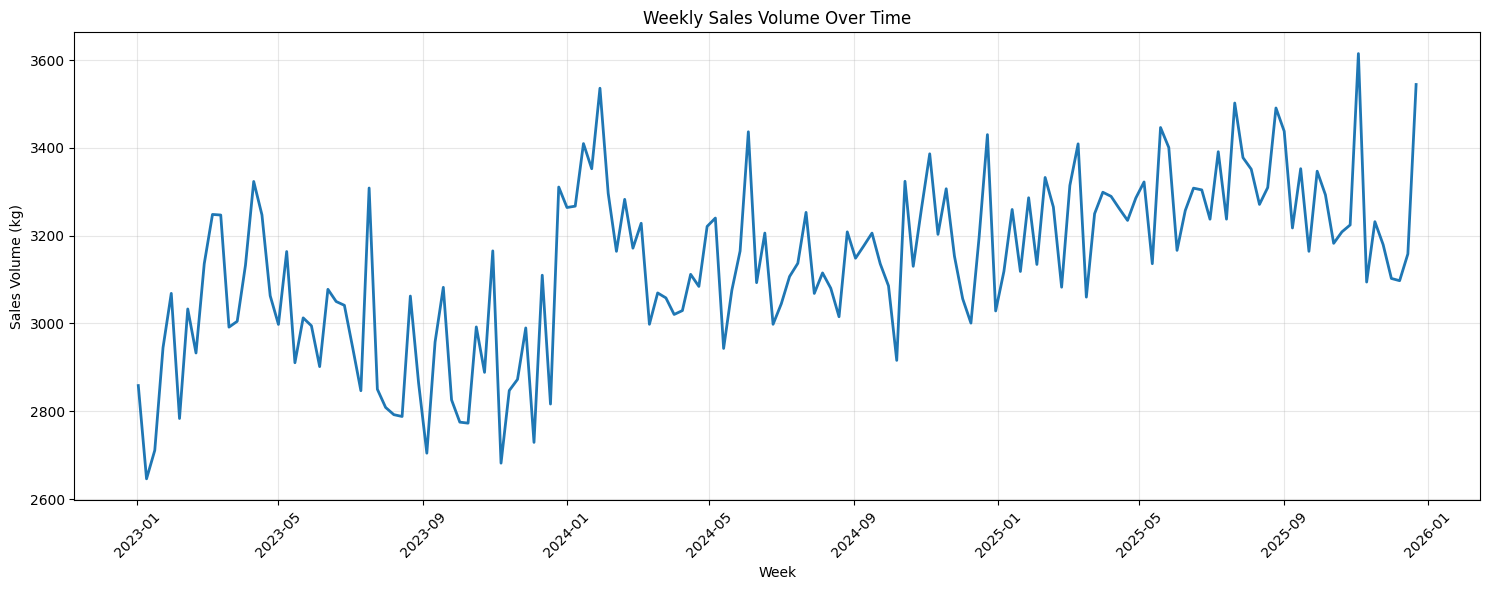

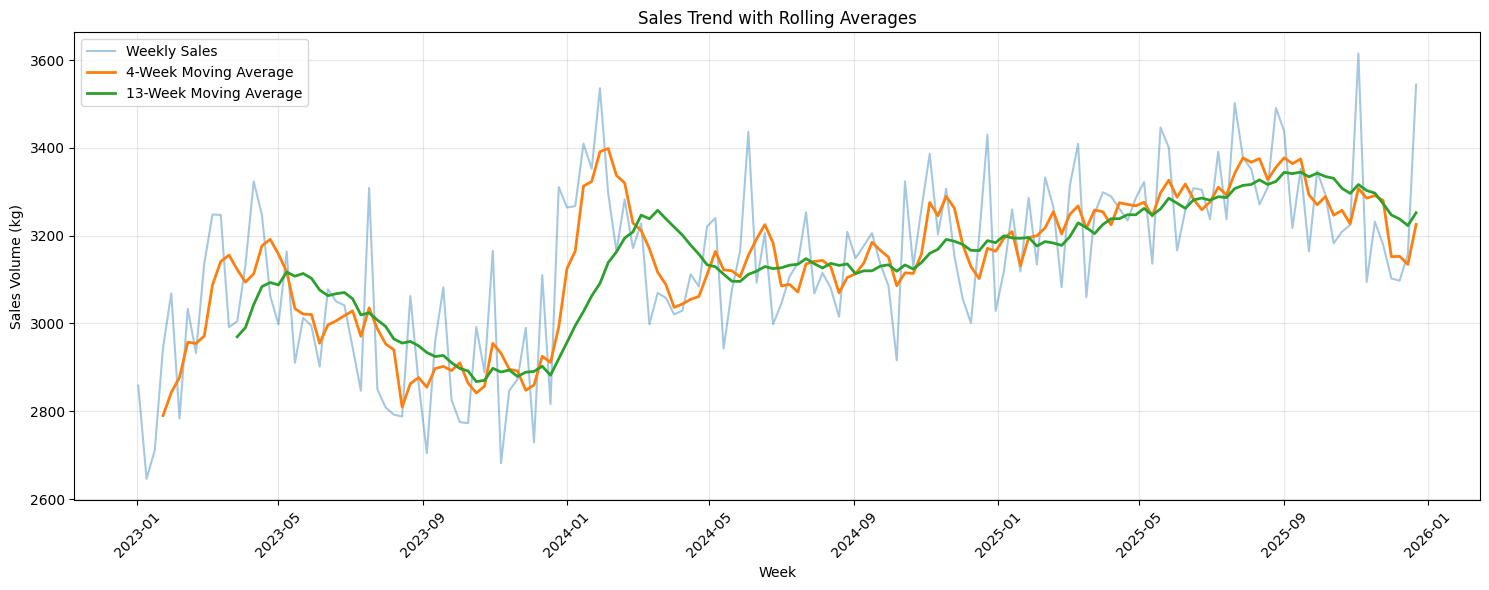

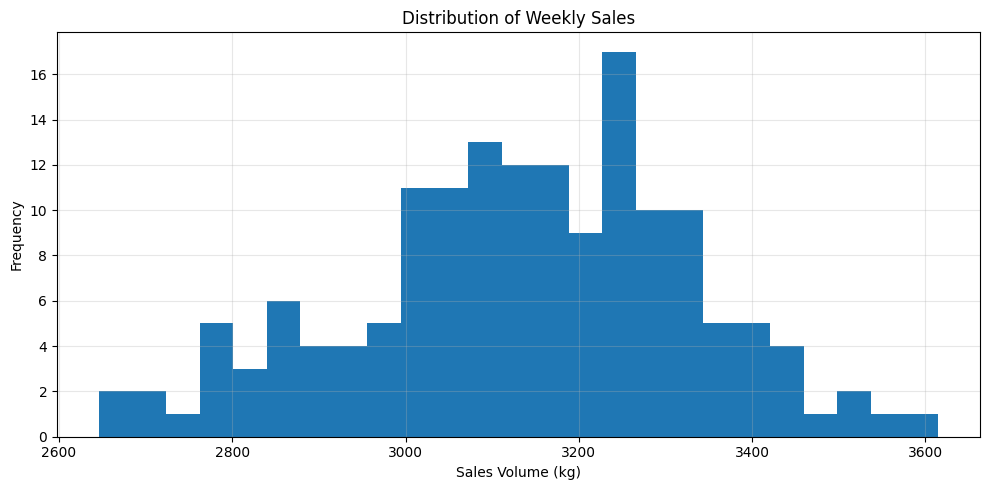

In [11]:
# ============================================================
# STEP 6B: SALES EDA
# ============================================================

sales_column = "Sales_Volume_kgs"


# ------------------------------------------------------------
# 1. Sales statistics
# ------------------------------------------------------------

sales_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Std Dev",
        "Minimum",
        "Maximum",
        "25th Percentile",
        "75th Percentile"
    ],

    "Value": [
        master_mmm_df[sales_column].mean(),
        master_mmm_df[sales_column].median(),
        master_mmm_df[sales_column].std(),
        master_mmm_df[sales_column].min(),
        master_mmm_df[sales_column].max(),
        master_mmm_df[sales_column].quantile(0.25),
        master_mmm_df[sales_column].quantile(0.75)
    ]
})


print("SALES SUMMARY")
print("=" * 80)

display(
    sales_stats.round(2)
)


# ------------------------------------------------------------
# 2. Sales coefficient of variation
# ------------------------------------------------------------

sales_mean = master_mmm_df[sales_column].mean()
sales_std = master_mmm_df[sales_column].std()

sales_cv = sales_std / sales_mean

print(
    f"Sales Coefficient of Variation: {sales_cv:.3f}"
)


# ------------------------------------------------------------
# 3. Sales over time
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    master_mmm_df["Week_Start"],
    master_mmm_df[sales_column],
    linewidth=2
)

plt.title("Weekly Sales Volume Over Time")
plt.xlabel("Week")
plt.ylabel("Sales Volume (kg)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Rolling sales statistics
# ------------------------------------------------------------

sales_rolling = master_mmm_df.copy()

sales_rolling["Sales_4W_MA"] = (
    sales_rolling[sales_column]
    .rolling(4)
    .mean()
)

sales_rolling["Sales_13W_MA"] = (
    sales_rolling[sales_column]
    .rolling(13)
    .mean()
)


plt.figure(figsize=(15, 6))

plt.plot(
    sales_rolling["Week_Start"],
    sales_rolling[sales_column],
    alpha=0.4,
    label="Weekly Sales"
)

plt.plot(
    sales_rolling["Week_Start"],
    sales_rolling["Sales_4W_MA"],
    linewidth=2,
    label="4-Week Moving Average"
)

plt.plot(
    sales_rolling["Week_Start"],
    sales_rolling["Sales_13W_MA"],
    linewidth=2,
    label="13-Week Moving Average"
)

plt.title("Sales Trend with Rolling Averages")
plt.xlabel("Week")
plt.ylabel("Sales Volume (kg)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Sales distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    master_mmm_df[sales_column],
    bins=25
)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Sales Volume (kg)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# STEP 6C: IDENTIFY MEDIA VARIABLES
# ============================================================

media_family_map = {

    "Print": [
        "Print_Gentle_Start",
        "Print_Moms_Trust"
    ],

    "TV": [
        "TV_Classic_Care_15s",
        "TV_Apollo_Gentle_Bath_20s",
        "TV_Motherbrand_Safest_Touch_15s",
        "TV_Soap_Core_Rejuvenate_15s"
    ],
    "Meta": [
        "Meta_First_Touch_Reach",
        "Meta_Gentle_Bath_Video",
        "Meta_Moms_Trust_Retargeting"
    ],

    "Instagram": [
        "Instagram_Baby_Bath_Reels",
        "Instagram_Mom_Creator_Stories",
        "Instagram_Gentle_Skin_Carousel"
    ],

    "YouTube": [
        "YouTube_Safest_Touch_15s",
        "YouTube_Gentle_Bath_20s",
        "YouTube_Mom_Stories_30s",
        "YouTube_Soap_Core_Bumper_6s"
    ]
}


all_media_variables = [
    variable
    for family_variables in media_family_map.values()
    for variable in family_variables
]


print("Total media variables:", len(all_media_variables))
print()

for family, variables in media_family_map.items():

    print(f"{family}: {len(variables)} variables")

    for variable in variables:
        print("   ", variable)

Total media variables: 16

Print: 2 variables
    Print_Gentle_Start
    Print_Moms_Trust
TV: 4 variables
    TV_Classic_Care_15s
    TV_Apollo_Gentle_Bath_20s
    TV_Motherbrand_Safest_Touch_15s
    TV_Soap_Core_Rejuvenate_15s
Meta: 3 variables
    Meta_First_Touch_Reach
    Meta_Gentle_Bath_Video
    Meta_Moms_Trust_Retargeting
Instagram: 3 variables
    Instagram_Baby_Bath_Reels
    Instagram_Mom_Creator_Stories
    Instagram_Gentle_Skin_Carousel
YouTube: 4 variables
    YouTube_Safest_Touch_15s
    YouTube_Gentle_Bath_20s
    YouTube_Mom_Stories_30s
    YouTube_Soap_Core_Bumper_6s


In [13]:
# ============================================================
# STEP 6D: MEDIA DESCRIPTIVE STATISTICS
# ============================================================

media_statistics = []


for family, variables in media_family_map.items():

    for variable in variables:

        series = media_input_scaled_df[variable]

        media_statistics.append({

            "Media_Family": family,

            "Media_Variable": variable,

            "Mean": series.mean(),

            "Median": series.median(),

            "Std_Dev": series.std(),

            "Minimum": series.min(),

            "Maximum": series.max(),

            "25th_Percentile": series.quantile(0.25),

            "75th_Percentile": series.quantile(0.75),

            "CV": (
                series.std() / series.mean()
                if series.mean() != 0
                else np.nan
            ),

            "Zero_Weeks": (
                series == 0
            ).sum(),

            "Zero_Week_Percent": (
                (series == 0).mean() * 100
            )

        })


media_statistics_df = pd.DataFrame(
    media_statistics
)


print("MEDIA DESCRIPTIVE STATISTICS")
print("=" * 170)

display(
    media_statistics_df
    .round(3)
)

MEDIA DESCRIPTIVE STATISTICS


,Media_Family,Media_Variable,Mean,Median,Std_Dev,Minimum,Maximum,25th_Percentile,75th_Percentile,CV,Zero_Weeks,Zero_Week_Percent
0,Print,Print_Gentle_Start,19953.583,0.0,49597.470,0.0,195122.000,0.0,0.000,2.486,133,85.256
1,Print,Print_Moms_Trust,36624.859,0.0,80812.634,0.0,302105.000,0.0,0.000,2.206,128,82.051
2,TV,TV_Classic_Care_15s,16.128,0.0,33.786,0.0,142.000,0.0,0.000,2.095,125,80.128
3,TV,TV_Apollo_Gentle_Bath_20s,15.846,0.0,36.347,0.0,161.000,0.0,0.000,2.294,128,82.051
4,TV,TV_Motherbrand_Safest_Touch_15s,16.744,0.0,30.847,0.0,111.000,0.0,0.000,1.842,118,75.641
5,TV,TV_Soap_Core_Rejuvenate_15s,20.615,0.0,41.496,0.0,145.000,0.0,0.000,2.013,123,78.846
6,Meta,Meta_First_Touch_Reach,9955.472,0.0,21230.393,0.0,95837.695,0.0,0.000,2.133,122,78.205
7,Meta,Meta_Gentle_Bath_Video,11945.721,0.0,20659.663,0.0,72398.742,0.0,27858.361,1.729,114,73.077
8,Meta,Meta_Moms_Trust_Retargeting,11423.384,0.0,23963.559,0.0,99317.774,0.0,0.000,2.098,123,78.846
9,Instagram,Instagram_Baby_Bath_Reels,18973.181,0.0,35339.942,0.0,165537.945,0.0,11013.193,1.863,117,75.000


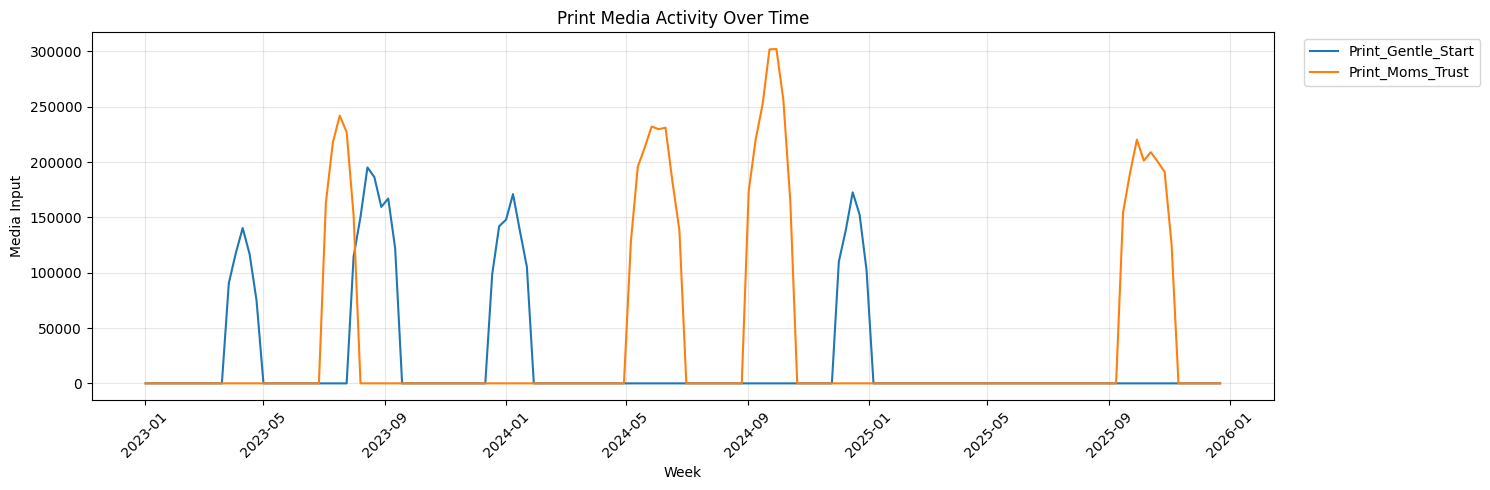

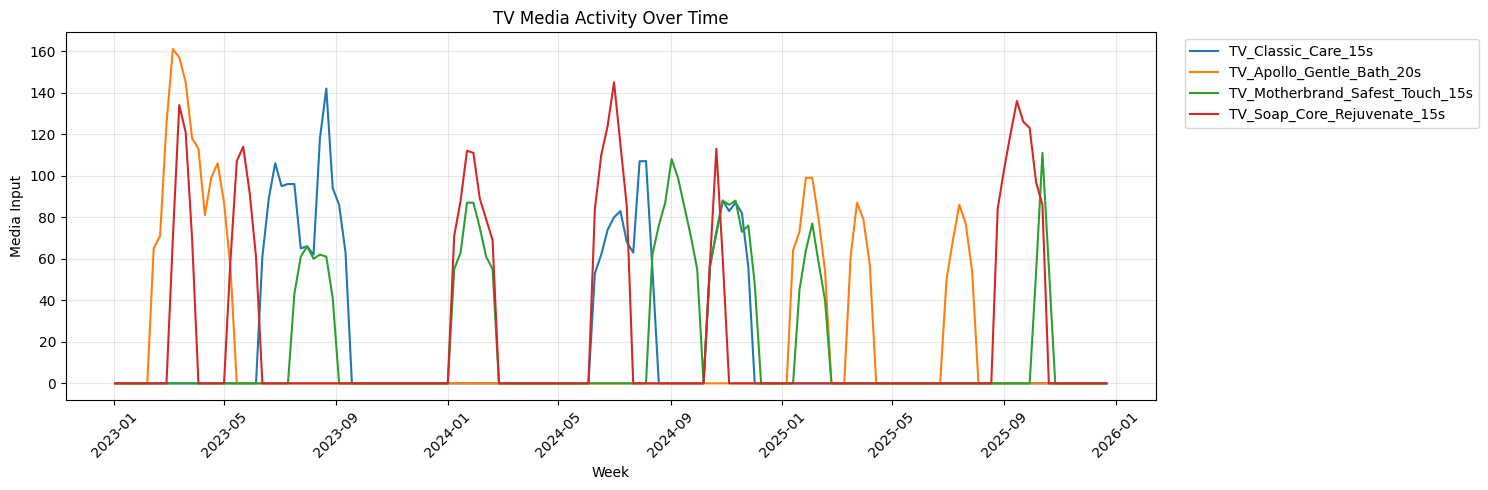

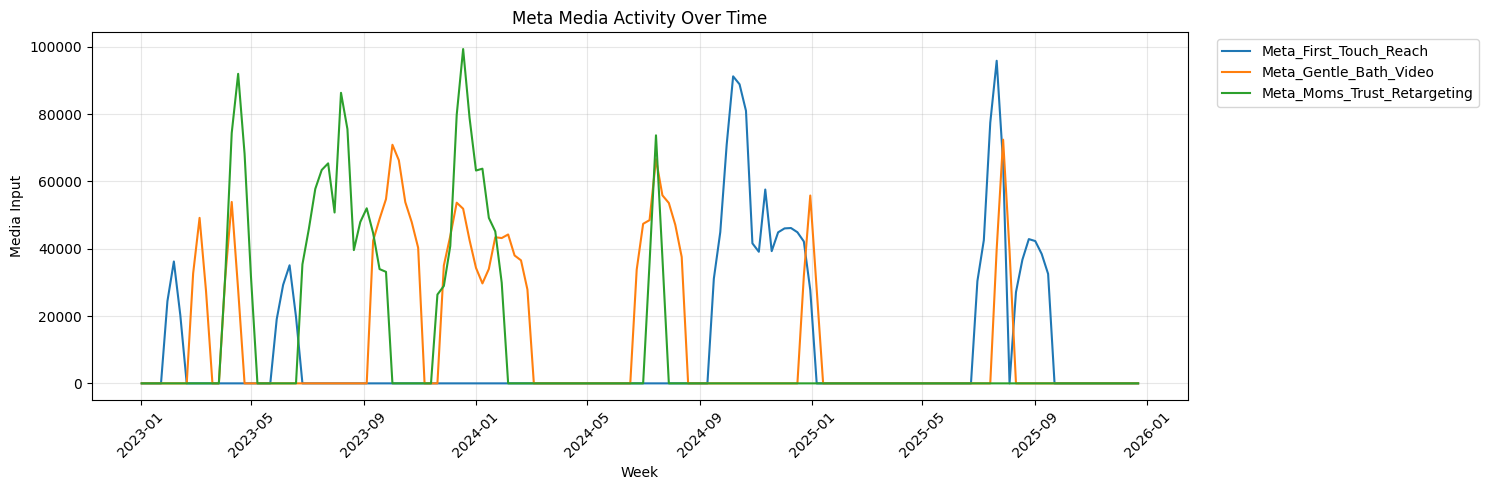

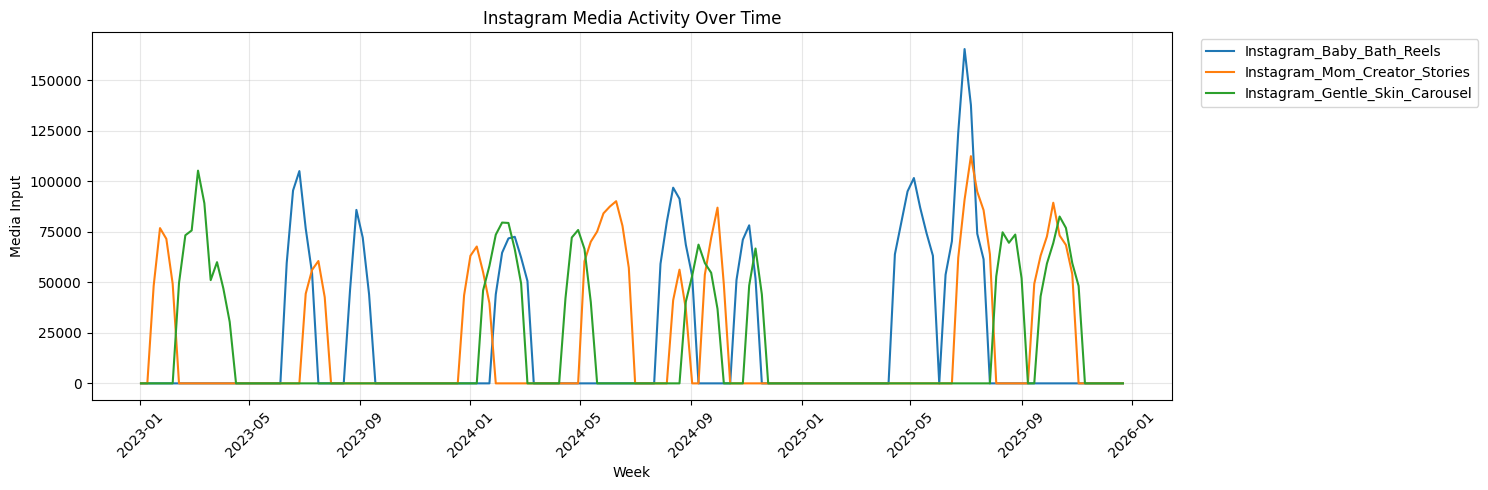

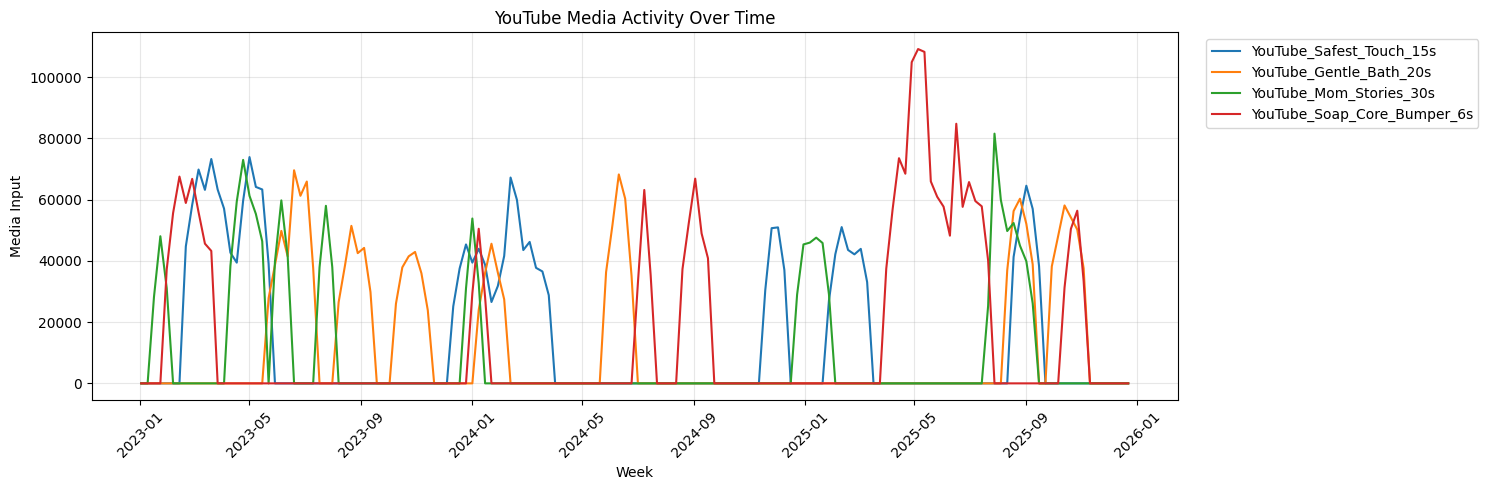

In [14]:
# ============================================================
# STEP 6E: MEDIA ACTIVITY OVER TIME
# ============================================================

for family, variables in media_family_map.items():

    plt.figure(figsize=(15, 5))

    for variable in variables:

        plt.plot(
            media_input_scaled_df["Week_Start"],
            media_input_scaled_df[variable],
            label=variable
        )

    plt.title(
        f"{family} Media Activity Over Time"
    )

    plt.xlabel("Week")
    plt.ylabel("Media Input")

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.xticks(rotation=45)

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

MEDIA ZERO-ACTIVITY ANALYSIS


,Media_Family,Media_Variable,Zero_Weeks,Zero_Week_Percent
0,Print,Print_Gentle_Start,133,85.256410
1,Print,Print_Moms_Trust,128,82.051282
3,TV,TV_Apollo_Gentle_Bath_20s,128,82.051282
2,TV,TV_Classic_Care_15s,125,80.128205
14,YouTube,YouTube_Mom_Stories_30s,124,79.487179
5,TV,TV_Soap_Core_Rejuvenate_15s,123,78.846154
8,Meta,Meta_Moms_Trust_Retargeting,123,78.846154
6,Meta,Meta_First_Touch_Reach,122,78.205128
4,TV,TV_Motherbrand_Safest_Touch_15s,118,75.641026
9,Instagram,Instagram_Baby_Bath_Reels,117,75.000000


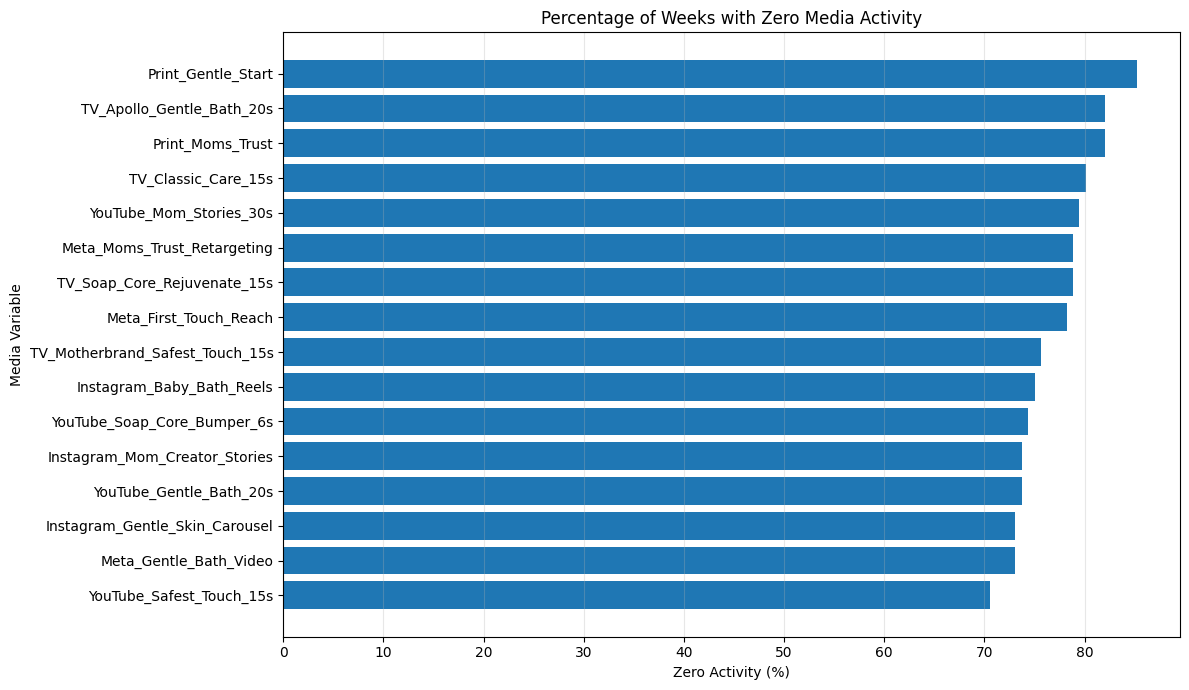

In [15]:
# ============================================================
# STEP 6F: MEDIA ZERO-ACTIVITY ANALYSIS
# ============================================================

zero_activity_df = (
    media_statistics_df[
        [
            "Media_Family",
            "Media_Variable",
            "Zero_Weeks",
            "Zero_Week_Percent"
        ]
    ]
    .sort_values(
        "Zero_Week_Percent",
        ascending=False
    )
)


print("MEDIA ZERO-ACTIVITY ANALYSIS")
print("=" * 80)

display(
    zero_activity_df
)


# ------------------------------------------------------------
# Plot zero-week percentage
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plot_data = (
    zero_activity_df
    .sort_values("Zero_Week_Percent")
)

plt.barh(
    plot_data["Media_Variable"],
    plot_data["Zero_Week_Percent"]
)

plt.title(
    "Percentage of Weeks with Zero Media Activity"
)

plt.xlabel("Zero Activity (%)")
plt.ylabel("Media Variable")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# STEP 6G: MEDIA VARIABILITY ANALYSIS
# ============================================================

variability_df = (
    media_statistics_df[
        [
            "Media_Family",
            "Media_Variable",
            "Mean",
            "Std_Dev",
            "CV",
            "Minimum",
            "Maximum"
        ]
    ]
    .sort_values(
        "CV",
        ascending=True
    )
)


print("MEDIA VARIABILITY")
print("=" * 90)

display(
    variability_df.round(3)
)

MEDIA VARIABILITY


,Media_Family,Media_Variable,Mean,Std_Dev,CV,Minimum,Maximum
12,YouTube,YouTube_Safest_Touch_15s,13906.159,22696.349,1.632,0.0,73920.272
11,Instagram,Instagram_Gentle_Skin_Carousel,16453.165,28400.132,1.726,0.0,105323.452
7,Meta,Meta_Gentle_Bath_Video,11945.721,20659.663,1.729,0.0,72398.742
10,Instagram,Instagram_Mom_Creator_Stories,17300.183,30425.493,1.759,0.0,112494.205
13,YouTube,YouTube_Gentle_Bath_20s,11445.968,20223.624,1.767,0.0,69598.154
4,TV,TV_Motherbrand_Safest_Touch_15s,16.744,30.847,1.842,0.0,111.000
15,YouTube,YouTube_Soap_Core_Bumper_6s,14396.295,26544.828,1.844,0.0,109200.742
9,Instagram,Instagram_Baby_Bath_Reels,18973.181,35339.942,1.863,0.0,165537.945
5,TV,TV_Soap_Core_Rejuvenate_15s,20.615,41.496,2.013,0.0,145.000
14,YouTube,YouTube_Mom_Stories_30s,9335.295,19417.080,2.080,0.0,81567.602


In [17]:
# ============================================================
# STEP 6H: SALES VS MEDIA CORRELATION
# ============================================================

sales_media_correlation = []

for family, variables in media_family_map.items():

    for variable in variables:

        correlation = (
            master_mmm_df[sales_column]
            .corr(
                media_input_scaled_df[variable]
            )
        )

        sales_media_correlation.append({

            "Media_Family": family,

            "Media_Variable": variable,

            "Sales_Correlation": correlation

        })


sales_media_corr_df = pd.DataFrame(
    sales_media_correlation
)


sales_media_corr_df = (
    sales_media_corr_df
    .sort_values(
        "Sales_Correlation",
        ascending=False
    )
)


print("SALES VS MEDIA CORRELATION")
print("=" * 80)

display(
    sales_media_corr_df.round(3)
)

SALES VS MEDIA CORRELATION


,Media_Family,Media_Variable,Sales_Correlation
11,Instagram,Instagram_Gentle_Skin_Carousel,0.290
15,YouTube,YouTube_Soap_Core_Bumper_6s,0.236
6,Meta,Meta_First_Touch_Reach,0.182
5,TV,TV_Soap_Core_Rejuvenate_15s,0.161
12,YouTube,YouTube_Safest_Touch_15s,0.157
9,Instagram,Instagram_Baby_Bath_Reels,0.148
10,Instagram,Instagram_Mom_Creator_Stories,0.130
4,TV,TV_Motherbrand_Safest_Touch_15s,0.125
3,TV,TV_Apollo_Gentle_Bath_20s,0.120
14,YouTube,YouTube_Mom_Stories_30s,0.070


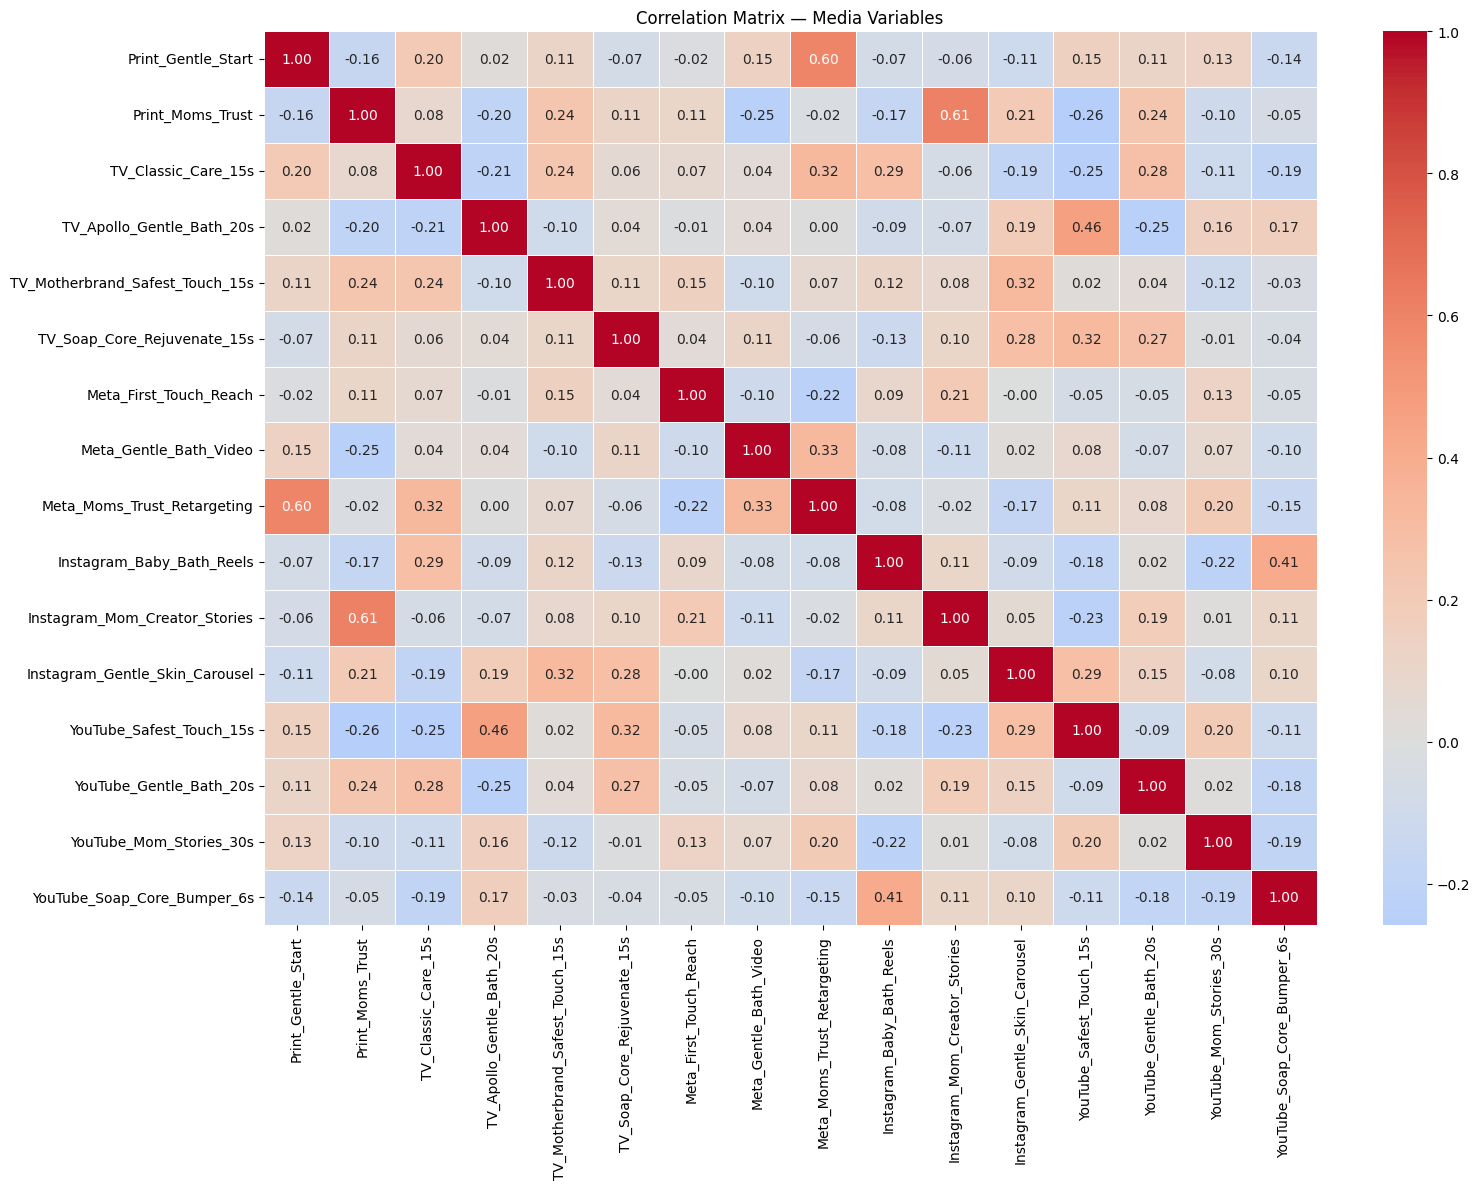

In [18]:
# ============================================================
# STEP 6I: MEDIA CORRELATION MATRIX
# ============================================================

media_for_corr = media_input_scaled_df[
    all_media_variables
].copy()


media_corr_matrix = (
    media_for_corr
    .corr()
)


plt.figure(figsize=(16, 12))

sns.heatmap(
    media_corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix — Media Variables"
)

plt.tight_layout()
plt.show()

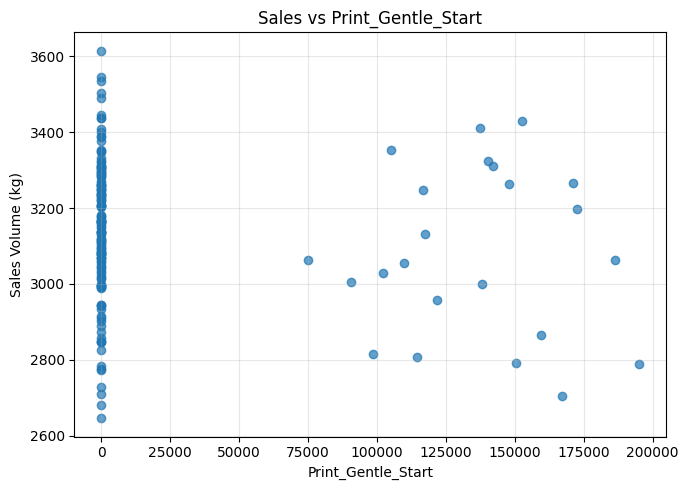

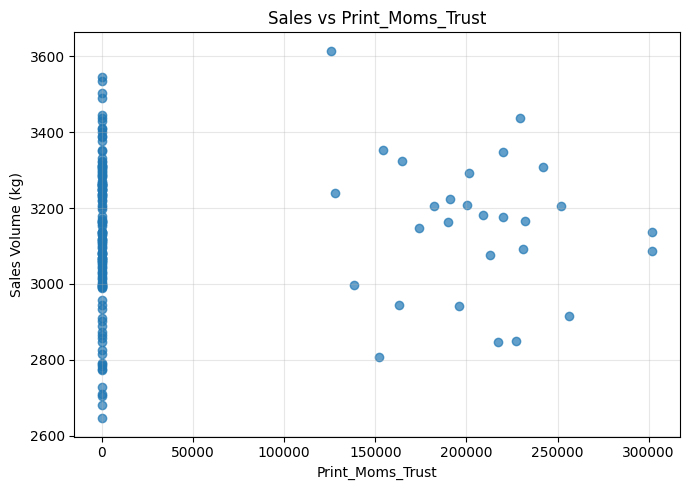

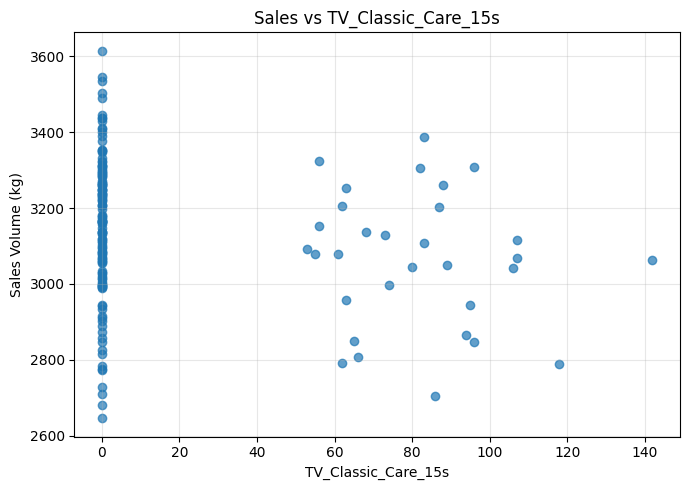

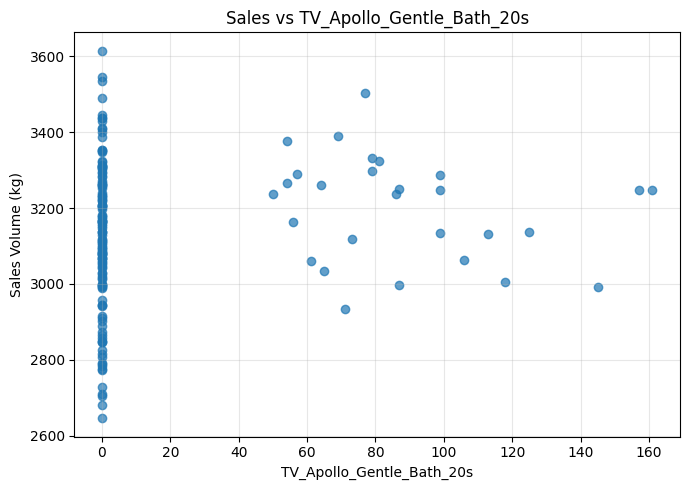

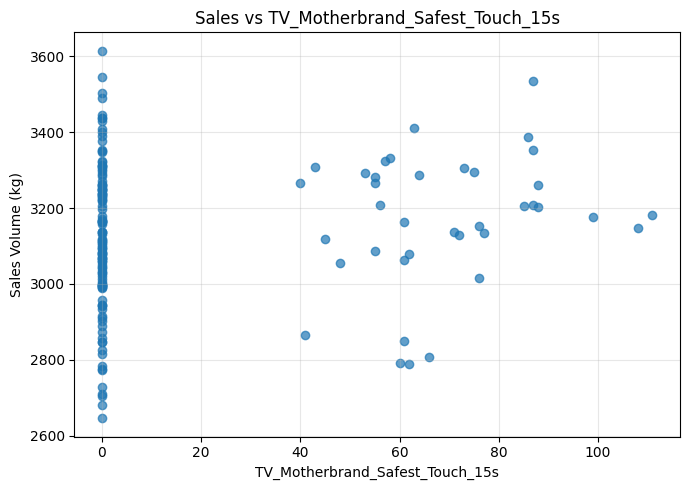

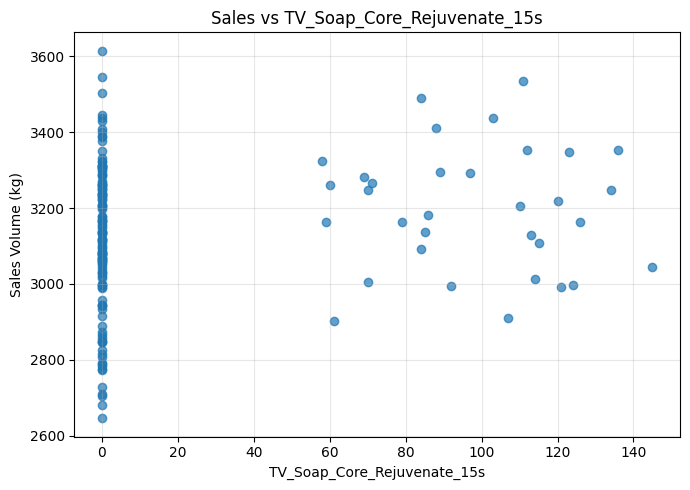

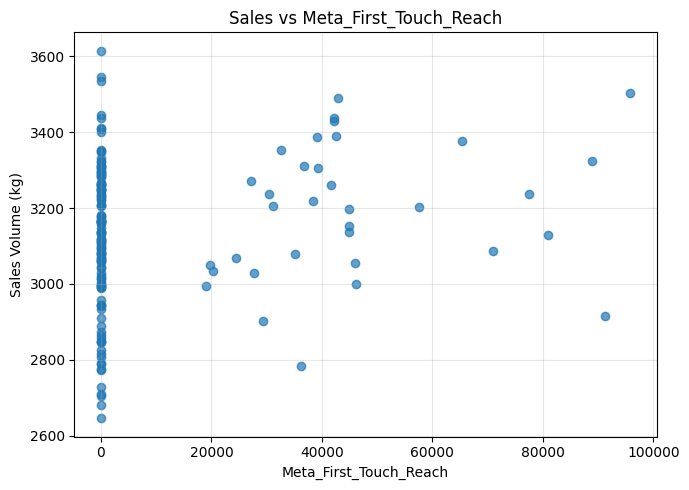

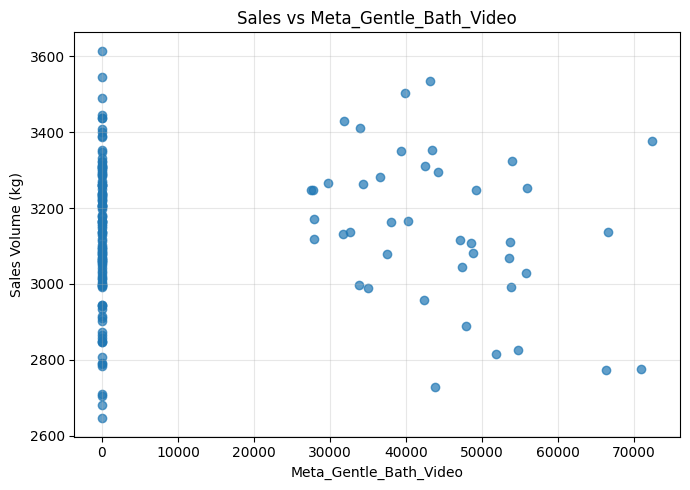

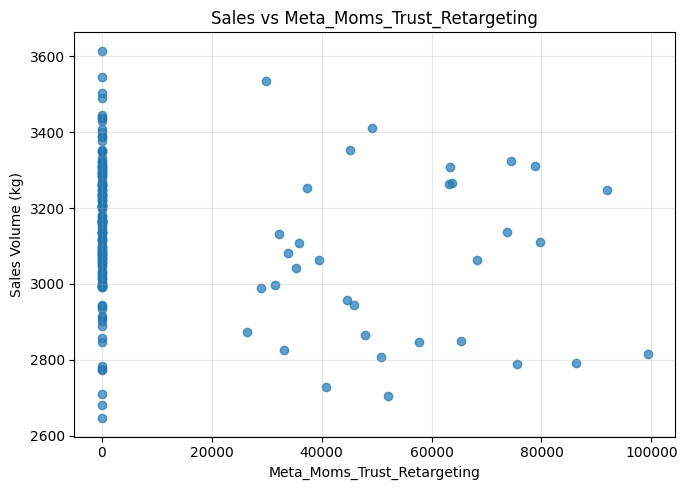

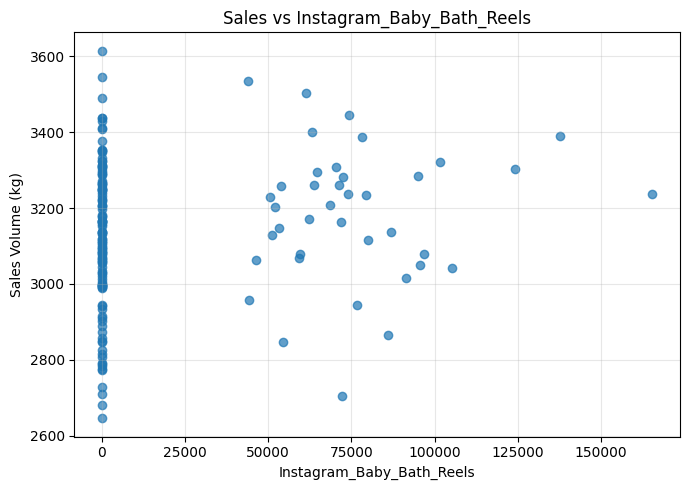

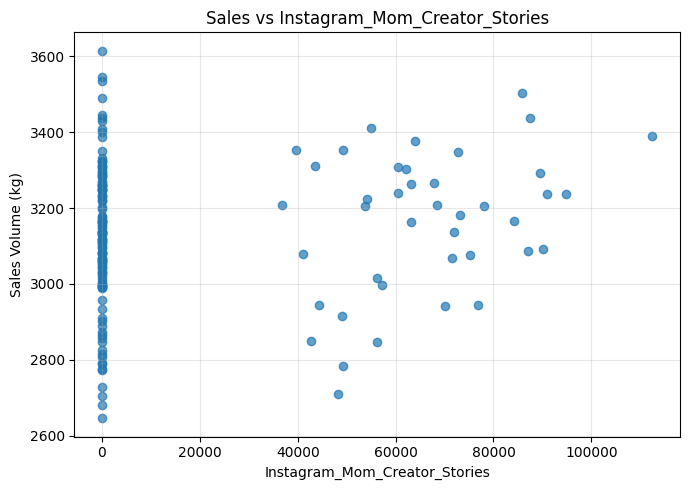

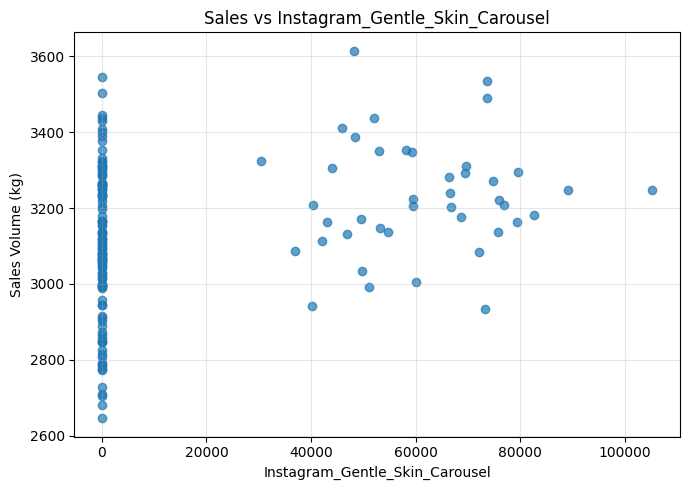

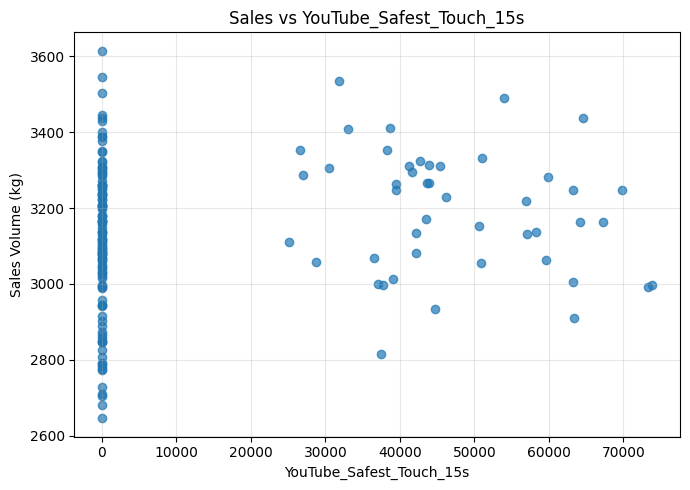

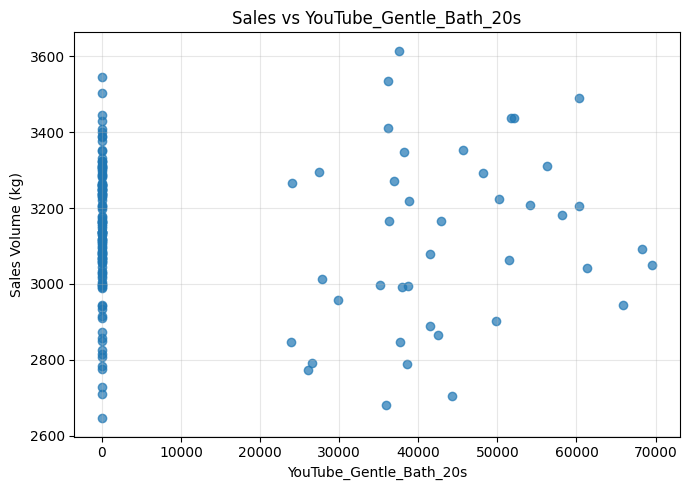

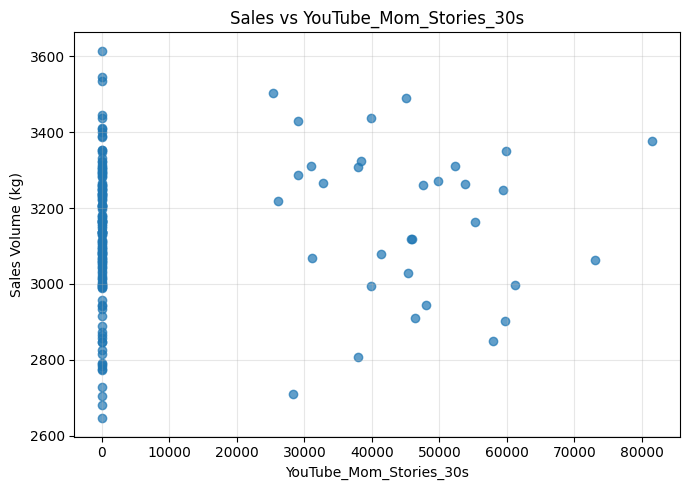

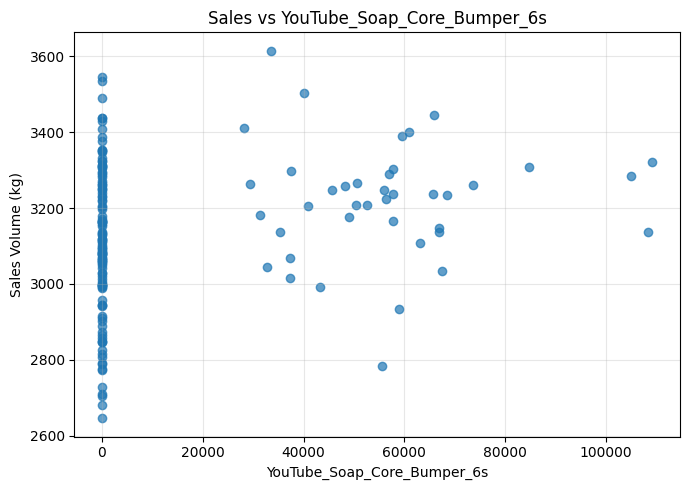

In [19]:
# ============================================================
# STEP 6J: SALES VS MEDIA SCATTERPLOTS
# ============================================================

for variable in all_media_variables:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        media_input_scaled_df[variable],
        master_mmm_df[sales_column],
        alpha=0.7
    )

    plt.title(
        f"Sales vs {variable}"
    )

    plt.xlabel(variable)
    plt.ylabel("Sales Volume (kg)")

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

In [20]:
# ============================================================
# STEP 6K: PROMOTION EDA
# ============================================================

promo_columns = [
    col
    for col in promo_master.columns
    if col not in ["Week", "Week_Start"]
]


print("PROMOTION VARIABLES")
print("=" * 80)

for col in promo_columns:
    print(col)


# ------------------------------------------------------------
# Promotion statistics
# ------------------------------------------------------------

promo_statistics = []


for col in promo_columns:

    promo_statistics.append({

        "Promotion": col,

        "Mean": promo_master[col].mean(),

        "Active_Weeks": (
            promo_master[col] > 0
        ).sum(),

        "Active_Week_Percent": (
            (promo_master[col] > 0).mean()
            * 100
        ),

        "Maximum": promo_master[col].max()

    })


promo_statistics_df = pd.DataFrame(
    promo_statistics
)


print("\nPROMOTION SUMMARY")
print("=" * 80)

display(
    promo_statistics_df.round(3)
)

PROMOTION VARIABLES
Holiday_Diwali
Holiday_Holi
Holiday_Christmas
Promotion_Price_Off_10pct
Promotion_Buy2_Save15pct
TradePromo_Retailer_Display
TradePromo_Distributor_Scheme

PROMOTION SUMMARY


,Promotion,Mean,Active_Weeks,Active_Week_Percent,Maximum
0,Holiday_Diwali,0.019,3,1.923,1
1,Holiday_Holi,0.019,3,1.923,1
2,Holiday_Christmas,0.038,6,3.846,1
3,Promotion_Price_Off_10pct,0.090,14,8.974,1
4,Promotion_Buy2_Save15pct,0.077,12,7.692,1
5,TradePromo_Retailer_Display,0.115,18,11.538,1
6,TradePromo_Distributor_Scheme,0.077,12,7.692,1


PRICE SUMMARY


,Price
count,156.00
mean,248.40
std,28.05
min,200.00
25%,226.00
50%,247.50
75%,273.25
max,298.00


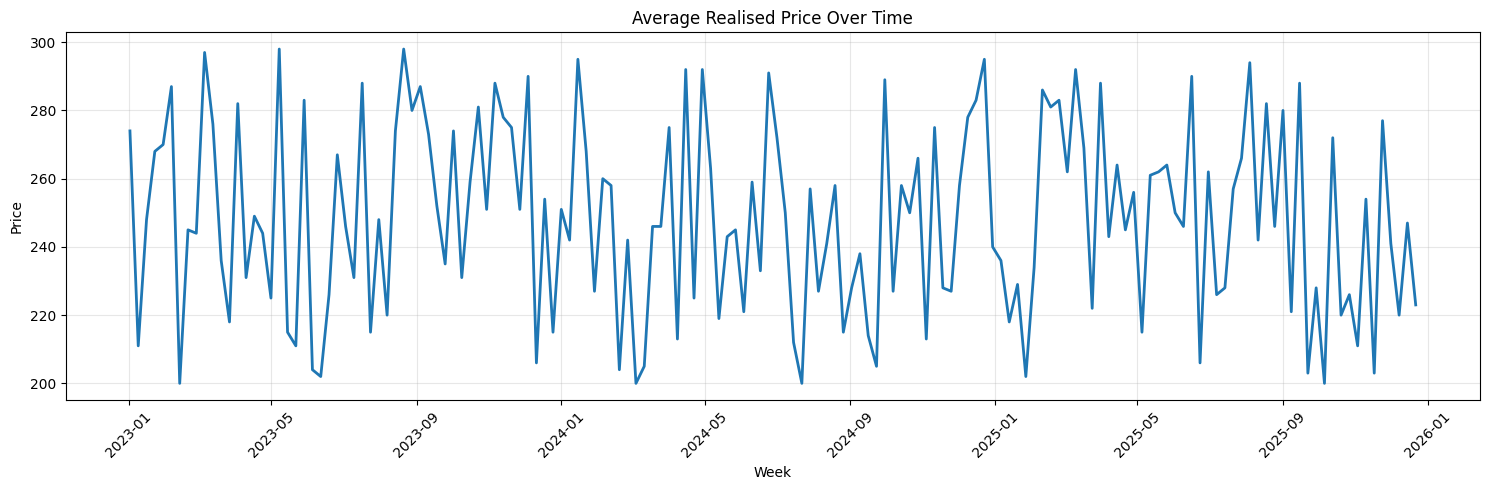

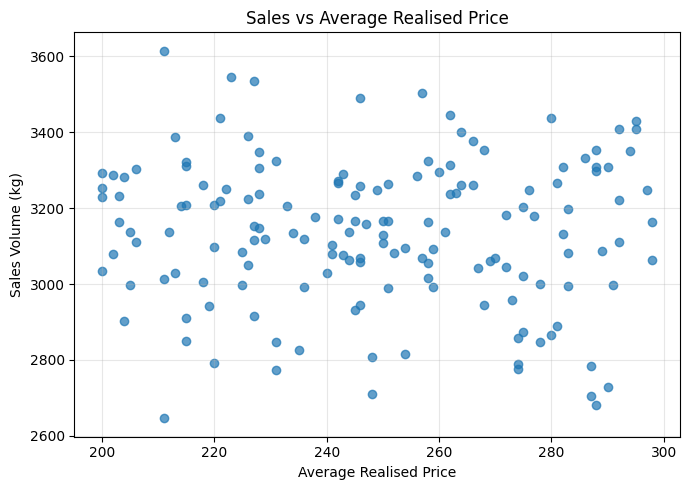

In [21]:
# ============================================================
# STEP 6L: PRICE EDA
# ============================================================

price_column = "AVG_Price_Per_kgs"

if price_column in master_mmm_df.columns:

    price_stats = master_mmm_df[
        price_column
    ].describe()

    print("PRICE SUMMARY")
    print("=" * 80)

    display(
        price_stats.to_frame(
            "Price"
        ).round(2)
    )


    # Price over time

    plt.figure(figsize=(15, 5))

    plt.plot(
        master_mmm_df["Week_Start"],
        master_mmm_df[price_column],
        linewidth=2
    )

    plt.title(
        "Average Realised Price Over Time"
    )

    plt.xlabel("Week")
    plt.ylabel("Price")

    plt.xticks(rotation=45)

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


    # Price vs Sales

    plt.figure(figsize=(7, 5))

    plt.scatter(
        master_mmm_df[price_column],
        master_mmm_df[sales_column],
        alpha=0.7
    )

    plt.title(
        "Sales vs Average Realised Price"
    )

    plt.xlabel("Average Realised Price")
    plt.ylabel("Sales Volume (kg)")

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        f"{price_column} was not found in the Master MMM dataset."
    )

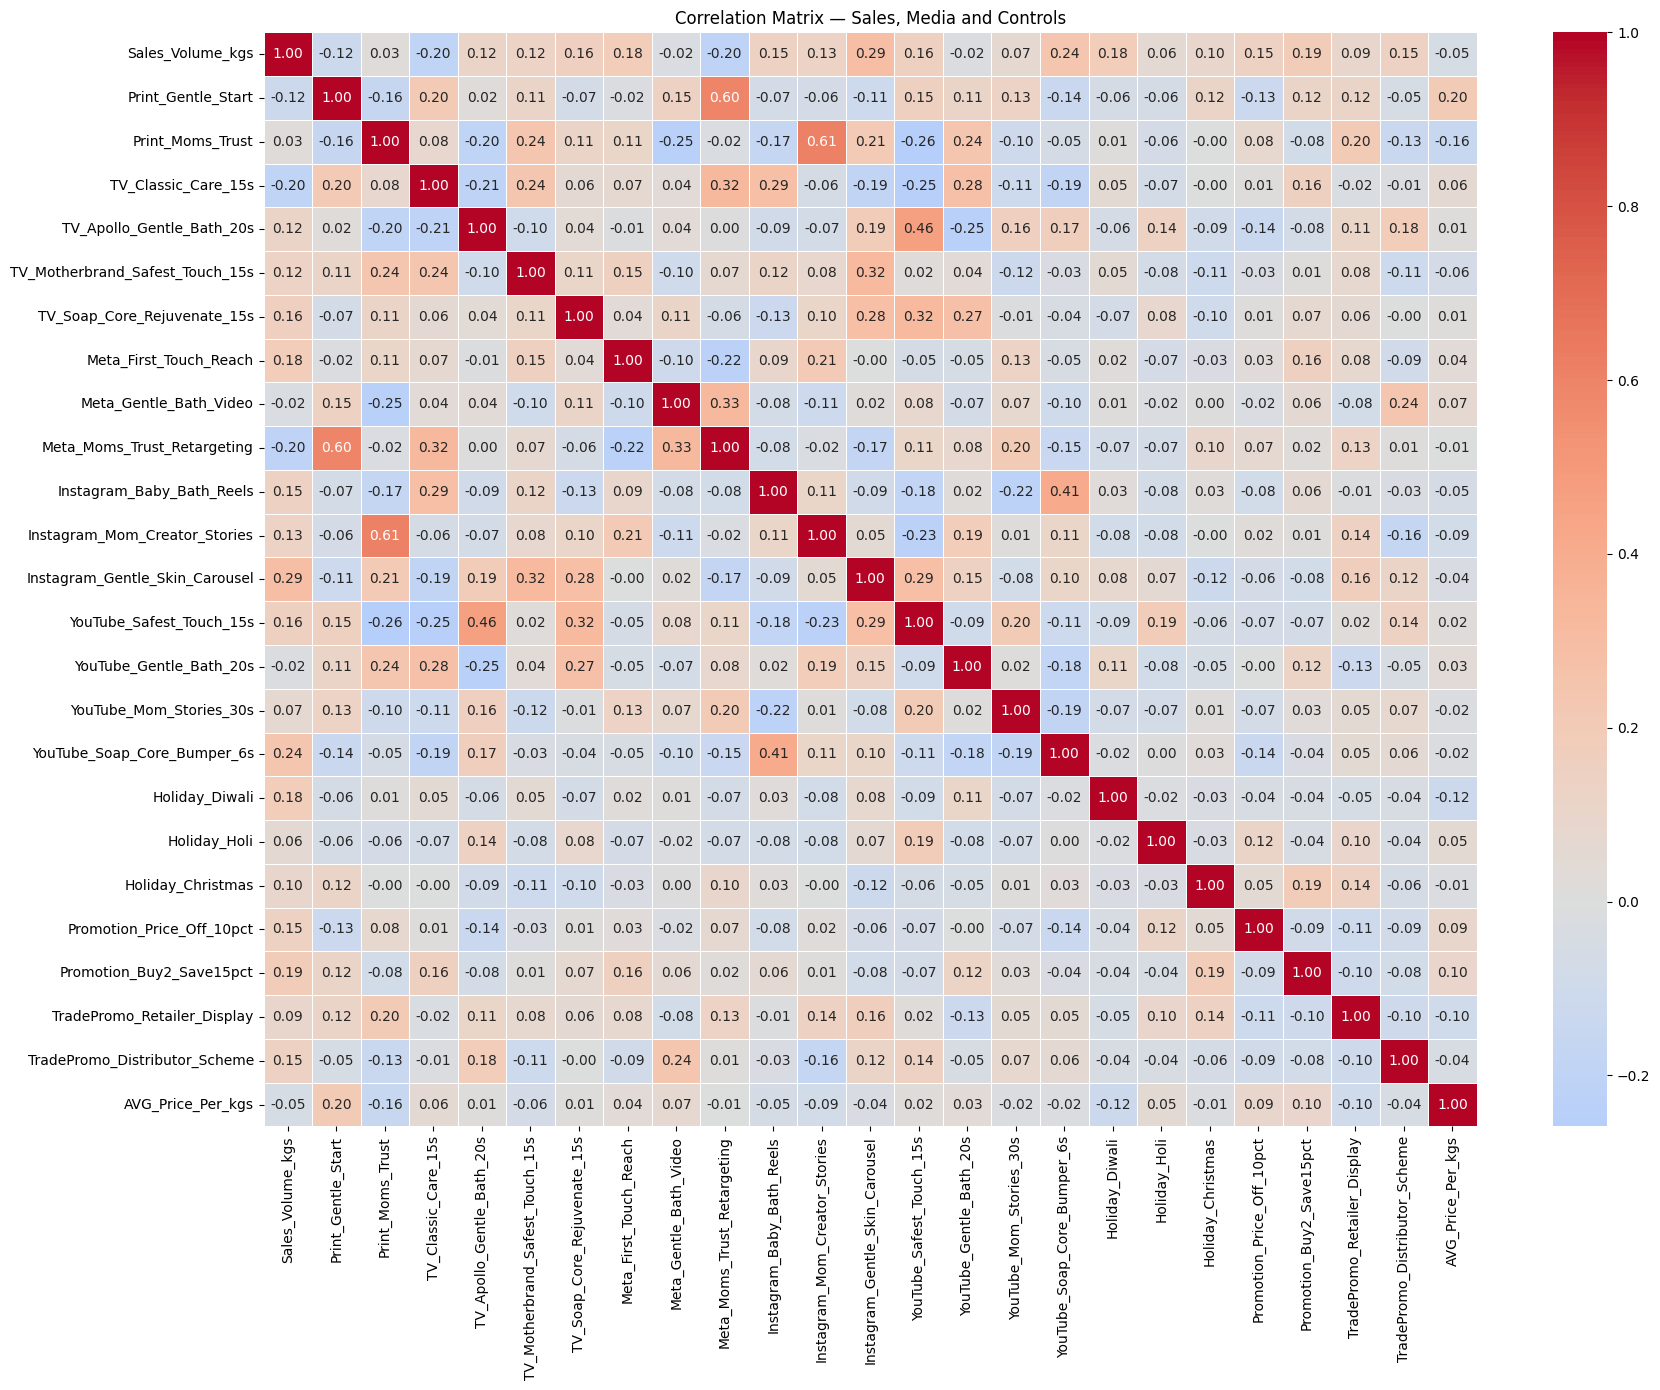

In [22]:
# ============================================================
# STEP 6M: SALES + MEDIA + CONTROLS CORRELATION
# ============================================================

correlation_columns = [
    sales_column
]

correlation_columns += all_media_variables

correlation_columns += [
    col
    for col in promo_columns
    if col in master_mmm_df.columns
]

if price_column in master_mmm_df.columns:

    correlation_columns.append(
        price_column
    )


correlation_df = master_mmm_df[
    correlation_columns
].copy()

# Replace media columns with the scaled versions
for variable in all_media_variables:

    correlation_df[variable] = (
        media_input_scaled_df[variable]
    )


correlation_matrix = correlation_df.corr()


plt.figure(
    figsize=(18, 14)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix — Sales, Media and Controls"
)

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# STEP 6N: OUTLIER IDENTIFICATION USING IQR
# ============================================================

def iqr_outlier_summary(df, columns):

    records = []

    for col in columns:

        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        iqr = q3 - q1

        lower_bound = (
            q1 - 1.5 * iqr
        )

        upper_bound = (
            q3 + 1.5 * iqr
        )

        outlier_mask = (
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        )

        records.append({

            "Variable": col,

            "Q1": q1,

            "Q3": q3,

            "IQR": iqr,

            "Lower_Bound": lower_bound,

            "Upper_Bound": upper_bound,

            "Outlier_Count": outlier_mask.sum(),

            "Outlier_Percent": (
                outlier_mask.mean() * 100
            )

        })

    return pd.DataFrame(records)


outlier_summary_df = iqr_outlier_summary(
    correlation_df,
    correlation_df.columns
)


print("OUTLIER SUMMARY")
print("=" * 100)

display(
    outlier_summary_df
    .sort_values(
        "Outlier_Percent",
        ascending=False
    )
    .round(3)
)

OUTLIER SUMMARY


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
10,Instagram_Baby_Bath_Reels,0.0,11013.193,11013.193,-16519.790,27532.983,39,25.000
5,TV_Motherbrand_Safest_Touch_15s,0.0,0.000,0.000,0.000,0.000,38,24.359
7,Meta_First_Touch_Reach,0.0,0.000,0.000,0.000,0.000,34,21.795
9,Meta_Moms_Trust_Retargeting,0.0,0.000,0.000,0.000,0.000,33,21.154
6,TV_Soap_Core_Rejuvenate_15s,0.0,0.000,0.000,0.000,0.000,33,21.154
15,YouTube_Mom_Stories_30s,0.0,0.000,0.000,0.000,0.000,32,20.513
3,TV_Classic_Care_15s,0.0,0.000,0.000,0.000,0.000,31,19.872
4,TV_Apollo_Gentle_Bath_20s,0.0,0.000,0.000,0.000,0.000,28,17.949
2,Print_Moms_Trust,0.0,0.000,0.000,0.000,0.000,28,17.949
1,Print_Gentle_Start,0.0,0.000,0.000,0.000,0.000,23,14.744


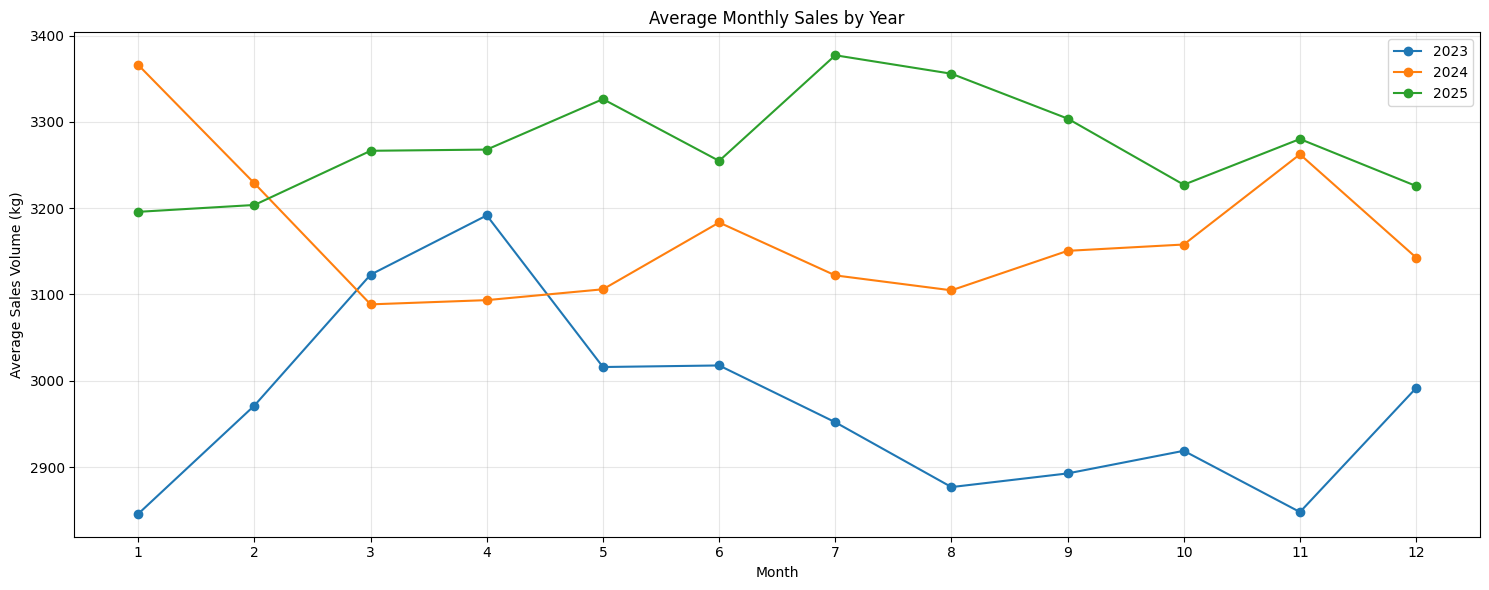


AVERAGE SALES BY QUARTER


,Year,Quarter,Sales_Volume_kgs
0,2023,1,2969.70
1,2023,2,3070.52
2,2023,3,2910.54
3,2023,4,2919.35
4,2024,1,3238.31
5,2024,2,3124.95
6,2024,3,3127.29
7,2024,4,3184.19
8,2025,1,3225.38
9,2025,2,3280.81


In [24]:
# ============================================================
# STEP 6O: SEASONALITY INSPECTION
# ============================================================

eda_time_df = master_mmm_df[
    [
        "Week",
        "Week_Start",
        sales_column
    ]
].copy()


eda_time_df["Year"] = (
    eda_time_df["Week_Start"]
    .dt.year
)

eda_time_df["Month"] = (
    eda_time_df["Week_Start"]
    .dt.month
)

eda_time_df["Month_Name"] = (
    eda_time_df["Week_Start"]
    .dt.month_name()
)

eda_time_df["Quarter"] = (
    eda_time_df["Week_Start"]
    .dt.quarter
)

eda_time_df["Week_of_Year"] = (
    eda_time_df["Week_Start"]
    .dt.isocalendar()
    .week
    .astype(int)
)


# ------------------------------------------------------------
# Monthly sales
# ------------------------------------------------------------

monthly_sales = (
    eda_time_df
    .groupby(
        ["Year", "Month"]
    )[sales_column]
    .mean()
    .reset_index()
)


plt.figure(figsize=(15, 6))

for year in monthly_sales["Year"].unique():

    year_data = monthly_sales[
        monthly_sales["Year"] == year
    ]

    plt.plot(
        year_data["Month"],
        year_data[sales_column],
        marker="o",
        label=str(year)
    )


plt.title(
    "Average Monthly Sales by Year"
)

plt.xlabel("Month")
plt.ylabel("Average Sales Volume (kg)")

plt.xticks(
    range(1, 13)
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Quarter-level sales
# ------------------------------------------------------------

quarter_sales = (
    eda_time_df
    .groupby(
        ["Year", "Quarter"]
    )[sales_column]
    .mean()
    .reset_index()
)


print("\nAVERAGE SALES BY QUARTER")
print("=" * 80)

display(
    quarter_sales.round(2)
)

In [25]:
# ============================================================
# STEP 6P: SAVE EDA OUTPUTS
# ============================================================

eda_output_folder = output_folder / "EDA"

eda_output_folder.mkdir(
    parents=True,
    exist_ok=True
)


media_statistics_df.to_csv(
    eda_output_folder /
    "media_descriptive_statistics.csv",
    index=False
)

sales_media_corr_df.to_csv(
    eda_output_folder /
    "sales_media_correlations.csv",
    index=False
)

media_corr_matrix.to_csv(
    eda_output_folder /
    "media_correlation_matrix.csv"
)

promo_statistics_df.to_csv(
    eda_output_folder /
    "promotion_statistics.csv",
    index=False
)

outlier_summary_df.to_csv(
    eda_output_folder /
    "outlier_summary.csv",
    index=False
)

quarter_sales.to_csv(
    eda_output_folder /
    "quarterly_sales_summary.csv",
    index=False
)

print(
    f"EDA outputs saved to: {eda_output_folder}"
)

EDA outputs saved to: /content/mmm_outputs/EDA


In [26]:
# ============================================================
# STEP 6Q: AUTOMATED EDA ISSUE FLAGGING
# ============================================================



# ============================================================
# 1. DEFINE MEDIA VARIABLES
# ============================================================

media_family_map = {

    "Print": [
        "Print_Gentle_Start",
        "Print_Moms_Trust"
    ],

    "TV": [
        "TV_Classic_Care_15s",
        "TV_Apollo_Gentle_Bath_20s",
        "TV_Motherbrand_Safest_Touch_15s",
        "TV_Soap_Core_Rejuvenate_15s"
    ],

    "Meta": [
        "Meta_First_Touch_Reach",
        "Meta_Gentle_Bath_Video",
        "Meta_Moms_Trust_Retargeting"
    ],

    "Instagram": [
        "Instagram_Baby_Bath_Reels",
        "Instagram_Mom_Creator_Stories",
        "Instagram_Gentle_Skin_Carousel"
    ],

    "YouTube": [
        "YouTube_Safest_Touch_15s",
        "YouTube_Gentle_Bath_20s",
        "YouTube_Mom_Stories_30s",
        "YouTube_Soap_Core_Bumper_6s"
    ]
}


# Flatten media variables into one list
media_cols = [
    variable
    for variables in media_family_map.values()
    for variable in variables
]


# ============================================================
# 2. DEFINE PROMOTION VARIABLES
# ============================================================

promo_cols = [
    col
    for col in promo_df.columns
    if col not in ["Week", "Week_Start"]
]


# ============================================================
# 3. SAFETY CHECKS
# ============================================================

missing_media = [
    col
    for col in media_cols
    if col not in media_input_scaled_df.columns
]

if missing_media:

    raise KeyError(
        "These media variables are missing from "
        "media_input_scaled_df:\n"
        + "\n".join(missing_media)
    )


missing_promo = [
    col
    for col in promo_cols
    if col not in promo_df.columns
]

if missing_promo:

    raise KeyError(
        "These promotion variables are missing from "
        "promo_df:\n"
        + "\n".join(missing_promo)
    )


# ============================================================
# 4. ALIGN MASTER DATASETS
# ============================================================

# Use Week as the common key

sales_c = (
    sales_df_clean
    .sort_values("Week")
    .reset_index(drop=True)
)

media_c = (
    media_input_scaled_df
    .sort_values("Week")
    .reset_index(drop=True)
)

promo_c = (
    promo_df
    .sort_values("Week")
    .reset_index(drop=True)
)


# Final week alignment check

if not (
    sales_c["Week"].equals(media_c["Week"])
    and
    sales_c["Week"].equals(promo_c["Week"])
):

    raise ValueError(
        "Sales, Media and Promo Week indexes "
        "are not aligned."
    )


# ============================================================
# 5. CONFIGURATION
# ============================================================

ZERO_ACTIVITY_WARN_PCT = 75.0
ZERO_ACTIVITY_CRITICAL_PCT = 85.0

PAIRWISE_CORR_WARN = 0.60
PAIRWISE_CORR_CRITICAL = 0.80

SALES_TREND_R2_WARN = 0.25
SALES_LAG1_CORR_WARN = 0.40

PROMO_ACTIVE_WARN_PCT = 15.0


# ============================================================
# 6. ISSUE STORAGE
# ============================================================

issues = []


def add_issue(
    severity,
    area,
    variable,
    finding,
    implication,
    action
):

    issues.append({

        "Severity": severity,

        "Area": area,

        "Variable": variable,

        "Finding": finding,

        "MMM_Implication": implication,

        "Recommended_Action": action

    })


# ============================================================
# 7. DATA QUALITY CHECKS
# ============================================================

dataset_dict = {

    "Sales": sales_c,

    "Media Input": media_c,

    "Promo": promo_c
}


for name, df in dataset_dict.items():

    missing_count = int(
        df.isna().sum().sum()
    )

    duplicate_rows = int(
        df.duplicated().sum()
    )

    duplicate_weeks = int(
        df["Week"].duplicated().sum()
    )


    if missing_count > 0:

        add_issue(

            "CRITICAL",

            "Data Quality",

            name,

            f"{missing_count} missing values detected.",

            "Missing observations can distort MMM estimation.",

            "Investigate before modeling."

        )


    if duplicate_rows > 0:

        add_issue(

            "CRITICAL",

            "Data Quality",

            name,

            f"{duplicate_rows} duplicate rows detected.",

            "Can result in double-counting observations.",

            "Reconcile duplicate rows."

        )


    if duplicate_weeks > 0:

        add_issue(

            "CRITICAL",

            "Time Series",

            name,

            f"{duplicate_weeks} duplicate weeks detected.",

            "MMM requires one observation per week.",

            "Reconcile duplicate weeks."

        )


# ============================================================
# 8. WEEK CONTINUITY
# ============================================================

week_difference = (
    sales_c["Week"]
    .sort_values()
    .diff()
    .dropna()
)

date_difference = (
    sales_c["Week_Start"]
    .sort_values()
    .diff()
    .dropna()
    .dt.days
)


if (
    week_difference != 1
).any():

    add_issue(

        "CRITICAL",

        "Time Series",

        "Week",

        "Week sequence is not continuous.",

        "Missing weekly observations can affect adstock and OLS.",

        "Investigate missing weeks."

    )


if (
    date_difference != 7
).any():

    add_issue(

        "CRITICAL",

        "Time Series",

        "Week_Start",

        "Week_Start is not consistently 7 days apart.",

        "Creates irregular weekly time intervals.",

        "Investigate the affected dates."

    )


# ============================================================
# 9. SALES TREND CHECK
# ============================================================

sales_column = "Sales_Volume_kgs"

X_time = (
    sales_c[["Week"]]
    .values
)

y_sales = (
    sales_c[sales_column]
    .values
)


trend_model = LinearRegression()

trend_model.fit(
    X_time,
    y_sales
)


sales_trend_r2 = trend_model.score(
    X_time,
    y_sales
)

sales_trend_slope = (
    trend_model.coef_[0]
)


if sales_trend_r2 >= SALES_TREND_R2_WARN:

    add_issue(

        "WARNING",

        "Trend",

        sales_column,

        (
            f"Sales time-trend R² = "
            f"{sales_trend_r2:.3f}; "
            f"slope = "
            f"{sales_trend_slope:.2f} kg/week."
        ),

        (
            "Media may absorb underlying business "
            "growth or decline if trend is omitted."
        ),

        (
            "Include an appropriate trend/baseline "
            "component and validate media coefficients."
        )

    )


# ============================================================
# 10. SALES LAG-1 AUTOCORRELATION
# ============================================================

sales_lag1_corr = (
    sales_c[sales_column]
    .autocorr(lag=1)
)


if abs(sales_lag1_corr) >= SALES_LAG1_CORR_WARN:

    add_issue(

        "WARNING",

        "Time Series",

        sales_column,

        (
            f"Lag-1 sales autocorrelation = "
            f"{sales_lag1_corr:.3f}."
        ),

        (
            "Sales observations are dependent over time."
        ),

        (
            "Test residual autocorrelation after OLS "
            "and use chronological train/test validation."
        )

    )


# ============================================================
# 11. MEDIA ZERO-ACTIVITY CHECK
# ============================================================

for variable in media_cols:

    series = media_c[variable]

    zero_pct = (
        (series == 0)
        .mean()
        * 100
    )

    active_weeks = int(
        (series > 0).sum()
    )


    if zero_pct >= ZERO_ACTIVITY_CRITICAL_PCT:

        add_issue(

            "CRITICAL",

            "Media Variation",

            variable,

            (
                f"{zero_pct:.1f}% of weeks have "
                f"zero activity; "
                f"{active_weeks} active weeks."
            ),

            (
                "Very sparse activation can make "
                "campaign-level effects unstable."
            ),

            (
                "Consider family-level modeling and "
                "check identification before estimating."
            )

        )


    elif zero_pct >= ZERO_ACTIVITY_WARN_PCT:

        add_issue(

            "WARNING",

            "Media Variation",

            variable,

            (
                f"{zero_pct:.1f}% of weeks have "
                f"zero activity; "
                f"{active_weeks} active weeks."
            ),

            (
                "Sparse activation reduces independent "
                "variation for coefficient estimation."
            ),

            (
                "Inspect campaign-level identification "
                "and consider family-level aggregation."
            )

        )


# ============================================================
# 12. MEDIA-TO-MEDIA CORRELATION
# ============================================================

media_corr = (
    media_c[
        media_cols
    ]
    .corr()
)


high_corr_pairs = []


for a, b in combinations(
    media_cols,
    2
):

    corr_value = (
        media_corr.loc[a, b]
    )


    if abs(corr_value) >= PAIRWISE_CORR_WARN:

        high_corr_pairs.append({

            "Variable_1": a,

            "Variable_2": b,

            "Correlation": corr_value

        })


        severity = (
            "CRITICAL"
            if abs(corr_value)
            >= PAIRWISE_CORR_CRITICAL
            else "WARNING"
        )


        add_issue(

            severity,

            "Multicollinearity",

            f"{a} vs {b}",

            (
                f"Pairwise correlation = "
                f"{corr_value:.3f}."
            ),

            (
                "OLS may struggle to separate the "
                "two media effects."
            ),

            (
                "Check VIF after adstock/saturation "
                "and consider family-level modeling."
            )

        )


high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs
)


# ============================================================
# 13. SALES VS MEDIA CORRELATION
# ============================================================

sales_media_corr = (
    media_c[
        media_cols
    ]
    .corrwith(
        sales_c[sales_column]
    )
    .sort_values()
)


print("\nSALES ↔ MEDIA CORRELATIONS")
print("=" * 90)

display(
    sales_media_corr
    .rename(
        "Correlation"
    )
    .to_frame()
    .round(3)
)


# ============================================================
# 14. PROMOTION ACTIVITY CHECK
# ============================================================

for variable in promo_cols:

    series = promo_c[variable]

    active_weeks = int(
        (series > 0).sum()
    )

    active_pct = (
        (series > 0)
        .mean()
        * 100
    )


    if active_pct < PROMO_ACTIVE_WARN_PCT:

        add_issue(

            "WARNING",

            "Promotion Variation",

            variable,

            (
                f"Active in only "
                f"{active_weeks} weeks "
                f"({active_pct:.1f}%)."
            ),

            (
                "A sparse promotion variable can be "
                "sensitive to a small number of weeks."
            ),

            (
                "Keep only if business logic supports it; "
                "check coefficient stability."
            )

        )


# ============================================================
# 15. SALES OUTLIER CHECK
# ============================================================

sales_series = sales_c[
    sales_column
]


q1 = sales_series.quantile(
    0.25
)

q3 = sales_series.quantile(
    0.75
)

iqr = q3 - q1

lower_bound = (
    q1 - 1.5 * iqr
)

upper_bound = (
    q3 + 1.5 * iqr
)


sales_outlier_mask = (
    (sales_series < lower_bound)
    |
    (sales_series > upper_bound)
)


sales_outlier_count = int(
    sales_outlier_mask.sum()
)

sales_outlier_pct = (
    sales_outlier_mask.mean()
    * 100
)


if sales_outlier_count > 0:

    outlier_rows = sales_c.loc[
        sales_outlier_mask,
        [
            "Week",
            "Week_Start",
            sales_column
        ]
    ]


    add_issue(

        "WARNING",

        "Sales Outlier",

        sales_column,

        (
            f"{sales_outlier_count} IQR outlier(s) "
            f"({sales_outlier_pct:.2f}%)."
        ),

        (
            "Unusual sales observations can influence "
            "OLS coefficients."
        ),

        (
            "Investigate business causes. "
            "Do not automatically delete."
        )

    )


# ============================================================
# 16. MEDIA SCALE CHECK
# ============================================================

media_max_values = (
    media_c[
        media_cols
    ]
    .max()
    .sort_values()
)


print("\nMEDIA MAXIMUM VALUES")
print("=" * 90)

display(
    media_max_values
    .rename(
        "Maximum"
    )
    .to_frame()
)


min_positive_max = (
    media_max_values[
        media_max_values > 0
    ]
    .min()
)


if (
    min_positive_max > 0
    and
    media_max_values.max()
    /
    min_positive_max >= 1000
):

    add_issue(

        "WARNING",

        "Media Units",

        "Media Input",

        (
            "Media maximums differ by several orders "
            "of magnitude."
        ),

        (
            "Different campaigns may be measured in "
            "different units such as GRP or impressions."
        ),

        (
            "Confirm metric definitions and convert "
            "impressions to GRP before normalization."
        )

    )


# ============================================================
# 17. SALES VALUE RECONCILIATION
# ============================================================

if {
    "Sales_Value_INR",
    "Sales_Volume_kgs",
    "AVG_Price_Per_kgs"
}.issubset(
    sales_c.columns
):

    calculated_value = (
        sales_c[
            "Sales_Volume_kgs"
        ]
        *
        sales_c[
            "AVG_Price_Per_kgs"
        ]
    )


    difference = (
        sales_c[
            "Sales_Value_INR"
        ]
        -
        calculated_value
    )


    max_error = (
        difference
        .abs()
        .max()
    )


    if max_error > 5:

        add_issue(

            "WARNING",

            "Sales Data",

            "Sales_Value_INR",

            (
                f"Maximum reconciliation difference = "
                f"₹{max_error:.2f}."
            ),

            (
                "Revenue and volume-price fields may "
                "have inconsistent definitions."
            ),

            (
                "Reconcile before revenue-based "
                "ROAS calculations."
            )

        )


# ============================================================
# 18. FINAL ISSUE TABLE
# ============================================================

issues_df = pd.DataFrame(
    issues
)


print("\n")
print("#" * 100)
print("MMM EDA ISSUE FLAG REPORT")
print("#" * 100)


if issues_df.empty:

    print(
        "\nNo issues detected."
    )

else:

    severity_order = {
        "CRITICAL": 1,
        "WARNING": 2
    }

    issues_df["_sort"] = (
        issues_df["Severity"]
        .map(severity_order)
    )

    issues_df = (
        issues_df
        .sort_values(
            ["_sort", "Area", "Variable"]
        )
        .drop(
            columns="_sort"
        )
        .reset_index(drop=True)
    )

    for severity in [
        "CRITICAL",
        "WARNING"
    ]:

        severity_df = issues_df[
            issues_df["Severity"]
            == severity
        ]

        if severity_df.empty:
            continue

        print(
            f"\n{'=' * 35}"
        )

        print(
            f"{severity} ISSUES: "
            f"{len(severity_df)}"
        )

        print(
            f"{'=' * 35}"
        )

        for _, row in severity_df.iterrows():

            print(
                f"\n[{row['Severity']}] "
                f"{row['Area']} | "
                f"{row['Variable']}"
            )

            print(
                "Finding:",
                row["Finding"]
            )

            print(
                "MMM Impact:",
                row["MMM_Implication"]
            )

            print(
                "Action:",
                row["Recommended_Action"]
            )


# ============================================================
# 19. SUMMARY TABLE
# ============================================================

print("\n")
print("ISSUE SUMMARY TABLE")
print("=" * 100)

if issues_df.empty:

    print(
        "No issues detected using the "
        "configured thresholds."
    )

else:

    display(
        issues_df[
            [
                "Severity",
                "Area",
                "Variable",
                "Finding",
                "MMM_Implication",
                "Recommended_Action"
            ]
        ]
    )


# ============================================================
# 20. SAVE ISSUE REPORT
# ============================================================

issue_report_path = (
    output_folder /
    "EDA_issue_flag_report.csv"
)


issues_df.to_csv(
    issue_report_path,
    index=False
)


print(
    "\nIssue report saved to:"
)

print(
    issue_report_path
)


SALES ↔ MEDIA CORRELATIONS


,Correlation
Meta_Moms_Trust_Retargeting,-0.203
TV_Classic_Care_15s,-0.196
Print_Gentle_Start,-0.117
Meta_Gentle_Bath_Video,-0.024
YouTube_Gentle_Bath_20s,-0.021
Print_Moms_Trust,0.026
YouTube_Mom_Stories_30s,0.070
TV_Apollo_Gentle_Bath_20s,0.120
TV_Motherbrand_Safest_Touch_15s,0.125
Instagram_Mom_Creator_Stories,0.130



MEDIA MAXIMUM VALUES


,Maximum
TV_Motherbrand_Safest_Touch_15s,111.000000
TV_Classic_Care_15s,142.000000
TV_Soap_Core_Rejuvenate_15s,145.000000
TV_Apollo_Gentle_Bath_20s,161.000000
YouTube_Gentle_Bath_20s,69598.154016
Meta_Gentle_Bath_Video,72398.742252
YouTube_Safest_Touch_15s,73920.272447
YouTube_Mom_Stories_30s,81567.602419
Meta_First_Touch_Reach,95837.694557
Meta_Moms_Trust_Retargeting,99317.773580




####################################################################################################
MMM EDA ISSUE FLAG REPORT
####################################################################################################

CRITICAL ISSUES: 1

[CRITICAL] Media Variation | Print_Gentle_Start
Finding: 85.3% of weeks have zero activity; 23 active weeks.
MMM Impact: Very sparse activation can make campaign-level effects unstable.
Action: Consider family-level modeling and check identification before estimating.

WARNING ISSUES: 21

[WARNING] Media Units | Media Input
Finding: Media maximums differ by several orders of magnitude.
MMM Impact: Different campaigns may be measured in different units such as GRP or impressions.
Action: Confirm metric definitions and convert impressions to GRP before normalization.

[WARNING] Media Variation | Instagram_Baby_Bath_Reels
Finding: 75.0% of weeks have zero activity; 39 active weeks.
MMM Impact: Sparse activation reduces independent variation f

,Severity,Area,Variable,Finding,MMM_Implication,Recommended_Action
0,CRITICAL,Media Variation,Print_Gentle_Start,85.3% of weeks have zero activity; 23 active w...,Very sparse activation can make campaign-level...,Consider family-level modeling and check ident...
1,WARNING,Media Units,Media Input,Media maximums differ by several orders of mag...,Different campaigns may be measured in differe...,Confirm metric definitions and convert impress...
2,WARNING,Media Variation,Instagram_Baby_Bath_Reels,75.0% of weeks have zero activity; 39 active w...,Sparse activation reduces independent variatio...,Inspect campaign-level identification and cons...
3,WARNING,Media Variation,Meta_First_Touch_Reach,78.2% of weeks have zero activity; 34 active w...,Sparse activation reduces independent variatio...,Inspect campaign-level identification and cons...
4,WARNING,Media Variation,Meta_Moms_Trust_Retargeting,78.8% of weeks have zero activity; 33 active w...,Sparse activation reduces independent variatio...,Inspect campaign-level identification and cons...
5,WARNING,Media Variation,Print_Moms_Trust,82.1% of weeks have zero activity; 28 active w...,Sparse activation reduces independent variatio...,Inspect campaign-level identification and cons...
6,WARNING,Media Variation,TV_Apollo_Gentle_Bath_20s,82.1% of weeks have zero activity; 28 active w...,Sparse activation reduces independent variatio...,Inspect campaign-level identification and cons...
7,WARNING,Media Variation,TV_Classic_Care_15s,80.1% of weeks have zero activity; 31 active w...,Sparse activation reduces independent variatio...,Inspect campaign-level identification and cons...
8,WARNING,Media Variation,TV_Motherbrand_Safest_Touch_15s,75.6% of weeks have zero activity; 38 active w...,Sparse activation reduces independent variatio...,Inspect campaign-level identification and cons...
9,WARNING,Media Variation,TV_Soap_Core_Rejuvenate_15s,78.8% of weeks have zero activity; 33 active w...,Sparse activation reduces independent variatio...,Inspect campaign-level identification and cons...



Issue report saved to:
/content/mmm_outputs/EDA_issue_flag_report.csv


# Step 7 — Create the Final MMM Modeling Base and Controls

**Why this step:** aggregate campaigns into six media families and assemble sales, price, promotions, time trend, and other controls into the weekly modeling base.

**Leakage fix:** the trend is deterministic, using the first observed week as its origin rather than centering with the full-sample mean.


In [27]:
# ============================================================
# STEP 7: CREATE FINAL MMM MODELING BASE
# ============================================================



# ============================================================
# 1. CHECK REQUIRED DATASETS
# ============================================================

required_objects = {
    "Master MMM data": "master_mmm_df",
    "Scaled media input": "media_input_scaled_df",
    "Media spend data": "media_spend_for_roas_df"
}

for label, object_name in required_objects.items():

    if object_name not in globals():
        raise NameError(
            f"{object_name} is not available. "
            f"Please run the earlier steps first."
        )

print("All required datasets are available.")


# ============================================================
# 2. DEFINE CORE VARIABLES
# ============================================================

sales_column = "Sales_Volume_kgs"

price_column = "AVG_Price_Per_kgs"


# ============================================================
# 3. DEFINE MEDIA FAMILY STRUCTURE
# ============================================================

media_family_map = {

    "Print": [
        "Print_Gentle_Start",
        "Print_Moms_Trust"
    ],

    "TV": [
        "TV_Classic_Care_15s",
        "TV_Apollo_Gentle_Bath_20s",
        "TV_Motherbrand_Safest_Touch_15s",
        "TV_Soap_Core_Rejuvenate_15s"
    ],

    "Meta": [
        "Meta_First_Touch_Reach",
        "Meta_Gentle_Bath_Video",
        "Meta_Moms_Trust_Retargeting"
    ],

    "Instagram": [
        "Instagram_Baby_Bath_Reels",
        "Instagram_Mom_Creator_Stories",
        "Instagram_Gentle_Skin_Carousel"
    ],

    "YouTube": [
        "YouTube_Safest_Touch_15s",
        "YouTube_Gentle_Bath_20s",
        "YouTube_Mom_Stories_30s",
        "YouTube_Soap_Core_Bumper_6s"
    ]
}


media_families = list(
    media_family_map.keys()
)


# ============================================================
# 4. DEFINE PROMOTION VARIABLES
# ============================================================

promo_columns = [
    col
    for col in promo_df.columns
    if col not in [
        "Week",
        "Week_Start"
    ]
]


print("\nPromotion variables:")
for col in promo_columns:
    print(" -", col)


# ============================================================
# 5. START MODELING BASE
# ============================================================

model_base_df = (
    master_mmm_df[
        [
            "Week",
            "Week_Start",
            sales_column
        ]
    ]
    .copy()
)


# ============================================================
# 6. ADD PRICE
# ============================================================

if price_column in master_mmm_df.columns:

    model_base_df[price_column] = (
        master_mmm_df[price_column]
    )

else:

    print(
        f"WARNING: {price_column} not found."
    )


# ============================================================
# 7. ADD MEDIA FAMILY INPUTS
# ============================================================
#
# Important:
# We aggregate campaigns within each family using the
# WEEKLY TOTAL, not the maximum of individual campaigns.
#
# Example:
#
# Meta_t =
# Meta_First_Touch_t
# + Meta_Gentle_Bath_t
# + Meta_Moms_Trust_t
#
# ============================================================

for family, campaign_columns in media_family_map.items():

    missing = [
        col
        for col in campaign_columns
        if col not in media_input_scaled_df.columns
    ]

    if missing:

        raise KeyError(
            f"{family} is missing columns:\n"
            + "\n".join(missing)
        )

    model_base_df[family] = (
        media_input_scaled_df[
            campaign_columns
        ]
        .sum(axis=1)
        .values
    )


# ============================================================
# 8. ADD PROMOTION VARIABLES
# ============================================================

for col in promo_columns:

    if col in promo_df.columns:

        model_base_df[col] = (
            promo_df[col].values
        )


# ============================================================
# 9. SORT CHRONOLOGICALLY
# ============================================================

model_base_df = (
    model_base_df
    .sort_values("Week")
    .reset_index(drop=True)
)


# ============================================================
# 10. CREATE NUMERIC TIME TREND
# ============================================================
#
# Week = 1,2,3,...156
#
# We create a centered trend for easier interpretation:
#
# Use the first observed week as the fixed origin.
# This keeps the trend deterministic and prevents the future
# holdout from influencing a centering constant.
#
# ============================================================

first_week = model_base_df["Week"].min()

model_base_df["Trend"] = (
    model_base_df["Week"]
    -
    first_week
)


# ============================================================
# 11. CREATE YEAR / FY LABELS
# ============================================================

model_base_df["Calendar_Year"] = (
    model_base_df["Week_Start"]
    .dt.year
)


# Current data uses calendar-year style periods.
# FY labels below are assigned using calendar years.
#
# FY23 = calendar 2023
# FY24 = calendar 2024
# FY25 = calendar 2025
#
# We keep the Week_Start date so this can be changed later
# if your business FY follows a different definition.

fy_map = {
    2023: "FY23",
    2024: "FY24",
    2025: "FY25"
}

model_base_df["FY"] = (
    model_base_df["Calendar_Year"]
    .map(fy_map)
)


# ============================================================
# 12. CHECK YEAR / FY COVERAGE
# ============================================================

print("\nFY COVERAGE")
print("=" * 80)

fy_summary = (
    model_base_df
    .groupby("FY", dropna=False)
    .agg(
        Weeks=("Week", "count"),
        Start_Date=("Week_Start", "min"),
        End_Date=("Week_Start", "max"),
        Sales=("Sales_Volume_kgs", "sum")
    )
    .reset_index()
)

display(fy_summary)


# ============================================================
# 13. CHECK MODELING DATA TYPES
# ============================================================

print("\nMODELING DATA TYPES")
print("=" * 80)

display(
    model_base_df.dtypes
)


# ============================================================
# 14. CHECK MISSING VALUES
# ============================================================

print("\nMODEL BASE MISSING VALUES")
print("=" * 80)

model_missing = pd.DataFrame({

    "Missing_Count":
        model_base_df.isna().sum(),

    "Missing_Percent":
        (
            model_base_df.isna().mean()
            * 100
        ).round(2)

})

model_missing = (
    model_missing[
        model_missing["Missing_Count"] > 0
    ]
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)

if model_missing.empty:

    print("No missing values.")

else:

    display(model_missing)


# ============================================================
# 15. CHECK ZERO ACTIVITY AT FAMILY LEVEL
# ============================================================

family_activity_summary = []

for family in media_families:

    series = model_base_df[family]

    family_activity_summary.append({

        "Media_Family": family,

        "Mean": series.mean(),

        "Median": series.median(),

        "Std_Dev": series.std(),

        "Minimum": series.min(),

        "Maximum": series.max(),

        "Zero_Weeks": int(
            (series == 0).sum()
        ),

        "Zero_Week_Percent": (
            (series == 0).mean()
            * 100
        ),

        "Active_Weeks": int(
            (series > 0).sum()
        ),

        "Active_Week_Percent": (
            (series > 0).mean()
            * 100
        )

    })


family_activity_df = pd.DataFrame(
    family_activity_summary
)


print("\nMEDIA FAMILY ACTIVITY SUMMARY")
print("=" * 100)

display(
    family_activity_df.round(3)
)


# ============================================================
# 16. DISPLAY FINAL MODELING BASE
# ============================================================

print("\nFINAL MODELING BASE")
print("=" * 100)

display(
    model_base_df.head(10)
)


# ============================================================
# 17. DISPLAY ALL MODEL VARIABLES
# ============================================================

print("\nMODEL BASE VARIABLES")
print("=" * 100)

for i, col in enumerate(
    model_base_df.columns,
    start=1
):

    print(
        f"{i:2d}. {col}"
    )


# ============================================================
# 18. SAVE MODELING BASE
# ============================================================

model_base_output = (
    output_folder /
    "Consumer Brand_MMM_Modeling_Base.csv"
)

model_base_df.to_csv(
    model_base_output,
    index=False
)


family_activity_output = (
    output_folder /
    "media_family_activity_summary.csv"
)

family_activity_df.to_csv(
    family_activity_output,
    index=False
)


fy_summary_output = (
    output_folder /
    "FY_coverage_summary.csv"
)

fy_summary.to_csv(
    fy_summary_output,
    index=False
)


print("\nFILES SAVED")
print("=" * 80)

print(model_base_output)
print(family_activity_output)
print(fy_summary_output)

All required datasets are available.

Promotion variables:
 - Holiday_Diwali
 - Holiday_Holi
 - Holiday_Christmas
 - Promotion_Price_Off_10pct
 - Promotion_Buy2_Save15pct
 - TradePromo_Retailer_Display
 - TradePromo_Distributor_Scheme

FY COVERAGE


,FY,Weeks,Start_Date,End_Date,Sales
0,FY23,52,2023-01-02,2023-12-25,154311.4
1,FY24,53,2024-01-01,2024-12-30,167898.9
2,FY25,51,2025-01-06,2025-12-22,166962.4



MODELING DATA TYPES


,0
Week,int64
Week_Start,datetime64[ns]
Sales_Volume_kgs,float64
AVG_Price_Per_kgs,int64
Print,float64
TV,float64
Meta,float64
Instagram,float64
YouTube,float64
Holiday_Diwali,int64



MODEL BASE MISSING VALUES
No missing values.

MEDIA FAMILY ACTIVITY SUMMARY


,Media_Family,Mean,Median,Std_Dev,Minimum,Maximum,Zero_Weeks,Zero_Week_Percent,Active_Weeks,Active_Week_Percent
0,Print,56578.442,0.000,87999.074,0.0,302105.000,106,67.949,50,32.051
1,TV,69.333,62.000,73.942,0.0,291.000,69,44.231,87,55.769
2,Meta,33324.578,27866.088,38122.573,0.0,151198.000,70,44.872,86,55.128
3,Instagram,52726.529,49294.505,55838.874,0.0,256517.307,66,42.308,90,57.692
4,YouTube,49083.716,45614.897,39775.289,0.0,159237.266,39,25.000,117,75.000



FINAL MODELING BASE


,Week,Week_Start,Sales_Volume_kgs,AVG_Price_Per_kgs,Print,TV,Meta,Instagram,YouTube,Holiday_Diwali,Holiday_Holi,Holiday_Christmas,Promotion_Price_Off_10pct,Promotion_Buy2_Save15pct,TradePromo_Retailer_Display,TradePromo_Distributor_Scheme,Trend,Calendar_Year,FY
0,1,2023-01-02,2858.5,274,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,1,0,0,0,0,2023,FY23
1,2,2023-01-09,2646.1,211,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,1,2023,FY23
2,3,2023-01-16,2711.1,248,0.0,0.0,0.000000,48317.472258,28250.989685,0,0,0,0,0,0,0,2,2023,FY23
3,4,2023-01-23,2944.9,268,0.0,0.0,0.000000,76875.803795,48057.292904,0,0,0,0,0,0,0,3,2023,FY23
4,5,2023-01-30,3068.5,270,0.0,0.0,24429.973314,71545.027142,68330.015471,0,0,0,1,0,0,0,4,2023,FY23
5,6,2023-02-06,2783.5,287,0.0,0.0,36203.906945,49287.866535,55623.378338,0,0,0,0,0,0,0,5,2023,FY23
6,7,2023-02-13,3033.0,200,0.0,65.0,20304.060125,49681.166467,67547.386717,0,0,0,0,0,1,0,6,2023,FY23
7,8,2023-02-20,2932.7,245,0.0,71.0,0.000000,73330.953975,103656.972510,0,0,0,0,0,0,0,7,2023,FY23
8,9,2023-02-27,3136.0,244,0.0,125.0,32668.026291,75716.669873,125106.527416,0,0,0,0,0,0,1,8,2023,FY23
9,10,2023-03-06,3248.3,297,0.0,231.0,49167.408739,105323.452396,125752.756644,0,0,0,0,0,0,1,9,2023,FY23



MODEL BASE VARIABLES
 1. Week
 2. Week_Start
 3. Sales_Volume_kgs
 4. AVG_Price_Per_kgs
 5. Print
 6. TV
 7. Meta
 8. Instagram
 9. YouTube
10. Holiday_Diwali
11. Holiday_Holi
12. Holiday_Christmas
13. Promotion_Price_Off_10pct
14. Promotion_Buy2_Save15pct
15. TradePromo_Retailer_Display
16. TradePromo_Distributor_Scheme
17. Trend
18. Calendar_Year
19. FY

FILES SAVED
/content/mmm_outputs/Consumer Brand_MMM_Modeling_Base.csv
/content/mmm_outputs/media_family_activity_summary.csv
/content/mmm_outputs/FY_coverage_summary.csv


# Step 8 — Add Fourier Seasonality Terms

**Why this step:** weekly sales can contain recurring annual patterns unrelated to media. Fourier terms provide a compact representation of annual seasonality.

**Leakage note:** these terms are deterministic functions of time; the number of harmonics should be chosen using training-period validation, not holdout performance.



FOURIER VARIABLES


,Week,Week_Start,t,Fourier_Sin_1,Fourier_Cos_1
0,1,2023-01-02,0,0.000000,1.000000e+00
1,2,2023-01-09,1,0.120537,9.927089e-01
2,3,2023-01-16,2,0.239316,9.709418e-01
3,4,2023-01-23,3,0.354605,9.350162e-01
4,5,2023-01-30,4,0.464723,8.854560e-01
5,6,2023-02-06,5,0.568065,8.229839e-01
6,7,2023-02-13,6,0.663123,7.485107e-01
7,8,2023-02-20,7,0.748511,6.631227e-01
8,9,2023-02-27,8,0.822984,5.680647e-01
9,10,2023-03-06,9,0.885456,4.647232e-01



FOURIER VARIABLE RANGES


,Variable,Minimum,Maximum,Mean,Std_Dev
0,Fourier_Sin_1,-1.0,1.0,0.0,0.7094
1,Fourier_Cos_1,-1.0,1.0,-0.0,0.7094


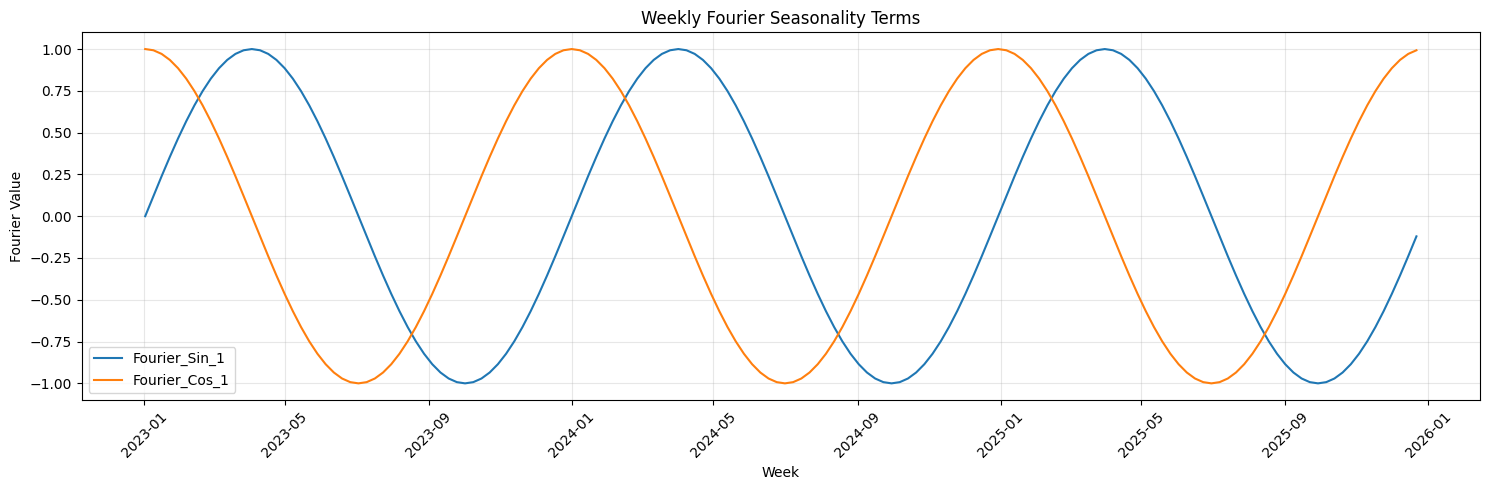


FOURIER VS SALES CORRELATION


,Variable,Sales_Correlation
0,Fourier_Sin_1,0.104
1,Fourier_Cos_1,-0.016


In [28]:
# ============================================================
# STEP 7A: CREATE FOURIER SEASONALITY VARIABLES
# ============================================================

# ------------------------------------------------------------
# 1. Make sure data is sorted chronologically
# ------------------------------------------------------------

model_base_df = (
    model_base_df
    .sort_values("Week_Start")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. Create continuous time index
# ------------------------------------------------------------
#
# t = 0, 1, 2, ..., n-1
#
# We use this instead of calendar week number so the seasonal
# cycle progresses continuously through the dataset.
# ------------------------------------------------------------

model_base_df["t"] = np.arange(
    len(model_base_df)
)


# ------------------------------------------------------------
# 3. Define annual seasonal period
# ------------------------------------------------------------

SEASONAL_PERIOD = 52


# ------------------------------------------------------------
# 4. First Fourier harmonic
# ------------------------------------------------------------
#
# Sin_t = sin(2*pi*t/52)
# Cos_t = cos(2*pi*t/52)
#
# ------------------------------------------------------------

model_base_df["Fourier_Sin_1"] = np.sin(
    2 * np.pi *
    model_base_df["t"] /
    SEASONAL_PERIOD
)

model_base_df["Fourier_Cos_1"] = np.cos(
    2 * np.pi *
    model_base_df["t"] /
    SEASONAL_PERIOD
)


# ------------------------------------------------------------
# 5. Check the variables
# ------------------------------------------------------------

print("\nFOURIER VARIABLES")
print("=" * 80)

display(
    model_base_df[
        [
            "Week",
            "Week_Start",
            "t",
            "Fourier_Sin_1",
            "Fourier_Cos_1"
        ]
    ].head(15)
)


# ------------------------------------------------------------
# 6. Check Fourier ranges
# ------------------------------------------------------------

print("\nFOURIER VARIABLE RANGES")
print("=" * 80)

fourier_summary = pd.DataFrame({

    "Variable": [
        "Fourier_Sin_1",
        "Fourier_Cos_1"
    ],

    "Minimum": [
        model_base_df["Fourier_Sin_1"].min(),
        model_base_df["Fourier_Cos_1"].min()
    ],

    "Maximum": [
        model_base_df["Fourier_Sin_1"].max(),
        model_base_df["Fourier_Cos_1"].max()
    ],

    "Mean": [
        model_base_df["Fourier_Sin_1"].mean(),
        model_base_df["Fourier_Cos_1"].mean()
    ],

    "Std_Dev": [
        model_base_df["Fourier_Sin_1"].std(),
        model_base_df["Fourier_Cos_1"].std()
    ]
})

display(
    fourier_summary.round(4)
)


# ------------------------------------------------------------
# 7. Visualize Fourier seasonality
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.plot(
    model_base_df["Week_Start"],
    model_base_df["Fourier_Sin_1"],
    label="Fourier_Sin_1"
)

plt.plot(
    model_base_df["Week_Start"],
    model_base_df["Fourier_Cos_1"],
    label="Fourier_Cos_1"
)

plt.title(
    "Weekly Fourier Seasonality Terms"
)

plt.xlabel("Week")
plt.ylabel("Fourier Value")

plt.legend()

plt.xticks(rotation=45)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Correlation of Fourier variables with Sales
# ------------------------------------------------------------

fourier_sales_corr = pd.DataFrame({

    "Variable": [
        "Fourier_Sin_1",
        "Fourier_Cos_1"
    ],

    "Sales_Correlation": [
        model_base_df["Fourier_Sin_1"]
        .corr(
            model_base_df["Sales_Volume_kgs"]
        ),

        model_base_df["Fourier_Cos_1"]
        .corr(
            model_base_df["Sales_Volume_kgs"]
        )
    ]
})


print("\nFOURIER VS SALES CORRELATION")
print("=" * 80)

display(
    fourier_sales_corr.round(3)
)

# Step 9 — Apply Geometric Adstock to Media

**Why this step:** adstock captures media carryover, allowing previous weeks' exposure to continue influencing the current week with geometric decay.

**Why this is safe:** the recursive calculation is causal; each week's adstock uses only current and earlier media values and never future observations.


Adstock Parameters:


,Media_Family,Alpha,Half_Life_Weeks
0,Print,0.40,0.756471
1,TV,0.65,1.609041
2,Meta,0.30,0.575717
3,Instagram,0.25,0.500000
4,YouTube,0.40,0.756471


Raw vs Adstocked Media Summary:


,Media_Family,Alpha,Raw_Max,Adstock_Max,Raw_Mean,Adstock_Mean,Raw_Total,Adstock_Total,Raw_Active_Weeks,Adstock_Active_Weeks
0,Print,0.40,302105.000000,481685.663011,56578.442308,94295.610760,8.826237e+06,1.471012e+07,50,144
1,TV,0.65,291.000000,607.291458,69.333333,198.012092,1.081600e+04,3.088989e+04,87,150
2,Meta,0.30,151198.000000,200798.514358,33324.577639,47606.539478,5.198634e+06,7.426620e+06,86,152
3,Instagram,0.25,256517.307429,327388.193400,52726.529193,70302.027324,8.225339e+06,1.096712e+07,90,154
4,YouTube,0.40,159237.265529,252582.407657,49083.716066,81805.227278,7.657060e+06,1.276162e+07,117,154


,Week,Week_Start,Print,Print_Adstock,TV,TV_Adstock,Meta,Meta_Adstock,Instagram,Instagram_Adstock,YouTube,YouTube_Adstock
0,1,2023-01-02,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,2023-01-09,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,2023-01-16,0.0,0.000000,0.0,0.000000,0.000000,0.000000,48317.472258,48317.472258,28250.989685,28250.989685
3,4,2023-01-23,0.0,0.000000,0.0,0.000000,0.000000,0.000000,76875.803795,88955.171859,48057.292904,59357.688778
4,5,2023-01-30,0.0,0.000000,0.0,0.000000,24429.973314,24429.973314,71545.027142,93783.820107,68330.015471,92073.090982
5,6,2023-02-06,0.0,0.000000,0.0,0.000000,36203.906945,43532.898939,49287.866535,72733.821561,55623.378338,92452.614731
6,7,2023-02-13,0.0,0.000000,65.0,65.000000,20304.060125,33363.929807,49681.166467,67864.621857,67547.386717,104528.432609
7,8,2023-02-20,0.0,0.000000,71.0,113.250000,0.000000,10009.178942,73330.953975,90297.109439,103656.972510,145468.345554
8,9,2023-02-27,0.0,0.000000,125.0,198.612500,32668.026291,35670.779974,75716.669873,98290.947233,125106.527416,183293.865638
9,10,2023-03-06,0.0,0.000000,231.0,360.098125,49167.408739,59868.642731,105323.452396,129896.189204,125752.756644,199070.302899


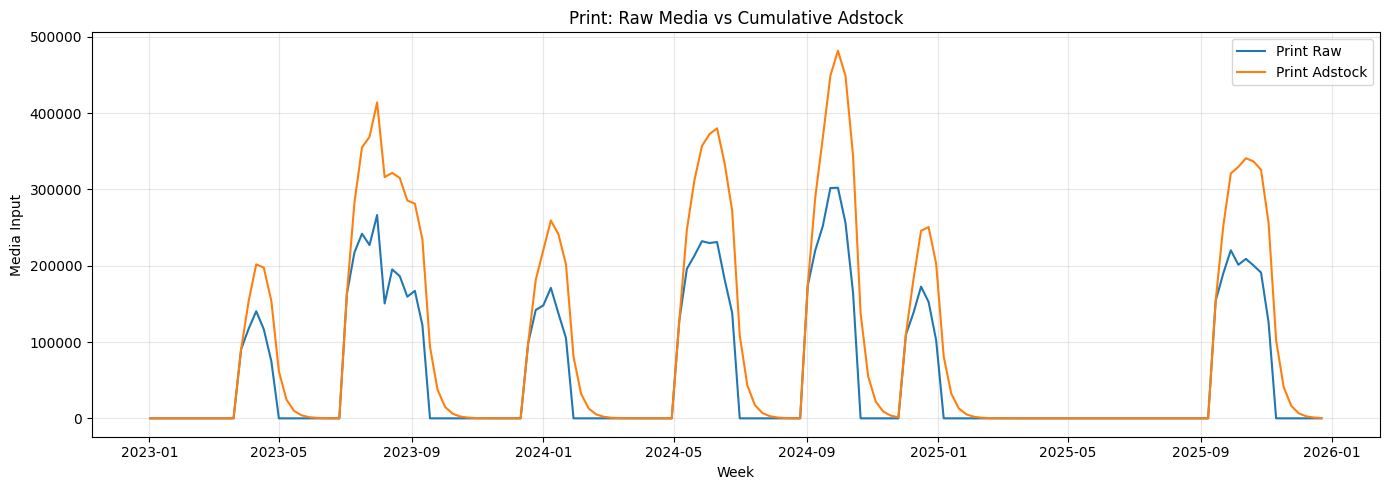

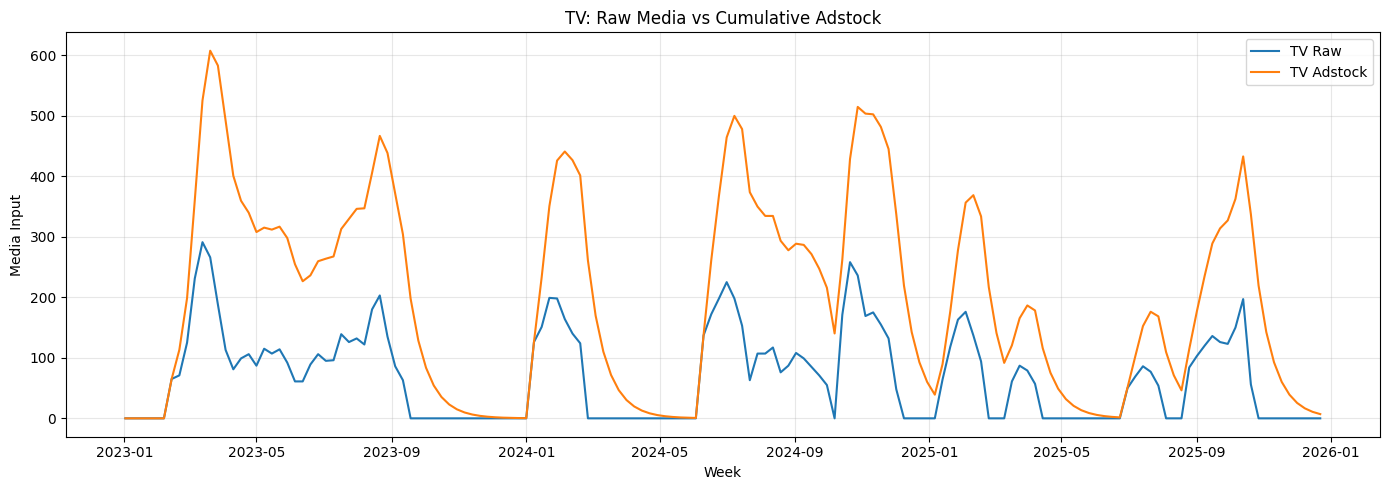

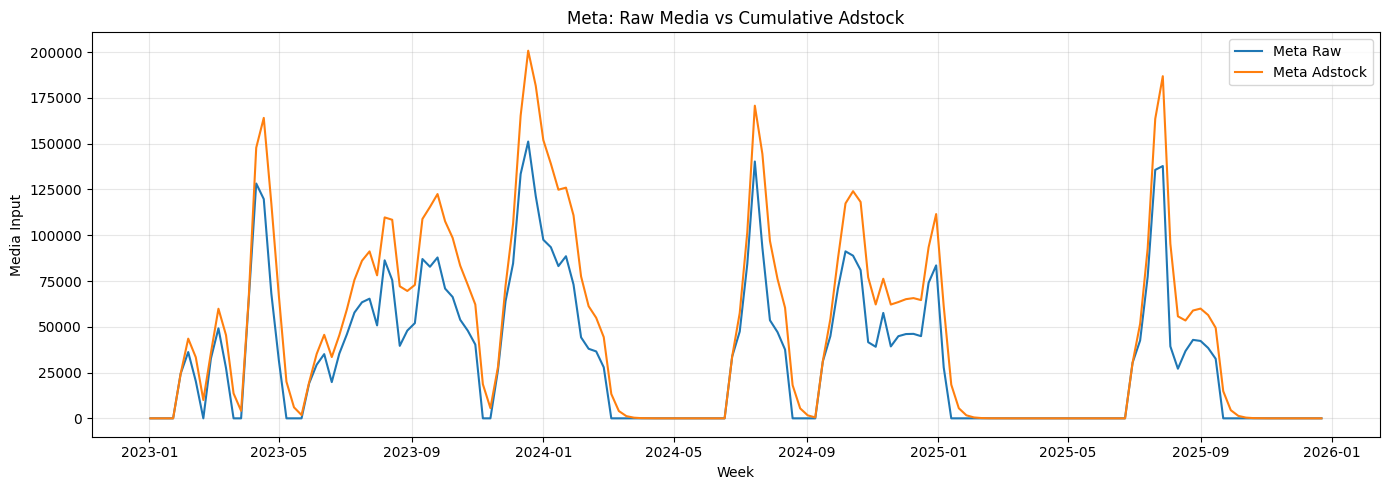

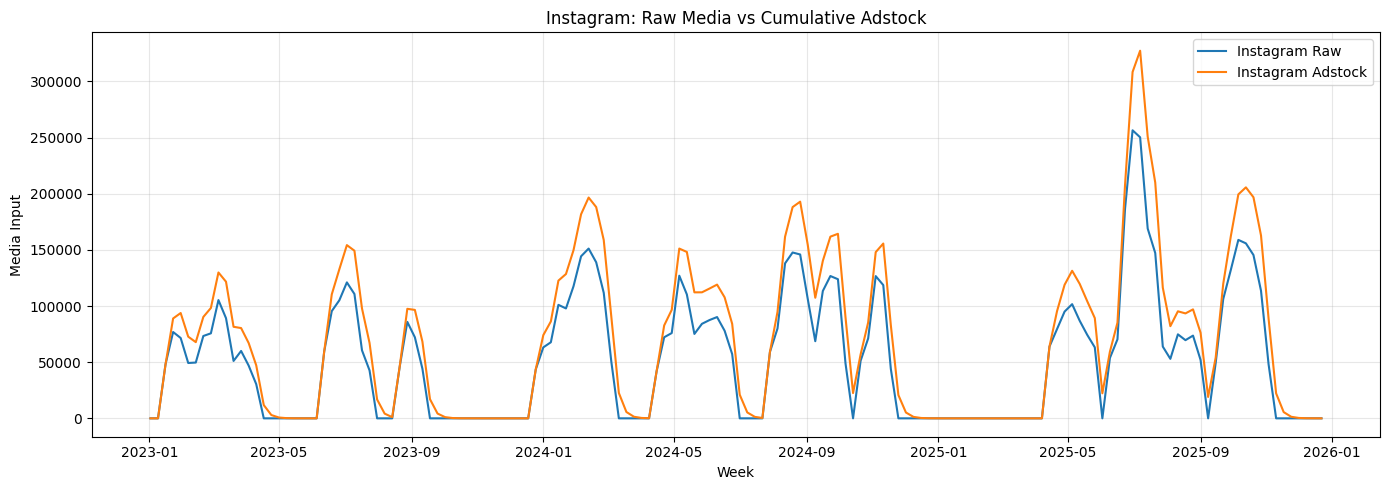

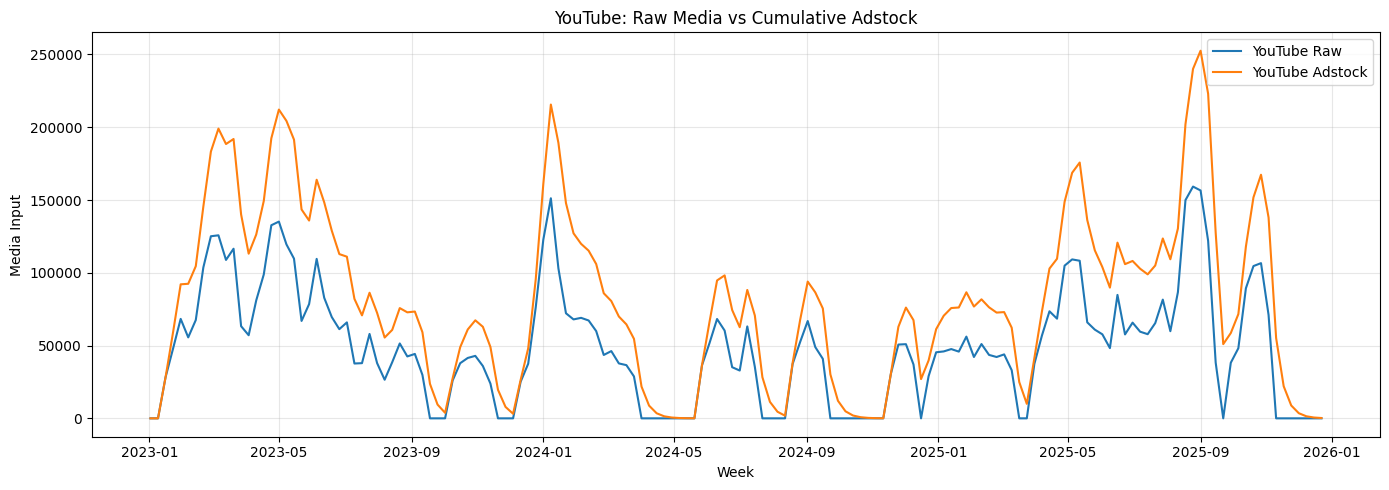

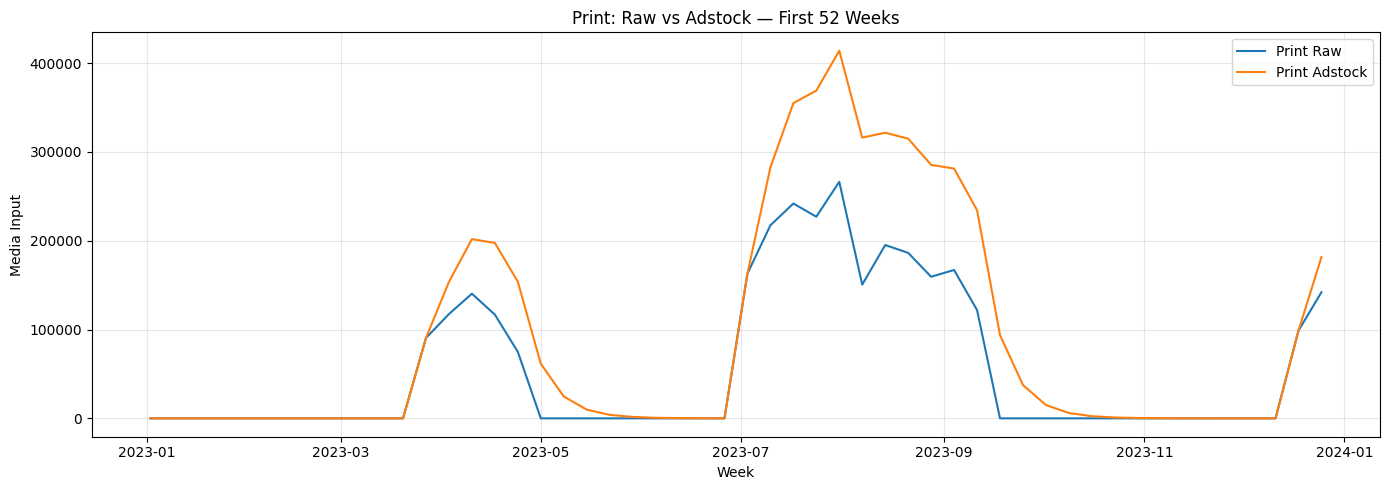

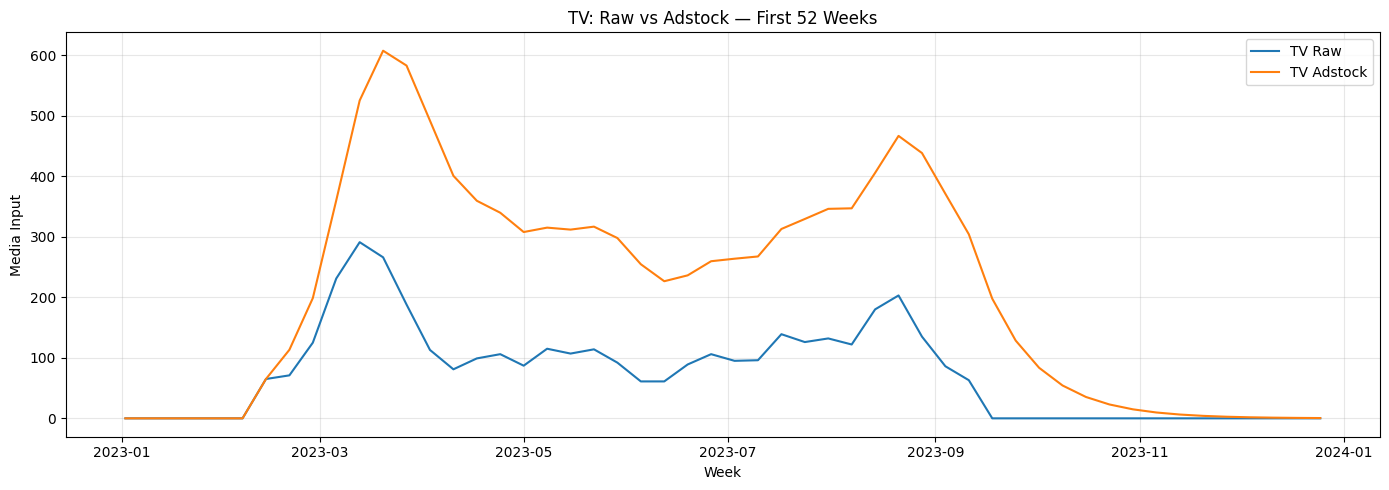

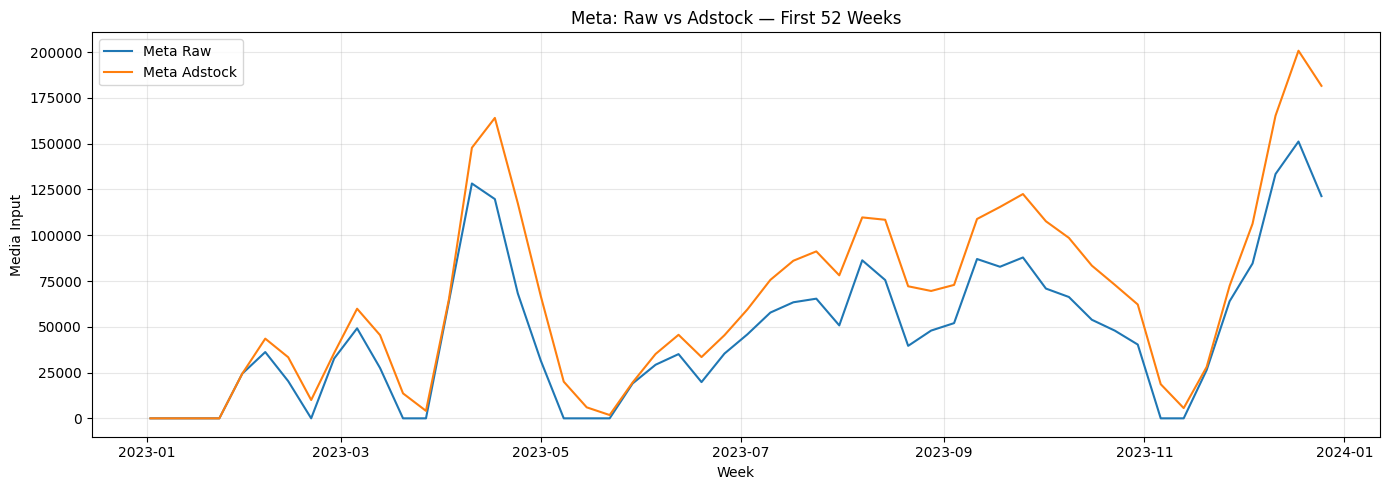

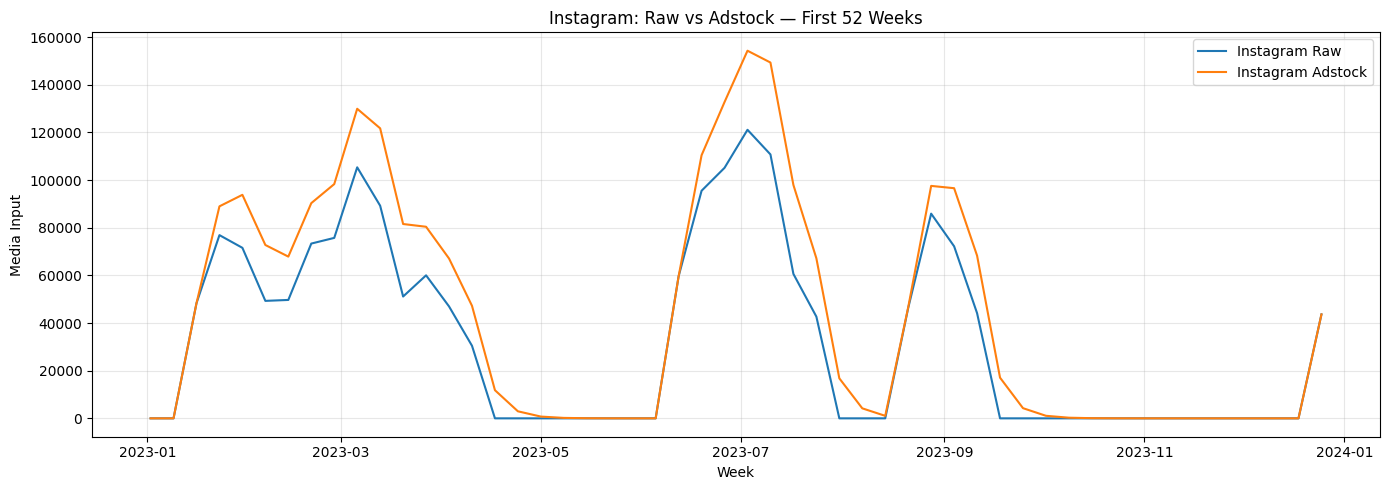

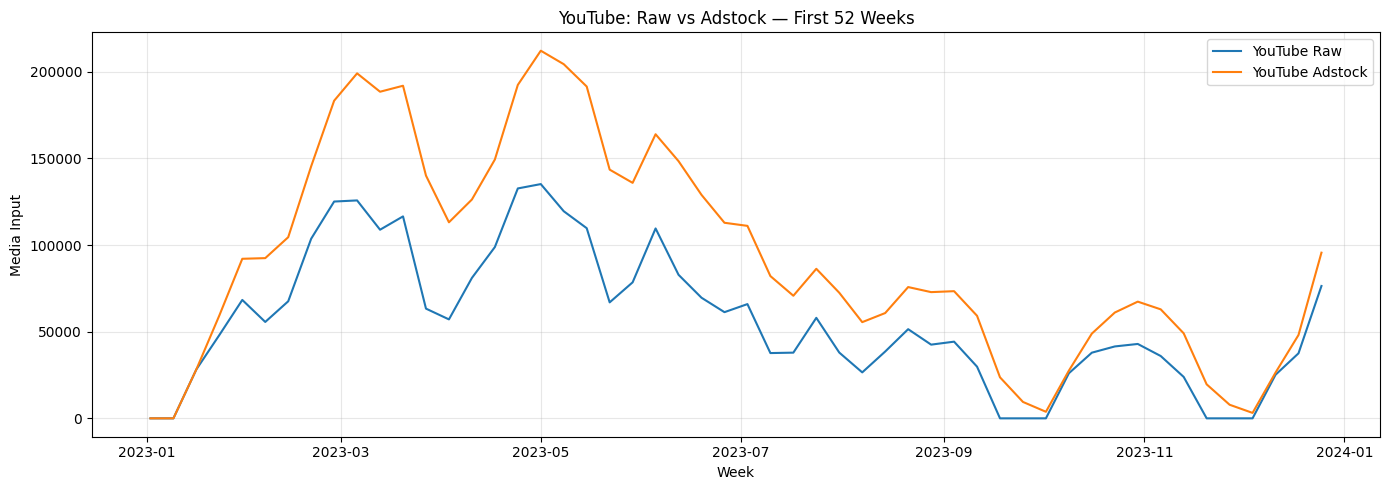

Raw vs Adstock Correlation:


,Media_Family,Alpha,Raw_vs_Adstock_Correlation
0,Print,0.40,0.970312
1,TV,0.65,0.867278
2,Meta,0.30,0.983093
3,Instagram,0.25,0.988895
4,YouTube,0.40,0.967557


Saved:
/content/mmm_outputs/Consumer Brand_MMM_Model_Base_Adstocked.csv
/content/mmm_outputs/Consumer Brand_Adstock_Raw_vs_Adstock_Summary.csv
/content/mmm_outputs/Consumer Brand_Adstock_Alpha_Summary.csv


In [29]:
# ============================================================
# STEP 9 — APPLY CUMULATIVE GEOMETRIC ADSTOCK
# ============================================================

# Make a copy of the scaled media-family data
model_adstock_df = model_base_df.copy()

# ------------------------------------------------------------
# 1. Define the cumulative geometric adstock function
#    Adstock_t = x_t + alpha * Adstock_(t-1)
# ------------------------------------------------------------

def geometric_adstock_cumulative(series, alpha):
    """
    Cumulative geometric adstock:

    Adstock_t = x_t + alpha * Adstock_(t-1)

    where:
        x_t     = current week's media input
        alpha   = retention/decay parameter, 0 <= alpha < 1
    """

    x = np.asarray(series, dtype=float)
    adstock = np.zeros(len(x))

    if len(x) == 0:
        return adstock

    # First week has no historical carry-over
    adstock[0] = x[0]

    # Recursive cumulative adstock
    for i in range(1, len(x)):
        adstock[i] = x[i] + alpha * adstock[i - 1]

    return adstock


# ------------------------------------------------------------
# 2. Set realistic starting alpha values by media family
# ------------------------------------------------------------

alpha_values = {
    "Print": 0.40,
    "TV": 0.65,
    "Meta": 0.30,
    "Instagram": 0.25,
    "YouTube": 0.40
}


# ------------------------------------------------------------
# 3. Create separate adstock variables
# ------------------------------------------------------------

for media_family in media_families:

    raw_col = media_family

    # Separate adstock variable
    adstock_col = f"{media_family}_Adstock"

    alpha = alpha_values[media_family]

    model_adstock_df[adstock_col] = geometric_adstock_cumulative(
        model_adstock_df[raw_col],
        alpha
    )


# ------------------------------------------------------------
# 4. Display alpha values used
# ------------------------------------------------------------

alpha_summary_df = pd.DataFrame({
    "Media_Family": list(alpha_values.keys()),
    "Alpha": list(alpha_values.values()),
    "Half_Life_Weeks": [
        np.log(0.5) / np.log(alpha)
        for alpha in alpha_values.values()
    ]
})

print("Adstock Parameters:")
display(alpha_summary_df)


# ------------------------------------------------------------
# 5. Compare RAW vs ADSTOCK summary
# ------------------------------------------------------------

adstock_summary = []

for media_family in media_families:

    raw = model_adstock_df[media_family]
    adstock = model_adstock_df[f"{media_family}_Adstock"]

    adstock_summary.append({
        "Media_Family": media_family,
        "Alpha": alpha_values[media_family],
        "Raw_Max": raw.max(),
        "Adstock_Max": adstock.max(),
        "Raw_Mean": raw.mean(),
        "Adstock_Mean": adstock.mean(),
        "Raw_Total": raw.sum(),
        "Adstock_Total": adstock.sum(),
        "Raw_Active_Weeks": (raw > 0).sum(),
        "Adstock_Active_Weeks": (adstock > 0).sum()
    })

adstock_summary_df = pd.DataFrame(adstock_summary)

print("Raw vs Adstocked Media Summary:")
display(adstock_summary_df)


# ------------------------------------------------------------
# 6. Show weekly raw vs adstock values
# ------------------------------------------------------------

comparison_cols = ["Week", "Week_Start"]

for media_family in media_families:
    comparison_cols.extend([
        media_family,
        f"{media_family}_Adstock"
    ])

raw_vs_adstock_df = model_adstock_df[comparison_cols].copy()

display(raw_vs_adstock_df.head(20))


# ------------------------------------------------------------
# 7. Calculate the difference between adstocked and raw
# ------------------------------------------------------------

for media_family in media_families:

    model_adstock_df[f"{media_family}_Adstock_Difference"] = (
        model_adstock_df[f"{media_family}_Adstock"]
        - model_adstock_df[media_family]
    )


# ------------------------------------------------------------
# 8. Plot RAW vs ADSTOCKed media for every family
# ------------------------------------------------------------

for media_family in media_families:

    plt.figure(figsize=(14, 5))

    plt.plot(
        model_adstock_df["Week_Start"],
        model_adstock_df[media_family],
        label=f"{media_family} Raw"
    )

    plt.plot(
        model_adstock_df["Week_Start"],
        model_adstock_df[f"{media_family}_Adstock"],
        label=f"{media_family} Adstock"
    )

    plt.title(
        f"{media_family}: Raw Media vs Cumulative Adstock"
    )

    plt.xlabel("Week")
    plt.ylabel("Media Input")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. Plot first 52 weeks for easier visual comparison
# ------------------------------------------------------------

first_52_df = model_adstock_df.head(52)

for media_family in media_families:

    plt.figure(figsize=(14, 5))

    plt.plot(
        first_52_df["Week_Start"],
        first_52_df[media_family],
        label=f"{media_family} Raw"
    )

    plt.plot(
        first_52_df["Week_Start"],
        first_52_df[f"{media_family}_Adstock"],
        label=f"{media_family} Adstock"
    )

    plt.title(
        f"{media_family}: Raw vs Adstock — First 52 Weeks"
    )

    plt.xlabel("Week")
    plt.ylabel("Media Input")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 10. Correlation between raw media and adstock
# ------------------------------------------------------------

raw_adstock_corr = []

for media_family in media_families:

    corr = model_adstock_df[
        [media_family, f"{media_family}_Adstock"]
    ].corr().iloc[0, 1]

    raw_adstock_corr.append({
        "Media_Family": media_family,
        "Alpha": alpha_values[media_family],
        "Raw_vs_Adstock_Correlation": corr
    })

raw_adstock_corr_df = pd.DataFrame(raw_adstock_corr)

print("Raw vs Adstock Correlation:")
display(raw_adstock_corr_df)


# ------------------------------------------------------------
# 11. Save outputs
# ------------------------------------------------------------

model_adstock_df.to_csv(
    output_folder / "Consumer Brand_MMM_Model_Base_Adstocked.csv",
    index=False
)

adstock_summary_df.to_csv(
    output_folder / "Consumer Brand_Adstock_Raw_vs_Adstock_Summary.csv",
    index=False
)

alpha_summary_df.to_csv(
    output_folder / "Consumer Brand_Adstock_Alpha_Summary.csv",
    index=False
)

print("Saved:")
print(output_folder / "Consumer Brand_MMM_Model_Base_Adstocked.csv")
print(output_folder / "Consumer Brand_Adstock_Raw_vs_Adstock_Summary.csv")
print(output_folder / "Consumer Brand_Adstock_Alpha_Summary.csv")

# Step 10 — Apply Zero-Anchored Logistic Saturation

**Why this step:** media response can show diminishing returns, so saturation is applied after adstock to model nonlinear response.

**Correction:** the logistic curve is normalized so **zero adstock produces zero transformed media**. This is important before contribution and ROAS decomposition.



Zero-anchor saturation check: 0.000000000000
Total observations : 156
Training observations : 124
Testing observations  : 32

Selected Saturation Parameters:


,Media_Family,k,x0,Q25_Adstock,Q75_Adstock,IQR_Adstock
0,Print,0.0000,16205.4466,172.1090,207053.4676,206881.3586
1,TV,0.0078,241.7571,66.6554,349.0958,282.4404
2,Meta,0.0000,49957.8397,1522.5156,86373.5686,84851.0530
3,Instagram,0.0000,58058.4021,112.3077,109737.0458,109624.7381
4,YouTube,0.0000,72565.0387,28752.2300,108738.2052,79985.9752


,Week,Week_Start,Print_Adstock,TV_Adstock,Meta_Adstock,Instagram_Adstock,YouTube_Adstock,Print_Saturated,TV_Saturated,Meta_Saturated,Instagram_Saturated,YouTube_Saturated
0,1,2023-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,2023-01-09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,2023-01-16,0.000000,0.000000,0.000000,48317.472258,28250.989685,0.000000,0.000000,0.000000,0.279979,0.123292
3,4,2023-01-23,0.000000,0.000000,0.000000,88955.171859,59357.688778,0.000000,0.000000,0.000000,0.540751,0.329939
4,5,2023-01-30,0.000000,0.000000,24429.973314,93783.820107,92073.090982,0.000000,0.000000,0.159628,0.569208,0.580565
5,6,2023-02-06,0.000000,0.000000,43532.898939,72733.821561,92452.614731,0.000000,0.000000,0.309988,0.439645,0.583320
6,7,2023-02-13,0.000000,65.000000,33363.929807,67864.621857,104528.432609,0.000000,0.080094,0.228048,0.408109,0.666419
7,8,2023-02-20,0.000000,113.250000,10009.178942,90297.109439,145468.345554,0.000000,0.157536,0.059870,0.548747,0.864875
8,9,2023-02-27,0.000000,198.612500,35670.779974,98290.947233,183293.865638,0.000000,0.327954,0.246336,0.594933,0.948215
9,10,2023-03-06,0.000000,360.098125,59868.642731,129896.189204,199070.302899,0.000000,0.671739,0.444179,0.748599,0.965880



Raw → Adstock → Saturation Summary:


,Media_Family,Alpha,k,x0,Raw_Mean,Adstock_Mean,Saturated_Mean,Raw_Max,Adstock_Max,Saturated_Min,Saturated_Max,Saturated_Median
0,Print,0.40,0.0000,16205.4466,56578.4423,94295.6108,0.3023,302105.0000,481685.6630,0.0,0.9870,0.0181
1,TV,0.65,0.0078,241.7571,69.3333,198.0121,0.3437,291.0000,607.2915,0.0,0.9366,0.2808
2,Meta,0.30,0.0000,49957.8397,33324.5776,47606.5395,0.3242,151198.0000,200798.5144,0.0,0.9749,0.2368
3,Instagram,0.25,0.0000,58058.4021,52726.5292,70302.0273,0.3788,256517.3074,327388.1934,0.0,0.9941,0.4032
4,YouTube,0.40,0.0000,72565.0387,49083.7161,81805.2273,0.4619,159237.2655,252582.4077,0.0,0.9920,0.4424


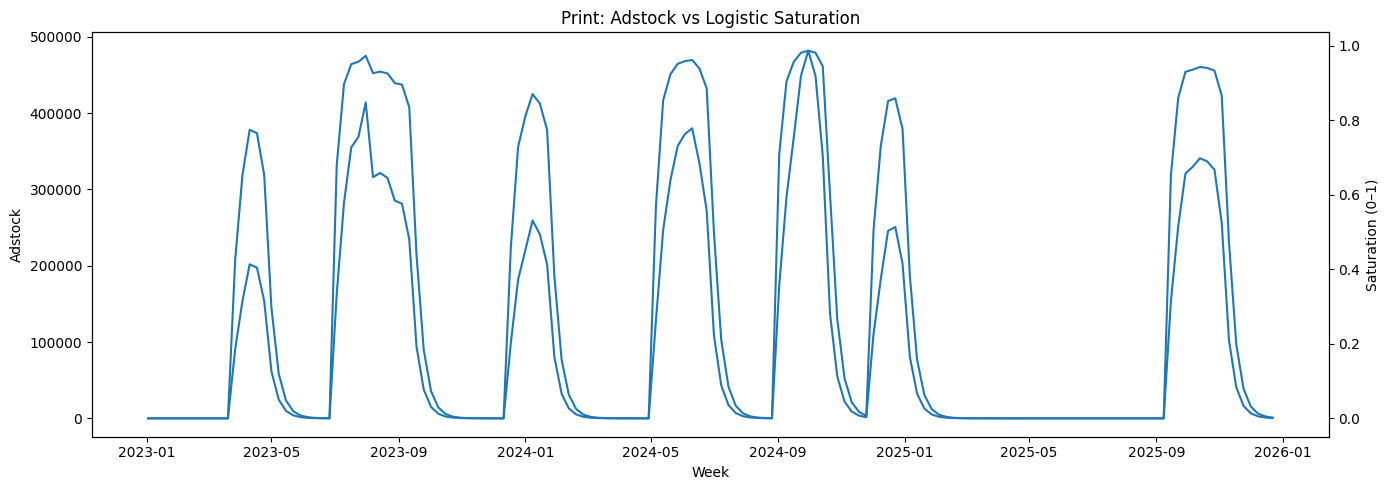

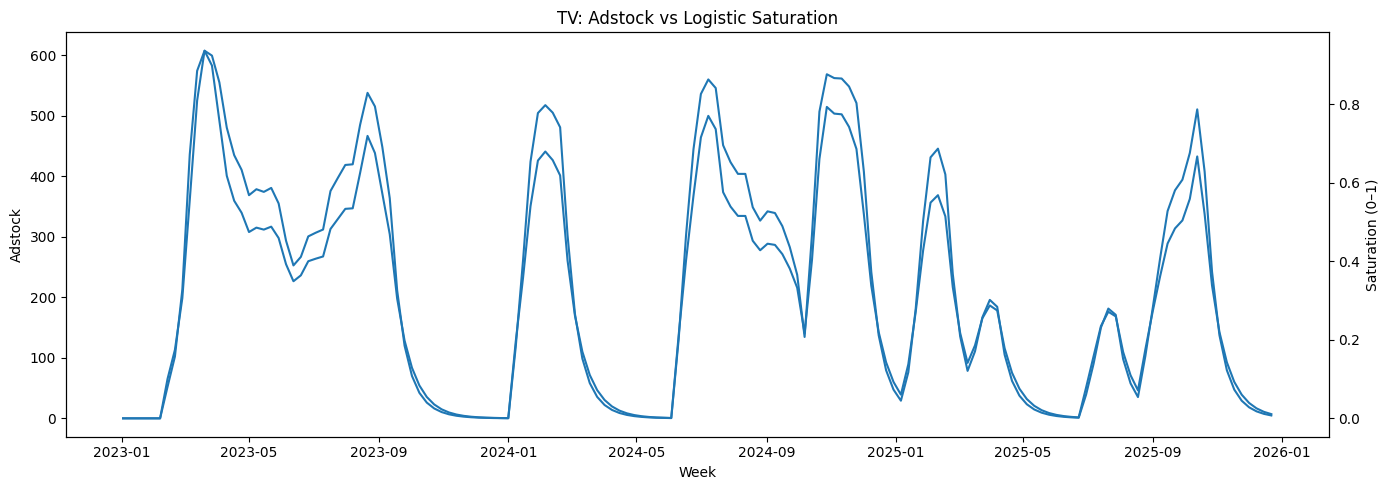

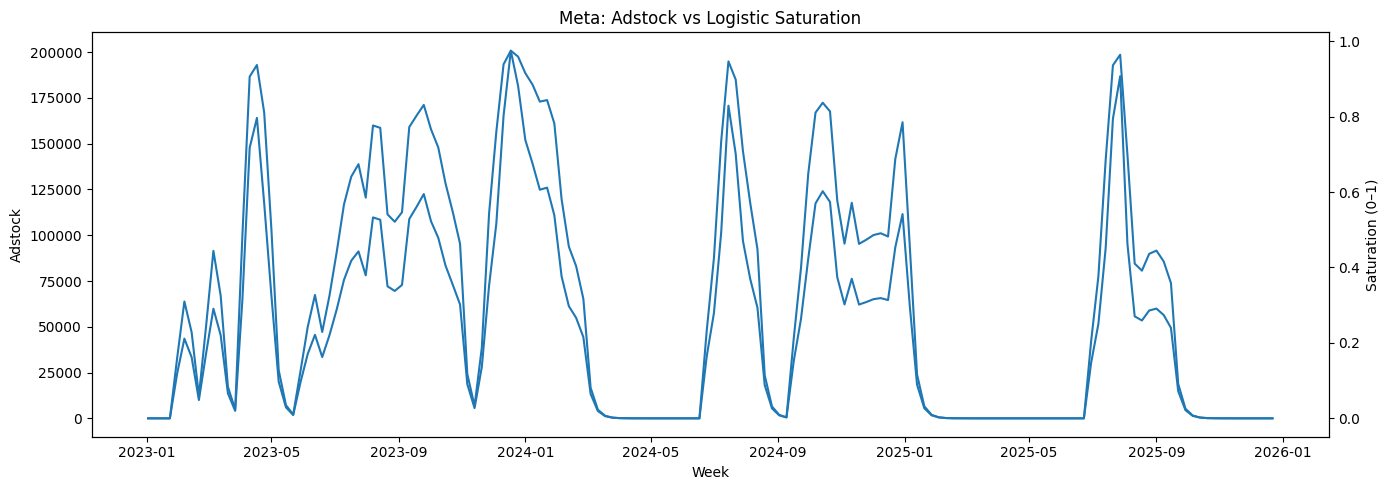

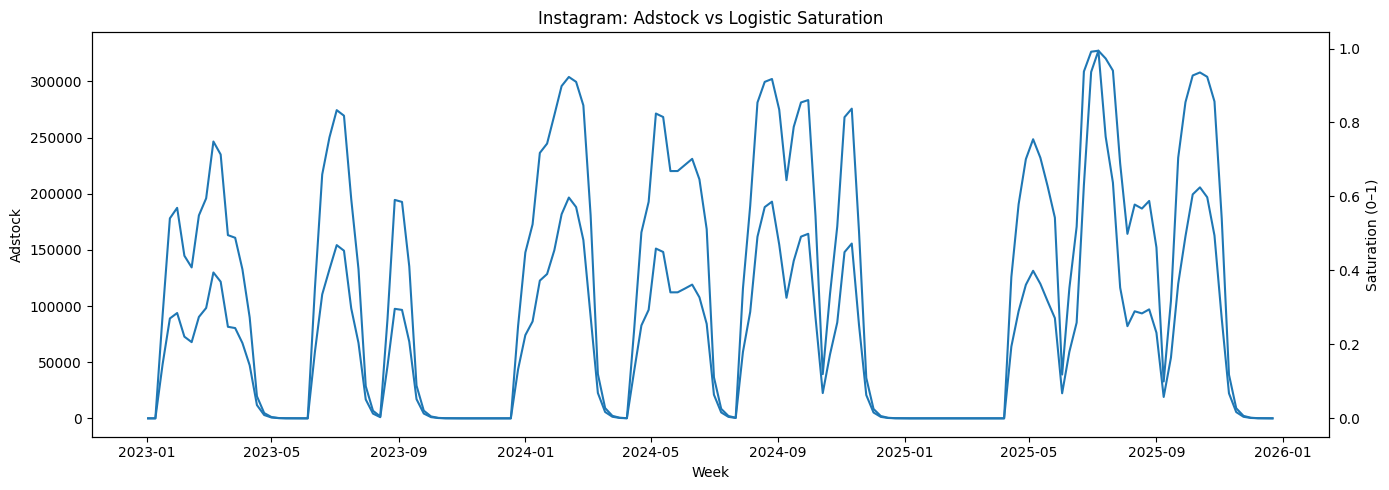

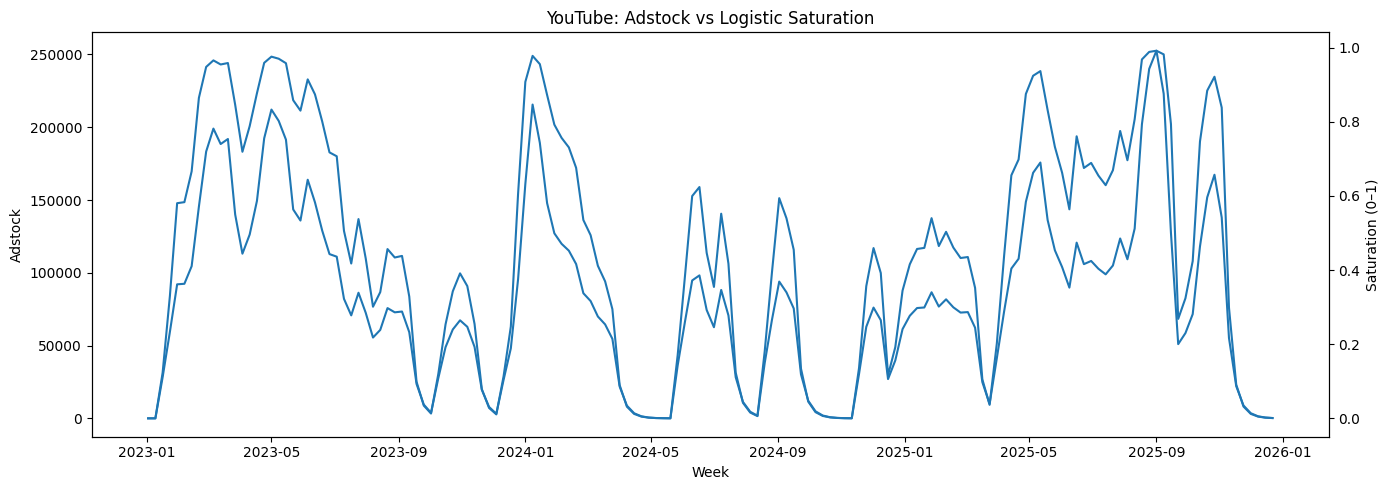

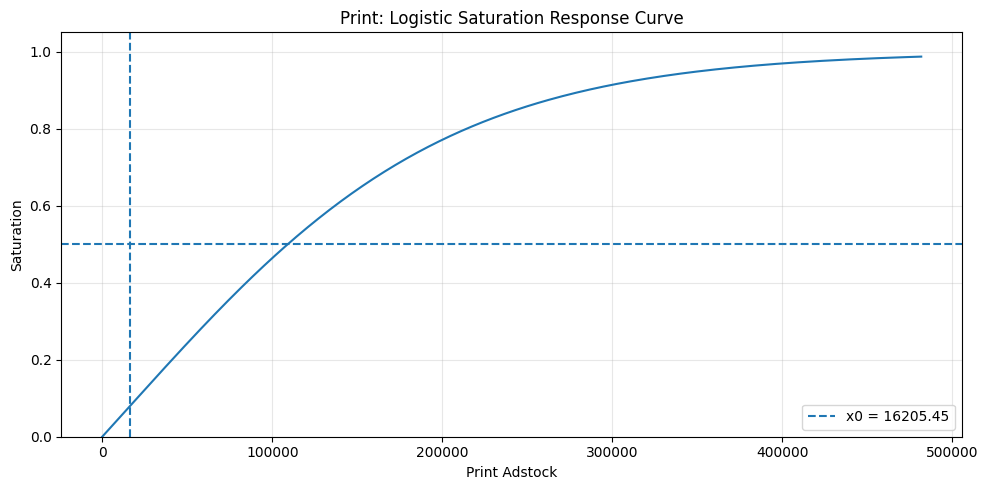

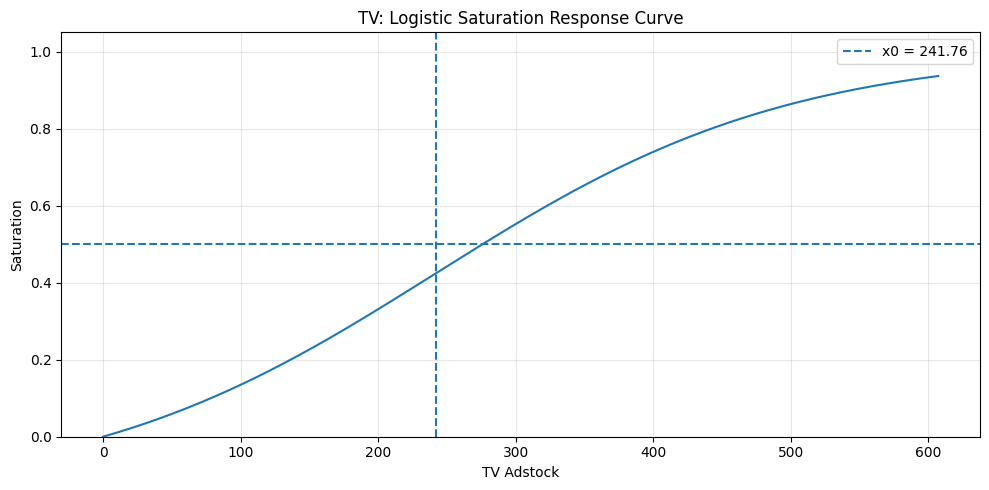

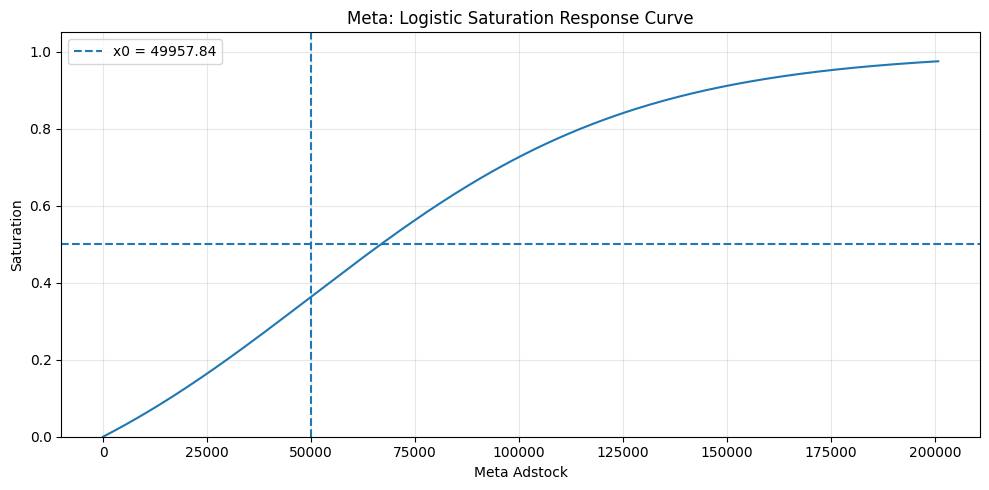

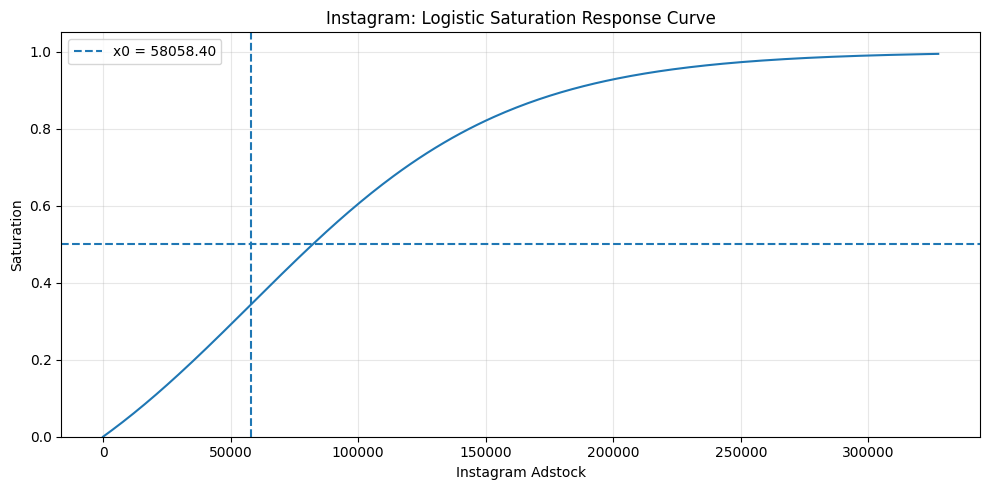

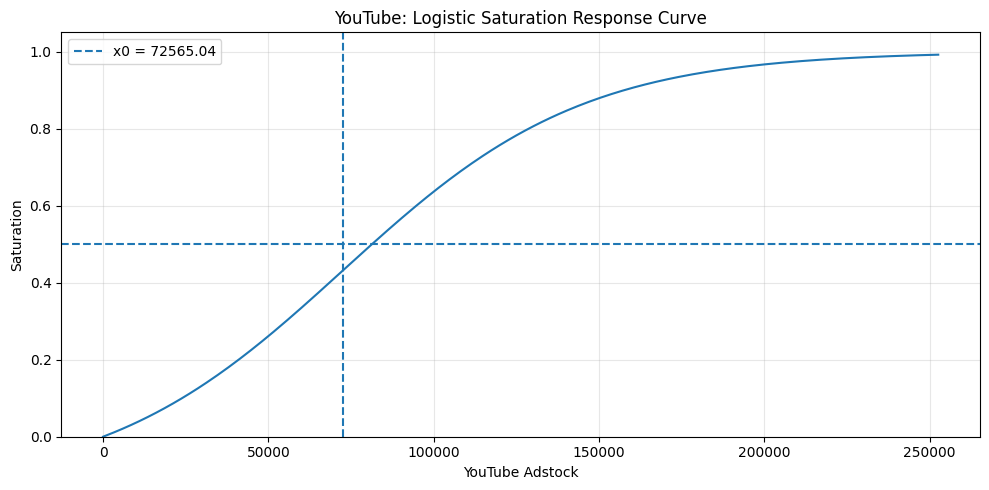


Saturation at Current Average Adstock:


,Media_Family,Average_Adstock,k,x0,Saturation_at_Average_Adstock
0,Print,94295.6108,0.0000,16205.4466,0.4405
1,TV,198.0121,0.0078,241.7571,0.3266
2,Meta,47606.5395,0.0000,49957.8397,0.3435
3,Instagram,70302.0273,0.0000,58058.4021,0.4239
4,YouTube,81805.2273,0.0000,72565.0387,0.5036



Saved files:
/content/mmm_outputs/Consumer Brand_MMM_Model_Base_Adstock_Saturated.csv
/content/mmm_outputs/Consumer Brand_Saturation_Parameters.csv
/content/mmm_outputs/Consumer Brand_Raw_Adstock_Saturation_Summary.csv
/content/mmm_outputs/Consumer Brand_Current_Average_Saturation.csv


In [30]:
# ============================================================
# STEP 10 — LOGISTIC SATURATION ON ADSTOCKED MEDIA
# ============================================================

# ------------------------------------------------------------
# 1. Define logistic saturation function
# ------------------------------------------------------------

def logistic_saturation(x, k, x0):
    """
    Zero-anchored logistic saturation.

    The ordinary logistic is normalized against its value at x=0,
    so transformed(0)=0 and the curve approaches 1 at high input.
    This prevents a positive transformed media value during weeks
    with zero adstock.
    """

    x = np.asarray(x, dtype=float)

    if k <= 0:
        raise ValueError(
            "k must be > 0 for logistic saturation."
        )

    exponent_x = np.clip(
        -k * (x - x0),
        -700,
        700
    )

    logistic_x = 1 / (
        1 + np.exp(exponent_x)
    )

    exponent_zero = np.clip(
        -k * (0.0 - x0),
        -700,
        700
    )

    logistic_zero = 1 / (
        1 + np.exp(exponent_zero)
    )

    denominator = 1 - logistic_zero

    if abs(denominator) < 1e-12:
        return np.zeros_like(x, dtype=float)

    saturated = (
        logistic_x - logistic_zero
    ) / denominator

    return np.clip(
        saturated,
        0.0,
        1.0
    )

# ------------------------------------------------------------
# 2. Create model dataframe for saturation
# ------------------------------------------------------------

model_saturation_df = model_adstock_df.copy()

# Sanity check: zero adstock must map to zero transformed media.
zero_anchor_test = float(
    logistic_saturation(
        np.array([0.0]),
        k=1.0,
        x0=1.0
    )[0]
)

print(
    f"\nZero-anchor saturation check: {zero_anchor_test:.12f}"
)


# ------------------------------------------------------------
# 3. Chronological train/test split
#    We use only TRAIN data to determine saturation parameters
# ------------------------------------------------------------

n_obs = len(model_saturation_df)

train_size = int(n_obs * 0.80)

train_saturation_df = model_saturation_df.iloc[:train_size].copy()
test_saturation_df = model_saturation_df.iloc[train_size:].copy()

print(f"Total observations : {n_obs}")
print(f"Training observations : {len(train_saturation_df)}")
print(f"Testing observations  : {len(test_saturation_df)}")


# ------------------------------------------------------------
# 4. Choose family-specific saturation parameters
# ------------------------------------------------------------

saturation_parameters = {}

for media_family in media_families:

    adstock_col = f"{media_family}_Adstock"

    # Use TRAINING data only
    train_values = train_saturation_df[adstock_col].astype(float)

    # Only positive values are used to determine the
    # meaningful media-response range
    positive_values = train_values[train_values > 0]

    # Safety fallback
    if len(positive_values) < 5:
        positive_values = train_values[train_values >= 0]

    # --------------------------------------------------------
    # Midpoint:
    # median of positive adstock
    # --------------------------------------------------------

    x0 = positive_values.median()

    # --------------------------------------------------------
    # Spread:
    # interquartile range
    # --------------------------------------------------------

    q25 = positive_values.quantile(0.25)
    q75 = positive_values.quantile(0.75)

    iqr = q75 - q25

    # Safety protection against zero IQR
    if iqr <= 0:
        iqr = positive_values.std()

    if pd.isna(iqr) or iqr <= 0:
        iqr = max(abs(x0) * 0.10, 1e-6)

    # --------------------------------------------------------
    # Choose k so that:
    #
    # S(x0 - IQR/2) ≈ 0.25
    # S(x0 + IQR/2) ≈ 0.75
    #
    # Therefore:
    #
    # k = 2*ln(3) / IQR
    # --------------------------------------------------------

    k = (2 * np.log(3)) / iqr

    saturation_parameters[media_family] = {
        "k": k,
        "x0": x0,
        "Q25_Adstock": q25,
        "Q75_Adstock": q75,
        "IQR_Adstock": iqr
    }


# ------------------------------------------------------------
# 5. Display selected parameters
# ------------------------------------------------------------

saturation_parameter_rows = []

for media_family, params in saturation_parameters.items():

    saturation_parameter_rows.append({
        "Media_Family": media_family,
        "k": params["k"],
        "x0": params["x0"],
        "Q25_Adstock": params["Q25_Adstock"],
        "Q75_Adstock": params["Q75_Adstock"],
        "IQR_Adstock": params["IQR_Adstock"]
    })

saturation_parameters_df = pd.DataFrame(
    saturation_parameter_rows
)

print("\nSelected Saturation Parameters:")
display(
    saturation_parameters_df.round(4)
)


# ------------------------------------------------------------
# 6. Create separate saturated variable for every family
# ------------------------------------------------------------

for media_family in media_families:

    adstock_col = f"{media_family}_Adstock"
    saturation_col = f"{media_family}_Saturated"

    k = saturation_parameters[media_family]["k"]
    x0 = saturation_parameters[media_family]["x0"]

    model_saturation_df[saturation_col] = logistic_saturation(
        model_saturation_df[adstock_col],
        k=k,
        x0=x0
    )


# ------------------------------------------------------------
# 7. Check the new saturated variables
# ------------------------------------------------------------

saturated_cols = [
    f"{media_family}_Saturated"
    for media_family in media_families
]

display(
    model_saturation_df[
        ["Week", "Week_Start"] +
        [f"{media_family}_Adstock" for media_family in media_families] +
        saturated_cols
    ].head(20)
)


# ------------------------------------------------------------
# 8. Summary: Raw -> Adstock -> Saturated
# ------------------------------------------------------------

transformation_summary = []

for media_family in media_families:

    raw = model_saturation_df[media_family]
    adstock = model_saturation_df[f"{media_family}_Adstock"]
    saturated = model_saturation_df[f"{media_family}_Saturated"]

    transformation_summary.append({

        "Media_Family": media_family,

        "Alpha":
            alpha_values[media_family],

        "k":
            saturation_parameters[media_family]["k"],

        "x0":
            saturation_parameters[media_family]["x0"],

        "Raw_Mean":
            raw.mean(),

        "Adstock_Mean":
            adstock.mean(),

        "Saturated_Mean":
            saturated.mean(),

        "Raw_Max":
            raw.max(),

        "Adstock_Max":
            adstock.max(),

        "Saturated_Min":
            saturated.min(),

        "Saturated_Max":
            saturated.max(),

        "Saturated_Median":
            saturated.median()
    })


transformation_summary_df = pd.DataFrame(
    transformation_summary
)

print("\nRaw → Adstock → Saturation Summary:")
display(
    transformation_summary_df.round(4)
)


# ------------------------------------------------------------
# 9. Plot ADSTOCK vs SATURATION for each media family
# ------------------------------------------------------------

for media_family in media_families:

    adstock_col = f"{media_family}_Adstock"
    saturation_col = f"{media_family}_Saturated"

    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax1.plot(
        model_saturation_df["Week_Start"],
        model_saturation_df[adstock_col],
        label=f"{media_family} Adstock"
    )

    ax1.set_xlabel("Week")
    ax1.set_ylabel("Adstock")

    ax2 = ax1.twinx()

    ax2.plot(
        model_saturation_df["Week_Start"],
        model_saturation_df[saturation_col],
        label=f"{media_family} Saturated"
    )

    ax2.set_ylabel("Saturation (0–1)")

    plt.title(
        f"{media_family}: Adstock vs Logistic Saturation"
    )

    fig.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 10. Plot actual saturation response curves
#     using the observed adstock range
# ------------------------------------------------------------

for media_family in media_families:

    adstock_col = f"{media_family}_Adstock"

    k = saturation_parameters[media_family]["k"]
    x0 = saturation_parameters[media_family]["x0"]

    observed_values = model_saturation_df[adstock_col]

    x_curve = np.linspace(
        observed_values.min(),
        observed_values.max(),
        300
    )

    y_curve = logistic_saturation(
        x_curve,
        k=k,
        x0=x0
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        x_curve,
        y_curve
    )

    plt.axvline(
        x0,
        linestyle="--",
        label=f"x0 = {x0:.2f}"
    )

    plt.axhline(
        0.5,
        linestyle="--"
    )

    plt.xlabel(f"{media_family} Adstock")
    plt.ylabel("Saturation")
    plt.title(
        f"{media_family}: Logistic Saturation Response Curve"
    )

    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 11. Inspect saturation at current average adstock
# ------------------------------------------------------------

current_average_saturation = []

for media_family in media_families:

    adstock_col = f"{media_family}_Adstock"

    k = saturation_parameters[media_family]["k"]
    x0 = saturation_parameters[media_family]["x0"]

    avg_adstock = model_saturation_df[adstock_col].mean()

    avg_saturation = logistic_saturation(
        avg_adstock,
        k=k,
        x0=x0
    )

    current_average_saturation.append({

        "Media_Family": media_family,

        "Average_Adstock":
            avg_adstock,

        "k":
            k,

        "x0":
            x0,

        "Saturation_at_Average_Adstock":
            float(avg_saturation)
    })


current_average_saturation_df = pd.DataFrame(
    current_average_saturation
)

print("\nSaturation at Current Average Adstock:")
display(
    current_average_saturation_df.round(4)
)


# ------------------------------------------------------------
# 12. Save final transformed modeling dataset
# ------------------------------------------------------------

model_saturation_df.to_csv(
    output_folder / "Consumer Brand_MMM_Model_Base_Adstock_Saturated.csv",
    index=False
)

saturation_parameters_df.to_csv(
    output_folder / "Consumer Brand_Saturation_Parameters.csv",
    index=False
)

transformation_summary_df.to_csv(
    output_folder / "Consumer Brand_Raw_Adstock_Saturation_Summary.csv",
    index=False
)

current_average_saturation_df.to_csv(
    output_folder / "Consumer Brand_Current_Average_Saturation.csv",
    index=False
)


print("\nSaved files:")
print(output_folder / "Consumer Brand_MMM_Model_Base_Adstock_Saturated.csv")
print(output_folder / "Consumer Brand_Saturation_Parameters.csv")
print(output_folder / "Consumer Brand_Raw_Adstock_Saturation_Summary.csv")
print(output_folder / "Consumer Brand_Current_Average_Saturation.csv")

# Step 10A — Create Training-Referenced Price Variable

**Why this step:** price is retained as a demand control, and centering improves numerical interpretation.

**Leakage fix:** the centering reference is learned from the outer training period only. Inner CV uses an even stricter fold-specific training mean.


In [31]:
# ============================================================
# MEAN-CENTER PRICE USING AVG_Price_Per_kgs
# ============================================================

# Estimate the centering reference from OUTER TRAIN ONLY.
outer_train_size = int(
    len(model_saturation_df) * TRAIN_FRACTION
)

training_average_price = (
    model_saturation_df
    .iloc[:outer_train_size]["AVG_Price_Per_kgs"]
    .astype(float)
    .mean()
)

model_saturation_df["Price_Mean_Centered"] = (
    model_saturation_df["AVG_Price_Per_kgs"].astype(float)
    - training_average_price
)

print(
    f"Outer-training Average Price used for centering: "
    f"₹{training_average_price:.2f}"
)

print(
    "Training mean of Price_Mean_Centered:",
    model_saturation_df
    .iloc[:outer_train_size]["Price_Mean_Centered"]
    .mean()
)
# Show calculation
display(
    model_saturation_df[
        [
            "Week",
            "Week_Start",
            "AVG_Price_Per_kgs",
            "Price_Mean_Centered"
        ]
    ].head(10)
)

# Verify centered variable has mean approximately zero
print(
    "\nMean of Price_Mean_Centered:",
    model_saturation_df["Price_Mean_Centered"].mean()
)

# Summary statistics
print("\nPrice_Mean_Centered Summary:")
display(
    model_saturation_df["Price_Mean_Centered"].describe()
)

Outer-training Average Price used for centering: ₹249.32
Training mean of Price_Mean_Centered: 9.168293364646454e-15


,Week,Week_Start,AVG_Price_Per_kgs,Price_Mean_Centered
0,1,2023-01-02,274,24.677419
1,2,2023-01-09,211,-38.322581
2,3,2023-01-16,248,-1.322581
3,4,2023-01-23,268,18.677419
4,5,2023-01-30,270,20.677419
5,6,2023-02-06,287,37.677419
6,7,2023-02-13,200,-49.322581
7,8,2023-02-20,245,-4.322581
8,9,2023-02-27,244,-5.322581
9,10,2023-03-06,297,47.677419



Mean of Price_Mean_Centered: -0.9187344913151273

Price_Mean_Centered Summary:


,Price_Mean_Centered
count,156.000000
mean,-0.918734
std,28.048525
min,-49.322581
25%,-23.322581
50%,-1.822581
75%,23.927419
max,48.677419


# Step 11 — Tune Adstock and Saturation with Leakage-Safe Rolling CV

**Why this step:** select carryover and saturation parameters using chronological validation rather than arbitrary assumptions.

**Leakage fix:** for every fold, the saturation distribution parameters are learned only from that fold's training rows; validation rows are transformed using those frozen parameters. Price centering is also fold-specific. The final 20% holdout is not used during tuning.


In [32]:
# ============================================================
# STEP 11 — TUNE ADSTOCK + SATURATION PARAMETERS
#             USING CHRONOLOGICAL VALIDATION
# ============================================================

# ------------------------------------------------------------
# 1. Identify target and control variables
# ------------------------------------------------------------

sales_col = "Sales_Volume_kgs"

# Price control
control_cols = [
    "Price_Mean_Centered"
]

# Holiday variables
control_cols += [
    col for col in model_saturation_df.columns
    if col.startswith("Holiday_")
]

# Promotion / trade-promotion variables
control_cols += [
    col for col in model_saturation_df.columns
    if col.startswith("Promotion_") or col.startswith("TradePromo_")
]

# Trend
if "Trend_Centered" in model_saturation_df.columns:
    control_cols.append("Trend_Centered")
elif "Trend" in model_saturation_df.columns:
    control_cols.append("Trend")

# Fourier seasonality
if "Fourier_Sin_1" in model_saturation_df.columns:
    control_cols.append("Fourier_Sin_1")
    control_cols.append("Fourier_Cos_1")
elif "Sin_52" in model_saturation_df.columns:
    control_cols.append("Sin_52")
    control_cols.append("Cos_52")

# Keep only columns that actually exist
control_cols = [
    col for col in control_cols
    if col in model_saturation_df.columns
]

print("Sales column:")
print(sales_col)

print("\nControl variables:")
print(control_cols)


# ------------------------------------------------------------
# 2. Chronological train / final holdout split
# ------------------------------------------------------------

tuning_df = model_saturation_df.copy().reset_index(drop=True)

n_obs = len(tuning_df)

train_size = int(n_obs * 0.80)

train_df = tuning_df.iloc[:train_size].copy()
test_df = tuning_df.iloc[train_size:].copy()

print("\nData split:")
print(f"Total observations : {n_obs}")
print(f"Training           : {len(train_df)}")
print(f"Final holdout      : {len(test_df)}")

print(
    f"\nTraining period: "
    f"{train_df['Week_Start'].min()} → {train_df['Week_Start'].max()}"
)

print(
    f"Holdout period: "
    f"{test_df['Week_Start'].min()} → {test_df['Week_Start'].max()}"
)


# ------------------------------------------------------------
# 3. Rolling validation folds INSIDE training data
# ------------------------------------------------------------

# Validation is performed only inside the training period.
# This keeps the final 20% untouched.

inner_train_ends = [
    int(train_size * 0.55),
    int(train_size * 0.70),
    int(train_size * 0.85)
]

inner_val_length = max(8, int(train_size * 0.10))

cv_folds = []

for train_end in inner_train_ends:

    val_start = train_end
    val_end = min(
        train_end + inner_val_length,
        train_size
    )

    if val_end > val_start:

        cv_folds.append(
            (0, train_end, val_start, val_end)
        )

print("\nRolling CV folds:")
for fold_num, (_, train_end, val_start, val_end) in enumerate(
    cv_folds, start=1
):
    print(
        f"Fold {fold_num}: "
        f"Train rows 0:{train_end} | "
        f"Validation rows {val_start}:{val_end}"
    )


# ------------------------------------------------------------
# 4. Candidate grids
# ------------------------------------------------------------

# Carryover candidates
alpha_grid = [
    0.00,
    0.20,
    0.40,
    0.60,
    0.80
]

# Saturation midpoint relative to typical adstock
x0_multiplier_grid = [
    0.75,
    1.00,
    1.25
]

# Saturation steepness relative to baseline
slope_multiplier_grid = [
    0.50,
    1.00,
    2.00,
    4.00
]


# ------------------------------------------------------------
# 5. Function to create adstock + saturation
# ------------------------------------------------------------

def create_transformed_media(
    df,
    parameter_dict,
    saturation_fit_end=None
):

    # `saturation_fit_end` determines which rows are allowed to
    # estimate the saturation distribution. During rolling CV this
    # is the fold's training endpoint; for the final outer transform
    # it is the outer training size.

    transformed_df = df.copy()

    for media_family in media_families:

        raw_values = transformed_df[media_family].astype(float).values

        params = parameter_dict[media_family]

        alpha = params["alpha"]
        x0_multiplier = params["x0_multiplier"]
        slope_multiplier = params["slope_multiplier"]

        # ----------------------------------------------------
        # Geometric cumulative adstock
        # ----------------------------------------------------

        adstock_values = geometric_adstock_cumulative(
            raw_values,
            alpha
        )

        adstock_col = f"{media_family}_Adstock_Tuned"

        transformed_df[adstock_col] = adstock_values

        # ----------------------------------------------------
        # Estimate saturation reference statistics from TRAINING
        # rows only. This is the critical anti-leakage control.
        # ----------------------------------------------------

        if saturation_fit_end is None:

            saturation_reference = adstock_values

        else:

            saturation_reference = (
                adstock_values[:saturation_fit_end]
            )

        positive_values = saturation_reference[
            saturation_reference > 0
        ]

        if len(positive_values) == 0:
            positive_values = saturation_reference

        q25 = np.quantile(
            positive_values,
            0.25
        )

        q50 = np.quantile(
            positive_values,
            0.50
        )

        q75 = np.quantile(
            positive_values,
            0.75
        )

        iqr = q75 - q25

        if iqr <= 0:
            iqr = np.std(positive_values)

        if pd.isna(iqr) or iqr <= 0:
            iqr = max(
                abs(q50) * 0.10,
                1e-6
            )

        # ----------------------------------------------------
        # Baseline midpoint
        # ----------------------------------------------------

        x0_base = q50

        # ----------------------------------------------------
        # Baseline k
        #
        # This produces approximately:
        # S(Q25) = 0.25
        # S(Q75) = 0.75
        # before applying the multiplier.
        # ----------------------------------------------------

        k_base = (2 * np.log(3)) / iqr

        x0 = x0_base * x0_multiplier

        k = k_base * slope_multiplier

        # ----------------------------------------------------
        # Logistic saturation
        # ----------------------------------------------------

        saturation_values = logistic_saturation(
            adstock_values,
            k=k,
            x0=x0
        )

        saturation_col = f"{media_family}_Saturated_Tuned"

        transformed_df[saturation_col] = saturation_values

    return transformed_df


# ------------------------------------------------------------
# 6. OLS helper for CV
# ------------------------------------------------------------

def fit_ols_and_rmse(
    df,
    train_idx,
    validation_idx
):

    media_cols = [
        f"{media_family}_Saturated_Tuned"
        for media_family in media_families
    ]

    model_cols = media_cols + control_cols

    X_train = df.iloc[train_idx][model_cols].astype(float).copy()
    X_val = df.iloc[validation_idx][model_cols].astype(float).copy()

    # Price centering is a learned quantity, so it must be based
    # on each fold's training rows rather than the full history.
    if (
        "Price_Mean_Centered" in model_cols
        and "AVG_Price_Per_kgs" in df.columns
    ):

        fold_price_mean = (
            df.iloc[train_idx]["AVG_Price_Per_kgs"]
            .astype(float)
            .mean()
        )

        X_train["Price_Mean_Centered"] = (
            df.iloc[train_idx]["AVG_Price_Per_kgs"]
            .astype(float)
            - fold_price_mean
        )

        X_val["Price_Mean_Centered"] = (
            df.iloc[validation_idx]["AVG_Price_Per_kgs"]
            .astype(float)
            - fold_price_mean
        )

    y_train = df.iloc[train_idx][sales_col].astype(float).values
    y_val = df.iloc[validation_idx][sales_col].astype(float).values

    # Add intercept
    X_train_matrix = np.column_stack([
        np.ones(len(X_train)),
        X_train.values
    ])

    X_val_matrix = np.column_stack([
        np.ones(len(X_val)),
        X_val.values
    ])

    # OLS
    beta, _, _, _ = np.linalg.lstsq(
        X_train_matrix,
        y_train,
        rcond=None
    )

    predictions = X_val_matrix @ beta

    rmse = np.sqrt(
        np.mean(
            (y_val - predictions) ** 2
        )
    )

    # Media coefficients
    coefficient_dict = {}

    coefficient_names = [
        "Intercept"
    ] + model_cols

    for name, coefficient in zip(
        coefficient_names,
        beta
    ):
        coefficient_dict[name] = coefficient

    media_negative_count = sum(
        coefficient_dict[
            f"{media_family}_Saturated_Tuned"
        ] < 0
        for media_family in media_families
    )

    return rmse, coefficient_dict, media_negative_count


# ------------------------------------------------------------
# 7. CV scoring for one parameter configuration
# ------------------------------------------------------------

def evaluate_parameter_configuration(
    parameter_dict
):

    fold_rmses = []
    negative_counts = []

    for _, train_end, val_start, val_end in cv_folds:

        # ----------------------------------------------------
        # CRITICAL LEAKAGE FIX:
        # saturation parameters are fit from this fold's training
        # rows only and then applied to the validation rows.
        # ----------------------------------------------------

        transformed_df = create_transformed_media(
            tuning_df,
            parameter_dict,
            saturation_fit_end=train_end
        )

        train_idx = range(
            0,
            train_end
        )

        validation_idx = range(
            val_start,
            val_end
        )

        rmse, coefficient_dict, negative_count = (
            fit_ols_and_rmse(
                transformed_df,
                train_idx,
                validation_idx
            )
        )

        fold_rmses.append(rmse)
        negative_counts.append(negative_count)

    return {
        "CV_RMSE": np.mean(fold_rmses),
        "CV_RMSE_STD": np.std(fold_rmses),
        "Negative_Media_Coefficients": max(
            negative_counts
        )
    }


# ------------------------------------------------------------
# 8. Starting parameter values
# ------------------------------------------------------------

best_parameters = {

    "Print": {
        "alpha": 0.40,
        "x0_multiplier": 1.00,
        "slope_multiplier": 1.00
    },

    "TV": {
        "alpha": 0.65,
        "x0_multiplier": 1.00,
        "slope_multiplier": 1.00
    },

    "Meta": {
        "alpha": 0.30,
        "x0_multiplier": 1.00,
        "slope_multiplier": 1.00
    },

    "Instagram": {
        "alpha": 0.25,
        "x0_multiplier": 1.00,
        "slope_multiplier": 1.00
    },

    "YouTube": {
        "alpha": 0.40,
        "x0_multiplier": 1.00,
        "slope_multiplier": 1.00
    }
}


# ------------------------------------------------------------
# 9. Coordinate-search tuning
# ------------------------------------------------------------

tuning_results = []

# Two passes through all six media families.
# This allows one family's best parameters to be reconsidered
# after another family's parameters have changed.

for tuning_pass in range(1, 3):

    print(
        f"\n=============================="
        f"\nTUNING PASS {tuning_pass}"
        f"\n=============================="
    )

    for media_family in media_families:

        current_best_score = evaluate_parameter_configuration(
            best_parameters
        )["CV_RMSE"]

        family_best = best_parameters[
            media_family
        ].copy()

        family_best_score = current_best_score

        family_best_negative_count = None

        tested = 0

        for alpha in alpha_grid:

            for x0_multiplier in x0_multiplier_grid:

                for slope_multiplier in slope_multiplier_grid:

                    tested += 1

                    candidate_parameters = {
                        family: best_parameters[
                            family
                        ].copy()
                        for family in media_families
                    }

                    candidate_parameters[
                        media_family
                    ] = {
                        "alpha": alpha,
                        "x0_multiplier": x0_multiplier,
                        "slope_multiplier": slope_multiplier
                    }

                    result = (
                        evaluate_parameter_configuration(
                            candidate_parameters
                        )
                    )

                    score = result["CV_RMSE"]

                    # Primary criterion = lowest CV RMSE.
                    # Negative coefficients are reported,
                    # not artificially forced away.
                    if score < family_best_score:

                        family_best_score = score

                        family_best = {
                            "alpha": alpha,
                            "x0_multiplier": x0_multiplier,
                            "slope_multiplier": slope_multiplier
                        }

                        family_best_negative_count = (
                            result[
                                "Negative_Media_Coefficients"
                            ]
                        )

        best_parameters[
            media_family
        ] = family_best

        tuning_results.append({

            "Pass": tuning_pass,

            "Media_Family": media_family,

            "Alpha": family_best["alpha"],

            "x0_multiplier":
                family_best["x0_multiplier"],

            "slope_multiplier":
                family_best["slope_multiplier"],

            "CV_RMSE":
                family_best_score,

            "Negative_Media_Coefficients":
                family_best_negative_count
        })

        print(
            f"{media_family:12s} | "
            f"alpha={family_best['alpha']:.2f} | "
            f"x0_mult={family_best['x0_multiplier']:.2f} | "
            f"slope_mult={family_best['slope_multiplier']:.2f} | "
            f"CV RMSE={family_best_score:.2f}"
        )


# ------------------------------------------------------------
# 10. Final selected parameters
# ------------------------------------------------------------

final_tuning_rows = []

for media_family in media_families:

    params = best_parameters[
        media_family
    ]

    final_tuning_rows.append({

        "Media_Family":
            media_family,

        "Alpha":
            params["alpha"],

        "x0_multiplier":
            params["x0_multiplier"],

        "slope_multiplier":
            params["slope_multiplier"]
    })


final_tuning_df = pd.DataFrame(
    final_tuning_rows
)

print("\nFINAL SELECTED TRANSFORMATION PARAMETERS:")
display(
    final_tuning_df.round(4)
)


# ------------------------------------------------------------
# 11. Apply selected transformation to complete dataset
# ------------------------------------------------------------

final_transformed_df = create_transformed_media(
    tuning_df,
    best_parameters,
    saturation_fit_end=train_size
)


# ------------------------------------------------------------
# 12. Calculate actual x0 and k values from OUTER TRAINING ONLY
# ------------------------------------------------------------

parameter_detail_rows = []

for media_family in media_families:

    adstock_col = f"{media_family}_Adstock_Tuned"

    values = (
        final_transformed_df[
            adstock_col
        ].iloc[:train_size]
        .astype(float)
    )

    positive_values = values[
        values > 0
    ]

    if len(positive_values) == 0:
        positive_values = values

    q25 = positive_values.quantile(0.25)
    q50 = positive_values.quantile(0.50)
    q75 = positive_values.quantile(0.75)

    iqr = q75 - q25

    if iqr <= 0:
        iqr = positive_values.std()

    if pd.isna(iqr) or iqr <= 0:
        iqr = max(abs(q50) * 0.10, 1e-6)

    x0_base = q50

    k_base = (
        2 * np.log(3)
    ) / iqr

    params = best_parameters[
        media_family
    ]

    x0 = (
        x0_base *
        params["x0_multiplier"]
    )

    k = (
        k_base *
        params["slope_multiplier"]
    )

    parameter_detail_rows.append({

        "Media_Family":
            media_family,

        "Alpha":
            params["alpha"],

        "x0_multiplier":
            params["x0_multiplier"],

        "slope_multiplier":
            params["slope_multiplier"],

        "x0":
            x0,

        "k":
            k,

        "Train_Adstock_Q25":
            q25,

        "Train_Adstock_Median":
            q50,

        "Train_Adstock_Q75":
            q75,

        "Train_Adstock_IQR":
            iqr
    })


final_parameter_detail_df = pd.DataFrame(
    parameter_detail_rows
)

print("\nFINAL TRANSFORMATION PARAMETERS:")
display(
    final_parameter_detail_df.round(5)
)


# ------------------------------------------------------------
# 13. Evaluate the selected model on untouched holdout
# ------------------------------------------------------------

media_cols = [
    f"{media_family}_Saturated_Tuned"
    for media_family in media_families
]

final_model_cols = (
    media_cols +
    control_cols
)

X_train = final_transformed_df.iloc[:train_size][
    final_model_cols
].astype(float)

X_test = final_transformed_df.iloc[train_size:][
    final_model_cols
].astype(float)

y_train = final_transformed_df.iloc[:train_size][
    sales_col
].astype(float).values

y_test = final_transformed_df.iloc[train_size:][
    sales_col
].astype(float).values

X_train_matrix = np.column_stack([
    np.ones(len(X_train)),
    X_train.values
])

X_test_matrix = np.column_stack([
    np.ones(len(X_test)),
    X_test.values
])

beta_final, _, _, _ = np.linalg.lstsq(
    X_train_matrix,
    y_train,
    rcond=None
)

train_predictions = (
    X_train_matrix @ beta_final
)

test_predictions = (
    X_test_matrix @ beta_final
)

train_rmse = np.sqrt(
    np.mean(
        (y_train - train_predictions) ** 2
    )
)

test_rmse = np.sqrt(
    np.mean(
        (y_test - test_predictions) ** 2
    )
)

train_mae = np.mean(
    np.abs(
        y_train - train_predictions
    )
)

test_mae = np.mean(
    np.abs(
        y_test - test_predictions
    )
)

train_mape = np.mean(
    np.abs(
        (y_train - train_predictions) /
        np.where(y_train == 0, 1, y_train)
    )
) * 100

test_mape = np.mean(
    np.abs(
        (y_test - test_predictions) /
        np.where(y_test == 0, 1, y_test)
    )
) * 100


validation_summary_df = pd.DataFrame({

    "Metric": [
        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE",
        "Train MAPE (%)",
        "Test MAPE (%)"
    ],

    "Value": [
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mape,
        test_mape
    ]
})

print("\nFINAL OUT-OF-SAMPLE VALIDATION:")
display(
    validation_summary_df.round(4)
)


# ------------------------------------------------------------
# 14. Store final tuned saturated variables
# ------------------------------------------------------------

for media_family in media_families:

    final_transformed_df[
        f"{media_family}_Adstock"
    ] = final_transformed_df[
        f"{media_family}_Adstock_Tuned"
    ]

    final_transformed_df[
        f"{media_family}_Saturated"
    ] = final_transformed_df[
        f"{media_family}_Saturated_Tuned"
    ]


# ------------------------------------------------------------
# 15. Save outputs
# ------------------------------------------------------------

print("\nLEAKAGE AUDIT — STEP 11")
print("- Saturation statistics: training rows only per CV fold")
print("- Price centering: fold-training rows only during CV")
print("- Final outer transformation: outer-training rows only")
print("- Final 20% holdout: excluded from parameter tuning")

final_transformed_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Final_Adstock_Saturated_Tuned.csv",
    index=False
)

final_parameter_detail_df.to_csv(
    output_folder /
    "Consumer Brand_Final_Transformation_Parameters.csv",
    index=False
)

validation_summary_df.to_csv(
    output_folder /
    "Consumer Brand_Final_Transformation_Validation.csv",
    index=False
)

pd.DataFrame(tuning_results).to_csv(
    output_folder /
    "Consumer Brand_Transformation_Tuning_History.csv",
    index=False
)

print("\nSaved:")
print(
    output_folder /
    "Consumer Brand_MMM_Final_Adstock_Saturated_Tuned.csv"
)

print(
    output_folder /
    "Consumer Brand_Final_Transformation_Parameters.csv"
)

print(
    output_folder /
    "Consumer Brand_Final_Transformation_Validation.csv"
)

Sales column:
Sales_Volume_kgs

Control variables:
['Price_Mean_Centered', 'Holiday_Diwali', 'Holiday_Holi', 'Holiday_Christmas', 'Promotion_Price_Off_10pct', 'Promotion_Buy2_Save15pct', 'TradePromo_Retailer_Display', 'TradePromo_Distributor_Scheme', 'Trend', 'Fourier_Sin_1', 'Fourier_Cos_1']

Data split:
Total observations : 156
Training           : 124
Final holdout      : 32

Training period: 2023-01-02 00:00:00 → 2025-05-12 00:00:00
Holdout period: 2025-05-19 00:00:00 → 2025-12-22 00:00:00

Rolling CV folds:
Fold 1: Train rows 0:68 | Validation rows 68:80
Fold 2: Train rows 0:86 | Validation rows 86:98
Fold 3: Train rows 0:105 | Validation rows 105:117

TUNING PASS 1
Print        | alpha=0.60 | x0_mult=0.75 | slope_mult=1.00 | CV RMSE=91.22
TV           | alpha=0.80 | x0_mult=1.00 | slope_mult=4.00 | CV RMSE=86.96
Meta         | alpha=0.80 | x0_mult=0.75 | slope_mult=2.00 | CV RMSE=83.96
Instagram    | alpha=0.60 | x0_mult=0.75 | slope_mult=1.00 | CV RMSE=82.63
YouTube      | alpha

,Media_Family,Alpha,x0_multiplier,slope_multiplier
0,Print,0.2,1.25,0.5
1,TV,0.8,1.00,4.0
2,Meta,0.8,0.75,2.0
3,Instagram,0.6,1.25,0.5
4,YouTube,0.0,0.75,0.5



FINAL TRANSFORMATION PARAMETERS:


,Media_Family,Alpha,x0_multiplier,slope_multiplier,x0,k,Train_Adstock_Q25,Train_Adstock_Median,Train_Adstock_Q75,Train_Adstock_IQR
0,Print,0.2,1.25,0.5,1749.49545,0.00001,0.46244,1399.59636,169024.98477,169024.52233
1,TV,0.8,1.00,4.0,432.82653,0.02327,200.61460,432.82653,578.38462,377.77001
2,Meta,0.8,0.75,2.0,137790.56172,0.00002,74122.22806,183720.74896,278361.57222,204239.34416
3,Instagram,0.6,1.25,0.5,134856.00024,0.00001,15855.72599,107884.80019,201947.30766,186091.58167
4,YouTube,0.0,0.75,0.5,38587.79521,0.00003,37911.71505,51450.39362,69598.15402,31686.43897



FINAL OUT-OF-SAMPLE VALIDATION:


,Metric,Value
0,Train RMSE,83.1189
1,Test RMSE,90.3009
2,Train MAE,68.7653
3,Test MAE,71.9643
4,Train MAPE (%),2.2346
5,Test MAPE (%),2.1846



LEAKAGE AUDIT — STEP 11
- Saturation statistics: training rows only per CV fold
- Price centering: fold-training rows only during CV
- Final outer transformation: outer-training rows only
- Final 20% holdout: excluded from parameter tuning

Saved:
/content/mmm_outputs/Consumer Brand_MMM_Final_Adstock_Saturated_Tuned.csv
/content/mmm_outputs/Consumer Brand_Final_Transformation_Parameters.csv
/content/mmm_outputs/Consumer Brand_Final_Transformation_Validation.csv


# Step 12 — Build the Final OLS Modeling Dataset

**Why this step:** define the exact transformed media variables and controls entering the regression so the final model is reproducible and easy to audit.


In [33]:
# ============================================================
# STEP 12 — FINAL OLS MODELING DATASET
# ============================================================

# ------------------------------------------------------------
# 1. Define the final transformed media variables
# ------------------------------------------------------------

final_media_cols = [
    f"{media_family}_Saturated"
    for media_family in media_families
]

print("Final media variables:")
print(final_media_cols)


# ------------------------------------------------------------
# 2. Define the exact columns that will enter OLS
# ------------------------------------------------------------

ols_predictor_cols = (
    final_media_cols +
    control_cols
)

# Remove duplicates while preserving order
ols_predictor_cols = list(
    dict.fromkeys(ols_predictor_cols)
)


# ------------------------------------------------------------
# 3. Build final OLS dataframe
# ------------------------------------------------------------

final_ols_df = final_transformed_df[
    [
        "Week",
        "Week_Start",
        sales_col
    ] +
    ols_predictor_cols
].copy()


# ------------------------------------------------------------
# 4. Check the final dataset dimensions
# ------------------------------------------------------------

print("Final OLS Dataset Shape:")
print(
    f"Rows    : {final_ols_df.shape[0]}"
)

print(
    f"Columns : {final_ols_df.shape[1]}"
)


# ------------------------------------------------------------
# 5. Show exact columns
# ------------------------------------------------------------

print("\nColumns used in final OLS dataset:")

for i, column in enumerate(
    final_ols_df.columns,
    start=1
):
    print(
        f"{i:02d}. {column}"
    )


# ------------------------------------------------------------
# 6. Check missing values
# ------------------------------------------------------------

missing_summary = (
    final_ols_df
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = [
    "Variable",
    "Missing_Count"
]

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
]

print("\nMissing values:")
display(missing_summary)


# ------------------------------------------------------------
# 7. Check infinite values
# ------------------------------------------------------------

numeric_cols = final_ols_df.select_dtypes(
    include=np.number
).columns

infinite_summary = pd.DataFrame({
    "Variable": numeric_cols,
    "Infinite_Count": [
        np.isinf(
            final_ols_df[col]
        ).sum()
        for col in numeric_cols
    ]
})

infinite_summary = infinite_summary[
    infinite_summary["Infinite_Count"] > 0
]

print("\nInfinite values:")
display(infinite_summary)


# ------------------------------------------------------------
# 8. Display first 20 rows
# ------------------------------------------------------------

print("\nFirst 20 rows of FINAL OLS DATASET:")
display(
    final_ols_df.head(20)
)


# ------------------------------------------------------------
# 9. Display last 10 rows
# ------------------------------------------------------------

print("\nLast 10 rows of FINAL OLS DATASET:")
display(
    final_ols_df.tail(10)
)


# ------------------------------------------------------------
# 10. Descriptive statistics
# ------------------------------------------------------------

print("\nFinal OLS Dataset — Descriptive Statistics:")

display(
    final_ols_df[
        numeric_cols
    ].describe().T
)


# ------------------------------------------------------------
# 11. Create a compact model-variable table
# ------------------------------------------------------------

model_variable_summary = []

for column in final_ols_df.columns:

    if column in ["Week", "Week_Start"]:
        role = "Index"

    elif column == sales_col:
        role = "Dependent Variable"

    elif column in final_media_cols:
        role = "Media — Adstock + Saturation"

    else:
        role = "Control"

    model_variable_summary.append({

        "Variable": column,

        "Role": role,

        "Data_Type":
            str(final_ols_df[column].dtype),

        "Missing":
            final_ols_df[column].isna().sum(),

        "Mean":
            (
                final_ols_df[column].mean()
                if pd.api.types.is_numeric_dtype(
                    final_ols_df[column]
                )
                else np.nan
            )
    })


model_variable_summary_df = pd.DataFrame(
    model_variable_summary
)

print("\nFinal Model Variable Summary:")
display(
    model_variable_summary_df.round(4)
)


# ------------------------------------------------------------
# 12. Save the exact dataset used for OLS
# ------------------------------------------------------------

final_ols_path = (
    output_folder /
    "Consumer Brand_Final_OLS_Modeling_Dataset.csv"
)

final_ols_df.to_csv(
    final_ols_path,
    index=False
)

print(
    "\nFinal OLS modeling dataset saved to:"
)

print(final_ols_path)

Final media variables:
['Print_Saturated', 'TV_Saturated', 'Meta_Saturated', 'Instagram_Saturated', 'YouTube_Saturated']
Final OLS Dataset Shape:
Rows    : 156
Columns : 19

Columns used in final OLS dataset:
01. Week
02. Week_Start
03. Sales_Volume_kgs
04. Print_Saturated
05. TV_Saturated
06. Meta_Saturated
07. Instagram_Saturated
08. YouTube_Saturated
09. Price_Mean_Centered
10. Holiday_Diwali
11. Holiday_Holi
12. Holiday_Christmas
13. Promotion_Price_Off_10pct
14. Promotion_Buy2_Save15pct
15. TradePromo_Retailer_Display
16. TradePromo_Distributor_Scheme
17. Trend
18. Fourier_Sin_1
19. Fourier_Cos_1

Missing values:


,Variable,Missing_Count



Infinite values:


,Variable,Infinite_Count



First 20 rows of FINAL OLS DATASET:


...


Final OLS Dataset — Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Week,156.0,7.850000e+01,45.177428,1.000000,3.975000e+01,7.850000e+01,117.250000,156.000000
Sales_Volume_kgs,156.0,3.135722e+03,192.323680,2646.100000,3.019200e+03,3.142800e+03,3265.700000,3614.700000
Print_Saturated,156.0,1.932240e-01,0.281441,0.000000,1.507344e-09,3.906428e-04,0.477850,0.838096
TV_Saturated,156.0,4.008639e-01,0.436334,0.000000,7.797810e-04,8.239529e-02,0.924952,0.999790
Meta_Saturated,156.0,5.262952e-01,0.399743,0.000000,7.426400e-02,5.210383e-01,0.938581,0.999027
Instagram_Saturated,156.0,2.639649e-01,0.221368,0.000000,4.659210e-02,2.484816e-01,0.434515,0.850959
YouTube_Saturated,156.0,4.376917e-01,0.316865,0.000000,1.586166e-01,4.453140e-01,0.665723,0.981036
Price_Mean_Centered,156.0,-9.187345e-01,28.048525,-49.322581,-2.332258e+01,-1.822581e+00,23.927419,48.677419
Holiday_Diwali,156.0,1.923077e-02,0.137777,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000
Holiday_Holi,156.0,1.923077e-02,0.137777,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000



Final Model Variable Summary:


,Variable,Role,Data_Type,Missing,Mean
0,Week,Index,int64,0,78.5000
1,Week_Start,Index,datetime64[ns],0,NaN
2,Sales_Volume_kgs,Dependent Variable,float64,0,3135.7224
3,Print_Saturated,Media — Adstock + Saturation,float64,0,0.1932
4,TV_Saturated,Media — Adstock + Saturation,float64,0,0.4009
5,Meta_Saturated,Media — Adstock + Saturation,float64,0,0.5263
6,Instagram_Saturated,Media — Adstock + Saturation,float64,0,0.2640
7,YouTube_Saturated,Media — Adstock + Saturation,float64,0,0.4377
8,Price_Mean_Centered,Control,float64,0,-0.9187
9,Holiday_Diwali,Control,int64,0,0.0192



Final OLS modeling dataset saved to:
/content/mmm_outputs/Consumer Brand_Final_OLS_Modeling_Dataset.csv


# Step 13 — Fit the Development OLS MMM and Validate the Untouched Holdout

**Why this step:** estimate coefficients on the development period and evaluate genuinely unseen future observations.

**Leakage fix:** OLS is no longer fitted on all 156 weeks before evaluation. The holdout is predicted using coefficients learned only from the development period.


DEVELOPMENT / HOLDOUT SPLIT
Development observations : 124
Holdout observations      : 32
Development period       : 2023-01-02 00:00:00 → 2025-05-12 00:00:00
Holdout period            : 2025-05-19 00:00:00 → 2025-12-22 00:00:00
                            OLS Regression Results                            
Dep. Variable:       Sales_Volume_kgs   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     25.59
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           2.21e-29
Time:                        09:36:27   Log-Likelihood:                -724.06
No. Observations:                 124   AIC:                             1482.
Df Residuals:                     107   BIC:                             1530.
Df Model:                          16                                         
Covariance Type:            nonrobust                       

,Variable,Coefficient,Std_Error,t_value,p_value,CI_Lower_95,CI_Upper_95
0,const,2624.75671,30.61637,85.73050,0.00000,2564.06333,2685.45009
1,Print_Saturated,23.26277,35.07708,0.66319,0.50864,-46.27344,92.79898
2,TV_Saturated,47.73947,24.16517,1.97555,0.05078,-0.16515,95.64410
3,Meta_Saturated,87.60749,31.47868,2.78307,0.00637,25.20468,150.01031
4,Instagram_Saturated,214.05331,46.79503,4.57427,0.00001,121.28762,306.81900
5,YouTube_Saturated,131.67201,32.72949,4.02304,0.00011,66.78962,196.55440
6,Price_Mean_Centered,0.34414,0.30314,1.13525,0.25881,-0.25680,0.94508
7,Holiday_Diwali,335.00608,66.40608,5.04481,0.00000,203.36378,466.64838
8,Holiday_Holi,-44.88262,54.96802,-0.81652,0.41602,-153.85032,64.08507
9,Holiday_Christmas,-46.05283,48.98334,-0.94017,0.34925,-143.15658,51.05093



GENUINE OUT-OF-SAMPLE VALIDATION


,Metric,Development_Train,Untouched_Holdout
0,RMSE,83.11887,90.30092
1,MAE,68.76526,71.96433
2,MAPE (%),2.23458,2.18462
3,WAPE (%),2.22245,2.18275



Development R-squared : 0.79284
Development Adjusted R² : 0.76186


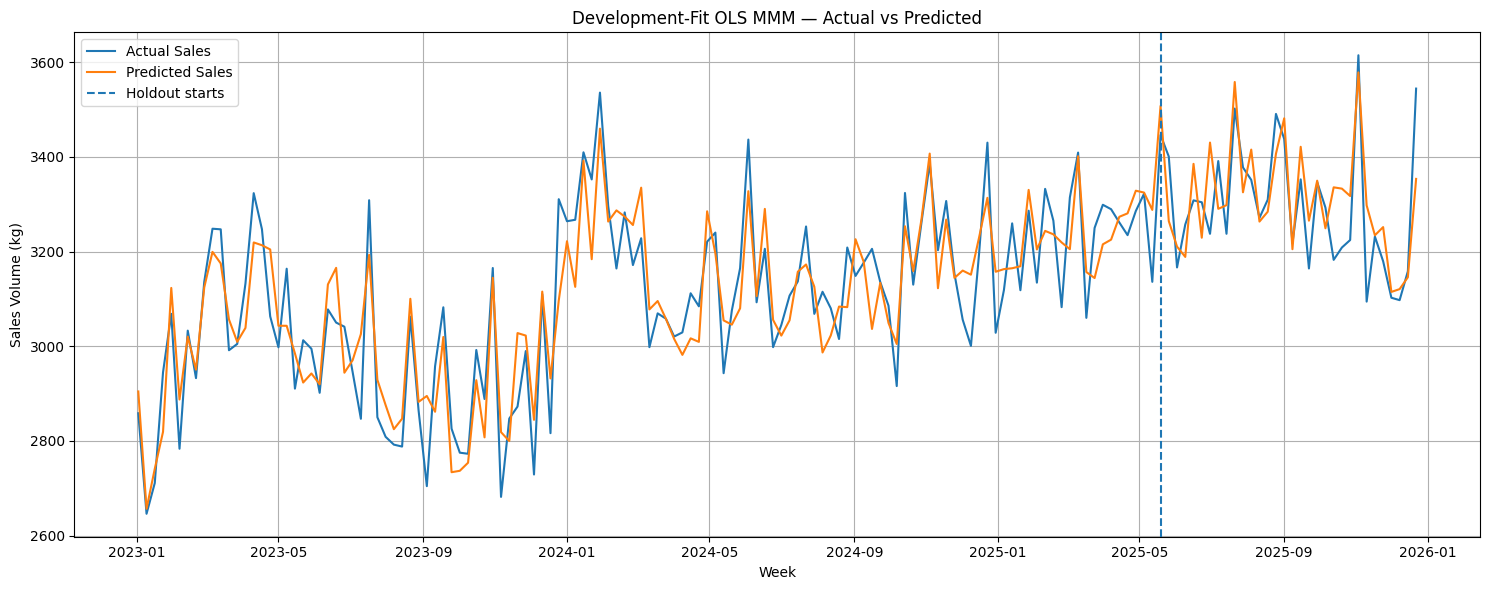


Validation outputs saved.


In [34]:
# ============================================================
# STEP 13 — FIT DEVELOPMENT OLS MMM + UNTOUCHED HOLDOUT
# ============================================================


# ------------------------------------------------------------
# 1. Chronological development / holdout split
# ------------------------------------------------------------

validation_train_df = (
    final_ols_df
    .iloc[:train_size]
    .copy()
)

validation_holdout_df = (
    final_ols_df
    .iloc[train_size:]
    .copy()
)

print("DEVELOPMENT / HOLDOUT SPLIT")
print("=" * 70)
print(
    f"Development observations : {len(validation_train_df)}"
)
print(
    f"Holdout observations      : {len(validation_holdout_df)}"
)
print(
    f"Development period       : "
    f"{validation_train_df['Week_Start'].min()} → "
    f"{validation_train_df['Week_Start'].max()}"
)
print(
    f"Holdout period            : "
    f"{validation_holdout_df['Week_Start'].min()} → "
    f"{validation_holdout_df['Week_Start'].max()}"
)

# ------------------------------------------------------------
# 2. Build matrices
# ------------------------------------------------------------

y_train = validation_train_df[sales_col].astype(float)
y_holdout = validation_holdout_df[sales_col].astype(float)

X_train = validation_train_df[ols_predictor_cols].astype(float)
X_holdout = validation_holdout_df[ols_predictor_cols].astype(float)

X_train = sm.add_constant(
    X_train,
    has_constant="add"
)

X_holdout = sm.add_constant(
    X_holdout,
    has_constant="add"
)

# ------------------------------------------------------------
# 3. Fit on DEVELOPMENT DATA ONLY
# ------------------------------------------------------------

final_ols_model = sm.OLS(
    y_train,
    X_train
).fit()

print(final_ols_model.summary())

# ------------------------------------------------------------
# 4. Coefficients
# ------------------------------------------------------------

ols_coefficients_df = pd.DataFrame({

    "Variable":
        final_ols_model.params.index,

    "Coefficient":
        final_ols_model.params.values,

    "Std_Error":
        final_ols_model.bse.values,

    "t_value":
        final_ols_model.tvalues.values,

    "p_value":
        final_ols_model.pvalues.values,

    "CI_Lower_95":
        final_ols_model.conf_int()[0].values,

    "CI_Upper_95":
        final_ols_model.conf_int()[1].values
})

print("\nDEVELOPMENT-SET OLS COEFFICIENTS")
display(
    ols_coefficients_df.round(5)
)

# ------------------------------------------------------------
# 5. Predict without refitting on holdout
# ------------------------------------------------------------

train_predictions = final_ols_model.predict(X_train)
holdout_predictions = final_ols_model.predict(X_holdout)

train_residuals = y_train - train_predictions
holdout_residuals = y_holdout - holdout_predictions

# ------------------------------------------------------------
# 6. Metrics
# ------------------------------------------------------------

def regression_metrics(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    residual = y_true - y_pred

    rmse = np.sqrt(
        np.mean(residual ** 2)
    )

    mae = np.mean(
        np.abs(residual)
    )

    mape = (
        np.mean(
            np.abs(
                residual /
                np.where(
                    y_true == 0,
                    1,
                    y_true
                )
            )
        )
        * 100
    )

    wape = (
        np.sum(np.abs(residual)) /
        np.sum(np.abs(y_true))
        * 100
        if np.sum(np.abs(y_true)) > 0
        else np.nan
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "WAPE (%)": wape
    }

train_metrics = regression_metrics(
    y_train,
    train_predictions
)

holdout_metrics = regression_metrics(
    y_holdout,
    holdout_predictions
)

validation_summary_df = pd.DataFrame({

    "Metric": [
        "RMSE",
        "MAE",
        "MAPE (%)",
        "WAPE (%)"
    ],

    "Development_Train": [
        train_metrics["RMSE"],
        train_metrics["MAE"],
        train_metrics["MAPE (%)"],
        train_metrics["WAPE (%)"]
    ],

    "Untouched_Holdout": [
        holdout_metrics["RMSE"],
        holdout_metrics["MAE"],
        holdout_metrics["MAPE (%)"],
        holdout_metrics["WAPE (%)"]
    ]
})

print("\nGENUINE OUT-OF-SAMPLE VALIDATION")
display(
    validation_summary_df.round(5)
)

print(
    f"\nDevelopment R-squared : "
    f"{final_ols_model.rsquared:.5f}"
)
print(
    f"Development Adjusted R² : "
    f"{final_ols_model.rsquared_adj:.5f}"
)

# ------------------------------------------------------------
# 7. Store train-fit predictions for the full timeline
# ------------------------------------------------------------

final_ols_results_df = final_ols_df.copy()

final_ols_results_df["Predicted_Sales"] = np.nan

final_ols_results_df.loc[
    :train_size - 1,
    "Predicted_Sales"
] = train_predictions

final_ols_results_df.loc[
    train_size:,
    "Predicted_Sales"
] = holdout_predictions

final_ols_results_df["Residual"] = (
    final_ols_results_df[sales_col]
    - final_ols_results_df["Predicted_Sales"]
)

final_ols_results_df["Absolute_Error"] = (
    final_ols_results_df["Residual"].abs()
)

final_ols_results_df["APE_Percent"] = (
    final_ols_results_df["Absolute_Error"] /
    np.where(
        final_ols_results_df[sales_col] == 0,
        1,
        final_ols_results_df[sales_col]
    )
    * 100
)

# ------------------------------------------------------------
# 8. Actual vs predicted with holdout boundary
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    final_ols_results_df["Week_Start"],
    final_ols_results_df[sales_col],
    label="Actual Sales"
)

plt.plot(
    final_ols_results_df["Week_Start"],
    final_ols_results_df["Predicted_Sales"],
    label="Predicted Sales"
)

holdout_start_date = (
    validation_holdout_df["Week_Start"].min()
)

plt.axvline(
    holdout_start_date,
    linestyle="--",
    label="Holdout starts"
)

plt.title(
    "Development-Fit OLS MMM — Actual vs Predicted"
)
plt.xlabel("Week")
plt.ylabel("Sales Volume (kg)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Save validation outputs
# ------------------------------------------------------------

ols_coefficients_df.to_csv(
    output_folder /
    "Consumer Brand_Development_OLS_Coefficients.csv",
    index=False
)

validation_summary_df.to_csv(
    output_folder /
    "Consumer Brand_Untouched_Holdout_Validation.csv",
    index=False
)

final_ols_results_df.to_csv(
    output_folder /
    "Consumer Brand_Development_OLS_Predictions.csv",
    index=False
)

print("\nValidation outputs saved.")


# Step 13A — Coefficient Direction Audit

**Why this step:** identify negative media coefficients or unexpected price signs that require investigation.

**Interpretation rule:** these are diagnostic flags. We do not force coefficients to have an expected sign merely because the sign is inconvenient.


In [35]:
# NOTE: `ols_coefficients_df` comes from the development/training-only OLS in Step 13.

# ============================================================
# STEP 13A — COEFFICIENT DIRECTION / BUSINESS RULE FLAGS
# ============================================================

# ------------------------------------------------------------
# 1. Add expected direction
# ------------------------------------------------------------

direction_check_df = ols_coefficients_df.copy()

direction_check_df["Expected_Direction"] = "Not Specified"

# Media variables should normally be positive
direction_check_df.loc[
    direction_check_df["Variable"].isin(final_media_cols),
    "Expected_Direction"
] = "Positive"

# Price should normally be negative
direction_check_df.loc[
    direction_check_df["Variable"] == "Price_Mean_Centered",
    "Expected_Direction"
] = "Negative"


# ------------------------------------------------------------
# 2. Flag unexpected directions
# ------------------------------------------------------------

def flag_coefficient_direction(row):

    variable = row["Variable"]
    coefficient = row["Coefficient"]

    if variable in final_media_cols:

        if coefficient < 0:
            return "FLAG — Negative Media Coefficient"
        else:
            return "OK"

    elif variable == "Price_Mean_Centered":

        if coefficient > 0:
            return "FLAG — Positive Price Coefficient"
        else:
            return "OK"

    else:
        return "Not Applicable"


direction_check_df["Direction_Flag"] = (
    direction_check_df.apply(
        flag_coefficient_direction,
        axis=1
    )
)


# ------------------------------------------------------------
# 3. Add significance context
# ------------------------------------------------------------

direction_check_df["Significant_5pct"] = (
    direction_check_df["p_value"] < 0.05
)


# ------------------------------------------------------------
# 4. Add combined interpretation
# ------------------------------------------------------------

def coefficient_interpretation(row):

    flag = row["Direction_Flag"]
    significant = row["Significant_5pct"]

    if "FLAG" in flag:

        if significant:
            return (
                "Unexpected direction and statistically "
                "significant — investigate"
            )
        else:
            return (
                "Unexpected direction but not statistically "
                "significant — investigate/stability check"
            )

    elif flag == "OK":

        if significant:
            return "Expected direction + statistically significant"
        else:
            return "Expected direction but not statistically significant"

    return "Not applicable"


direction_check_df["Interpretation"] = (
    direction_check_df.apply(
        coefficient_interpretation,
        axis=1
    )
)


# ------------------------------------------------------------
# 5. Display ONLY media + price first
# ------------------------------------------------------------

key_direction_df = direction_check_df[
    direction_check_df["Variable"].isin(
        final_media_cols + ["Price_Mean_Centered"]
    )
][
    [
        "Variable",
        "Coefficient",
        "Std_Error",
        "t_value",
        "p_value",
        "Expected_Direction",
        "Significant_5pct",
        "Direction_Flag",
        "Interpretation"
    ]
].copy()


print("\n============================================================")
print("MEDIA + PRICE COEFFICIENT DIRECTION CHECK")
print("============================================================")

display(
    key_direction_df.round(5)
)


# ------------------------------------------------------------
# 6. Show only flagged variables
# ------------------------------------------------------------

flagged_direction_df = key_direction_df[
    key_direction_df["Direction_Flag"].str.contains(
        "FLAG",
        na=False
    )
].copy()

print("\n============================================================")
print("FLAGGED COEFFICIENTS")
print("============================================================")

if len(flagged_direction_df) == 0:

    print(
        "No unexpected media or price coefficient directions detected."
    )

else:

    display(
        flagged_direction_df.round(5)
    )


# ------------------------------------------------------------
# 7. Count flags
# ------------------------------------------------------------

negative_media_count = (
    (
        key_direction_df["Direction_Flag"]
        == "FLAG — Negative Media Coefficient"
    )
    .sum()
)

positive_price_count = (
    (
        key_direction_df["Direction_Flag"]
        == "FLAG — Positive Price Coefficient"
    )
    .sum()
)

print("\nFlag Summary:")
print(
    f"Negative media coefficients : {negative_media_count}"
)

print(
    f"Positive price coefficients : {positive_price_count}"
)


# ------------------------------------------------------------
# 8. Save direction audit
# ------------------------------------------------------------

direction_check_df.to_csv(
    output_folder /
    "Consumer Brand_OLS_Coefficient_Direction_Audit.csv",
    index=False
)

flagged_direction_df.to_csv(
    output_folder /
    "Consumer Brand_OLS_Flagged_Coefficients.csv",
    index=False
)

print("\nSaved:")
print(
    output_folder /
    "Consumer Brand_OLS_Coefficient_Direction_Audit.csv"
)

print(
    output_folder /
    "Consumer Brand_OLS_Flagged_Coefficients.csv"
)


MEDIA + PRICE COEFFICIENT DIRECTION CHECK


,Variable,Coefficient,Std_Error,t_value,p_value,Expected_Direction,Significant_5pct,Direction_Flag,Interpretation
1,Print_Saturated,23.26277,35.07708,0.66319,0.50864,Positive,False,OK,Expected direction but not statistically signi...
2,TV_Saturated,47.73947,24.16517,1.97555,0.05078,Positive,False,OK,Expected direction but not statistically signi...
3,Meta_Saturated,87.60749,31.47868,2.78307,0.00637,Positive,True,OK,Expected direction + statistically significant
4,Instagram_Saturated,214.05331,46.79503,4.57427,0.00001,Positive,True,OK,Expected direction + statistically significant
5,YouTube_Saturated,131.67201,32.72949,4.02304,0.00011,Positive,True,OK,Expected direction + statistically significant
6,Price_Mean_Centered,0.34414,0.30314,1.13525,0.25881,Negative,False,FLAG — Positive Price Coefficient,Unexpected direction but not statistically sig...



FLAGGED COEFFICIENTS


,Variable,Coefficient,Std_Error,t_value,p_value,Expected_Direction,Significant_5pct,Direction_Flag,Interpretation
6,Price_Mean_Centered,0.34414,0.30314,1.13525,0.25881,Negative,False,FLAG — Positive Price Coefficient,Unexpected direction but not statistically sig...



Flag Summary:
Negative media coefficients : 0
Positive price coefficients : 1

Saved:
/content/mmm_outputs/Consumer Brand_OLS_Coefficient_Direction_Audit.csv
/content/mmm_outputs/Consumer Brand_OLS_Flagged_Coefficients.csv


In [36]:
# ============================================================
# STEP 14 — DIAGNOSE COEFFICIENT SIGN PROBLEMS
# ============================================================

# ------------------------------------------------------------
# DEVELOPMENT-ONLY DIAGNOSTICS
# ------------------------------------------------------------
# The untouched holdout is not used to investigate or revise the
# model. This prevents test-set contamination during model development.

train_diagnostic_df = (
    final_ols_df
    .iloc[:train_size]
    .copy()
)

# ------------------------------------------------------------
# 1. Define final OLS predictors
# ------------------------------------------------------------

diagnostic_predictors = [
    col for col in ols_predictor_cols
    if col in train_diagnostic_df.columns
]

X_diag = train_diagnostic_df[
    diagnostic_predictors
].astype(float).copy()


# ------------------------------------------------------------
# 2. VIF — MULTICOLLINEARITY CHECK
# ------------------------------------------------------------

vif_rows = []

# VIF is calculated without the intercept
for column in X_diag.columns:

    other_columns = [
        col
        for col in X_diag.columns
        if col != column
    ]

    X_other = X_diag[other_columns]

    X_other = sm.add_constant(
        X_other,
        has_constant="add"
    )

    model_vif = sm.OLS(
        X_diag[column],
        X_other
    ).fit()

    r_squared = model_vif.rsquared

    if r_squared >= 0.999999:
        vif_value = np.inf
    else:
        vif_value = 1 / (1 - r_squared)

    vif_rows.append({

        "Variable": column,

        "VIF": vif_value,

        "R_squared_explained": r_squared
    })


vif_df = pd.DataFrame(vif_rows)

vif_df["VIF_Flag"] = np.select(
    [
        np.isinf(vif_df["VIF"]),
        vif_df["VIF"] >= 10,
        vif_df["VIF"] >= 5
    ],
    [
        "SEVERE — Infinite / Near Perfect Collinearity",
        "HIGH — Investigate",
        "MODERATE — Monitor"
    ],
    default="OK"
)

vif_df = vif_df.sort_values(
    "VIF",
    ascending=False
)

print("\n============================================================")
print("VIF DIAGNOSTIC")
print("============================================================")

display(
    vif_df.round(4)
)


# ------------------------------------------------------------
# 3. Correlation among FINAL TRANSFORMED MEDIA VARIABLES
# ------------------------------------------------------------

media_corr_df = train_diagnostic_df[
    final_media_cols
].corr()

print("\n============================================================")
print("FINAL MEDIA — CORRELATION MATRIX")
print("============================================================")

display(
    media_corr_df.round(3)
)


# ------------------------------------------------------------
# 4. Identify highly correlated media pairs
# ------------------------------------------------------------

high_corr_rows = []

for i in range(len(final_media_cols)):

    for j in range(i + 1, len(final_media_cols)):

        col_1 = final_media_cols[i]
        col_2 = final_media_cols[j]

        correlation = media_corr_df.loc[
            col_1,
            col_2
        ]

        if abs(correlation) >= 0.70:

            high_corr_rows.append({

                "Variable_1": col_1,

                "Variable_2": col_2,

                "Correlation": correlation,

                "Absolute_Correlation":
                    abs(correlation),

                "Flag":
                    "HIGH MEDIA OVERLAP"
            })


high_media_corr_df = pd.DataFrame(
    high_corr_rows
)

print("\n============================================================")
print("HIGHLY CORRELATED MEDIA PAIRS (|r| >= 0.70)")
print("============================================================")

if len(high_media_corr_df) > 0:
    display(
        high_media_corr_df.sort_values(
            "Absolute_Correlation",
            ascending=False
        ).round(4)
    )
else:
    print(
        "No media pairs with absolute correlation >= 0.70."
    )


# ------------------------------------------------------------
# 5. Correlation of price with all predictors
# ------------------------------------------------------------

price_corr = train_diagnostic_df[
    diagnostic_predictors
].corr()["Price_Mean_Centered"].drop(
    "Price_Mean_Centered"
).sort_values()

price_corr_df = price_corr.reset_index()

price_corr_df.columns = [
    "Variable",
    "Correlation_with_Price"
]

price_corr_df["Abs_Correlation"] = (
    price_corr_df["Correlation_with_Price"]
    .abs()
)

price_corr_df["Flag"] = np.where(
    price_corr_df["Abs_Correlation"] >= 0.70,
    "HIGH PRICE RELATIONSHIP",
    "OK"
)

print("\n============================================================")
print("PRICE CORRELATION DIAGNOSTIC")
print("============================================================")

display(
    price_corr_df.round(4)
)


# ------------------------------------------------------------
# 6. Price vs Sales correlation
# ------------------------------------------------------------

price_sales_corr = train_diagnostic_df[
    [
        sales_col,
        "Price_Mean_Centered"
    ]
].corr().iloc[0, 1]

print(
    f"\nPrice vs Sales correlation: "
    f"{price_sales_corr:.4f}"
)


# ------------------------------------------------------------
# 7. Re-run OLS and create coefficient direction audit
# ------------------------------------------------------------

X_full = sm.add_constant(
    train_diagnostic_df[diagnostic_predictors],
    has_constant="add"
)

y_full = train_diagnostic_df[
    sales_col
].astype(float)

diagnostic_ols_model = sm.OLS(
    y_full,
    X_full
).fit()

diagnostic_coefficients_df = pd.DataFrame({

    "Variable":
        diagnostic_ols_model.params.index,

    "Coefficient":
        diagnostic_ols_model.params.values,

    "p_value":
        diagnostic_ols_model.pvalues.values,

    "Std_Error":
        diagnostic_ols_model.bse.values,

    "t_value":
        diagnostic_ols_model.tvalues.values
})


# ------------------------------------------------------------
# 8. Apply expected-direction rules
# ------------------------------------------------------------

def expected_direction(variable):

    if variable in final_media_cols:
        return "Positive"

    if variable == "Price_Mean_Centered":
        return "Negative"

    return "Not Specified"


diagnostic_coefficients_df[
    "Expected_Direction"
] = diagnostic_coefficients_df[
    "Variable"
].apply(
    expected_direction
)


def direction_flag(row):

    variable = row["Variable"]
    coefficient = row["Coefficient"]

    if variable in final_media_cols:

        if coefficient < 0:
            return "FLAG — Negative Media"

        return "OK"

    if variable == "Price_Mean_Centered":

        if coefficient > 0:
            return "FLAG — Positive Price"

        return "OK"

    return "Not Applicable"


diagnostic_coefficients_df[
    "Direction_Flag"
] = diagnostic_coefficients_df.apply(
    direction_flag,
    axis=1
)


print("\n============================================================")
print("CURRENT COEFFICIENT DIRECTION")
print("============================================================")

display(
    diagnostic_coefficients_df[
        diagnostic_coefficients_df["Variable"].isin(
            final_media_cols +
            ["Price_Mean_Centered"]
        )
    ].round(5)
)


# ------------------------------------------------------------
# 9. Summarize flagged variables
# ------------------------------------------------------------

flagged_variables_df = diagnostic_coefficients_df[
    diagnostic_coefficients_df["Direction_Flag"].str.contains(
        "FLAG",
        na=False
    )
].copy()

print("\n============================================================")
print("FLAGGED VARIABLES REQUIRING INVESTIGATION")
print("============================================================")

if len(flagged_variables_df) > 0:

    display(
        flagged_variables_df[
            [
                "Variable",
                "Coefficient",
                "p_value",
                "Expected_Direction",
                "Direction_Flag"
            ]
        ].round(5)
    )

else:

    print(
        "No negative media or positive price coefficients."
    )


# ------------------------------------------------------------
# 10. Cross-reference flagged variables with VIF
# ------------------------------------------------------------

flagged_vif_df = flagged_variables_df.merge(
    vif_df[
        [
            "Variable",
            "VIF",
            "VIF_Flag"
        ]
    ],
    on="Variable",
    how="left"
)

print("\n============================================================")
print("FLAGGED VARIABLES + VIF")
print("============================================================")

display(
    flagged_vif_df.round(5)
)


# ------------------------------------------------------------
# 11. Cross-reference flagged media with media correlations
# ------------------------------------------------------------

flagged_media = [
    variable
    for variable in flagged_variables_df["Variable"]
    if variable in final_media_cols
]

flagged_media_overlap_rows = []

for flagged_media_var in flagged_media:

    for other_media_var in final_media_cols:

        if flagged_media_var == other_media_var:
            continue

        correlation = media_corr_df.loc[
            flagged_media_var,
            other_media_var
        ]

        if abs(correlation) >= 0.50:

            flagged_media_overlap_rows.append({

                "Flagged_Media":
                    flagged_media_var,

                "Other_Media":
                    other_media_var,

                "Correlation":
                    correlation,

                "Absolute_Correlation":
                    abs(correlation)
            })


flagged_media_overlap_df = pd.DataFrame(
    flagged_media_overlap_rows
)

print("\n============================================================")
print("OVERLAP AROUND FLAGGED MEDIA VARIABLES")
print("============================================================")

if len(flagged_media_overlap_df) > 0:

    display(
        flagged_media_overlap_df.sort_values(
            "Absolute_Correlation",
            ascending=False
        ).round(4)
    )

else:

    print(
        "No strong pairwise overlap around flagged media."
    )


# ------------------------------------------------------------
# 12. Save diagnostic outputs
# ------------------------------------------------------------

vif_df.to_csv(
    output_folder /
    "Consumer Brand_OLS_VIF_Diagnostic.csv",
    index=False
)

media_corr_df.to_csv(
    output_folder /
    "Consumer Brand_Final_Media_Correlation_Matrix.csv"
)

price_corr_df.to_csv(
    output_folder /
    "Consumer Brand_Price_Correlation_Diagnostic.csv",
    index=False
)

diagnostic_coefficients_df.to_csv(
    output_folder /
    "Consumer Brand_Coefficient_Direction_Diagnostic.csv",
    index=False
)

flagged_vif_df.to_csv(
    output_folder /
    "Consumer Brand_Flagged_Coefficients_With_VIF.csv",
    index=False
)

print("\nDiagnostic files saved.")


VIF DIAGNOSTIC


,Variable,VIF,R_squared_explained,VIF_Flag
14,Fourier_Sin_1,2.3597,0.5762,OK
2,Meta_Saturated,2.3116,0.5674,OK
1,TV_Saturated,1.7637,0.4330,OK
4,YouTube_Saturated,1.5534,0.3562,OK
15,Fourier_Cos_1,1.5220,0.3430,OK
0,Print_Saturated,1.5200,0.3421,OK
3,Instagram_Saturated,1.3334,0.2501,OK
11,TradePromo_Retailer_Display,1.2923,0.2262,OK
13,Trend,1.1788,0.1517,OK
8,Holiday_Christmas,1.1601,0.1380,OK



FINAL MEDIA — CORRELATION MATRIX


,Print_Saturated,TV_Saturated,Meta_Saturated,Instagram_Saturated,YouTube_Saturated
Print_Saturated,1.000,0.131,0.145,0.355,-0.022
TV_Saturated,0.131,1.000,0.408,0.270,0.145
Meta_Saturated,0.145,0.408,1.000,-0.021,-0.063
Instagram_Saturated,0.355,0.270,-0.021,1.000,0.124
YouTube_Saturated,-0.022,0.145,-0.063,0.124,1.000



HIGHLY CORRELATED MEDIA PAIRS (|r| >= 0.70)
No media pairs with absolute correlation >= 0.70.

PRICE CORRELATION DIAGNOSTIC


...


FLAGGED VARIABLES REQUIRING INVESTIGATION


,Variable,Coefficient,p_value,Expected_Direction,Direction_Flag
6,Price_Mean_Centered,0.34414,0.25881,Negative,FLAG — Positive Price



FLAGGED VARIABLES + VIF


,Variable,Coefficient,p_value,Std_Error,t_value,Expected_Direction,Direction_Flag,VIF,VIF_Flag
0,Price_Mean_Centered,0.34414,0.25881,0.30314,1.13525,Negative,FLAG — Positive Price,1.11686,OK



OVERLAP AROUND FLAGGED MEDIA VARIABLES
No strong pairwise overlap around flagged media.

Diagnostic files saved.


In [37]:
# ============================================================
# STEP 15 — COEFFICIENT STABILITY + DIAGNOSTIC FLAGS
#               TRAINING / DEVELOPMENT DATA ONLY
# ============================================================

analysis_df = (
    final_ols_df
    .iloc[:train_size]
    .copy()
)

media_variables = [
    col
    for col in final_media_cols
    if col in analysis_df.columns
]

control_variables = [
    col
    for col in control_cols
    if col in analysis_df.columns
]

# ------------------------------------------------------------
# 1. OLS helper
# ------------------------------------------------------------

def fit_sensitivity_model(df, predictor_list):

    X = df[predictor_list].astype(float)

    X = sm.add_constant(
        X,
        has_constant="add"
    )

    y = df[sales_col].astype(float)

    return sm.OLS(y, X).fit()

# ------------------------------------------------------------
# 2. MEDIA STABILITY
# ------------------------------------------------------------

media_only_model = fit_sensitivity_model(
    analysis_df,
    media_variables
)

media_price_model = fit_sensitivity_model(
    analysis_df,
    media_variables + [
        "Price_Mean_Centered"
    ]
)

media_controls_model = fit_sensitivity_model(
    analysis_df,
    media_variables + control_variables
)

media_stability_rows = []

for variable in media_variables:

    coef_media_only = media_only_model.params.get(
        variable,
        np.nan
    )

    coef_media_price = media_price_model.params.get(
        variable,
        np.nan
    )

    coef_full = media_controls_model.params.get(
        variable,
        np.nan
    )

    p_full = media_controls_model.pvalues.get(
        variable,
        np.nan
    )

    def coefficient_sign(value):

        if pd.isna(value):
            return "N/A"

        if value > 0:
            return "Positive"

        if value < 0:
            return "Negative"

        return "Zero"

    signs = [
        coefficient_sign(coef_media_only),
        coefficient_sign(coef_media_price),
        coefficient_sign(coef_full)
    ]

    valid_signs = [
        sign
        for sign in signs
        if sign not in ["N/A", "Zero"]
    ]

    sign_reversal = len(set(valid_signs)) > 1

    if (
        not pd.isna(coef_media_only)
        and abs(coef_media_only) > 1e-10
    ):

        change_pct = (
            abs(
                (coef_full - coef_media_only)
                / coef_media_only
            )
            * 100
        )

    else:

        change_pct = np.nan

    if sign_reversal:
        direction_flag = "FLAG — Sign Reversal"
    elif coef_full < 0:
        direction_flag = "FLAG — Negative Media Coefficient"
    else:
        direction_flag = "OK"

    if pd.isna(change_pct):
        stability_flag = "Cannot Assess"
    elif change_pct >= 100:
        stability_flag = "FLAG — Very High Change"
    elif change_pct >= 50:
        stability_flag = "FLAG — High Change"
    elif change_pct >= 25:
        stability_flag = "Monitor — Moderate Change"
    else:
        stability_flag = "OK"

    media_stability_rows.append({

        "Variable": variable,

        "Coefficient_Media_Only": coef_media_only,

        "Coefficient_Media_Price": coef_media_price,

        "Coefficient_Full": coef_full,

        "Full_Model_p_value": p_full,

        "Sign_Media_Only": signs[0],

        "Sign_Media_Price": signs[1],

        "Sign_Full": signs[2],

        "Sign_Reversal": sign_reversal,

        "Change_Media_Only_to_Full_%": change_pct,

        "Direction_Flag": direction_flag,

        "Stability_Flag": stability_flag
    })

media_stability_df = pd.DataFrame(
    media_stability_rows
)

print("\nMEDIA COEFFICIENT STABILITY — TRAINING DATA")
display(
    media_stability_df.round(5)
)

# ------------------------------------------------------------
# 3. PRICE NESTED-MODEL ANALYSIS
# ------------------------------------------------------------

price_models = []

price_only_model = fit_sensitivity_model(
    analysis_df,
    ["Price_Mean_Centered"]
)

price_controls_model = fit_sensitivity_model(
    analysis_df,
    ["Price_Mean_Centered"] + [
        col
        for col in control_variables
        if col != "Price_Mean_Centered"
    ]
)

price_full_model = fit_sensitivity_model(
    analysis_df,
    media_variables + control_variables
)

for label, model in [

    ("Price Only", price_only_model),

    ("Price + Controls", price_controls_model),

    ("Price + All Media + Controls", price_full_model)

]:

    price_models.append({

        "Model": label,

        "Price_Coefficient": model.params.get(
            "Price_Mean_Centered",
            np.nan
        ),

        "Price_p_value": model.pvalues.get(
            "Price_Mean_Centered",
            np.nan
        ),

        "R_squared": model.rsquared,

        "AIC": model.aic
    })

price_nested_df = pd.DataFrame(
    price_models
)

price_nested_df["Price_Direction_Flag"] = np.where(
    price_nested_df["Price_Coefficient"] > 0,
    "FLAG — Positive Price",
    "OK"
)

price_nested_df["Price_Significance"] = np.where(
    price_nested_df["Price_p_value"] < 0.05,
    "Significant at 5%",
    "Not Significant at 5%"
)

print("\nPRICE NESTED-MODEL ANALYSIS — TRAINING DATA")
display(
    price_nested_df.round(5)
)

# ------------------------------------------------------------
# 4. Summary and save
# ------------------------------------------------------------

negative_media_count = (
    media_stability_df["Coefficient_Full"] < 0
).sum()

print(
    f"\nNegative media coefficients in the full training specification: "
    f"{negative_media_count} of {len(media_stability_df)}"
)

print(
    "These are diagnostic flags; coefficients are not forced to a desired sign."
)

media_stability_df.to_csv(
    output_folder /
    "Consumer Brand_Media_Coefficient_Stability_TrainingOnly.csv",
    index=False
)

price_nested_df.to_csv(
    output_folder /
    "Consumer Brand_Price_Nested_Model_TrainingOnly.csv",
    index=False
)

print("\nTraining-only stability outputs saved.")



MEDIA COEFFICIENT STABILITY — TRAINING DATA


,Variable,Coefficient_Media_Only,Coefficient_Media_Price,Coefficient_Full,Full_Model_p_value,Sign_Media_Only,Sign_Media_Price,Sign_Full,Sign_Reversal,Change_Media_Only_to_Full_%,Direction_Flag,Stability_Flag
0,Print_Saturated,-53.31037,-53.65250,23.26277,0.50864,Negative,Negative,Positive,True,143.63648,FLAG — Sign Reversal,FLAG — Very High Change
1,TV_Saturated,-6.17333,-6.17159,47.73947,0.05078,Negative,Negative,Positive,True,873.31849,FLAG — Sign Reversal,FLAG — Very High Change
2,Meta_Saturated,-12.05001,-11.89815,87.60749,0.00637,Negative,Negative,Positive,True,827.03237,FLAG — Sign Reversal,FLAG — Very High Change
3,Instagram_Saturated,245.06824,245.76232,214.05331,0.00001,Positive,Positive,Positive,False,12.65563,OK,OK
4,YouTube_Saturated,111.34760,111.49518,131.67201,0.00011,Positive,Positive,Positive,False,18.25312,OK,OK



PRICE NESTED-MODEL ANALYSIS — TRAINING DATA


,Model,Price_Coefficient,Price_p_value,R_squared,AIC,Price_Direction_Flag,Price_Significance
0,Price Only,-0.31091,0.59888,0.00227,1647.04790,OK,Not Significant at 5%
1,Price + Controls,0.05646,0.88577,0.62113,1546.98101,FLAG — Positive Price,Not Significant at 5%
2,Price + All Media + Controls,0.34414,0.25881,0.79284,1482.12414,FLAG — Positive Price,Not Significant at 5%



Negative media coefficients in the full training specification: 0 of 5
These are diagnostic flags; coefficients are not forced to a desired sign.

Training-only stability outputs saved.


# Step 17 — Final Full-Data Historical Refit After the Validation Gate

**Why this step:** after the transformation and model specification have been selected and the untouched holdout has been evaluated, refit the locked specification on all available history. This creates the historical model needed for contribution, ROAS, response curves, and later optimization.

**Important:** this model is **not** used to claim out-of-sample performance. Step 13 remains the genuine holdout validation.


In [38]:
# ============================================================
# STEP 17 — FINAL FULL-DATA HISTORICAL REFIT
# ============================================================

# This refit is intentionally AFTER holdout evaluation and diagnostics.
# It is for historical contribution / ROAS work, not validation.


# ------------------------------------------------------------
# 1. Locked predictor specification on all available history
# ------------------------------------------------------------

historical_y = (
    final_ols_df[sales_col]
    .astype(float)
)

historical_X = (
    final_ols_df[ols_predictor_cols]
    .astype(float)
)

historical_X = sm.add_constant(
    historical_X,
    has_constant="add"
)

# ------------------------------------------------------------
# 2. Refit on all history
# ------------------------------------------------------------

full_data_ols_model = sm.OLS(
    historical_y,
    historical_X
).fit()

print("FINAL FULL-DATA HISTORICAL MMM")
print("=" * 70)
print(full_data_ols_model.summary())

# ------------------------------------------------------------
# 3. Coefficients for downstream contribution analysis
# ------------------------------------------------------------

full_data_ols_coefficients_df = pd.DataFrame({

    "Variable":
        full_data_ols_model.params.index,

    "Coefficient":
        full_data_ols_model.params.values,

    "Std_Error":
        full_data_ols_model.bse.values,

    "t_value":
        full_data_ols_model.tvalues.values,

    "p_value":
        full_data_ols_model.pvalues.values,

    "CI_Lower_95":
        full_data_ols_model.conf_int()[0].values,

    "CI_Upper_95":
        full_data_ols_model.conf_int()[1].values
})

display(
    full_data_ols_coefficients_df.round(5)
)

# ------------------------------------------------------------
# 4. Historical fit summary — descriptive only
# ------------------------------------------------------------

historical_fitted_sales = (
    full_data_ols_model.fittedvalues
)

historical_residuals = (
    historical_y - historical_fitted_sales
)

historical_fit_summary_df = pd.DataFrame({

    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "RMSE",
        "MAE",
        "MAPE (%)",
        "AIC",
        "BIC"
    ],

    "Value": [

        full_data_ols_model.rsquared,

        full_data_ols_model.rsquared_adj,

        np.sqrt(
            np.mean(
                historical_residuals ** 2
            )
        ),

        np.mean(
            np.abs(
                historical_residuals
            )
        ),

        np.mean(
            np.abs(
                historical_residuals /
                np.where(
                    historical_y == 0,
                    1,
                    historical_y
                )
            )
        ) * 100,

        full_data_ols_model.aic,

        full_data_ols_model.bic
    ]
})

print("\nFULL-HISTORY FIT — DESCRIPTIVE / HISTORICAL ONLY")
display(
    historical_fit_summary_df.round(5)
)

# ------------------------------------------------------------
# 5. Save historical model outputs
# ------------------------------------------------------------

full_data_ols_coefficients_df.to_csv(
    output_folder /
    "Consumer Brand_Final_FullData_OLS_Coefficients.csv",
    index=False
)

historical_fit_summary_df.to_csv(
    output_folder /
    "Consumer Brand_Final_FullData_OLS_Historical_Fit.csv",
    index=False
)

print(
    "\nLocked historical model ready for the next stage: "
    "weekly contribution decomposition, incremental revenue, "
    "ROAS/ROI, response curves, and budget optimization."
)


FINAL FULL-DATA HISTORICAL MMM
                            OLS Regression Results                            
Dep. Variable:       Sales_Volume_kgs   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     37.61
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           1.72e-42
Time:                        09:36:28   Log-Likelihood:                -910.77
No. Observations:                 156   AIC:                             1856.
Df Residuals:                     139   BIC:                             1907.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

,Variable,Coefficient,Std_Error,t_value,p_value,CI_Lower_95,CI_Upper_95
0,const,2629.62177,26.79364,98.14350,0.00000,2576.64598,2682.59756
1,Print_Saturated,19.10176,29.31451,0.65161,0.51573,-38.85824,77.06175
2,TV_Saturated,39.47751,19.24764,2.05103,0.04214,1.42150,77.53351
3,Meta_Saturated,107.47986,23.82197,4.51180,0.00001,60.37959,154.58014
4,Instagram_Saturated,194.48306,38.89757,4.99988,0.00000,117.57564,271.39047
5,YouTube_Saturated,126.08824,25.74290,4.89798,0.00000,75.18996,176.98652
6,Price_Mean_Centered,0.14981,0.26065,0.57477,0.56638,-0.36553,0.66515
7,Holiday_Diwali,352.82276,53.38013,6.60963,0.00000,247.28076,458.36477
8,Holiday_Holi,-44.63401,53.59606,-0.83279,0.40639,-150.60294,61.33492
9,Holiday_Christmas,-29.94731,38.82359,-0.77137,0.44180,-106.70844,46.81382



FULL-HISTORY FIT — DESCRIPTIVE / HISTORICAL ONLY


,Metric,Value
0,R-squared,0.81236
1,Adjusted R-squared,0.79076
2,RMSE,83.04164
3,MAE,68.65084
4,MAPE (%),2.20117
5,AIC,1855.54358
6,BIC,1907.39114



Locked historical model ready for the next stage: weekly contribution decomposition, incremental revenue, ROAS/ROI, response curves, and budget optimization.


Step 13A — OLS Assumption Testing and Model Adequacy

Why this step is required:
OLS gives reliable coefficient estimates under the core regression assumptions, while several assumptions mainly affect the validity of standard errors, hypothesis tests, and confidence intervals. Because this is weekly time-series MMM data, we particularly need to check functional form, residual autocorrelation, constant variance, residual distribution, and multicollinearity.

In [39]:
# ============================================================
# STEP 13A — OLS ASSUMPTION TESTING & MODEL ADEQUACY
# ============================================================
#
# IMPORTANT:
# All tests below use DEVELOPMENT/TRAINING DATA ONLY.
# The final holdout remains untouched.
#
# This step checks:
#   1. Linear specification / functional form
#   2. No perfect multicollinearity + VIF
#   3. Independence / no residual autocorrelation
#   4. Homoscedasticity
#   5. Residual normality
#   6. Mean-zero residuals
#   7. Influential observations
#   8. Exogeneity / zero conditional error mean
#
# Statistical tests use alpha = 5%.
# p-value > 0.05 -> no significant evidence of violation.
# This does NOT prove the assumption is perfectly true.
# ============================================================







# ============================================================
# 1. SETTINGS
# ============================================================

ASSUMPTION_ALPHA = 0.05

# Practical diagnostic thresholds.
# These are conventions, not absolute mathematical rules.

VIF_WARNING_THRESHOLD = 5.0

COOKS_D_THRESHOLD_MULTIPLIER = 4.0


# ============================================================
# 2. USE DEVELOPMENT DATA ONLY
# ============================================================

# final_ols_model was fitted on validation_train_df in Step 13.
# Therefore its residuals and fitted values are development-only.

ols_model = final_ols_model

y_dev = (
    validation_train_df[
        sales_col
    ]
    .astype(float)
)

X_dev = (
    validation_train_df[
        ols_predictor_cols
    ]
    .astype(float)
)

X_dev_const = sm.add_constant(
    X_dev,
    has_constant="add"
)

residuals = (
    ols_model.resid
)

fitted_values = (
    ols_model.fittedvalues
)

n = len(y_dev)

# Number of estimated parameters including intercept
k = len(
    ols_model.params
)


print("\n============================================================")
print("STEP 13A — OLS ASSUMPTION TESTING")
print("============================================================")

print(
    f"Observations used: {n}"
)

print(
    "Dataset used: DEVELOPMENT / TRAINING DATA ONLY"
)

print(
    f"Significance level: α = {ASSUMPTION_ALPHA}"
)


# ============================================================
# 3. RESULT STORAGE
# ============================================================

assumption_results = []


def add_result(
    assumption,
    test,
    statistic,
    p_value,
    status,
    interpretation
):

    assumption_results.append({

        "Assumption":
            assumption,

        "Test":
            test,

        "Statistic":
            statistic,

        "P_Value":
            p_value,

        "Status":
            status,

        "Interpretation":
            interpretation
    })


# ============================================================
# ASSUMPTION 1
# LINEARITY / CORRECT FUNCTIONAL FORM
# ============================================================

print(
    "\n1. LINEARITY / FUNCTIONAL FORM"
)

print("-" * 70)

print(
    "Why required:"
)

print(
    "The expected value of sales should be appropriately represented "
    "by the predictors included in the OLS specification."
)

# ------------------------------------------------------------
# Ramsey RESET
# ------------------------------------------------------------

try:

    reset_result = linear_reset(
        ols_model,
        power=2,
        use_f=True
    )

    reset_stat = float(
        reset_result.fvalue
    )

    reset_p = float(
        reset_result.pvalue
    )

    if reset_p > ASSUMPTION_ALPHA:

        reset_status = (
            "SATISFIED"
        )

        reset_interpretation = (
            "No statistically significant evidence of "
            "functional-form misspecification from RESET."
        )

    else:

        reset_status = (
            "NOT SATISFIED"
        )

        reset_interpretation = (
            "RESET indicates possible functional-form "
            "misspecification. Review transformations, "
            "controls, seasonality, and omitted nonlinear terms."
        )

    add_result(

        "Linearity / Functional Form",

        "Ramsey RESET",

        reset_stat,

        reset_p,

        reset_status,

        reset_interpretation
    )

    print(
        f"RESET F-statistic : {reset_stat:.4f}"
    )

    print(
        f"RESET p-value     : {reset_p:.4f}"
    )

    print(
        f"Status            : {reset_status}"
    )

except Exception as e:

    print(
        f"RESET test could not be calculated: {e}"
    )

    add_result(

        "Linearity / Functional Form",

        "Ramsey RESET",

        np.nan,

        np.nan,

        "NOT TESTED",

        str(e)
    )


# ============================================================
# ASSUMPTION 2
# NO PERFECT MULTICOLLINEARITY
# ============================================================

print(
    "\n2. NO PERFECT MULTICOLLINEARITY"
)

print("-" * 70)

print(
    "Why required:"
)

print(
    "OLS cannot uniquely estimate coefficients when predictors "
    "are exact linear combinations of one another."
)

# ------------------------------------------------------------
# Matrix rank check
# ------------------------------------------------------------

design_matrix = (
    X_dev_const
    .to_numpy(
        dtype=float
    )
)

matrix_rank = np.linalg.matrix_rank(
    design_matrix
)

number_of_columns = (
    design_matrix.shape[1]
)

rank_condition_satisfied = (
    matrix_rank ==
    number_of_columns
)

if rank_condition_satisfied:

    rank_status = (
        "SATISFIED"
    )

    rank_interpretation = (
        "Design matrix has full column rank; "
        "no perfect linear dependency detected."
    )

else:

    rank_status = (
        "NOT SATISFIED"
    )

    rank_interpretation = (
        "Design matrix is rank-deficient; "
        "at least one exact linear dependency exists."
    )

print(
    f"Design matrix rank : {matrix_rank}"
)

print(
    f"Number of columns  : {number_of_columns}"
)

print(
    f"Status             : {rank_status}"
)

add_result(

    "No Perfect Multicollinearity",

    "Design Matrix Rank",

    matrix_rank,

    np.nan,

    rank_status,

    rank_interpretation
)


# ============================================================
# ASSUMPTION 3
# MULTICOLLINEARITY SHOULD NOT BE EXCESSIVE
# ============================================================

print(
    "\n3. MULTICOLLINEARITY — VIF"
)

print("-" * 70)

print(
    "Why required:"
)

print(
    "Very high correlation among predictors can make coefficients "
    "unstable and inflate their standard errors."
)

# ------------------------------------------------------------
# VIF
# ------------------------------------------------------------

vif_rows = []

for i, variable in enumerate(
    X_dev_const.columns
):

    # Intercept VIF is not meaningful for interpretation.
    if variable == "const":
        continue

    vif_value = (
        variance_inflation_factor(
            X_dev_const.to_numpy(
                dtype=float
            ),
            i
        )
    )

    vif_rows.append({

        "Variable":
            variable,

        "VIF":
            vif_value
    })


vif_df = (
    pd.DataFrame(
        vif_rows
    )
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

max_vif = (
    vif_df["VIF"].max()
)

if max_vif < VIF_WARNING_THRESHOLD:

    vif_status = (
        "SATISFIED"
    )

    vif_interpretation = (
        f"Maximum VIF is below {VIF_WARNING_THRESHOLD}; "
        "no strong multicollinearity signal."
    )

else:

    vif_status = (
        "NOT SATISFIED"
    )

    vif_interpretation = (
        f"At least one predictor has VIF >= "
        f"{VIF_WARNING_THRESHOLD}; investigate "
        "predictor overlap and coefficient stability."
    )

print(
    f"Maximum VIF : {max_vif:.4f}"
)

print(
    f"Status       : {vif_status}"
)

display(
    vif_df.round(4)
)

add_result(

    "No Excessive Multicollinearity",

    "Variance Inflation Factor",

    max_vif,

    np.nan,

    vif_status,

    vif_interpretation
)


# ============================================================
# ASSUMPTION 4
# INDEPENDENT ERRORS / NO AUTOCORRELATION
# ============================================================

print(
    "\n4. INDEPENDENT ERRORS / NO AUTOCORRELATION"
)

print("-" * 70)

print(
    "Why required:"
)

print(
    "Your MMM is weekly time-series data. If residuals are correlated "
    "across weeks, OLS coefficient inference can become unreliable "
    "and the model may be missing temporal structure."
)

# ------------------------------------------------------------
# 4A. Durbin-Watson
# ------------------------------------------------------------

dw_stat = float(
    durbin_watson(
        residuals
    )
)

# DW around 2 indicates little first-order autocorrelation.
# This is used as a diagnostic rather than a strict pass/fail test.

dw_lower = 1.50
dw_upper = 2.50

if (
    dw_lower <= dw_stat <= dw_upper
):

    dw_status = (
        "SATISFIED"
    )

    dw_interpretation = (
        "Durbin-Watson is within the practical "
        "1.5–2.5 diagnostic range."
    )

else:

    dw_status = (
        "NOT SATISFIED"
    )

    dw_interpretation = (
        "Durbin-Watson suggests possible "
        "first-order residual autocorrelation."
    )

print(
    f"Durbin-Watson : {dw_stat:.4f}"
)

print(
    f"Status         : {dw_status}"
)

add_result(

    "Independent Errors",

    "Durbin-Watson",

    dw_stat,

    np.nan,

    dw_status,

    dw_interpretation
)


# ------------------------------------------------------------
# 4B. Ljung-Box
# ------------------------------------------------------------

# Use multiple weekly lags rather than relying only on lag 1.

ljung_box_lags = [
    lag
    for lag in [4, 8, 12]
    if lag < n
]

lb_results = acorr_ljungbox(
    residuals,
    lags=ljung_box_lags,
    return_df=True
)

display(
    lb_results
)

# We require all tested lags to have p > 0.05.

lb_max_stat = (
    lb_results[
        "lb_stat"
    ].max()
)

lb_min_p = (
    lb_results[
        "lb_pvalue"
    ].min()
)

if (
    lb_min_p >
    ASSUMPTION_ALPHA
):

    lb_status = (
        "SATISFIED"
    )

    lb_interpretation = (
        "Ljung-Box finds no statistically significant "
        "residual autocorrelation at the tested weekly lags."
    )

else:

    lb_status = (
        "NOT SATISFIED"
    )

    lb_interpretation = (
        "Ljung-Box detects statistically significant "
        "residual autocorrelation at one or more tested lags."
    )

print(
    f"Minimum Ljung-Box p-value : {lb_min_p:.4f}"
)

print(
    f"Status                    : {lb_status}"
)

add_result(

    "Independent Errors",

    "Ljung-Box (lags 4, 8, 12)",

    lb_max_stat,

    lb_min_p,

    lb_status,

    lb_interpretation
)


# ------------------------------------------------------------
# 4C. Breusch-Godfrey
# ------------------------------------------------------------

try:

    bg_lags = min(
        8,
        max(1, n // 10)
    )

    bg_result = acorr_breusch_godfrey(
        ols_model,
        nlags=bg_lags
    )

    bg_stat = float(
        bg_result[0]
    )

    bg_p = float(
        bg_result[1]
    )

    if bg_p > ASSUMPTION_ALPHA:

        bg_status = (
            "SATISFIED"
        )

        bg_interpretation = (
            "Breusch-Godfrey finds no statistically "
            "significant serial correlation."
        )

    else:

        bg_status = (
            "NOT SATISFIED"
        )

        bg_interpretation = (
            "Breusch-Godfrey indicates significant "
            "serial correlation."
        )

    print(
        f"\nBreusch-Godfrey statistic : {bg_stat:.4f}"
    )

    print(
        f"Breusch-Godfrey p-value   : {bg_p:.4f}"
    )

    print(
        f"Status                    : {bg_status}"
    )

    add_result(

        "Independent Errors",

        f"Breusch-Godfrey ({bg_lags} lags)",

        bg_stat,

        bg_p,

        bg_status,

        bg_interpretation
    )

except Exception as e:

    print(
        f"Breusch-Godfrey could not be calculated: {e}"
    )


# ============================================================
# ASSUMPTION 5
# HOMOSCEDASTICITY
# ============================================================

print(
    "\n5. HOMOSCEDASTICITY / CONSTANT ERROR VARIANCE"
)

print("-" * 70)

print(
    "Why required:"
)

print(
    "Constant residual variance is important for conventional "
    "OLS standard errors and hypothesis tests."
)

# ------------------------------------------------------------
# Breusch-Pagan test
# ------------------------------------------------------------

bp_test = het_breuschpagan(
    residuals,
    X_dev_const
)

bp_lm_stat = float(
    bp_test[0]
)

bp_lm_p = float(
    bp_test[1]
)

if bp_lm_p > ASSUMPTION_ALPHA:

    bp_status = (
        "SATISFIED"
    )

    bp_interpretation = (
        "No statistically significant evidence of "
        "heteroscedasticity from the Breusch-Pagan test."
    )

else:

    bp_status = (
        "NOT SATISFIED"
    )

    bp_interpretation = (
        "Breusch-Pagan indicates non-constant residual variance."
    )

print(
    f"Breusch-Pagan LM statistic : {bp_lm_stat:.4f}"
)

print(
    f"Breusch-Pagan p-value      : {bp_lm_p:.4f}"
)

print(
    f"Status                     : {bp_status}"
)

add_result(

    "Homoscedasticity",

    "Breusch-Pagan",

    bp_lm_stat,

    bp_lm_p,

    bp_status,

    bp_interpretation
)


# ============================================================
# ASSUMPTION 6
# NORMALITY OF RESIDUALS
# ============================================================

print(
    "\n6. NORMALITY OF RESIDUALS"
)

print("-" * 70)

print(
    "Why required:"
)

print(
    "Normal residuals are not required for OLS coefficients to be "
    "unbiased. They are mainly relevant for exact small-sample "
    "t-tests and F-tests. We therefore treat this as an inference "
    "diagnostic rather than a requirement for prediction."
)

# ------------------------------------------------------------
# Jarque-Bera
# ------------------------------------------------------------

jb_stat, jb_p, skewness, kurtosis = (
    jarque_bera(
        residuals
    )
)

jb_stat = float(jb_stat)
jb_p = float(jb_p)
skewness = float(skewness)
kurtosis = float(kurtosis)

if jb_p > ASSUMPTION_ALPHA:

    jb_status = (
        "SATISFIED"
    )

    jb_interpretation = (
        "No statistically significant evidence against "
        "residual normality from Jarque-Bera."
    )

else:

    jb_status = (
        "NOT SATISFIED"
    )

    jb_interpretation = (
        "Jarque-Bera indicates departure from normality. "
        "Inspect residual plots and consider robust inference."
    )

print(
    f"Jarque-Bera statistic : {jb_stat:.4f}"
)

print(
    f"Jarque-Bera p-value   : {jb_p:.4f}"
)

print(
    f"Skewness              : {skewness:.4f}"
)

print(
    f"Kurtosis              : {kurtosis:.4f}"
)

print(
    f"Status                : {jb_status}"
)

add_result(

    "Normal Residuals",

    "Jarque-Bera",

    jb_stat,

    jb_p,

    jb_status,

    jb_interpretation
)


# ============================================================
# ASSUMPTION 7
# ZERO-MEAN RESIDUALS
# ============================================================

print(
    "\n7. ZERO-MEAN RESIDUALS"
)

print("-" * 70)

print(
    "Why required:"
)

print(
    "With an intercept, OLS residuals should sum to approximately "
    "zero on the estimation sample."
)

mean_residual = float(
    np.mean(
        residuals
    )
)

residual_sum = float(
    np.sum(
        residuals
    )
)

# Numerical tolerance relative to sales scale.
zero_mean_tolerance = (
    max(
        np.mean(
            np.abs(y_dev)
        ),
        1.0
    )
    * 1e-10
)

if (
    abs(mean_residual)
    <= zero_mean_tolerance
):

    zero_mean_status = (
        "SATISFIED"
    )

    zero_mean_interpretation = (
        "Residual mean is effectively zero, as expected "
        "for OLS with an intercept."
    )

else:

    zero_mean_status = (
        "NOT SATISFIED"
    )

    zero_mean_interpretation = (
        "Residual mean is not numerically close to zero; "
        "check the model specification or intercept."
    )

print(
    f"Mean residual : {mean_residual:.12f}"
)

print(
    f"Sum residual  : {residual_sum:.12f}"
)

print(
    f"Status        : {zero_mean_status}"
)

add_result(

    "Zero-Mean Residuals",

    "Residual Mean = 0",

    mean_residual,

    np.nan,

    zero_mean_status,

    zero_mean_interpretation
)


# ============================================================
# ASSUMPTION 8
# NO EXTREME INFLUENTIAL OBSERVATIONS
# ============================================================

print(
    "\n8. INFLUENTIAL OBSERVATIONS"
)

print("-" * 70)

print(
    "Why required:"
)

print(
    "A small number of highly influential weeks can dominate "
    "MMM coefficients and create misleading channel effects."
)

# ------------------------------------------------------------
# Cook's distance
# ------------------------------------------------------------

influence = OLSInfluence(
    ols_model
)

cooks_distance = (
    influence.cooks_distance[0]
)

cooks_threshold = (
    COOKS_D_THRESHOLD_MULTIPLIER /
    n
)

max_cooks = float(
    np.max(
        cooks_distance
    )
)

influential_count = int(
    np.sum(
        cooks_distance >
        cooks_threshold
    )
)

if influential_count == 0:

    influence_status = (
        "SATISFIED"
    )

    influence_interpretation = (
        f"No observations exceed the practical Cook's D "
        f"threshold of 4/n = {cooks_threshold:.4f}."
    )

else:

    influence_status = (
        "NOT SATISFIED"
    )

    influence_interpretation = (
        f"{influential_count} observation(s) exceed "
        f"the practical Cook's D threshold of 4/n = "
        f"{cooks_threshold:.4f}. Review these weeks."
    )

print(
    f"Cook's D threshold : {cooks_threshold:.4f}"
)

print(
    f"Maximum Cook's D   : {max_cooks:.4f}"
)

print(
    f"Influential weeks  : {influential_count}"
)

print(
    f"Status             : {influence_status}"
)

add_result(

    "No Extreme Influential Observations",

    "Cook's Distance",

    max_cooks,

    np.nan,

    influence_status,

    influence_interpretation
)


# ------------------------------------------------------------
# Influential observations table
# ------------------------------------------------------------

influence_table = pd.DataFrame({

    "Week":
        validation_train_df[
            "Week"
        ].values,

    "Week_Start":
        validation_train_df[
            "Week_Start"
        ].values,

    "Sales":
        y_dev.values,

    "Fitted":
        fitted_values.values,

    "Residual":
        residuals.values,

    "Cooks_D":
        cooks_distance
})

influential_weeks_df = (
    influence_table[
        influence_table["Cooks_D"] >
        cooks_threshold
    ]
    .sort_values(
        "Cooks_D",
        ascending=False
    )
)

print(
    "\nPotentially influential weeks:"
)

display(
    influential_weeks_df.round(4)
)


# ============================================================
# ASSUMPTION 9
# EXOGENEITY / ZERO CONDITIONAL MEAN
# ============================================================

print(
    "\n9. EXOGENEITY / ZERO CONDITIONAL ERROR MEAN"
)

print("-" * 70)

print(
    "Why required:"
)

print(
    "The model assumes that the regression error is not systematically "
    "related to the predictors. This is central to causal interpretation "
    "of MMM coefficients."
)

print(
    "\nStatus: NOT DIRECTLY TESTABLE FROM OLS RESIDUALS"
)

print(
    "This must be assessed using business knowledge and study design:"
)

print(
    "• Are media variables influenced by expected future sales?"
)

print(
    "• Are media budgets allocated in response to demand?"
)

print(
    "• Are important confounders omitted?"
)

print(
    "• Is reverse causality plausible?"
)

add_result(

    "Exogeneity / Zero Conditional Mean",

    "Economic / Business Design Assessment",

    np.nan,

    np.nan,

    "NOT DIRECTLY TESTABLE",

    "Requires business knowledge, causal reasoning, "
    "and ideally additional controls or instruments."
)


# ============================================================
# 10. OVERALL ASSUMPTION SUMMARY
# ============================================================

assumption_summary_df = (
    pd.DataFrame(
        assumption_results
    )
)

print(
    "\n============================================================"
)

print(
    "FINAL OLS ASSUMPTION SUMMARY"
)

print(
    "============================================================"
)

display(
    assumption_summary_df.round(5)
)


# ============================================================
# 11. COMPACT PASS / FAIL SUMMARY
# ============================================================

print(
    "\n============================================================"
)

print(
    "OLS ASSUMPTION STATUS"
)

print(
    "============================================================"
)

for _, row in (
    assumption_summary_df.iterrows()
):

    print(
        f"{row['Assumption']:<45} "
        f"{row['Status']}"
    )


# ============================================================
# 12. OVERALL AUTOMATED STATUS
# ============================================================

automated_results = (
    assumption_summary_df[
        assumption_summary_df[
            "Status"
        ].isin(
            [
                "SATISFIED",
                "NOT SATISFIED"
            ]
        )
    ]
)

violations = (
    automated_results[
        automated_results[
            "Status"
        ] == "NOT SATISFIED"
    ]
)

print(
    "\n============================================================"
)

print(
    "OVERALL AUTOMATED OLS DIAGNOSTIC RESULT"
)

print(
    "============================================================"
)

if len(violations) == 0:

    print(
        "RESULT: ALL AUTOMATED ASSUMPTION CHECKS PASSED."
    )

    print(
        "Note: Exogeneity remains a business/design assumption "
        "and cannot be proven by these statistical tests."
    )

else:

    print(
        "RESULT: ONE OR MORE OLS DIAGNOSTICS FAILED."
    )

    print(
        f"Number of flagged diagnostics: "
        f"{len(violations)}"
    )

    print(
        "\nDiagnostics requiring investigation:"
    )

    for _, row in (
        violations.iterrows()
    ):

        print(
            f"• {row['Assumption']} — "
            f"{row['Test']}"
        )


# ============================================================
# 13. SAVE ASSUMPTION RESULTS
# ============================================================

assumption_output_path = (
    output_folder /
    "Consumer Brand_OLS_Assumption_Testing_DevelopmentOnly.csv"
)

assumption_summary_df.to_csv(
    assumption_output_path,
    index=False
)

print(
    f"\nAssumption results saved to:\n"
    f"{assumption_output_path}"
)


STEP 13A — OLS ASSUMPTION TESTING
Observations used: 124
Dataset used: DEVELOPMENT / TRAINING DATA ONLY
Significance level: α = 0.05

1. LINEARITY / FUNCTIONAL FORM
----------------------------------------------------------------------
Why required:
The expected value of sales should be appropriately represented by the predictors included in the OLS specification.
RESET F-statistic : 0.0001
RESET p-value     : 0.9930
Status            : SATISFIED

2. NO PERFECT MULTICOLLINEARITY
----------------------------------------------------------------------
Why required:
OLS cannot uniquely estimate coefficients when predictors are exact linear combinations of one another.
Design matrix rank : 17
Number of columns  : 17
Status             : SATISFIED

3. MULTICOLLINEARITY — VIF
----------------------------------------------------------------------
Why required:
Very high correlation among predictors can make coefficients unstable and inflate their standard errors.
Maximum VIF : 2.3597
Status  

,Variable,VIF
0,Fourier_Sin_1,2.3597
1,Meta_Saturated,2.3116
2,TV_Saturated,1.7637
3,YouTube_Saturated,1.5534
4,Fourier_Cos_1,1.5220
5,Print_Saturated,1.5200
6,Instagram_Saturated,1.3334
7,TradePromo_Retailer_Display,1.2923
8,Trend,1.1788
9,Holiday_Christmas,1.1601



4. INDEPENDENT ERRORS / NO AUTOCORRELATION
----------------------------------------------------------------------
Why required:
Your MMM is weekly time-series data. If residuals are correlated across weeks, OLS coefficient inference can become unreliable and the model may be missing temporal structure.
Durbin-Watson : 2.0663
Status         : SATISFIED


,lb_stat,lb_pvalue
4,0.493563,0.974125
8,7.832532,0.449998
12,19.176001,0.084369


Minimum Ljung-Box p-value : 0.0844
Status                    : SATISFIED

Breusch-Godfrey statistic : 10.1434
Breusch-Godfrey p-value   : 0.2551
Status                    : SATISFIED

5. HOMOSCEDASTICITY / CONSTANT ERROR VARIANCE
----------------------------------------------------------------------
Why required:
Constant residual variance is important for conventional OLS standard errors and hypothesis tests.
Breusch-Pagan LM statistic : 42.7997
Breusch-Pagan p-value      : 0.0003
Status                     : NOT SATISFIED

6. NORMALITY OF RESIDUALS
----------------------------------------------------------------------
Why required:
Normal residuals are not required for OLS coefficients to be unbiased. They are mainly relevant for exact small-sample t-tests and F-tests. We therefore treat this as an inference diagnostic rather than a requirement for prediction.
Jarque-Bera statistic : 1.7856
Jarque-Bera p-value   : 0.4095
Skewness              : -0.0224
Kurtosis              : 2.4138


/tmp/ipykernel_3588/1281998596.py:651: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  bg_result = acorr_breusch_godfrey(


,Week,Week_Start,Sales,Fitted,Residual,Cooks_D
51,52,2023-12-25,3310.7,3096.3808,214.3192,0.2392
27,28,2023-07-10,2846.8,3025.7378,-178.9378,0.1749
123,124,2025-05-12,3136.1,3288.0394,-151.9394,0.1565
103,104,2024-12-23,3430.1,3313.5420,116.5580,0.1045
62,63,2024-03-11,2998.1,3077.8466,-79.7466,0.0585
10,11,2023-03-13,3247.0,3174.9426,72.0574,0.0499
89,90,2024-09-16,3205.8,3036.5973,169.2027,0.0392
16,17,2023-04-24,3063.1,3204.4712,-141.3712,0.0360



9. EXOGENEITY / ZERO CONDITIONAL ERROR MEAN
----------------------------------------------------------------------
Why required:
The model assumes that the regression error is not systematically related to the predictors. This is central to causal interpretation of MMM coefficients.

Status: NOT DIRECTLY TESTABLE FROM OLS RESIDUALS
This must be assessed using business knowledge and study design:
• Are media variables influenced by expected future sales?
• Are media budgets allocated in response to demand?
• Are important confounders omitted?
• Is reverse causality plausible?

FINAL OLS ASSUMPTION SUMMARY


,Assumption,Test,Statistic,P_Value,Status,Interpretation
0,Linearity / Functional Form,Ramsey RESET,0.00008,0.99300,SATISFIED,No statistically significant evidence of funct...
1,No Perfect Multicollinearity,Design Matrix Rank,17.00000,NaN,SATISFIED,Design matrix has full column rank; no perfect...
2,No Excessive Multicollinearity,Variance Inflation Factor,2.35967,NaN,SATISFIED,Maximum VIF is below 5.0; no strong multicolli...
3,Independent Errors,Durbin-Watson,2.06634,NaN,SATISFIED,Durbin-Watson is within the practical 1.5–2.5 ...
4,Independent Errors,"Ljung-Box (lags 4, 8, 12)",19.17600,0.08437,SATISFIED,Ljung-Box finds no statistically significant r...
5,Independent Errors,Breusch-Godfrey (8 lags),10.14336,0.25511,SATISFIED,Breusch-Godfrey finds no statistically signifi...
6,Homoscedasticity,Breusch-Pagan,42.79970,0.00030,NOT SATISFIED,Breusch-Pagan indicates non-constant residual ...
7,Normal Residuals,Jarque-Bera,1.78560,0.40951,SATISFIED,No statistically significant evidence against ...
8,Zero-Mean Residuals,Residual Mean = 0,0.00000,NaN,SATISFIED,"Residual mean is effectively zero, as expected..."
9,No Extreme Influential Observations,Cook's Distance,0.23916,NaN,NOT SATISFIED,8 observation(s) exceed the practical Cook's D...



OLS ASSUMPTION STATUS
Linearity / Functional Form                   SATISFIED
No Perfect Multicollinearity                  SATISFIED
No Excessive Multicollinearity                SATISFIED
Independent Errors                            SATISFIED
Independent Errors                            SATISFIED
Independent Errors                            SATISFIED
Homoscedasticity                              NOT SATISFIED
Normal Residuals                              SATISFIED
Zero-Mean Residuals                           SATISFIED
No Extreme Influential Observations           NOT SATISFIED
Exogeneity / Zero Conditional Mean            NOT DIRECTLY TESTABLE

OVERALL AUTOMATED OLS DIAGNOSTIC RESULT
RESULT: ONE OR MORE OLS DIAGNOSTICS FAILED.
Number of flagged diagnostics: 2

Diagnostics requiring investigation:
• Homoscedasticity — Breusch-Pagan
• No Extreme Influential Observations — Cook's Distance

Assumption results saved to:
/content/mmm_outputs/Consumer Brand_OLS_Assumption_Testing_Devel

In [40]:
# ============================================================
# STEP 17A — PRICE SPECIFICATION COMPARISON
# ============================================================
#
# Purpose:
# Compare price specifications on DEVELOPMENT DATA.
# The final holdout remains untouched.
# ============================================================



# ------------------------------------------------------------
# Development data only
# ------------------------------------------------------------

df = analysis_df.copy()
target = sales_col


# ============================================================
# 1. Identify media variables
# ============================================================

all_media = [
    "Print_Saturated",
    "TV_Saturated",
    "Meta_Saturated",
    "Instagram_Saturated",
    "YouTube_Saturated"
]


# ============================================================
# 2. Controls WITHOUT price
# ============================================================

controls_without_price = [
    x
    for x in control_variables
    if x != "Price_Mean_Centered"
    and x in df.columns
]


# ============================================================
# 3. Helper
# ============================================================

def run_ols_spec(
    df,
    predictors,
    model_name
):

    X = df[predictors].astype(float)

    X = sm.add_constant(
        X,
        has_constant="add"
    )

    y = df[target].astype(float)

    model = sm.OLS(
        y,
        X
    ).fit()

    return {

        "Model":
            model_name,

        "R2":
            model.rsquared,

        "Adj_R2":
            model.rsquared_adj,

        "AIC":
            model.aic,

        "BIC":
            model.bic,

        "RMSE":
            np.sqrt(
                np.mean(
                    model.resid ** 2
                )
            ),

        "Price_Coefficient":
            model.params.get(
                "Price_Mean_Centered",
                np.nan
            ),

        "Price_p_value":
            model.pvalues.get(
                "Price_Mean_Centered",
                np.nan
            )
    }


results = []


# ============================================================
# 4. ALL MEDIA — NO PRICE
# ============================================================

results.append(
    run_ols_spec(
        df,
        all_media + controls_without_price,
        "All Media — No Price"
    )
)


# ============================================================
# 5. ALL MEDIA + PRICE
# ============================================================

results.append(
    run_ols_spec(
        df,
        all_media + control_variables,
        "All Media + Price"
    )
)


# ============================================================
# 6. PRICE + CONTROLS
# ============================================================

results.append(
    run_ols_spec(
        df,
        ["Price_Mean_Centered"] + [
            x
            for x in controls_without_price
            if x != "Price_Mean_Centered"
        ],
        "Price + Controls"
    )
)


# ============================================================
# 7. DISPLAY
# ============================================================

specification_df = pd.DataFrame(
    results
)

print(
    "\n============================================================"
)

print(
    "PRICE SPECIFICATION COMPARISON"
)

print(
    "============================================================"
)

display(
    specification_df.round(4)
)



PRICE SPECIFICATION COMPARISON


,Model,R2,Adj_R2,AIC,BIC,RMSE,Price_Coefficient,Price_p_value
0,All Media — No Price,0.7903,0.7612,1481.6088,1526.7333,83.6179,NaN,NaN
1,All Media + Price,0.7928,0.7619,1482.1241,1530.0689,83.1189,0.3441,0.2588
2,Price + Controls,0.6211,0.5839,1546.9810,1580.8244,112.4056,0.0565,0.8858


# Step 18 — Next Stage: Complete the End-to-End MMM

The leakage-safe modeling foundation is now complete. The next stage should use `full_data_ols_model`, `final_ols_df`, the fitted transformation parameters, and the preserved media-spend data to build the business layer:

**1. Contribution decomposition** — calculate weekly and total incremental sales by media family.

**2. Baseline / controls decomposition** — separate the model's baseline, controls, seasonality, and media components in a way that reconciles back to predicted sales.

**3. Incremental revenue** — convert incremental sales into revenue using a documented revenue definition.

**4. ROAS / ROI** — join incremental revenue to family-level media spend.

**5. Response curves** — translate the fitted adstock/saturation relationships into spend-response curves and diminishing-return diagnostics.

**6. Budget optimization** — optimize allocations subject to a total budget and explicit business constraints.

**7. PyMC / uncertainty** — once the deterministic pipeline is stable, implement a Bayesian MMM so contributions and ROAS can be reported with uncertainty distributions.

**Validation rule for future stages:** do not use the untouched holdout to tune contribution formulas, response assumptions, or optimization choices. Keep it as the final evidence of out-of-sample predictive performance.


In [41]:
# ============================================================
# STEP 18 — MMM CONTRIBUTION DECOMPOSITION
# ============================================================
#
# Purpose:
# Convert the final OLS model into weekly sales attribution.
#
# Formula:
#
# Media Contribution
#     = Saturated Media × Media Coefficient
#
# Control Contribution
#     = Control Variable × Control Coefficient
#
# Baseline Sales
#     = Intercept + Sum of all Control Contributions
#
# Media Sales
#     = Sum of all Media Contributions
#
# Predicted Sales
#     = Baseline Sales + Media Sales
#
# Error
#     = Actual Sales - Predicted Sales
#
# This uses the FULL-DATA HISTORICAL REFIT from Step 17.
# It is for historical attribution, not holdout validation.
# ============================================================


# ------------------------------------------------------------
# 1. Create contribution dataframe
# ------------------------------------------------------------

contribution_df = final_ols_df[
    [
        "Week",
        "Week_Start",
        sales_col
    ] +
    ols_predictor_cols
].copy()


# ------------------------------------------------------------
# 2. Get final model coefficients
# ------------------------------------------------------------

coefficients = full_data_ols_model.params


print("\nFINAL OLS COEFFICIENTS USED FOR CONTRIBUTION:")
display(
    coefficients.to_frame(
        "Coefficient"
    ).round(6)
)


# ============================================================
# 3. MEDIA CONTRIBUTIONS
# ============================================================

media_contribution_cols = []

for media_variable in final_media_cols:

    media_family = (
        media_variable
        .replace("_Saturated", "")
    )

    contribution_col = (
        f"{media_family}_Contribution"
    )

    contribution_df[
        contribution_col
    ] = (
        contribution_df[
            media_variable
        ].astype(float)
        *
        coefficients[
            media_variable
        ]
    )

    media_contribution_cols.append(
        contribution_col
    )


# ============================================================
# 4. CONTROL CONTRIBUTIONS
# ============================================================

control_contribution_cols = []

for control_variable in control_cols:

    contribution_col = (
        f"{control_variable}_Contribution"
    )

    contribution_df[
        contribution_col
    ] = (
        contribution_df[
            control_variable
        ].astype(float)
        *
        coefficients[
            control_variable
        ]
    )

    control_contribution_cols.append(
        contribution_col
    )


# ============================================================
# 5. INTERCEPT
# ============================================================

intercept = float(
    coefficients["const"]
)

contribution_df[
    "Intercept_Contribution"
] = intercept


# ============================================================
# 6. BASELINE SALES
# ============================================================
#
# Baseline consists of:
#
# Intercept
# + Price
# + Holidays
# + Promotions
# + Trade Promotions
# + Trend
# + Fourier Seasonality
# + any other non-media control
#
# ============================================================

contribution_df[
    "Baseline_Sales"
] = (
    contribution_df[
        "Intercept_Contribution"
    ]
    +
    contribution_df[
        control_contribution_cols
    ].sum(axis=1)
)


# ============================================================
# 7. MEDIA SALES
# ============================================================

contribution_df[
    "Media_Sales"
] = (
    contribution_df[
        media_contribution_cols
    ].sum(axis=1)
)


# ============================================================
# 8. PREDICTED SALES
# ============================================================

contribution_df[
    "Predicted_Sales"
] = (
    contribution_df[
        "Baseline_Sales"
    ]
    +
    contribution_df[
        "Media_Sales"
    ]
)


# ============================================================
# 9. ACTUAL SALES
# ============================================================

contribution_df[
    "Actual_Sales"
] = (
    contribution_df[
        sales_col
    ].astype(float)
)


# ============================================================
# 10. ERROR
# ============================================================

contribution_df[
    "Error"
] = (
    contribution_df[
        "Actual_Sales"
    ]
    -
    contribution_df[
        "Predicted_Sales"
    ]
)


# ============================================================
# 11. RECONCILIATION CHECK
# ============================================================

contribution_df[
    "Reconciliation_Check"
] = (
    contribution_df[
        "Actual_Sales"
    ]
    -
    (
        contribution_df[
            "Baseline_Sales"
        ]
        +
        contribution_df[
            "Media_Sales"
        ]
        +
        contribution_df[
            "Error"
        ]
    )
)


max_reconciliation_error = (
    contribution_df[
        "Reconciliation_Check"
    ]
    .abs()
    .max()
)


# ============================================================
# 12. WEEKLY CONTRIBUTION TABLE
# ============================================================

weekly_contribution_cols = (

    [
        "Week",
        "Week_Start",
        "Actual_Sales",
        "Baseline_Sales"
    ]

    +

    media_contribution_cols

    +

    [
        "Media_Sales",
        "Predicted_Sales",
        "Error",
        "Reconciliation_Check"
    ]
)


weekly_contribution_df = (
    contribution_df[
        weekly_contribution_cols
    ].copy()
)


print(
    "\n============================================================"
)

print(
    "WEEKLY MMM CONTRIBUTION TABLE"
)

print(
    "============================================================"
)

display(
    weekly_contribution_df.head(20).round(3)
)


# ============================================================
# 13. RECONCILIATION RESULT
# ============================================================

print(
    "\n============================================================"
)

print(
    "CONTRIBUTION RECONCILIATION CHECK"
)

print(
    "============================================================"
)

print(
    f"Maximum absolute difference: "
    f"{max_reconciliation_error:.12f}"
)

if max_reconciliation_error < 1e-8:

    print(
        "STATUS: PASSED"
    )

    print(
        "Actual Sales = Baseline + Media + Error"
    )

else:

    print(
        "STATUS: CHECK REQUIRED"
    )


# ============================================================
# 14. ADD FY
# ============================================================

if "FY" in model_base_df.columns:

    fy_lookup = (
        model_base_df[
            [
                "Week",
                "FY"
            ]
        ]
        .drop_duplicates(
            "Week"
        )
    )

    weekly_contribution_df = (
        weekly_contribution_df
        .merge(
            fy_lookup,
            on="Week",
            how="left",
            validate="one_to_one"
        )
    )

else:

    weekly_contribution_df[
        "FY"
    ] = (
        pd.to_datetime(
            weekly_contribution_df[
                "Week_Start"
            ]
        )
        .dt.year
        .map({
            2023: "FY23",
            2024: "FY24",
            2025: "FY25"
        })
    )


# ============================================================
# 15. FY23 / FY24 / FY25 CONTRIBUTION
# ============================================================

fy_sum_cols = (

    [
        "Actual_Sales",
        "Baseline_Sales"
    ]

    +

    media_contribution_cols

    +

    [
        "Media_Sales",
        "Predicted_Sales",
        "Error"
    ]
)


fy_contribution_df = (
    weekly_contribution_df
    .groupby("FY")[
        fy_sum_cols
    ]
    .sum()
    .reset_index()
)


# ------------------------------------------------------------
# Order FY
# ------------------------------------------------------------

fy_order = [
    "FY23",
    "FY24",
    "FY25"
]

fy_contribution_df["FY"] = pd.Categorical(
    fy_contribution_df["FY"],
    categories=fy_order,
    ordered=True
)

fy_contribution_df = (
    fy_contribution_df
    .sort_values("FY")
    .reset_index(drop=True)
)


# ============================================================
# 16. CONTRIBUTION % OF PREDICTED SALES
# ============================================================

for media_variable in final_media_cols:

    media_family = (
        media_variable
        .replace("_Saturated", "")
    )

    contribution_col = (
        f"{media_family}_Contribution"
    )

    percentage_col = (
        f"{media_family}_Contribution_%"
    )

    fy_contribution_df[
        percentage_col
    ] = (
        fy_contribution_df[
            contribution_col
        ]
        /
        fy_contribution_df[
            "Predicted_Sales"
        ]
        *
        100
    )


fy_contribution_df[
    "Baseline_Share_%"
] = (
    fy_contribution_df[
        "Baseline_Sales"
    ]
    /
    fy_contribution_df[
        "Predicted_Sales"
    ]
    *
    100
)


fy_contribution_df[
    "Media_Share_%"
] = (
    fy_contribution_df[
        "Media_Sales"
    ]
    /
    fy_contribution_df[
        "Predicted_Sales"
    ]
    *
    100
)


# ============================================================
# 17. BUSINESS-READY FY TABLE
# ============================================================

business_fy_columns = [

    "FY",

    "Actual_Sales",

    "Baseline_Sales",

    "Print_Contribution",

    "TV_Contribution",

    "Meta_Contribution",

    "Instagram_Contribution",

    "YouTube_Contribution",

    "Media_Sales",

    "Predicted_Sales",

    "Error",

    "Baseline_Share_%",

    "Media_Share_%",

    "Print_Contribution_%",

    "TV_Contribution_%",

    "Meta_Contribution_%",

    "Instagram_Contribution_%",

    "YouTube_Contribution_%"
]


business_fy_contribution_df = (
    fy_contribution_df[
        business_fy_columns
    ].copy()
)


print(
    "\n============================================================"
)

print(
    "FY23 / FY24 / FY25 MMM CONTRIBUTION TABLE"
)

print(
    "============================================================"
)

display(
    business_fy_contribution_df.round(3)
)


# ============================================================
# 18. TOTAL CONTRIBUTION — FY23 TO FY25
# ============================================================

total_contribution_df = pd.DataFrame({

    "Metric": [

        "Actual Sales",

        "Baseline Sales",

        "Print Contribution",

        "TV Contribution",

        "Meta Contribution",

        "Instagram Contribution",

        "YouTube Contribution",

        "Media Sales",

        "Predicted Sales",

        "Error"

    ],

    "FY23_FY25_Total": [

        contribution_df[
            "Actual_Sales"
        ].sum(),

        contribution_df[
            "Baseline_Sales"
        ].sum(),

        contribution_df[
            "Print_Contribution"
        ].sum(),

        contribution_df[
            "TV_Contribution"
        ].sum(),

        contribution_df[
            "Meta_Contribution"
        ].sum(),

        contribution_df[
            "Instagram_Contribution"
        ].sum(),

        contribution_df[
            "YouTube_Contribution"
        ].sum(),

        contribution_df[
            "Media_Sales"
        ].sum(),

        contribution_df[
            "Predicted_Sales"
        ].sum(),

        contribution_df[
            "Error"
        ].sum()
    ]
})


print(
    "\n============================================================"
)

print(
    "TOTAL MMM CONTRIBUTION — FY23 TO FY25"
)

print(
    "============================================================"
)

display(
    total_contribution_df.round(3)
)


# ============================================================
# 19. SAVE OUTPUTS
# ============================================================

weekly_contribution_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Weekly_Contribution.csv",
    index=False
)

business_fy_contribution_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_FY23_FY24_FY25_Contribution.csv",
    index=False
)

total_contribution_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Total_Contribution_FY23_FY25.csv",
    index=False
)


print(
    "\nContribution files saved successfully."
)


FINAL OLS COEFFICIENTS USED FOR CONTRIBUTION:


,Coefficient
const,2629.621769
Print_Saturated,19.101757
TV_Saturated,39.477507
Meta_Saturated,107.479861
Instagram_Saturated,194.483060
YouTube_Saturated,126.088241
Price_Mean_Centered,0.149810
Holiday_Diwali,352.822763
Holiday_Holi,-44.634013
Holiday_Christmas,-29.947308



WEEKLY MMM CONTRIBUTION TABLE


,Week,Week_Start,Actual_Sales,Baseline_Sales,Print_Contribution,TV_Contribution,Meta_Contribution,Instagram_Contribution,YouTube_Contribution,Media_Sales,Predicted_Sales,Error,Reconciliation_Check
0,1,2023-01-02,2858.5,2906.378,0.000,0.000,0.000,0.000,0.000,0.000,2906.378,-47.878,0.0
1,2,2023-01-09,2646.1,2663.990,0.000,0.000,0.000,0.000,0.000,0.000,2663.990,-17.890,0.0
2,3,2023-01-16,2711.1,2688.846,0.000,0.000,0.000,18.099,32.391,50.489,2739.335,-28.235,0.0
3,4,2023-01-23,2944.9,2710.386,0.000,0.000,0.000,41.334,59.450,100.784,2811.170,133.730,0.0
4,5,2023-01-30,3068.5,2981.037,0.000,0.000,3.526,53.466,84.249,141.241,3122.278,-53.778,0.0
5,6,2023-02-06,2783.5,2747.139,0.000,0.000,10.973,51.493,69.345,131.811,2878.950,-95.450,0.0
6,7,2023-02-13,3033.0,2863.441,0.000,0.006,13.949,50.473,83.407,147.835,3011.275,21.725,0.0
7,8,2023-02-20,2932.7,2769.220,0.000,0.028,9.846,59.706,110.994,180.574,2949.794,-17.094,0.0
8,9,2023-02-27,3136.0,2914.087,0.000,0.298,17.392,66.212,118.537,202.439,3116.527,19.473,0.0
9,10,2023-03-06,3248.3,2931.903,0.000,14.556,33.745,82.094,118.697,249.093,3180.996,67.304,0.0



CONTRIBUTION RECONCILIATION CHECK
Maximum absolute difference: 0.000000000000
STATUS: PASSED
Actual Sales = Baseline + Media + Error

FY23 / FY24 / FY25 MMM CONTRIBUTION TABLE


,FY,Actual_Sales,Baseline_Sales,Print_Contribution,TV_Contribution,Meta_Contribution,Instagram_Contribution,YouTube_Contribution,Media_Sales,Predicted_Sales,Error,Baseline_Share_%,Media_Share_%,Print_Contribution_%,TV_Contribution_%,Meta_Contribution_%,Instagram_Contribution_%,YouTube_Contribution_%
0,FY23,154311.4,144981.892,189.589,1029.152,3612.451,1664.160,3267.644,9762.997,154744.888,-433.488,93.691,6.309,0.123,0.665,2.334,1.075,2.112
1,FY24,167898.9,156681.025,286.358,1082.489,3602.861,3486.149,2064.989,10522.846,167203.871,695.029,93.707,6.293,0.171,0.647,2.155,2.085,1.235
2,FY25,166962.4,159023.148,99.836,357.076,1609.005,2858.216,3276.660,8200.793,167223.941,-261.541,95.096,4.904,0.060,0.214,0.962,1.709,1.959



TOTAL MMM CONTRIBUTION — FY23 TO FY25


,Metric,FY23_FY25_Total
0,Actual Sales,489172.700
1,Baseline Sales,460686.065
2,Print Contribution,575.783
3,TV Contribution,2468.717
4,Meta Contribution,8824.317
5,Instagram Contribution,8008.524
6,YouTube Contribution,8609.294
7,Media Sales,28486.635
8,Predicted Sales,489172.700
9,Error,-0.000



Contribution files saved successfully.


In [42]:
# ============================================================
# STEP 19 — FY-WISE PRICE + WEEKLY INCREMENTAL SALES
#              + INCREMENTAL REVENUE
# ============================================================
#
# SOURCE OF ACTUAL REVENUE:
#     Consumer Brand_Soap_Sales.csv
#
# In the notebook:
#     sales_df_clean
#
# IMPORTANT:
#     Sales_Value_INR is taken ONLY from the original sales file.
#
# FY Average Price:
#
#     FY Sales Value
#     --------------
#     FY Sales Volume
#
# Incremental Sales:
#
#     Media_Sales
#
# Incremental Media Revenue:
#
#     Incremental Sales × FY Average Price
#
# ============================================================


# ============================================================
# 1. ORIGINAL SALES DATA
# ============================================================

sales_revenue_df = sales_df_clean[
    [
        "Week",
        "Week_Start",
        "Sales_Volume_kgs",
        "Sales_Value_INR"
    ]
].copy()


sales_revenue_df[
    "Sales_Volume_kgs"
] = pd.to_numeric(
    sales_revenue_df[
        "Sales_Volume_kgs"
    ],
    errors="coerce"
)


sales_revenue_df[
    "Sales_Value_INR"
] = pd.to_numeric(
    sales_revenue_df[
        "Sales_Value_INR"
    ],
    errors="coerce"
)


# ============================================================
# 2. CREATE FY
# ============================================================

sales_revenue_df[
    "FY"
] = (
    pd.to_datetime(
        sales_revenue_df[
            "Week_Start"
        ]
    )
    .dt.year
    .map({
        2023: "FY23",
        2024: "FY24",
        2025: "FY25"
    })
)


# ============================================================
# 3. FY-WISE ACTUAL SALES
# ============================================================

fy_sales_summary = (
    sales_revenue_df
    .groupby("FY")
    .agg(

        Actual_Sales_Volume_kgs=(
            "Sales_Volume_kgs",
            "sum"
        ),

        Actual_Sales_Value_INR=(
            "Sales_Value_INR",
            "sum"
        )
    )
    .reset_index()
)


# ============================================================
# 4. FY-WISE REALIZED AVERAGE PRICE
# ============================================================
#
# Weighted average price:
#
#     Total Revenue
#     -------------
#     Total Volume
#
# ============================================================

fy_sales_summary[
    "FY_Average_Price_INR_per_kg"
] = (
    fy_sales_summary[
        "Actual_Sales_Value_INR"
    ]
    /
    fy_sales_summary[
        "Actual_Sales_Volume_kgs"
    ]
)


print(
    "\n============================================================"
)
print(
    "FY-WISE ACTUAL SALES AND AVERAGE PRICE"
)
print(
    "============================================================"
)

display(
    fy_sales_summary.round(4)
)


# ============================================================
# 5. MERGE FY PRICE WITH WEEKLY MMM CONTRIBUTION
# ============================================================

weekly_revenue_df = (
    weekly_contribution_df
    .drop(
        columns=["FY"],
        errors="ignore"
    )
    .merge(
        sales_revenue_df[
            [
                "Week",
                "FY",
                "Sales_Value_INR"
            ]
        ],
        on="Week",
        how="left",
        validate="one_to_one"
    )
    .merge(
        fy_sales_summary[
            [
                "FY",
                "FY_Average_Price_INR_per_kg"
            ]
        ],
        on="FY",
        how="left",
        validate="many_to_one"
    )
)


# ============================================================
# 6. WEEKLY INCREMENTAL SALES
# ============================================================
#
# This is the MAIN MMM incremental-sales output.
#
# Since the model is:
#
#     Predicted Sales =
#         Baseline Sales
#         + Media Sales
#
# Media_Sales represents the volume attributed to media.
#
# Therefore:
#
#     Incremental Sales = Media_Sales
#
# ============================================================

weekly_revenue_df[
    "Incremental_Media_Sales_kgs"
] = (
    weekly_revenue_df[
        "Media_Sales"
    ]
    .astype(float)
)


# ============================================================
# 7. MEDIA-WISE WEEKLY INCREMENTAL SALES
# ============================================================

for media_family in media_families:

    contribution_col = (
        f"{media_family}_Contribution"
    )

    output_col = (
        f"{media_family}_Incremental_Sales_kgs"
    )

    weekly_revenue_df[
        output_col
    ] = (
        weekly_revenue_df[
            contribution_col
        ]
        .astype(float)
    )


# ============================================================
# 8. WEEKLY ACTUAL REVENUE USING FY PRICE
# ============================================================
#
# Validation:
#
#     Actual Volume × FY Average Price
#
# ============================================================

weekly_revenue_df[
    "Actual_Revenue_Using_FY_Price_INR"
] = (
    weekly_revenue_df[
        "Actual_Sales"
    ]
    *
    weekly_revenue_df[
        "FY_Average_Price_INR_per_kg"
    ]
)


# ============================================================
# 9. WEEKLY BASELINE REVENUE
# ============================================================

weekly_revenue_df[
    "Baseline_Revenue_INR"
] = (
    weekly_revenue_df[
        "Baseline_Sales"
    ]
    *
    weekly_revenue_df[
        "FY_Average_Price_INR_per_kg"
    ]
)


# ============================================================
# 10. WEEKLY INCREMENTAL MEDIA REVENUE
# ============================================================
#
#     Incremental Media Revenue
#       =
#     Incremental Media Sales (kg)
#       ×
#     FY Average Price
#
# ============================================================

weekly_revenue_df[
    "Incremental_Media_Revenue_INR"
] = (
    weekly_revenue_df[
        "Incremental_Media_Sales_kgs"
    ]
    *
    weekly_revenue_df[
        "FY_Average_Price_INR_per_kg"
    ]
)


# ============================================================
# 11. MEDIA-WISE WEEKLY INCREMENTAL REVENUE
# ============================================================

media_revenue_cols = []

for media_family in media_families:

    sales_col_name = (
        f"{media_family}_Incremental_Sales_kgs"
    )

    revenue_col_name = (
        f"{media_family}_Incremental_Revenue_INR"
    )

    weekly_revenue_df[
        revenue_col_name
    ] = (
        weekly_revenue_df[
            sales_col_name
        ]
        *
        weekly_revenue_df[
            "FY_Average_Price_INR_per_kg"
        ]
    )

    media_revenue_cols.append(
        revenue_col_name
    )


# ============================================================
# 12. PREDICTED REVENUE
# ============================================================

weekly_revenue_df[
    "Predicted_Revenue_INR"
] = (
    weekly_revenue_df[
        "Predicted_Sales"
    ]
    *
    weekly_revenue_df[
        "FY_Average_Price_INR_per_kg"
    ]
)


# ============================================================
# 13. ACTUAL REVENUE RECONCILIATION
# ============================================================
#
# Compare:
#
#     Original Sales_Value_INR
#
# versus
#
#     Actual Volume × FY Average Price
#
# ============================================================

weekly_revenue_df[
    "Actual_Revenue_Reconciliation_Error_INR"
] = (
    weekly_revenue_df[
        "Actual_Revenue_Using_FY_Price_INR"
    ]
    -
    weekly_revenue_df[
        "Sales_Value_INR"
    ]
)


# ============================================================
# 14. WEEKLY BUSINESS-READY TABLE
# ============================================================

weekly_business_columns = [

    "Week",
    "Week_Start",
    "FY",

    "Actual_Sales",

    "Baseline_Sales",

    "Incremental_Media_Sales_kgs",

    "Print_Incremental_Sales_kgs",
    "TV_Incremental_Sales_kgs",
    "Radio_Incremental_Sales_kgs",
    "Meta_Incremental_Sales_kgs",
    "Instagram_Incremental_Sales_kgs",
    "YouTube_Incremental_Sales_kgs",

    "Predicted_Sales",

    "Error",

    "FY_Average_Price_INR_per_kg",

    "Sales_Value_INR",

    "Baseline_Revenue_INR",

    "Incremental_Media_Revenue_INR",

    "Predicted_Revenue_INR",

    "Actual_Revenue_Reconciliation_Error_INR"
]


weekly_business_df = (
    weekly_revenue_df[
        [
            col
            for col in weekly_business_columns
            if col in weekly_revenue_df.columns
        ]
    ]
    .copy()
)


print(
    "\n============================================================"
)

print(
    "WEEKLY MMM INCREMENTAL SALES + REVENUE"
)

print(
    "============================================================"
)

display(
    weekly_business_df.head(20).round(3)
)


# ============================================================
# 15. FY-WISE SALES + REVENUE SUMMARY
# ============================================================

fy_revenue_summary_df = (
    weekly_revenue_df
    .groupby("FY")
    .agg(

        Actual_Sales_Volume_kgs=(
            "Actual_Sales",
            "sum"
        ),

        Actual_Sales_Value_INR=(
            "Sales_Value_INR",
            "sum"
        ),

        FY_Average_Price_INR_per_kg=(
            "FY_Average_Price_INR_per_kg",
            "first"
        ),

        Baseline_Sales_kgs=(
            "Baseline_Sales",
            "sum"
        ),

        Incremental_Media_Sales_kgs=(
            "Incremental_Media_Sales_kgs",
            "sum"
        ),

        Predicted_Sales_kgs=(
            "Predicted_Sales",
            "sum"
        ),

        Baseline_Revenue_INR=(
            "Baseline_Revenue_INR",
            "sum"
        ),

        Incremental_Media_Revenue_INR=(
            "Incremental_Media_Revenue_INR",
            "sum"
        ),

        Predicted_Revenue_INR=(
            "Predicted_Revenue_INR",
            "sum"
        ),

        Sales_Error_kgs=(
            "Error",
            "sum"
        ),

        Actual_Revenue_Reconciliation_Error_INR=(
            "Actual_Revenue_Reconciliation_Error_INR",
            "sum"
        )
    )
    .reset_index()
)


print(
    "\n============================================================"
)

print(
    "FY23 / FY24 / FY25 SALES + REVENUE SUMMARY"
)

print(
    "============================================================"
)

display(
    fy_revenue_summary_df.round(2)
)


# ============================================================
# 16. FY-WISE MEDIA INCREMENTAL SALES
# ============================================================

media_sales_cols = [
    f"{family}_Incremental_Sales_kgs"
    for family in media_families
]


fy_media_sales_df = (
    weekly_revenue_df
    .groupby("FY")[
        media_sales_cols
    ]
    .sum()
    .reset_index()
)


print(
    "\n============================================================"
)

print(
    "FY-WISE MEDIA INCREMENTAL SALES (KG)"
)

print(
    "============================================================"
)

display(
    fy_media_sales_df.round(3)
)


# ============================================================
# 17. FY-WISE MEDIA INCREMENTAL REVENUE
# ============================================================

fy_media_revenue_df = (
    weekly_revenue_df
    .groupby("FY")[
        media_revenue_cols
    ]
    .sum()
    .reset_index()
)


print(
    "\n============================================================"
)

print(
    "FY-WISE MEDIA INCREMENTAL REVENUE (INR)"
)

print(
    "============================================================"
)

display(
    fy_media_revenue_df.round(2)
)


# ============================================================
# 18. ACTUAL REVENUE RECONCILIATION
# ============================================================

max_actual_revenue_error = (
    fy_revenue_summary_df[
        "Actual_Revenue_Reconciliation_Error_INR"
    ]
    .abs()
    .max()
)


print(
    "\n============================================================"
)

print(
    "ACTUAL REVENUE RECONCILIATION"
)

print(
    "============================================================"
)

print(
    f"Maximum FY difference: "
    f"₹{max_actual_revenue_error:,.6f}"
)


if max_actual_revenue_error < 1:

    print(
        "STATUS: PASSED"
    )

    print(
        "Actual Sales Volume × FY Average Price "
        "matches original Sales_Value_INR at FY level."
    )

else:

    print(
        "STATUS: CHECK REQUIRED"
    )


# ============================================================
# 19. SAVE WEEKLY OUTPUT
# ============================================================

weekly_business_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Weekly_Incremental_Sales_Revenue.csv",
    index=False
)


# ============================================================
# 20. SAVE FY OUTPUTS
# ============================================================

fy_revenue_summary_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_FY23_FY24_FY25_Sales_Revenue_Summary.csv",
    index=False
)


fy_media_sales_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_FY23_FY24_FY25_Media_Incremental_Sales.csv",
    index=False
)


fy_media_revenue_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_FY23_FY24_FY25_Media_Incremental_Revenue.csv",
    index=False
)


print(
    "\nAll Step 19 outputs saved successfully."
)


FY-WISE ACTUAL SALES AND AVERAGE PRICE


,FY,Actual_Sales_Volume_kgs,Actual_Sales_Value_INR,FY_Average_Price_INR_per_kg
0,FY23,154311.4,38898415,252.0774
1,FY24,167898.9,41242591,245.6394
2,FY25,166962.4,41328859,247.5339



WEEKLY MMM INCREMENTAL SALES + REVENUE


,Week,Week_Start,FY,Actual_Sales,Baseline_Sales,Incremental_Media_Sales_kgs,Print_Incremental_Sales_kgs,TV_Incremental_Sales_kgs,Meta_Incremental_Sales_kgs,Instagram_Incremental_Sales_kgs,YouTube_Incremental_Sales_kgs,Predicted_Sales,Error,FY_Average_Price_INR_per_kg,Sales_Value_INR,Baseline_Revenue_INR,Incremental_Media_Revenue_INR,Predicted_Revenue_INR,Actual_Revenue_Reconciliation_Error_INR
0,1,2023-01-02,FY23,2858.5,2906.378,0.000,0.000,0.000,0.000,0.000,0.000,2906.378,-47.878,252.077,783229,732632.154,0.000,732632.154,-62665.780
1,2,2023-01-09,FY23,2646.1,2663.990,0.000,0.000,0.000,0.000,0.000,0.000,2663.990,-17.890,252.077,558327,671531.703,0.000,671531.703,108694.982
2,3,2023-01-16,FY23,2711.1,2688.846,50.489,0.000,0.000,0.000,18.099,32.391,2739.335,-28.235,252.077,672353,677797.321,12727.211,690524.532,11054.013
3,4,2023-01-23,FY23,2944.9,2710.386,100.784,0.000,0.000,0.000,41.334,59.450,2811.170,133.730,252.077,789233,683227.026,25405.406,708632.433,-46890.293
4,5,2023-01-30,FY23,3068.5,2981.037,141.241,0.000,0.000,3.526,53.466,84.249,3122.278,-53.778,252.077,828495,751452.018,35603.681,787055.699,-54995.528
5,6,2023-02-06,FY23,2783.5,2747.139,131.811,0.000,0.000,10.973,51.493,69.345,2878.950,-95.450,252.077,798865,692491.600,33226.575,725718.175,-97207.584
6,7,2023-02-13,FY23,3033.0,2863.441,147.835,0.000,0.006,13.949,50.473,83.407,3011.275,21.725,252.077,606600,721808.692,37265.776,759074.468,157950.725
7,8,2023-02-20,FY23,2932.7,2769.220,180.574,0.000,0.028,9.846,59.706,110.994,2949.794,-17.094,252.077,718512,698057.777,45518.498,743576.275,20755.362
8,9,2023-02-27,FY23,3136.0,2914.087,202.439,0.000,0.298,17.392,66.212,118.537,3116.527,19.473,252.077,765184,734575.568,51030.355,785605.923,25330.696
9,10,2023-03-06,FY23,3248.3,2931.903,249.093,0.000,14.556,33.745,82.094,118.697,3180.996,67.304,252.077,964745,739066.494,62790.634,801857.128,-145922.013



FY23 / FY24 / FY25 SALES + REVENUE SUMMARY


...


FY-WISE MEDIA INCREMENTAL SALES (KG)


,FY,Print_Incremental_Sales_kgs,TV_Incremental_Sales_kgs,Meta_Incremental_Sales_kgs,Instagram_Incremental_Sales_kgs,YouTube_Incremental_Sales_kgs
0,FY23,189.589,1029.152,3612.451,1664.160,3267.644
1,FY24,286.358,1082.489,3602.861,3486.149,2064.989
2,FY25,99.836,357.076,1609.005,2858.216,3276.660



FY-WISE MEDIA INCREMENTAL REVENUE (INR)


,FY,Print_Incremental_Revenue_INR,TV_Incremental_Revenue_INR,Meta_Incremental_Revenue_INR,Instagram_Incremental_Revenue_INR,YouTube_Incremental_Revenue_INR
0,FY23,47791.22,259425.88,910617.27,419497.07,823699.26
1,FY24,70340.72,265902.08,885004.73,856335.63,507242.74
2,FY25,24712.82,88388.42,398283.34,707505.38,811084.59



ACTUAL REVENUE RECONCILIATION
Maximum FY difference: ₹0.000000
STATUS: PASSED
Actual Sales Volume × FY Average Price matches original Sales_Value_INR at FY level.

All Step 19 outputs saved successfully.


In [43]:
# ============================================================
# STEP 20 — MEDIA SPEND AGGREGATION + ROAS
# ============================================================
#
# WHY:
#
# The MMM has already calculated:
#
#   1. Incremental Media Sales (kg)
#   2. Incremental Media Revenue (INR)
#
# We now combine those outputs with actual media spend from:
#
#   Consumer Brand_Media_Spends.csv
#
# Spend is aggregated into the SAME media families used in MMM:
#
#   Print
#   TV
#   Meta
#   Instagram
#   YouTube
#
# ROAS formula:
#
#   ROAS =
#   Incremental Media Revenue
#   -------------------------
#        Media Spend
#
# ROAS will be calculated at:
#
#   • Weekly level
#   • FY23 / FY24 / FY25
#   • Media-family level
#   • Total media level
#   • FY23-FY25 overall
#
# ============================================================


# ============================================================
# 1. CHECK REQUIRED OBJECTS
# ============================================================

required_objects = [
    "media_spend_for_roas_df",
    "weekly_revenue_df",
    "media_family_map",
    "media_families"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:

    raise NameError(
        "The following required objects are missing:\n"
        + "\n".join(missing_objects)
        + "\n\nPlease run the previous MMM contribution/revenue "
          "steps before running Step 20."
    )


# ============================================================
# 2. COPY ORIGINAL MEDIA SPEND DATA
# ============================================================

spend_df = (
    media_spend_for_roas_df
    .copy()
)


# ============================================================
# 3. CONVERT SPEND COLUMNS TO NUMERIC
# ============================================================

spend_numeric_cols = [
    col
    for col in spend_df.columns
    if col not in [
        "Week",
        "Week_Start"
    ]
]

for col in spend_numeric_cols:

    spend_df[col] = pd.to_numeric(
        spend_df[col],
        errors="coerce"
    )


# ============================================================
# 4. CREATE FY
# ============================================================

spend_df[
    "FY"
] = (
    pd.to_datetime(
        spend_df["Week_Start"]
    )
    .dt.year
    .map({
        2023: "FY23",
        2024: "FY24",
        2025: "FY25"
    })
)


# ============================================================
# 5. CHECK FOR MISSING SPEND DATA
# ============================================================

if spend_df[spend_numeric_cols].isna().any().any():

    print(
        "WARNING: Some spend values could not be converted "
        "to numeric and may be NaN."
    )

    missing_spend_summary = (
        spend_df[
            spend_numeric_cols
        ]
        .isna()
        .sum()
        .sort_values(
            ascending=False
        )
    )

    display(
        missing_spend_summary[
            missing_spend_summary > 0
        ]
        .to_frame(
            "Missing_Count"
        )
    )


# ============================================================
# 6. AGGREGATE CAMPAIGN SPEND INTO MEDIA FAMILIES
# ============================================================
#
# Uses exactly the same media_family_map as the MMM.
#
# ============================================================

media_family_spend_cols = []

for family, campaign_columns in media_family_map.items():

    available_campaigns = [
        col
        for col in campaign_columns
        if col in spend_df.columns
    ]

    if len(available_campaigns) == 0:

        raise KeyError(
            f"No spend columns found for media family: "
            f"{family}"
        )

    family_spend_col = (
        f"{family}_Spend_INR"
    )

    spend_df[
        family_spend_col
    ] = (
        spend_df[
            available_campaigns
        ]
        .fillna(0)
        .sum(axis=1)
    )

    media_family_spend_cols.append(
        family_spend_col
    )


# ============================================================
# 7. TOTAL MEDIA SPEND
# ============================================================

spend_df[
    "Total_Media_Spend_INR"
] = (
    spend_df[
        media_family_spend_cols
    ]
    .sum(axis=1)
)


# ============================================================
# 8. DISPLAY WEEKLY FAMILY SPEND
# ============================================================

weekly_spend_display_cols = [

    "Week",
    "Week_Start"
] + media_family_spend_cols + [

    "Total_Media_Spend_INR"
]


print(
    "\n============================================================"
)

print(
    "WEEKLY MEDIA SPEND BY FAMILY"
)

print(
    "============================================================"
)

display(
    spend_df[
        weekly_spend_display_cols
    ]
    .head(20)
    .round(2)
)


# ============================================================
# 9. MERGE SPEND WITH MMM REVENUE DATA
# ============================================================

weekly_roas_df = (
    weekly_revenue_df
    .merge(
        spend_df[
            [
                "Week"
            ]
            +
            media_family_spend_cols
            +
            [
                "Total_Media_Spend_INR"
            ]
        ],
        on="Week",
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# 10. CHECK WEEKLY SPEND MATCH
# ============================================================

missing_spend_matches = (
    weekly_roas_df[
        "Total_Media_Spend_INR"
    ]
    .isna()
    .sum()
)

if missing_spend_matches > 0:

    raise ValueError(
        f"{missing_spend_matches} weeks do not have "
        f"matched media spend."
    )

else:

    print(
        f"\nSTATUS: PASSED — spend matched to all "
        f"{len(weekly_roas_df)} MMM weeks."
    )


# ============================================================
# 11. WEEKLY MEDIA-WISE ROAS
# ============================================================
#
# ROAS =
#     Incremental Media Revenue / Media Spend
#
# If spend = 0:
# ROAS is undefined -> NaN
#
# ============================================================

media_roas_cols = []

for family in media_families:

    revenue_col = (
        f"{family}_Incremental_Revenue_INR"
    )

    spend_col = (
        f"{family}_Spend_INR"
    )

    roas_col = (
        f"{family}_ROAS"
    )

    if revenue_col not in weekly_roas_df.columns:

        raise KeyError(
            f"Missing incremental revenue column: "
            f"{revenue_col}"
        )

    if spend_col not in weekly_roas_df.columns:

        raise KeyError(
            f"Missing spend column: "
            f"{spend_col}"
        )

    weekly_roas_df[
        roas_col
    ] = np.where(

        weekly_roas_df[
            spend_col
        ] > 0,

        weekly_roas_df[
            revenue_col
        ]
        /
        weekly_roas_df[
            spend_col
        ],

        np.nan
    )

    media_roas_cols.append(
        roas_col
    )


# ============================================================
# 12. TOTAL MEDIA ROAS — WEEKLY
# ============================================================

weekly_roas_df[
    "Total_Media_ROAS"
] = np.where(

    weekly_roas_df[
        "Total_Media_Spend_INR"
    ] > 0,

    weekly_roas_df[
        "Incremental_Media_Revenue_INR"
    ]
    /
    weekly_roas_df[
        "Total_Media_Spend_INR"
    ],

    np.nan
)


# ============================================================
# 13. WEEKLY BUSINESS-READY ROAS TABLE
# ============================================================

weekly_roas_output_cols = [

    "Week",
    "Week_Start",
    "FY",

    "Incremental_Media_Sales_kgs",

    "Incremental_Media_Revenue_INR",

    "Total_Media_Spend_INR"
]


for family in media_families:

    weekly_roas_output_cols.extend([

        f"{family}_Incremental_Sales_kgs",

        f"{family}_Incremental_Revenue_INR",

        f"{family}_Spend_INR",

        f"{family}_ROAS"
    ])


weekly_roas_output_cols.append(
    "Total_Media_ROAS"
)


weekly_roas_business_df = (
    weekly_roas_df[
        [
            col
            for col in weekly_roas_output_cols
            if col in weekly_roas_df.columns
        ]
    ]
    .copy()
)


print(
    "\n============================================================"
)

print(
    "WEEKLY MEDIA ROAS"
)

print(
    "============================================================"
)

display(
    weekly_roas_business_df
    .head(20)
    .round(4)
)


# ============================================================
# 14. FY-WISE MEDIA SPEND
# ============================================================

fy_spend_df = (
    spend_df
    .groupby("FY")[
        media_family_spend_cols
        +
        [
            "Total_Media_Spend_INR"
        ]
    ]
    .sum()
    .reset_index()
)


# ============================================================
# 15. FY-WISE MEDIA INCREMENTAL REVENUE
# ============================================================

fy_incremental_revenue_cols = [

    f"{family}_Incremental_Revenue_INR"

    for family in media_families
]

fy_incremental_revenue_df = (
    weekly_roas_df
    .groupby("FY")[
        fy_incremental_revenue_cols
        +
        [
            "Incremental_Media_Revenue_INR"
        ]
    ]
    .sum()
    .reset_index()
)


# ============================================================
# 16. MERGE FY SPEND + FY INCREMENTAL REVENUE
# ============================================================

fy_roas_df = (
    fy_incremental_revenue_df
    .merge(
        fy_spend_df,
        on="FY",
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# 17. FY MEDIA-WISE ROAS
# ============================================================

for family in media_families:

    revenue_col = (
        f"{family}_Incremental_Revenue_INR"
    )

    spend_col = (
        f"{family}_Spend_INR"
    )

    roas_col = (
        f"{family}_ROAS"
    )

    fy_roas_df[
        roas_col
    ] = np.where(

        fy_roas_df[
            spend_col
        ] > 0,

        fy_roas_df[
            revenue_col
        ]
        /
        fy_roas_df[
            spend_col
        ],

        np.nan
    )


# ============================================================
# 18. TOTAL MEDIA ROAS BY FY
# ============================================================

fy_roas_df[
    "Total_Media_ROAS"
] = np.where(

    fy_roas_df[
        "Total_Media_Spend_INR"
    ] > 0,

    fy_roas_df[
        "Incremental_Media_Revenue_INR"
    ]
    /
    fy_roas_df[
        "Total_Media_Spend_INR"
    ],

    np.nan
)


# ============================================================
# 19. FY BUSINESS-READY ROAS TABLE
# ============================================================

fy_roas_business_cols = [
    "FY"
]


for family in media_families:

    fy_roas_business_cols.extend([

        f"{family}_Incremental_Revenue_INR",

        f"{family}_Spend_INR",

        f"{family}_ROAS"
    ])


fy_roas_business_cols.extend([

    "Incremental_Media_Revenue_INR",

    "Total_Media_Spend_INR",

    "Total_Media_ROAS"
])


fy_roas_business_df = (
    fy_roas_df[
        fy_roas_business_cols
    ]
    .copy()
)


# Make sure FY ordering is FY23, FY24, FY25

fy_order = [
    "FY23",
    "FY24",
    "FY25"
]

fy_roas_business_df["FY"] = pd.Categorical(
    fy_roas_business_df["FY"],
    categories=fy_order,
    ordered=True
)

fy_roas_business_df = (
    fy_roas_business_df
    .sort_values("FY")
    .reset_index(drop=True)
)


print(
    "\n============================================================"
)

print(
    "FY23 / FY24 / FY25 MEDIA ROAS"
)

print(
    "============================================================"
)

display(
    fy_roas_business_df.round(4)
)


# ============================================================
# 20. FY-WISE MEDIA SPEND TABLE
# ============================================================

fy_spend_business_df = fy_spend_df.copy()

fy_spend_business_df["FY"] = pd.Categorical(
    fy_spend_business_df["FY"],
    categories=fy_order,
    ordered=True
)

fy_spend_business_df = (
    fy_spend_business_df
    .sort_values("FY")
    .reset_index(drop=True)
)


print(
    "\n============================================================"
)

print(
    "FY23 / FY24 / FY25 MEDIA SPEND"
)

print(
    "============================================================"
)

display(
    fy_spend_business_df.round(2)
)


# ============================================================
# 21. OVERALL FY23–FY25 MEDIA SPEND
# ============================================================

overall_spend = (
    spend_df[
        media_family_spend_cols
        +
        [
            "Total_Media_Spend_INR"
        ]
    ]
    .sum()
)


# ============================================================
# 22. OVERALL FY23–FY25 INCREMENTAL REVENUE
# ============================================================

overall_revenue = (
    weekly_roas_df[
        fy_incremental_revenue_cols
        +
        [
            "Incremental_Media_Revenue_INR"
        ]
    ]
    .sum()
)


# ============================================================
# 23. OVERALL MEDIA-WISE ROAS
# ============================================================

overall_roas_rows = []


for family in media_families:

    revenue = overall_revenue[
        f"{family}_Incremental_Revenue_INR"
    ]

    spend = overall_spend[
        f"{family}_Spend_INR"
    ]

    roas = (
        revenue / spend
        if spend > 0
        else np.nan
    )

    overall_roas_rows.append({

        "Media_Family":
            family,

        "FY23_FY25_Incremental_Revenue_INR":
            revenue,

        "FY23_FY25_Spend_INR":
            spend,

        "FY23_FY25_ROAS":
            roas
    })


# ============================================================
# 24. OVERALL TOTAL MEDIA ROAS
# ============================================================

total_media_revenue = overall_revenue[
    "Incremental_Media_Revenue_INR"
]

total_media_spend = overall_spend[
    "Total_Media_Spend_INR"
]

total_media_roas = (
    total_media_revenue /
    total_media_spend
    if total_media_spend > 0
    else np.nan
)


overall_roas_rows.append({

    "Media_Family":
        "TOTAL MEDIA",

    "FY23_FY25_Incremental_Revenue_INR":
        total_media_revenue,

    "FY23_FY25_Spend_INR":
        total_media_spend,

    "FY23_FY25_ROAS":
        total_media_roas
})


overall_roas_df = pd.DataFrame(
    overall_roas_rows
)


print(
    "\n============================================================"
)

print(
    "OVERALL FY23–FY25 MEDIA ROAS"
)

print(
    "============================================================"
)

display(
    overall_roas_df.round(4)
)


# ============================================================
# 25. FY × MEDIA LONG-FORM ROAS TABLE
# ============================================================

fy_media_roas_rows = []


for _, row in fy_roas_df.iterrows():

    current_fy = row["FY"]

    for family in media_families:

        fy_media_roas_rows.append({

            "FY":
                current_fy,

            "Media_Family":
                family,

            "Incremental_Revenue_INR":
                row[
                    f"{family}_Incremental_Revenue_INR"
                ],

            "Media_Spend_INR":
                row[
                    f"{family}_Spend_INR"
                ],

            "ROAS":
                row[
                    f"{family}_ROAS"
                ]
        })


    # Total media row

    fy_media_roas_rows.append({

        "FY":
            current_fy,

        "Media_Family":
            "TOTAL MEDIA",

        "Incremental_Revenue_INR":
            row[
                "Incremental_Media_Revenue_INR"
            ],

        "Media_Spend_INR":
            row[
                "Total_Media_Spend_INR"
            ],

        "ROAS":
            row[
                "Total_Media_ROAS"
            ]
    })


fy_media_roas_df = pd.DataFrame(
    fy_media_roas_rows
)


fy_media_roas_df["FY"] = pd.Categorical(
    fy_media_roas_df["FY"],
    categories=fy_order,
    ordered=True
)

fy_media_roas_df = (
    fy_media_roas_df
    .sort_values(
        [
            "FY",
            "Media_Family"
        ]
    )
    .reset_index(drop=True)
)


print(
    "\n============================================================"
)

print(
    "FY × MEDIA ROAS TABLE"
)

print(
    "============================================================"
)

display(
    fy_media_roas_df.round(4)
)


# ============================================================
# 26. MEDIA SPEND RECONCILIATION
# ============================================================
#
# Total Media Spend should equal the sum of the six
# media-family spends.
#
# ============================================================

total_family_spend = sum(
    overall_spend[
        f"{family}_Spend_INR"
    ]
    for family in media_families
)


total_media_spend_column = (
    overall_spend[
        "Total_Media_Spend_INR"
    ]
)


spend_reconciliation_difference = (
    total_media_spend_column
    -
    total_family_spend
)


print(
    "\n============================================================"
)

print(
    "MEDIA SPEND RECONCILIATION"
)

print(
    "============================================================"
)

print(
    f"Total Media Spend: "
    f"₹{total_media_spend_column:,.2f}"
)

print(
    f"Sum of Individual Family Spend: "
    f"₹{total_family_spend:,.2f}"
)

print(
    f"Reconciliation Difference: "
    f"₹{spend_reconciliation_difference:,.6f}"
)


if abs(
    spend_reconciliation_difference
) < 0.01:

    print(
        "STATUS: PASSED — total media spend "
        "matches sum of media-family spend."
    )

else:

    print(
        "STATUS: CHECK REQUIRED — media spend "
        "does not reconcile."
    )


# ============================================================
# 27. WEEKLY ROAS SUMMARY STATISTICS
# ============================================================

weekly_roas_summary_rows = []


for family in media_families:

    roas_col = (
        f"{family}_ROAS"
    )

    valid_roas = (
        weekly_roas_df[
            roas_col
        ]
        .dropna()
    )

    weekly_roas_summary_rows.append({

        "Media_Family":
            family,

        "Weeks_With_Spend":
            len(valid_roas),

        "Average_Weekly_ROAS":
            valid_roas.mean()
            if len(valid_roas) > 0
            else np.nan,

        "Median_Weekly_ROAS":
            valid_roas.median()
            if len(valid_roas) > 0
            else np.nan,

        "Min_Weekly_ROAS":
            valid_roas.min()
            if len(valid_roas) > 0
            else np.nan,

        "Max_Weekly_ROAS":
            valid_roas.max()
            if len(valid_roas) > 0
            else np.nan
    })


weekly_roas_summary_df = pd.DataFrame(
    weekly_roas_summary_rows
)


print(
    "\n============================================================"
)

print(
    "WEEKLY ROAS SUMMARY STATISTICS"
)

print(
    "============================================================"
)

display(
    weekly_roas_summary_df.round(4)
)


# ============================================================
# 28. SAVE WEEKLY OUTPUT
# ============================================================

weekly_roas_business_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Weekly_Media_ROAS.csv",
    index=False
)


# ============================================================
# 29. SAVE FY SPEND
# ============================================================

fy_spend_business_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_FY23_FY24_FY25_Media_Spend.csv",
    index=False
)


# ============================================================
# 30. SAVE FY ROAS
# ============================================================

fy_roas_business_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_FY23_FY24_FY25_Media_ROAS.csv",
    index=False
)


# ============================================================
# 31. SAVE OVERALL ROAS
# ============================================================

overall_roas_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Overall_FY23_FY25_Media_ROAS.csv",
    index=False
)


# ============================================================
# 32. SAVE FY × MEDIA ROAS
# ============================================================

fy_media_roas_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_FY_Media_ROAS.csv",
    index=False
)


# ============================================================
# 33. SAVE WEEKLY ROAS SUMMARY
# ============================================================

weekly_roas_summary_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Weekly_ROAS_Summary.csv",
    index=False
)


# ============================================================
# 34. FINAL MESSAGE
# ============================================================

print(
    "\n============================================================"
)

print(
    "STEP 20 COMPLETED SUCCESSFULLY"
)

print(
    "============================================================"
)

print(
    "Media spend has been aggregated into the same six "
    "media families used by the MMM."
)

print(
    "ROAS is now available at:"
)

print(
    "  • Weekly level"
)

print(
    "  • FY23 / FY24 / FY25 level"
)

print(
    "  • Media-family level"
)

print(
    "  • Total-media level"
)

print(
    "  • FY23–FY25 overall level"
)


WEEKLY MEDIA SPEND BY FAMILY


,Week,Week_Start,Print_Spend_INR,TV_Spend_INR,Meta_Spend_INR,Instagram_Spend_INR,YouTube_Spend_INR,Total_Media_Spend_INR
0,1,2023-01-02,0,0,0,0,0,0
1,2,2023-01-09,0,0,0,0,0,0
2,3,2023-01-16,0,0,0,8230,10620,18850
3,4,2023-01-23,0,0,0,13440,18590,32030
4,5,2023-01-30,0,0,9400,12630,26570,48600
5,6,2023-02-06,0,0,13970,8610,21200,43780
6,7,2023-02-13,0,11220,7950,8500,26540,54210
7,8,2023-02-20,0,12210,0,12640,39830,64680
8,9,2023-02-27,0,21480,11690,13120,48020,94310
9,10,2023-03-06,0,38090,18500,17800,48800,123190



STATUS: PASSED — spend matched to all 156 MMM weeks.

WEEKLY MEDIA ROAS


,Week,Week_Start,FY,Incremental_Media_Sales_kgs,Incremental_Media_Revenue_INR,Total_Media_Spend_INR,Print_Incremental_Sales_kgs,Print_Incremental_Revenue_INR,Print_Spend_INR,Print_ROAS,...,Meta_ROAS,Instagram_Incremental_Sales_kgs,Instagram_Incremental_Revenue_INR,Instagram_Spend_INR,Instagram_ROAS,YouTube_Incremental_Sales_kgs,YouTube_Incremental_Revenue_INR,YouTube_Spend_INR,YouTube_ROAS,Total_Media_ROAS
0,1,2023-01-02,FY23,0.0000,0.0000,0,0.0000,0.0000,0,NaN,...,NaN,0.0000,0.0000,0,NaN,0.0000,0.0000,0,NaN,NaN
1,2,2023-01-09,FY23,0.0000,0.0000,0,0.0000,0.0000,0,NaN,...,NaN,0.0000,0.0000,0,NaN,0.0000,0.0000,0,NaN,NaN
2,3,2023-01-16,FY23,50.4893,12727.2108,18850,0.0000,0.0000,0,NaN,...,NaN,18.0987,4562.2818,8230,0.5543,32.3906,8164.9290,10620,0.7688,0.6752
3,4,2023-01-23,FY23,100.7842,25405.4064,32030,0.0000,0.0000,0,NaN,...,NaN,41.3338,10419.3228,13440,0.7752,59.4503,14986.0836,18590,0.8061,0.7932
4,5,2023-01-30,FY23,141.2411,35603.6812,48600,0.0000,0.0000,0,NaN,...,0.0945,53.4660,13477.5603,12630,1.0671,84.2493,21237.3520,26570,0.7993,0.7326
5,6,2023-02-06,FY23,131.8110,33226.5753,43780,0.0000,0.0000,0,NaN,...,0.1980,51.4926,12980.1253,8610,1.5076,69.3450,17480.3125,21200,0.8245,0.7589
6,7,2023-02-13,FY23,147.8347,37265.7759,54210,0.0000,0.0000,0,NaN,...,0.4423,50.4727,12723.0164,8500,1.4968,83.4071,21025.0406,26540,0.7922,0.6874
7,8,2023-02-20,FY23,180.5735,45518.4979,64680,0.0000,0.0000,0,NaN,...,NaN,59.7063,15050.5987,12640,1.1907,110.9938,27979.0323,39830,0.7025,0.7037
8,9,2023-02-27,FY23,202.4392,51030.3547,94310,0.0000,0.0000,0,NaN,...,0.3750,66.2116,16690.4439,13120,1.2721,118.5373,29880.5741,48020,0.6223,0.5411
9,10,2023-03-06,FY23,249.0927,62790.6343,123190,0.0000,0.0000,0,NaN,...,0.4598,82.0941,20694.0778,17800,1.1626,118.6968,29920.7889,48800,0.6131,0.5097



FY23 / FY24 / FY25 MEDIA ROAS


...


FY × MEDIA ROAS TABLE


,FY,Media_Family,Incremental_Revenue_INR,Media_Spend_INR,ROAS
0,FY23,Instagram,4.194971e+05,299160,1.4022
1,FY23,Meta,9.106173e+05,926350,0.9830
2,FY23,Print,4.779122e+04,9238220,0.0052
3,FY23,TOTAL MEDIA,2.461031e+06,12256690,0.2008
4,FY23,TV,2.594259e+05,657250,0.3947
5,FY23,YouTube,8.236993e+05,1135710,0.7253
6,FY24,Instagram,8.563356e+05,615020,1.3924
7,FY24,Meta,8.850047e+05,774260,1.1430
8,FY24,Print,7.034072e+04,14235550,0.0049
9,FY24,TOTAL MEDIA,2.584826e+06,17066050,0.1515



MEDIA SPEND RECONCILIATION
Total Media Spend: ₹36,460,660.00
Sum of Individual Family Spend: ₹36,460,660.00
Reconciliation Difference: ₹0.000000
STATUS: PASSED — total media spend matches sum of media-family spend.

WEEKLY ROAS SUMMARY STATISTICS


,Media_Family,Weeks_With_Spend,Average_Weekly_ROAS,Median_Weekly_ROAS,Min_Weekly_ROAS,Max_Weekly_ROAS
0,Print,50,0.0050,0.0049,0.0040,0.0065
1,TV,87,0.3406,0.3527,0.0001,1.1823
2,Meta,86,1.0568,0.9368,0.0945,2.4823
3,Instagram,90,1.3210,1.2161,0.5194,2.8218
4,YouTube,117,0.7515,0.7750,0.4986,0.8658



STEP 20 COMPLETED SUCCESSFULLY
Media spend has been aggregated into the same six media families used by the MMM.
ROAS is now available at:
  • Weekly level
  • FY23 / FY24 / FY25 level
  • Media-family level
  • Total-media level
  • FY23–FY25 overall level


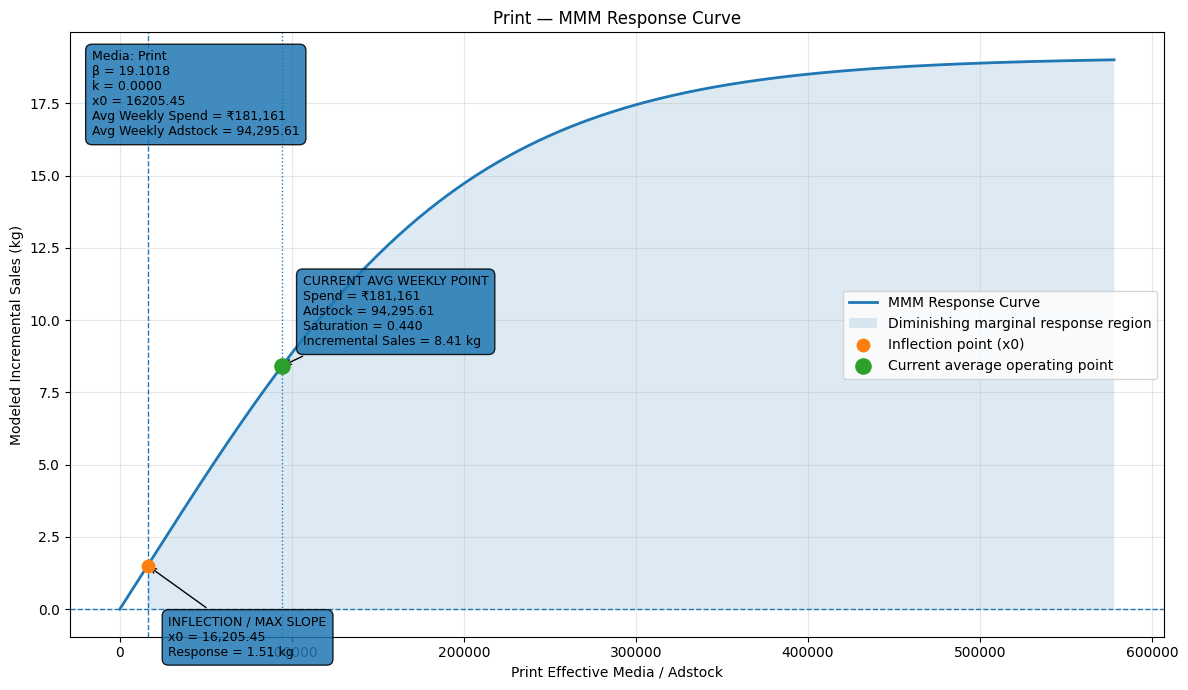

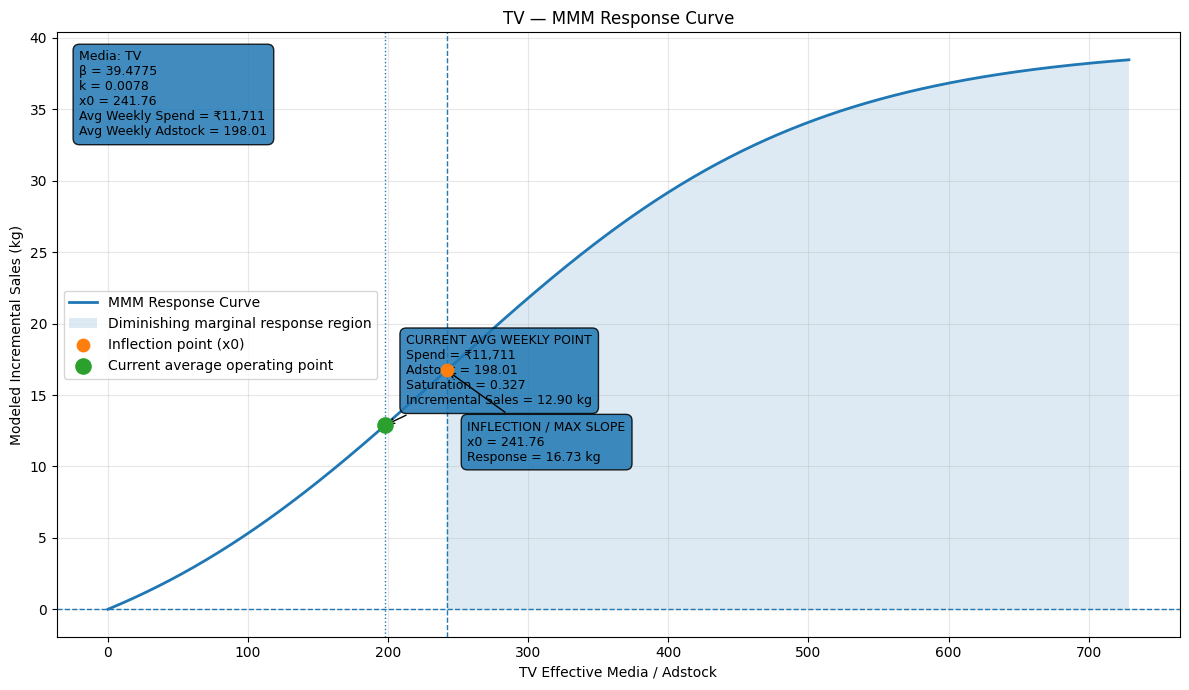

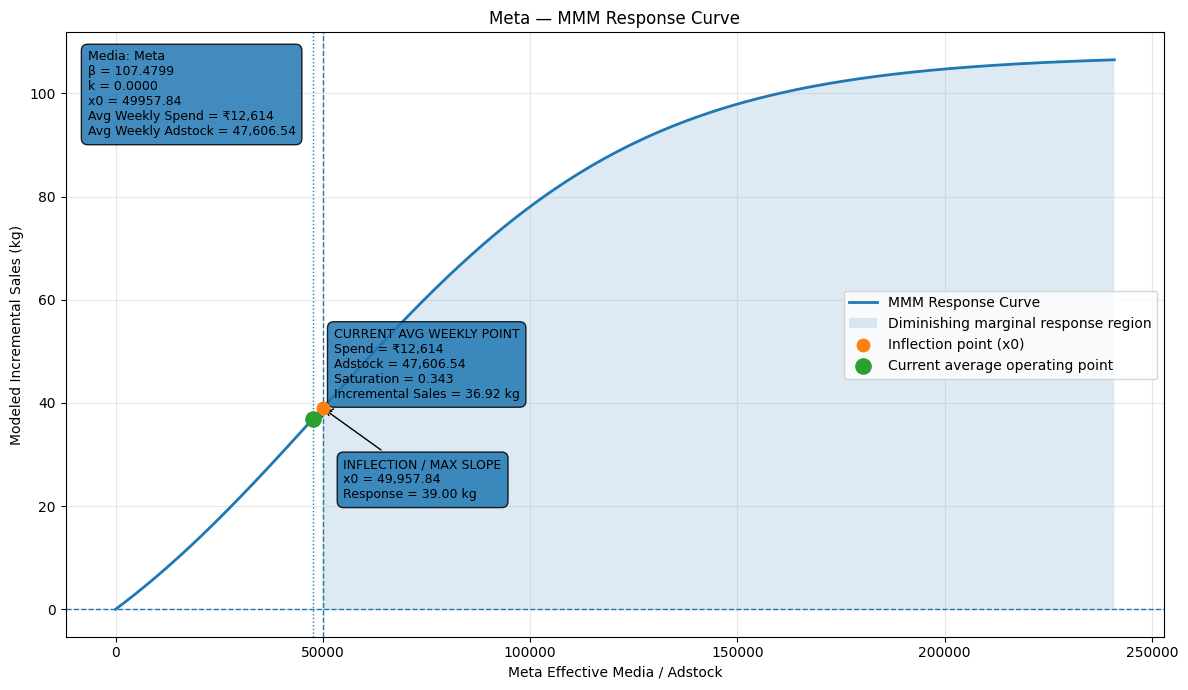

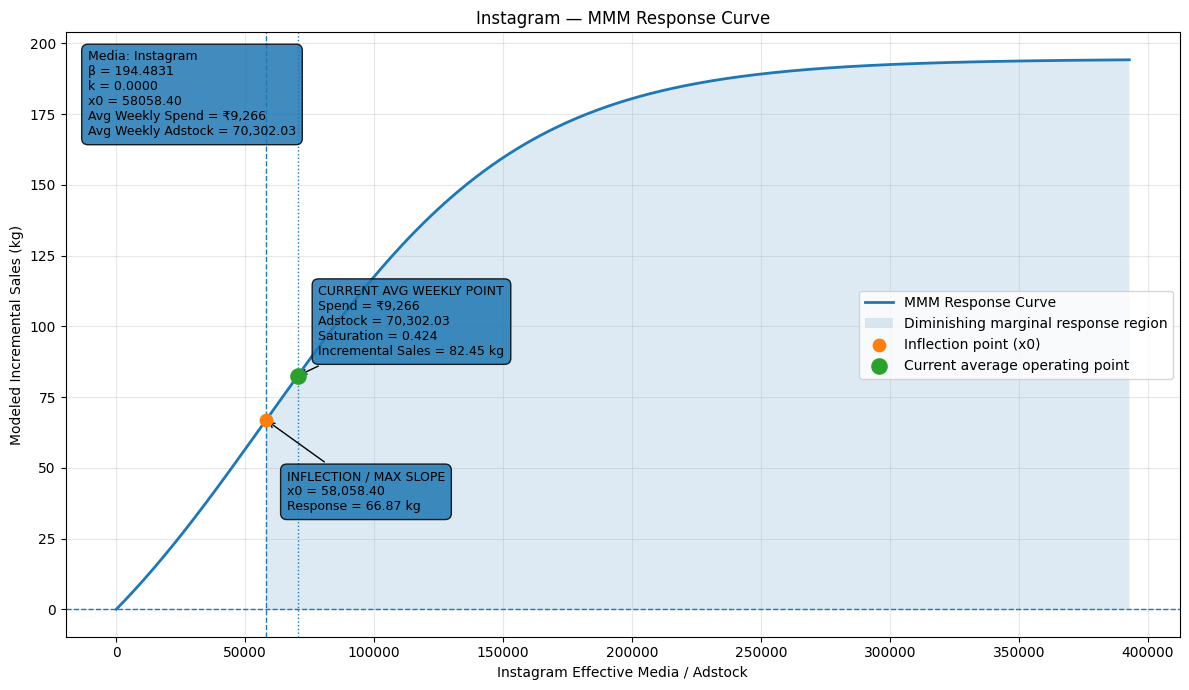

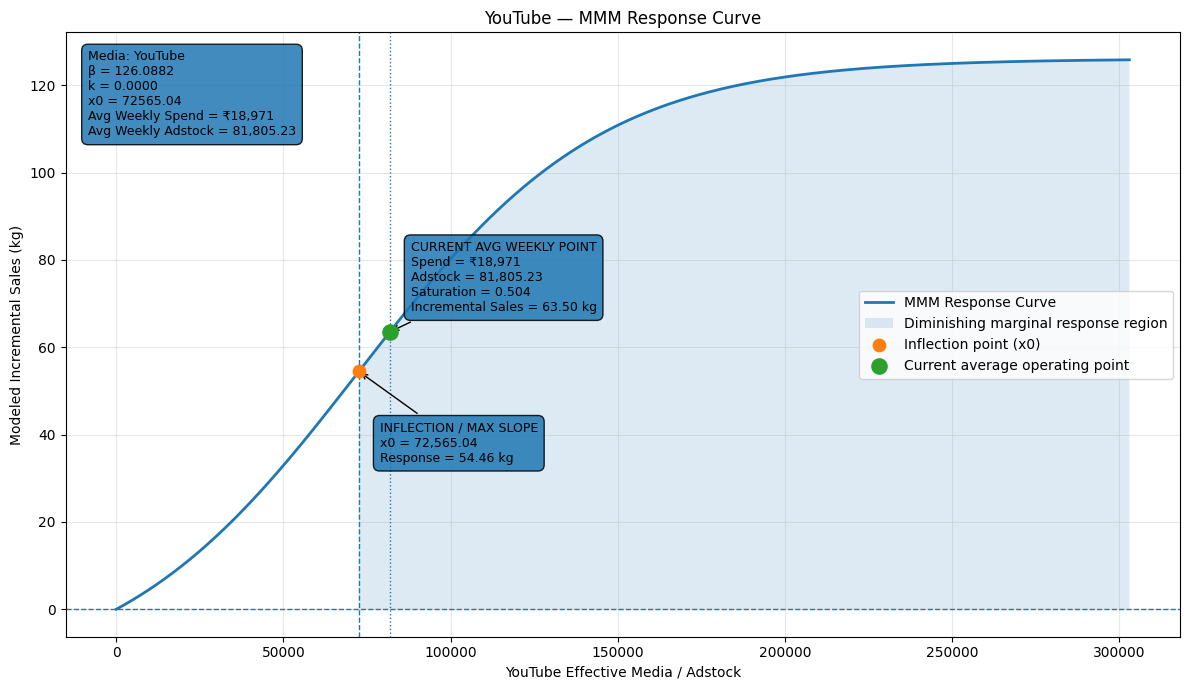


CONSUMER BRAND MMM RESPONSE CURVE SUMMARY


,Media_Family,OLS_Beta,k,x0_Inflection,Average_Weekly_Spend_INR,Average_Weekly_Adstock,Current_Saturation,Current_Incremental_Sales_kg,Saturation_at_x0,Response_at_x0_kg,Current_Region
0,Print,19.1018,0.0000,16205.4466,181160.8974,94295.6108,0.4405,8.4139,0.0791,1.5101,Current point is in diminishing-response region
1,TV,39.4775,0.0078,241.7571,11710.9615,198.0121,0.3266,12.8952,0.4238,16.7290,Current point is before the inflection point
2,Meta,107.4799,0.0000,49957.8397,12613.5897,47606.5395,0.3435,36.9169,0.3629,39.0010,Current point is before the inflection point
3,Instagram,194.4831,0.0000,58058.4021,9265.9615,70302.0273,0.4239,82.4495,0.3438,66.8694,Current point is in diminishing-response region
4,YouTube,126.0882,0.0000,72565.0387,18970.7692,81805.2273,0.5036,63.4980,0.4319,54.4553,Current point is in diminishing-response region



STEP 21 COMPLETED
For every media family, the chart now shows:
  • Complete MMM response curve
  • Current average weekly spend
  • Current average effective adstock
  • Current saturation
  • Current modeled incremental sales
  • Logistic inflection point x0
  • Response at x0
  • Diminishing marginal-response region

IMPORTANT:
The plotted response curve is ADSTOCK → incremental sales.
Average weekly spend is annotated separately because spend does not uniquely map to adstock without specifying a spend-to-media-input relationship.


In [44]:
# ============================================================
# STEP 21 — MMM RESPONSE CURVES WITH CURRENT OPERATING POINT
#                 + DIMINISHING-RETURN REGION
# ============================================================
#
# PURPOSE
# -------
# Build the TRUE MMM response curve for every media family:
#
#     Effective Media / Adstock
#                 ↓
#          Logistic Saturation
#                 ↓
#          OLS Coefficient
#                 ↓
#       Incremental Media Sales
#
# Mathematical response function:
#
#     R_j(x) = beta_j × S_j(x)
#
# where:
#
#     x      = effective media / adstock
#     S_j(x) = fitted zero-anchored logistic saturation
#     beta_j = full-history OLS coefficient
#
# IMPORTANT
# ---------
# The x-axis is EFFECTIVE MEDIA / ADSTOCK.
#
# Therefore the "current average weekly spend" is displayed
# as information on the chart, while the CURRENT POINT ON
# THE CURVE is the average weekly effective adstock.
#
# The point x0 is the logistic inflection point.
#
# At x0:
#     marginal response is at its maximum.
#
# For x > x0:
#     marginal response declines
#     -> diminishing marginal response region.
# ============================================================




# ============================================================
# 1. REQUIRED OBJECT CHECK
# ============================================================

required_objects = [
    "full_data_ols_model",
    "media_families",
    "saturation_parameters",
    "model_saturation_df",
    "weekly_roas_df"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "The following required objects are missing:\n"
        + "\n".join(missing_objects)
        + "\n\nPlease run the earlier MMM cells through Step 20."
    )


# ============================================================
# 2. BUILD RESPONSE-CURVE TABLES
# ============================================================

response_curve_tables = []

response_curve_summary = []


# ============================================================
# 3. LOOP THROUGH ALL MEDIA FAMILIES
# ============================================================

for media_family in media_families:

    # --------------------------------------------------------
    # Column names
    # --------------------------------------------------------

    adstock_col = (
        f"{media_family}_Adstock"
    )

    saturation_col = (
        f"{media_family}_Saturated"
    )

    spend_col = (
        f"{media_family}_Spend_INR"
    )


    # --------------------------------------------------------
    # Check required columns
    # --------------------------------------------------------

    if adstock_col not in model_saturation_df.columns:
        raise KeyError(
            f"Missing adstock column: {adstock_col}"
        )

    if saturation_col not in full_data_ols_model.params.index:
        raise KeyError(
            f"Missing OLS coefficient for: {saturation_col}"
        )

    if spend_col not in weekly_roas_df.columns:
        raise KeyError(
            f"Missing media spend column: {spend_col}"
        )


    # ========================================================
    # 4. GET FITTED PARAMETERS
    # ========================================================

    k = (
        saturation_parameters[
            media_family
        ]["k"]
    )

    x0 = (
        saturation_parameters[
            media_family
        ]["x0"]
    )

    beta = float(
        full_data_ols_model.params[
            saturation_col
        ]
    )


    # ========================================================
    # 5. CURRENT AVERAGE WEEKLY EFFECTIVE MEDIA / ADSTOCK
    # ========================================================

    average_adstock = float(
        model_saturation_df[
            adstock_col
        ]
        .mean()
    )


    # ========================================================
    # 6. CURRENT AVERAGE WEEKLY MEDIA SPEND
    # ========================================================

    average_weekly_spend = float(
        weekly_roas_df[
            spend_col
        ]
        .mean()
    )


    # ========================================================
    # 7. CREATE RESPONSE-FUNCTION X RANGE
    # ========================================================

    observed_max = float(
        model_saturation_df[
            adstock_col
        ]
        .max()
    )

    # Include x0 and current average adstock
    # even if they are outside the observed range.

    curve_max = max(
        observed_max,
        average_adstock,
        x0
    ) * 1.20

    curve_max = max(
        curve_max,
        1.0
    )

    x_curve = np.linspace(
        0,
        curve_max,
        500
    )


    # ========================================================
    # 8. APPLY THE EXACT NOTEBOOK SATURATION FUNCTION
    # ========================================================

    saturation_curve = logistic_saturation(
        x_curve,
        k=k,
        x0=x0
    )


    # ========================================================
    # 9. TRUE MMM RESPONSE FUNCTION
    # ========================================================
    #
    # R(x) = beta × S(x)
    #

    response_curve = (
        beta
        *
        saturation_curve
    )


    # ========================================================
    # 10. CURRENT OPERATING POINT
    # ========================================================

    current_saturation = float(
        logistic_saturation(
            np.array([average_adstock]),
            k=k,
            x0=x0
        )[0]
    )

    current_incremental_sales = (
        beta
        *
        current_saturation
    )


    # ========================================================
    # 11. RESPONSE AT INFLECTION POINT x0
    # ========================================================

    saturation_at_x0 = float(
        logistic_saturation(
            np.array([x0]),
            k=k,
            x0=x0
        )[0]
    )

    response_at_x0 = (
        beta
        *
        saturation_at_x0
    )


    # ========================================================
    # 12. DETERMINE CURRENT REGION
    # ========================================================

    if average_adstock > x0:

        current_region = (
            "Current point is in "
            "diminishing-response region"
        )

    elif np.isclose(
        average_adstock,
        x0
    ):

        current_region = (
            "Current point is at "
            "the inflection point"
        )

    else:

        current_region = (
            "Current point is before "
            "the inflection point"
        )


    # ========================================================
    # 13. STORE CURVE DATA
    # ========================================================

    curve_df = pd.DataFrame({

        "Media_Family":
            media_family,

        "Effective_Adstock":
            x_curve,

        "Saturation":
            saturation_curve,

        "OLS_Coefficient":
            beta,

        "Incremental_Sales_kgs":
            response_curve

    })

    response_curve_tables.append(
        curve_df
    )


    # ========================================================
    # 14. STORE SUMMARY
    # ========================================================

    response_curve_summary.append({

        "Media_Family":
            media_family,

        "OLS_Beta":
            beta,

        "k":
            k,

        "x0_Inflection":
            x0,

        "Average_Weekly_Spend_INR":
            average_weekly_spend,

        "Average_Weekly_Adstock":
            average_adstock,

        "Current_Saturation":
            current_saturation,

        "Current_Incremental_Sales_kg":
            current_incremental_sales,

        "Saturation_at_x0":
            saturation_at_x0,

        "Response_at_x0_kg":
            response_at_x0,

        "Current_Region":
            current_region

    })


    # ========================================================
    # 15. PLOT EACH MEDIA FAMILY
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )


    # --------------------------------------------------------
    # Response curve
    # --------------------------------------------------------

    ax.plot(
        x_curve,
        response_curve,
        linewidth=2,
        label="MMM Response Curve"
    )


    # --------------------------------------------------------
    # Diminishing-response region
    # --------------------------------------------------------

    # Only shade where x > x0.
    # This is the region after the logistic inflection point.

    if x0 < curve_max:

        shade_x = np.linspace(
            x0,
            curve_max,
            200
        )

        shade_saturation = (
            logistic_saturation(
                shade_x,
                k=k,
                x0=x0
            )
        )

        shade_response = (
            beta
            *
            shade_saturation
        )

        ax.fill_between(
            shade_x,
            0,
            shade_response,
            alpha=0.15,
            label="Diminishing marginal response region"
        )


    # --------------------------------------------------------
    # Inflection point x0
    # --------------------------------------------------------

    ax.scatter(
        [x0],
        [response_at_x0],
        s=80,
        zorder=5,
        label="Inflection point (x0)"
    )


    ax.axvline(
        x0,
        linestyle="--",
        linewidth=1
    )


    # --------------------------------------------------------
    # Current average operating point
    # --------------------------------------------------------

    ax.scatter(
        [average_adstock],
        [current_incremental_sales],
        s=120,
        zorder=6,
        label="Current average operating point"
    )


    ax.axvline(
        average_adstock,
        linestyle=":",
        linewidth=1
    )


    # ========================================================
    # 16. LABEL CURRENT POINT
    # ========================================================

    current_point_text = (
        f"CURRENT AVG WEEKLY POINT\n"
        f"Spend = ₹{average_weekly_spend:,.0f}\n"
        f"Adstock = {average_adstock:,.2f}\n"
        f"Saturation = {current_saturation:.3f}\n"
        f"Incremental Sales = "
        f"{current_incremental_sales:,.2f} kg"
    )

    ax.annotate(
        current_point_text,
        xy=(
            average_adstock,
            current_incremental_sales
        ),
        xytext=(
            15,
            15
        ),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.85
        ),
        arrowprops=dict(
            arrowstyle="->"
        )
    )


    # ========================================================
    # 17. LABEL INFLECTION / DIMINISHING-RETURN POINT
    # ========================================================

    inflection_text = (
        f"INFLECTION / MAX SLOPE\n"
        f"x0 = {x0:,.2f}\n"
        f"Response = {response_at_x0:,.2f} kg"
    )

    ax.annotate(
        inflection_text,
        xy=(
            x0,
            response_at_x0
        ),
        xytext=(
            15,
            -65
        ),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.85
        ),
        arrowprops=dict(
            arrowstyle="->"
        )
    )


    # ========================================================
    # 18. ADD CHANNEL INFORMATION BOX
    # ========================================================

    info_text = (
        f"Media: {media_family}\n"
        f"β = {beta:.4f}\n"
        f"k = {k:.4f}\n"
        f"x0 = {x0:.2f}\n"
        f"Avg Weekly Spend = ₹{average_weekly_spend:,.0f}\n"
        f"Avg Weekly Adstock = {average_adstock:,.2f}"
    )

    ax.text(
        0.02,
        0.97,
        info_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            alpha=0.85
        )
    )


    # ========================================================
    # 19. GRAPH FORMATTING
    # ========================================================

    ax.set_xlabel(
        f"{media_family} Effective Media / Adstock"
    )

    ax.set_ylabel(
        "Modeled Incremental Sales (kg)"
    )

    ax.set_title(
        f"{media_family} — MMM Response Curve"
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        loc="best"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 20. COMBINE RESPONSE-CURVE DATA
# ============================================================

response_curves_df = pd.concat(
    response_curve_tables,
    ignore_index=True
)


# ============================================================
# 21. RESPONSE-CURVE SUMMARY TABLE
# ============================================================

response_curve_summary_df = pd.DataFrame(
    response_curve_summary
)


print(
    "\n============================================================"
)

print(
    "CONSUMER BRAND MMM RESPONSE CURVE SUMMARY"
)

print(
    "============================================================"
)

display(
    response_curve_summary_df.round(4)
)


# ============================================================
# 22. SAVE OUTPUTS
# ============================================================

response_curves_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Response_Curves.csv",
    index=False
)

response_curve_summary_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Response_Curve_Summary.csv",
    index=False
)


# ============================================================
# 23. FINAL STATUS
# ============================================================

print(
    "\n============================================================"
)

print(
    "STEP 21 COMPLETED"
)

print(
    "============================================================"
)

print(
    "For every media family, the chart now shows:"
)

print(
    "  • Complete MMM response curve"
)

print(
    "  • Current average weekly spend"
)

print(
    "  • Current average effective adstock"
)

print(
    "  • Current saturation"
)

print(
    "  • Current modeled incremental sales"
)

print(
    "  • Logistic inflection point x0"
)

print(
    "  • Response at x0"
)

print(
    "  • Diminishing marginal-response region"
)

print(
    "\nIMPORTANT:"
)

print(
    "The plotted response curve is ADSTOCK → incremental sales."
)

print(
    "Average weekly spend is annotated separately because "
    "spend does not uniquely map to adstock without specifying "
    "a spend-to-media-input relationship."
)

CONSUMER BRAND MMM MODEL PERFORMANCE
R²   : 0.8051
R² % : 80.51%
RMSE : 84.64
MAE  : 69.42
MAPE : 2.22%

Residual Summary
------------------------------------------------------------
count    156.000000
mean      -3.910940
std       84.823711
min     -203.341585
25%      -64.019522
50%       -3.737985
75%       62.980540
max      214.319227
Name: Residual, dtype: float64


,Week,Week_Start,Actual_Sales,Predicted_Sales,Residual,Absolute_Error,APE_%
0,1,2023-01-02,2858.5,2904.54,-46.04,46.04,1.61
1,2,2023-01-09,2646.1,2656.67,-10.57,10.57,0.40
2,3,2023-01-16,2711.1,2741.24,-30.14,30.14,1.11
3,4,2023-01-23,2944.9,2819.24,125.66,125.66,4.27
4,5,2023-01-30,3068.5,3123.20,-54.70,54.70,1.78
...,...,...,...,...,...,...,...
151,152,2025-11-24,3179.6,3251.70,-72.10,72.10,2.27
152,153,2025-12-01,3102.5,3114.78,-12.28,12.28,0.40
153,154,2025-12-08,3097.4,3120.73,-23.33,23.33,0.75
154,155,2025-12-15,3158.4,3145.78,12.62,12.62,0.40


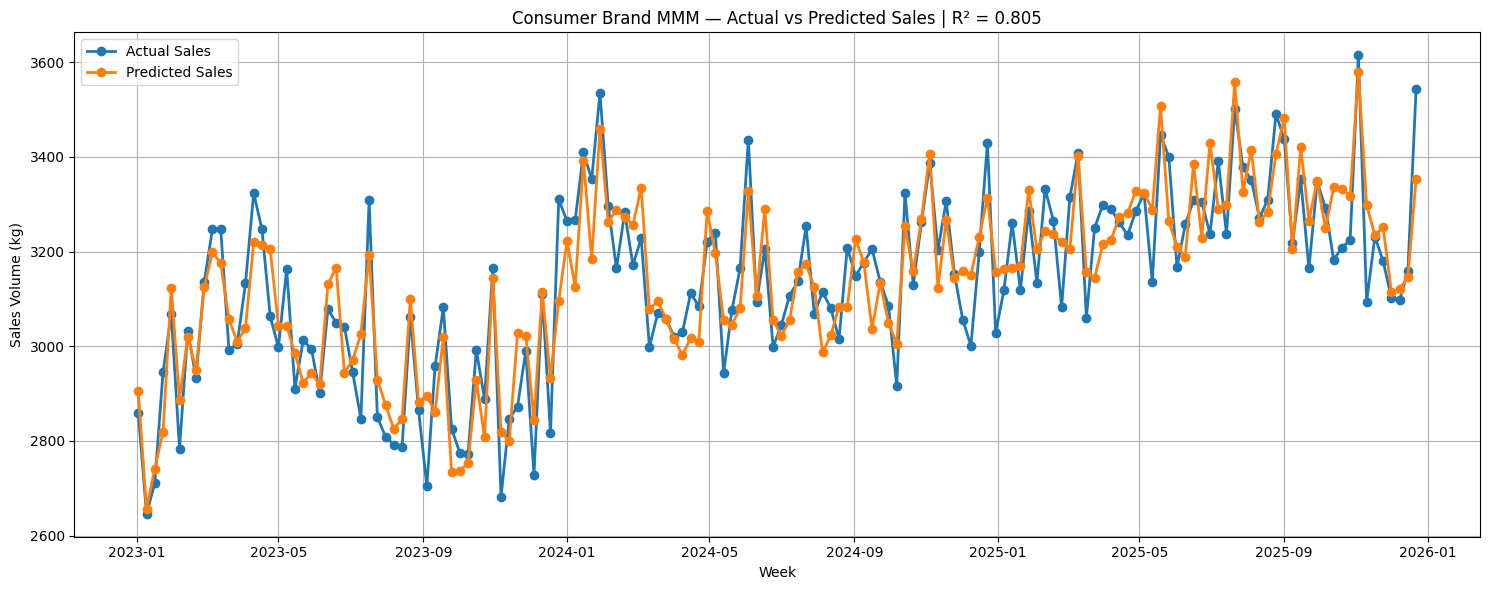

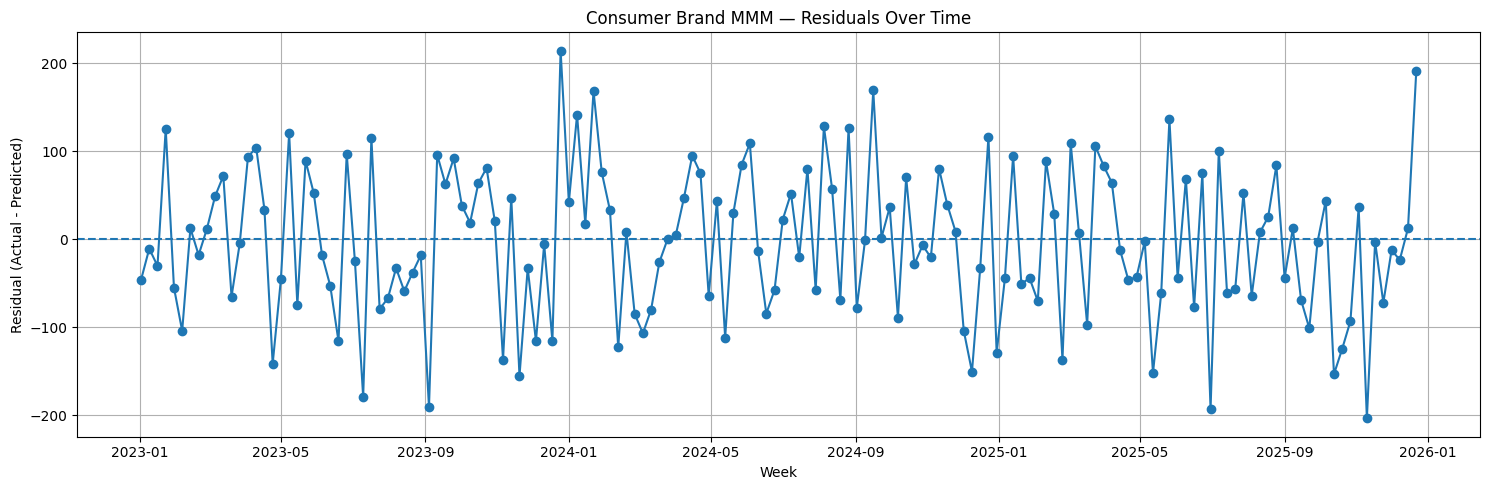

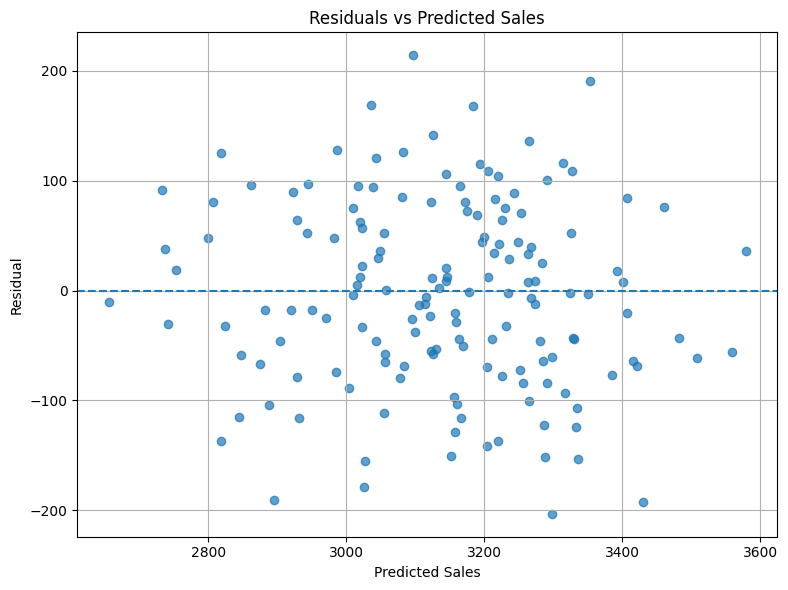

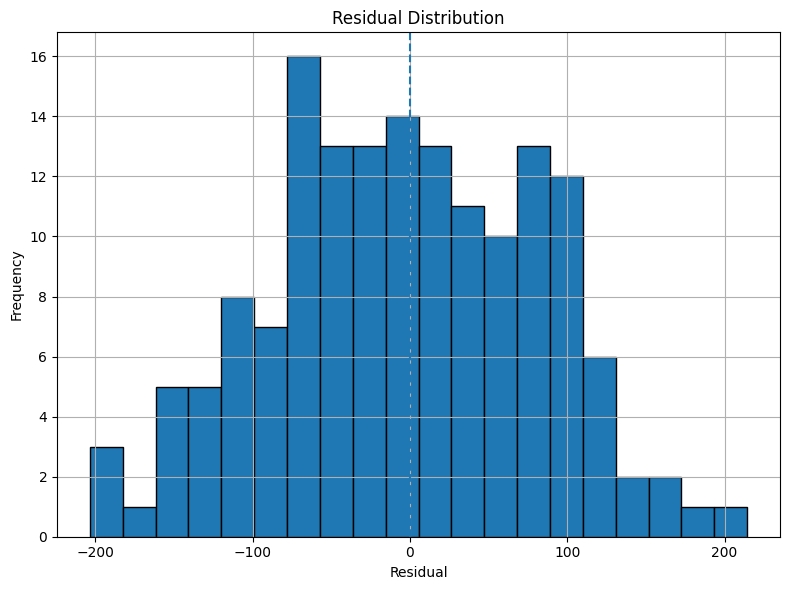


Saved: /content/mmm_outputs/Consumer Brand_MMM_Actual_Predicted_Residuals.csv


In [45]:
# ============================================================
# Consumer Brand MMM — Actual vs Predicted vs Residual Diagnostics
# ============================================================



# ------------------------------------------------------------
# 1. Build diagnostics dataframe
# ------------------------------------------------------------

diagnostics_df = final_ols_results_df[
    ["Week", "Week_Start", sales_col, "Predicted_Sales"]
].copy()

diagnostics_df.rename(
    columns={sales_col: "Actual_Sales"},
    inplace=True
)

diagnostics_df["Residual"] = (
    diagnostics_df["Actual_Sales"]
    - diagnostics_df["Predicted_Sales"]
)

diagnostics_df["Absolute_Error"] = diagnostics_df["Residual"].abs()

diagnostics_df["APE_%"] = (
    diagnostics_df["Absolute_Error"]
    / diagnostics_df["Actual_Sales"].replace(0, np.nan)
) * 100


# ------------------------------------------------------------
# 2. Model metrics
# ------------------------------------------------------------

actual = diagnostics_df["Actual_Sales"]
predicted = diagnostics_df["Predicted_Sales"]
residual = diagnostics_df["Residual"]

r2 = r2_score(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)
mape = diagnostics_df["APE_%"].mean()

print("=" * 60)
print("CONSUMER BRAND MMM MODEL PERFORMANCE")
print("=" * 60)

print(f"R²   : {r2:.4f}")
print(f"R² % : {r2 * 100:.2f}%")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")

print("\nResidual Summary")
print("-" * 60)
print(residual.describe())


# ------------------------------------------------------------
# 3. Actual / Predicted / Residual table
# ------------------------------------------------------------

display(
    diagnostics_df[
        [
            "Week",
            "Week_Start",
            "Actual_Sales",
            "Predicted_Sales",
            "Residual",
            "Absolute_Error",
            "APE_%"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 4. Actual vs Predicted graph
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    diagnostics_df["Week_Start"],
    diagnostics_df["Actual_Sales"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    diagnostics_df["Week_Start"],
    diagnostics_df["Predicted_Sales"],
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title(
    f"Consumer Brand MMM — Actual vs Predicted Sales | R² = {r2:.3f}"
)

plt.xlabel("Week")
plt.ylabel("Sales Volume (kg)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Residual over time
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.plot(
    diagnostics_df["Week_Start"],
    residual,
    marker="o",
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title("Consumer Brand MMM — Residuals Over Time")
plt.xlabel("Week")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Residual vs predicted
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    predicted,
    residual,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title("Residuals vs Predicted Sales")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Residual distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.hist(
    residual,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Save diagnostics
# ------------------------------------------------------------

diagnostics_df.to_csv(
    output_folder / "Consumer Brand_MMM_Actual_Predicted_Residuals.csv",
    index=False
)

print(
    "\nSaved:",
    output_folder / "Consumer Brand_MMM_Actual_Predicted_Residuals.csv"
)



# Step 22 — MMM Budget Optimization

## Objective

Convert the fitted MMM into a **model-implied budget allocation recommendation**.

The optimizer keeps the total weekly media budget equal to the current historical average weekly budget, then reallocates that budget across the same five media families:

- Print
- TV
- Meta
- Instagram
- YouTube

The optimization is based on the fitted **adstock → saturation → OLS coefficient** response already established in the notebook.

### Why this is not a simple ROAS ranking

ROAS is an average historical efficiency measure. A budget optimizer must account for **diminishing returns**. The allocation therefore maximizes modeled incremental media revenue subject to the total-budget constraint, rather than simply sending all money to the channel with the highest historical ROAS.

### Spend-to-response bridge

The MMM response curves are expressed in effective media/adstock units, while the budget is expressed in INR. The notebook therefore estimates a historical family-level relationship between:

> weekly media spend → weekly scaled media input

and then uses the fitted geometric-adstock retention parameters to convert a constant planning spend into a steady-state effective adstock:

\[
Adstock_j = \frac{Spend_j \times InputPerINR_j}{1-\alpha_j}
\]

The resulting adstock is passed through the **same zero-anchored logistic saturation function and full-history OLS coefficient** used by the MMM.

### Optimization constraint

The default planning budget is:

> **Current average weekly total media spend**

Each family is constrained to at most **125% of its observed maximum weekly spend** to reduce extrapolation beyond the historical spend range.

The final result reports both **weekly** and **52-week annualized** spend.


In [46]:

# ============================================================
# STEP 22 — MMM BUDGET OPTIMIZATION
# ============================================================
#
# PURPOSE
# -------
# Reallocate the CURRENT total weekly media budget across the
# five MMM media families to maximize modeled incremental media
# revenue, while accounting for adstock and diminishing returns.
#
# IMPORTANT:
# This is a MODEL-IMPLIED planning allocation, not a causal
# guarantee. It uses the locked full-history MMM specification
# created only after the validation gate.
#
# OBJECTIVE
# ---------
#     Maximize:
#
#         Σ_j Incremental Revenue_j
#
# subject to:
#
#         Σ_j Spend_j = Current Total Weekly Budget
#
#         0 <= Spend_j <= 1.25 × Historical Max Weekly Spend_j
#
# The 1.25x cap is a practical extrapolation guard.
# ============================================================

from scipy.optimize import minimize


# ============================================================
# 1. REQUIRED OBJECT CHECK
# ============================================================

required_objects = [
    "full_data_ols_model",
    "media_families",
    "media_family_map",
    "alpha_values",
    "saturation_parameters",
    "logistic_saturation",
    "model_base_df",
    "model_saturation_df",
    "spend_df",
    "weekly_roas_df",
    "sales_df_clean"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "The following required objects are missing:\n"
        + "\n".join(missing_objects)
        + "\n\nPlease run the notebook through Step 21 before Step 22."
    )


# ============================================================
# 2. DEFINE PLANNING SETTINGS
# ============================================================

ANNUAL_WEEKS = 52

MAX_SPEND_MULTIPLIER = 1.25


# ============================================================
# 3. BUILD HISTORICAL SPEND -> MODEL INPUT BRIDGE
# ============================================================
#
# model_base_df[family] is the SAME scaled media-family input
# that subsequently receives adstock and saturation.
#
# We estimate a through-origin slope:
#
#     Model_Input ≈ Spend_INR × InputPerINR
#
# using all overlapping historical weeks.
# ============================================================

bridge_df = (
    model_base_df[
        ["Week"] + media_families
    ]
    .merge(
        spend_df[
            ["Week"] +
            [
                f"{family}_Spend_INR"
                for family in media_families
            ]
        ],
        on="Week",
        how="inner",
        validate="one_to_one"
    )
)

if bridge_df.empty:
    raise ValueError(
        "The spend-to-media-input bridge has no overlapping weeks."
    )


input_per_inr = {}
bridge_r2 = {}
bridge_rows = []

for family in media_families:

    input_col = family
    spend_col = f"{family}_Spend_INR"

    x = pd.to_numeric(
        bridge_df[spend_col],
        errors="coerce"
    ).fillna(0.0).to_numpy(dtype=float)

    y = pd.to_numeric(
        bridge_df[input_col],
        errors="coerce"
    ).fillna(0.0).to_numpy(dtype=float)

    positive_or_nonzero = x > 0

    if positive_or_nonzero.sum() == 0:
        raise ValueError(
            f"{family} has no positive-spend historical weeks; "
            "a spend-to-input bridge cannot be estimated."
        )

    x_active = x[positive_or_nonzero]
    y_active = y[positive_or_nonzero]

    denominator = float(np.sum(x_active ** 2))

    if denominator <= 0:
        raise ValueError(
            f"{family} has insufficient spend variation for the "
            "spend-to-input bridge."
        )

    slope = float(
        np.sum(x_active * y_active) / denominator
    )

    predicted_y = slope * x_active

    ss_res = float(
        np.sum(
            (y_active - predicted_y) ** 2
        )
    )

    ss_tot = float(
        np.sum(
            (y_active - y_active.mean()) ** 2
        )
    )

    r2 = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    if slope <= 0:
        raise ValueError(
            f"{family} has a non-positive estimated spend-to-input "
            f"relationship ({slope:.8g}). Budget optimization would "
            "not have a meaningful positive spend bridge."
        )

    input_per_inr[family] = slope
    bridge_r2[family] = r2

    bridge_rows.append({

        "Media_Family":
            family,

        "Historical_Weeks_With_Spend":
            int(positive_or_nonzero.sum()),

        "Total_Historical_Spend_INR":
            float(x.sum()),

        "Total_Historical_Model_Input":
            float(y.sum()),

        "Input_Per_INR":
            slope,

        "Bridge_R2_Through_Origin":
            r2
    })


spend_input_bridge_df = pd.DataFrame(
    bridge_rows
)


# ============================================================
# 4. EXTRACT LOCKED MMM RESPONSE PARAMETERS
# ============================================================

optimization_parameter_rows = []

for family in media_families:

    saturated_col = f"{family}_Saturated"
    spend_col = f"{family}_Spend_INR"

    if saturated_col not in full_data_ols_model.params.index:
        raise KeyError(
            f"Missing OLS coefficient for {saturated_col}."
        )

    beta = float(
        full_data_ols_model.params[saturated_col]
    )

    alpha = float(
        alpha_values[family]
    )

    k = float(
        saturation_parameters[family]["k"]
    )

    x0 = float(
        saturation_parameters[family]["x0"]
    )

    historical_max_spend = float(
        pd.to_numeric(
            spend_df[spend_col],
            errors="coerce"
        )
        .fillna(0)
        .max()
    )

    current_avg_spend = float(
        pd.to_numeric(
            spend_df[spend_col],
            errors="coerce"
        )
        .fillna(0)
        .mean()
    )

    historical_avg_adstock = float(
        model_saturation_df[
            f"{family}_Adstock"
        ]
        .astype(float)
        .mean()
    )

    optimization_parameter_rows.append({

        "Media_Family":
            family,

        "Alpha":
            alpha,

        "k":
            k,

        "x0":
            x0,

        "OLS_Beta":
            beta,

        "Input_Per_INR":
            input_per_inr[family],

        "Bridge_R2":
            bridge_r2[family],

        "Current_Avg_Weekly_Spend_INR":
            current_avg_spend,

        "Historical_Max_Weekly_Spend_INR":
            historical_max_spend,

        "Historical_Avg_Adstock":
            historical_avg_adstock,

        "Max_Allowed_Weekly_Spend_INR":
            historical_max_spend *
            MAX_SPEND_MULTIPLIER
    })


optimization_parameters_df = pd.DataFrame(
    optimization_parameter_rows
)


# ============================================================
# 5. CALCULATE THE CURRENT PLANNING BUDGET
# ============================================================

current_budget_by_family = {
    family:
        float(
            optimization_parameters_df.loc[
                optimization_parameters_df["Media_Family"] == family,
                "Current_Avg_Weekly_Spend_INR"
            ].iloc[0]
        )
    for family in media_families
}

current_total_weekly_budget = float(
    sum(
        current_budget_by_family.values()
    )
)

current_total_annual_budget = (
    current_total_weekly_budget *
    ANNUAL_WEEKS
)


# ============================================================
# 6. PLANNING PRICE FOR REVENUE TRANSLATION
# ============================================================
#
# The optimization of spend allocation is unchanged by a common
# price scalar, so we use the historical weighted average price
# only to translate incremental kg into INR revenue.
# ============================================================

planning_price_inr_per_kg = (
    pd.to_numeric(
        sales_df_clean["Sales_Value_INR"],
        errors="coerce"
    ).sum()
    /
    pd.to_numeric(
        sales_df_clean["Sales_Volume_kgs"],
        errors="coerce"
    ).sum()
)

if not np.isfinite(planning_price_inr_per_kg):
    raise ValueError(
        "Planning price could not be calculated from the sales data."
    )


# ============================================================
# 7. RESPONSE FUNCTIONS
# ============================================================

def optimized_channel_response(
    family,
    spend_inr
):
    """
    Convert weekly spend into:
        spend
        -> scaled media input
        -> steady-state adstock
        -> logistic saturation
        -> incremental sales
        -> incremental revenue
    """

    params = optimization_parameters_df.loc[
        optimization_parameters_df["Media_Family"] == family
    ].iloc[0]

    weekly_input = (
        float(spend_inr)
        *
        float(params["Input_Per_INR"])
    )

    steady_state_adstock = (
        weekly_input
        /
        (1.0 - float(params["Alpha"]))
    )

    saturation = float(
        logistic_saturation(
            np.array([steady_state_adstock]),
            k=float(params["k"]),
            x0=float(params["x0"])
        )[0]
    )

    incremental_sales_kg = (
        float(params["OLS_Beta"])
        *
        saturation
    )

    incremental_revenue_inr = (
        incremental_sales_kg
        *
        planning_price_inr_per_kg
    )

    return {
        "Weekly_Input": weekly_input,
        "Steady_State_Adstock":
            steady_state_adstock,
        "Saturation":
            saturation,
        "Incremental_Sales_kg":
            incremental_sales_kg,
        "Incremental_Revenue_INR":
            incremental_revenue_inr
    }


def allocation_response(
    spend_vector
):
    """
    Aggregate optimized response across all media families.
    """

    total_revenue = 0.0
    total_sales = 0.0

    family_results = {}

    for i, family in enumerate(media_families):

        result = optimized_channel_response(
            family,
            spend_vector[i]
        )

        family_results[family] = result

        total_revenue += result[
            "Incremental_Revenue_INR"
        ]

        total_sales += result[
            "Incremental_Sales_kg"
        ]

    return {
        "Total_Incremental_Revenue_INR":
            total_revenue,

        "Total_Incremental_Sales_kg":
            total_sales,

        "Family_Results":
            family_results
    }


# ============================================================
# 8. OPTIMIZE THE CURRENT TOTAL BUDGET
# ============================================================
#
# The starting point is the historical average allocation.
# This is already feasible under the budget constraint.
# ============================================================

initial_allocation = np.array([
    current_budget_by_family[family]
    for family in media_families
], dtype=float)

lower_bounds = [
    0.0
    for _ in media_families
]

upper_bounds = [
    float(
        optimization_parameters_df.loc[
            optimization_parameters_df["Media_Family"] == family,
            "Max_Allowed_Weekly_Spend_INR"
        ].iloc[0]
    )
    for family in media_families
]

if (
    np.sum(upper_bounds)
    <
    current_total_weekly_budget
):
    raise ValueError(
        "Budget is infeasible under the 1.25x historical-maximum "
        "spend caps."
    )


def objective(
    spend_vector
):
    return -allocation_response(
        spend_vector
    )["Total_Incremental_Revenue_INR"]


constraints = [
    {
        "type": "eq",
        "fun": lambda x:
            np.sum(x) -
            current_total_weekly_budget
    }
]


optimization_result = minimize(
    objective,
    x0=initial_allocation,
    method="SLSQP",
    bounds=list(
        zip(
            lower_bounds,
            upper_bounds
        )
    ),
    constraints=constraints,
    options={
        "ftol": 1e-6,
        "maxiter": 2000,
        "disp": False
    }
)

if not optimization_result.success:
    raise RuntimeError(
        "Budget optimization did not converge.\n"
        f"Optimizer message: {optimization_result.message}"
    )


optimized_allocation = {
    family:
        float(
            optimization_result.x[i]
        )
    for i, family in enumerate(media_families)
}


# ============================================================
# 9. CURRENT-BUDGET VS OPTIMIZED-BUDGET RESPONSE
# ============================================================

current_response = allocation_response(
    initial_allocation
)

optimized_response = allocation_response(
    optimization_result.x
)


# ============================================================
# 10. MEDIA-WISE OPTIMIZED BUDGET TABLE
# ============================================================

allocation_rows = []

for family in media_families:

    current_spend = (
        current_budget_by_family[family]
    )

    optimized_spend = (
        optimized_allocation[family]
    )

    current_result = (
        current_response[
            "Family_Results"
        ][family]
    )

    optimized_result = (
        optimized_response[
            "Family_Results"
        ][family]
    )

    current_share = (
        current_spend /
        current_total_weekly_budget
        * 100
        if current_total_weekly_budget > 0
        else np.nan
    )

    optimized_share = (
        optimized_spend /
        current_total_weekly_budget
        * 100
        if current_total_weekly_budget > 0
        else np.nan
    )

    allocation_rows.append({

        "Media_Family":
            family,

        "Current_Avg_Weekly_Spend_INR":
            current_spend,

        "Current_Budget_Share_%":
            current_share,

        "Optimized_Weekly_Spend_INR":
            optimized_spend,

        "Optimized_Budget_Share_%":
            optimized_share,

        "Spend_Change_INR_per_Week":
            optimized_spend -
            current_spend,

        "Spend_Change_%":
            (
                (
                    optimized_spend -
                    current_spend
                )
                /
                current_spend
                * 100
                if current_spend > 0
                else np.nan
            ),

        "Current_Steady_State_Adstock":
            current_result[
                "Steady_State_Adstock"
            ],

        "Optimized_Steady_State_Adstock":
            optimized_result[
                "Steady_State_Adstock"
            ],

        "Current_Saturation":
            current_result[
                "Saturation"
            ],

        "Optimized_Saturation":
            optimized_result[
                "Saturation"
            ],

        "Current_Incremental_Sales_kg_per_Week":
            current_result[
                "Incremental_Sales_kg"
            ],

        "Optimized_Incremental_Sales_kg_per_Week":
            optimized_result[
                "Incremental_Sales_kg"
            ],

        "Optimized_Incremental_Revenue_INR_per_Week":
            optimized_result[
                "Incremental_Revenue_INR"
            ],

        "Optimized_Annual_Spend_INR":
            optimized_spend *
            ANNUAL_WEEKS
    })


budget_allocation_df = pd.DataFrame(
    allocation_rows
)


# ============================================================
# 11. MARGINAL REVENUE PER RUPEE AT THE OPTIMIZED POINT
# ============================================================
#
# For the zero-anchored logistic:
#
#   dS/dx = k * L(x) * (1-L(x)) / (1-L(0))
#
# and:
#
#   dx/dSpend = InputPerINR / (1-alpha)
#
# Therefore:
#
#   Marginal Revenue / ₹
#       =
#   beta × dS/dx × dx/dSpend × price
#
# This is the quantity that should approximately equalize across
# non-bound active channels at the optimum.
# ============================================================

def marginal_revenue_per_inr(
    family,
    spend_inr
):
    params = optimization_parameters_df.loc[
        optimization_parameters_df["Media_Family"] == family
    ].iloc[0]

    beta = float(params["OLS_Beta"])
    k = float(params["k"])
    x0 = float(params["x0"])
    alpha = float(params["Alpha"])
    input_per_rupee = float(params["Input_Per_INR"])

    adstock = (
        float(spend_inr)
        *
        input_per_rupee
        /
        (1.0 - alpha)
    )

    logistic_x = 1.0 / (
        1.0 +
        np.exp(
            np.clip(
                -k * (adstock - x0),
                -700,
                700
            )
        )
    )

    logistic_zero = 1.0 / (
        1.0 +
        np.exp(
            np.clip(
                -k * (0.0 - x0),
                -700,
                700
            )
        )
    )

    denominator = (
        1.0 -
        logistic_zero
    )

    if abs(denominator) < 1e-12:
        return 0.0

    d_saturation_d_adstock = (
        k
        *
        logistic_x
        *
        (1.0 - logistic_x)
        /
        denominator
    )

    d_adstock_d_spend = (
        input_per_rupee
        /
        (1.0 - alpha)
    )

    return float(
        beta
        *
        d_saturation_d_adstock
        *
        d_adstock_d_spend
        *
        planning_price_inr_per_kg
    )


budget_allocation_df[
    "Marginal_Revenue_per_Additional_INR"
] = [
    marginal_revenue_per_inr(
        family,
        optimized_allocation[family]
    )
    for family in media_families
]


# ============================================================
# 12. ADD MODEL-DIRECTION FLAGS
# ============================================================

beta_map = (
    optimization_parameters_df.set_index(
        "Media_Family"
    )["OLS_Beta"]
    .to_dict()
)

budget_allocation_df[
    "OLS_Beta"
] = budget_allocation_df[
    "Media_Family"
].map(beta_map)

budget_allocation_df[
    "Model_Response_Flag"
] = np.where(
    budget_allocation_df["OLS_Beta"] > 0,
    "Positive fitted media response",
    "Non-positive fitted media coefficient — interpret cautiously"
)

# ============================================================
# 13. TOTALS AND UPLIFT
# ============================================================

optimized_total_weekly_spend = float(
    budget_allocation_df[
        "Optimized_Weekly_Spend_INR"
    ].sum()
)

optimized_total_annual_spend = (
    optimized_total_weekly_spend *
    ANNUAL_WEEKS
)

current_scenario_revenue = float(
    current_response[
        "Total_Incremental_Revenue_INR"
    ]
)

optimized_scenario_revenue = float(
    optimized_response[
        "Total_Incremental_Revenue_INR"
    ]
)

current_scenario_sales = float(
    current_response[
        "Total_Incremental_Sales_kg"
    ]
)

optimized_scenario_sales = float(
    optimized_response[
        "Total_Incremental_Sales_kg"
    ]
)

weekly_revenue_uplift = (
    optimized_scenario_revenue -
    current_scenario_revenue
)

annual_revenue_uplift = (
    weekly_revenue_uplift *
    ANNUAL_WEEKS
)

weekly_sales_uplift = (
    optimized_scenario_sales -
    current_scenario_sales
)

annual_sales_uplift = (
    weekly_sales_uplift *
    ANNUAL_WEEKS
)

current_scenario_roas = (
    current_scenario_revenue /
    current_total_weekly_budget
    if current_total_weekly_budget > 0
    else np.nan
)

optimized_scenario_roas = (
    optimized_scenario_revenue /
    optimized_total_weekly_spend
    if optimized_total_weekly_spend > 0
    else np.nan
)


# ============================================================
# 14. VALIDATION CHECKS
# ============================================================

budget_difference = (
    optimized_total_weekly_spend -
    current_total_weekly_budget
)

if abs(budget_difference) > 0.01:
    raise ValueError(
        "Optimized budget does not reconcile to the fixed total "
        f"weekly budget. Difference = ₹{budget_difference:,.4f}"
    )

if not np.isfinite(
    optimized_scenario_revenue
):
    raise ValueError(
        "Optimized incremental revenue is not finite."
    )


# ============================================================
# 15. DISPLAY THE OPTIMIZATION INPUTS
# ============================================================

print(
    "\n============================================================"
)
print(
    "BUDGET OPTIMIZATION INPUTS"
)
print(
    "============================================================"
)

print(
    f"Current average weekly media budget: "
    f"₹{current_total_weekly_budget:,.2f}"
)

print(
    f"Annualized 52-week planning budget: "
    f"₹{current_total_annual_budget:,.2f}"
)

print(
    f"Planning price: "
    f"₹{planning_price_inr_per_kg:,.2f} per kg"
)

print(
    f"Spend cap: "
    f"{MAX_SPEND_MULTIPLIER:.2f} × historical maximum weekly spend"
)


display(
    spend_input_bridge_df.round(6)
)


display(
    optimization_parameters_df.round(6)
)


# ============================================================
# 16. DISPLAY OPTIMIZED ALLOCATION
# ============================================================

print(
    "\n============================================================"
)
print(
    "MODEL-IMPLIED OPTIMIZED MEDIA BUDGET"
)
print(
    "============================================================"
)

display(
    budget_allocation_df.sort_values(
        "Optimized_Weekly_Spend_INR",
        ascending=False
    ).round(3)
)


# ============================================================
# 17. SAVE OUTPUTS
# ============================================================

spend_input_bridge_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Spend_to_Input_Bridge.csv",
    index=False
)

optimization_parameters_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Budget_Optimization_Parameters.csv",
    index=False
)

budget_allocation_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_Optimized_Budget_Allocation.csv",
    index=False
)

print(
    "\nSaved budget optimization outputs:"
)

print(
    output_folder /
    "Consumer Brand_MMM_Spend_to_Input_Bridge.csv"
)

print(
    output_folder /
    "Consumer Brand_MMM_Budget_Optimization_Parameters.csv"
)

print(
    output_folder /
    "Consumer Brand_MMM_Optimized_Budget_Allocation.csv"
)



BUDGET OPTIMIZATION INPUTS
Current average weekly media budget: ₹233,722.18
Annualized 52-week planning budget: ₹12,153,553.33
Planning price: ₹248.32 per kg
Spend cap: 1.25 × historical maximum weekly spend


,Media_Family,Historical_Weeks_With_Spend,Total_Historical_Spend_INR,Total_Historical_Model_Input,Input_Per_INR,Bridge_R2_Through_Origin
0,Print,50,28261100.0,8.826237e+06,0.312398,0.995203
1,TV,87,1826910.0,1.081600e+04,0.005928,0.995677
2,Meta,86,1967720.0,5.198634e+06,2.645300,0.998374
3,Instagram,90,1445490.0,8.225339e+06,5.665472,0.996766
4,YouTube,117,2959440.0,7.657060e+06,2.586578,0.998325


,Media_Family,Alpha,k,x0,OLS_Beta,Input_Per_INR,Bridge_R2,Current_Avg_Weekly_Spend_INR,Historical_Max_Weekly_Spend_INR,Historical_Avg_Adstock,Max_Allowed_Weekly_Spend_INR
0,Print,0.40,0.000011,16205.446596,19.101757,0.312398,0.995203,181160.897436,961470.0,94295.610760,1201837.5
1,TV,0.65,0.007779,241.757141,39.477507,0.005928,0.995677,11710.961538,49450.0,198.012092,61812.5
2,Meta,0.30,0.000026,49957.839732,107.479861,2.645300,0.998374,12613.589744,57480.0,47606.539478,71850.0
3,Instagram,0.25,0.000020,58058.402089,194.483060,5.665472,0.996766,9265.961538,47490.0,70302.027324,59362.5
4,YouTube,0.40,0.000027,72565.038708,126.088241,2.586578,0.998325,18970.769231,61410.0,81805.227278,76762.5



MODEL-IMPLIED OPTIMIZED MEDIA BUDGET


,Media_Family,Current_Avg_Weekly_Spend_INR,Current_Budget_Share_%,Optimized_Weekly_Spend_INR,Optimized_Budget_Share_%,Spend_Change_INR_per_Week,Spend_Change_%,Current_Steady_State_Adstock,Optimized_Steady_State_Adstock,Current_Saturation,Optimized_Saturation,Current_Incremental_Sales_kg_per_Week,Optimized_Incremental_Sales_kg_per_Week,Optimized_Incremental_Revenue_INR_per_Week,Optimized_Annual_Spend_INR,Marginal_Revenue_per_Additional_INR,OLS_Beta,Model_Response_Flag
2,Meta,12613.590,5.397,69596.887,29.778,56983.298,451.761,47666.764,263006.682,0.344,0.995,36.970,106.932,26552.961,3619038.137,0.013,107.480,Positive fitted media response
4,YouTube,18970.769,8.117,65043.483,27.829,46072.714,242.862,81782.305,280400.121,0.503,0.996,63.476,125.615,31192.298,3382261.136,0.014,126.088,Positive fitted media response
1,TV,11710.962,5.011,51244.251,21.925,39533.289,337.575,198.341,867.892,0.327,0.991,12.923,39.131,9716.985,2664701.049,0.011,39.478,Positive fitted media response
3,Instagram,9265.962,3.965,47837.558,20.468,38571.596,416.272,69994.727,361363.122,0.422,0.997,82.062,193.900,48148.631,2487553.012,0.022,194.483,Positive fitted media response
0,Print,181160.897,77.511,0.000,0.000,-181160.897,-100.000,94323.958,0.000,0.441,0.000,8.416,0.000,0.000,0.000,0.012,19.102,Positive fitted media response



Saved budget optimization outputs:
/content/mmm_outputs/Consumer Brand_MMM_Spend_to_Input_Bridge.csv
/content/mmm_outputs/Consumer Brand_MMM_Budget_Optimization_Parameters.csv
/content/mmm_outputs/Consumer Brand_MMM_Optimized_Budget_Allocation.csv



# Step 23 — Finalized Result

This is the final business-facing output of the MMM optimization.

The notebook will report:

1. The current weekly and annualized media budget.
2. The optimized weekly and 52-week annualized spend by media family.
3. The current vs optimized budget share.
4. The spend shift in INR and percentage.
5. The modeled incremental sales and revenue under the current-budget scenario.
6. The modeled incremental sales and revenue under the optimized allocation.
7. The modeled revenue uplift from reallocating the same total budget.
8. The marginal modeled revenue generated by the next ₹1 at the optimized point.

The recommendation is explicitly labeled **model-implied** because the allocation is derived from the fitted MMM and its assumptions.


In [47]:

# ============================================================
# STEP 23 — FINALIZED RESULT
# ============================================================

print(
    "\n"
    + "=" * 80
)

print(
    "FINALIZED MMM BUDGET OPTIMIZATION RESULT"
)

print(
    "=" * 80
)


# ------------------------------------------------------------
# 1. TOP-LEVEL BUDGET RESULT
# ------------------------------------------------------------

print(
    f"\nCurrent average weekly media budget : "
    f"₹{current_total_weekly_budget:,.0f}"
)

print(
    f"Optimized weekly media budget       : "
    f"₹{optimized_total_weekly_spend:,.0f}"
)

print(
    f"Annual planning budget (52 weeks)   : "
    f"₹{optimized_total_annual_spend:,.0f}"
)

print(
    f"\nCurrent-budget modeled incremental sales : "
    f"{current_scenario_sales:,.0f} kg/week"
)

print(
    f"Optimized modeled incremental sales      : "
    f"{optimized_scenario_sales:,.0f} kg/week"
)

print(
    f"Modeled incremental sales uplift         : "
    f"{weekly_sales_uplift:,.0f} kg/week "
    f"({annual_sales_uplift:,.0f} kg/year)"
)

print(
    f"\nCurrent-budget modeled incremental revenue : "
    f"₹{current_scenario_revenue:,.0f}/week"
)

print(
    f"Optimized modeled incremental revenue      : "
    f"₹{optimized_scenario_revenue:,.0f}/week"
)

print(
    f"Modeled revenue uplift from reallocation   : "
    f"₹{weekly_revenue_uplift:,.0f}/week "
    f"(₹{annual_revenue_uplift:,.0f}/year)"
)

print(
    f"\nCurrent-budget scenario ROAS : "
    f"{current_scenario_roas:.3f}"
)

print(
    f"Optimized scenario ROAS      : "
    f"{optimized_scenario_roas:.3f}"
)


# ------------------------------------------------------------
# 2. FINAL ALLOCATION TABLE
# ------------------------------------------------------------

final_budget_result_df = (
    budget_allocation_df[
        [
            "Media_Family",
            "Current_Avg_Weekly_Spend_INR",
            "Current_Budget_Share_%",
            "Optimized_Weekly_Spend_INR",
            "Optimized_Budget_Share_%",
            "Spend_Change_INR_per_Week",
            "Spend_Change_%",
            "Optimized_Annual_Spend_INR",
            "Marginal_Revenue_per_Additional_INR",
            "OLS_Beta",
            "Model_Response_Flag"
        ]
    ]
    .sort_values(
        "Optimized_Weekly_Spend_INR",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nFINAL MODEL-IMPLIED ALLOCATION"
)

display(
    final_budget_result_df.round(3)
)


# ------------------------------------------------------------
# 3. FINAL RECOMMENDATION TEXT
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 80
)

print(
    "FINAL RECOMMENDATION"
)

print(
    "=" * 80
)

print(
    "Keep the total weekly media budget fixed at the "
    "historical average and use the following model-implied "
    "family allocation:"
)

for _, row in final_budget_result_df.iterrows():

    print(
        f"  {row['Media_Family']:12s} : "
        f"₹{row['Optimized_Weekly_Spend_INR']:,.0f}/week "
        f"({row['Optimized_Budget_Share_%']:.1f}%)"
    )

print(
    "\nThis allocation maximizes the notebook's modeled "
    "incremental media revenue under the fixed-budget constraint, "
    "while accounting for adstock, saturation, and the fitted "
    "media coefficients."
)

print(
    "\nIMPORTANT:"
)

print(
    "The result is a model-implied planning recommendation. "
    "It should not be interpreted as a guaranteed causal outcome, "
    "especially for any media family with a non-positive fitted "
    "OLS coefficient or weak spend-to-input bridge."
)


# ------------------------------------------------------------
# 4. SAVE THE FINALIZED RESULT
# ------------------------------------------------------------

final_budget_result_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_FINAL_Budget_Optimization_Result.csv",
    index=False
)

final_summary_df = pd.DataFrame({

    "Metric": [
        "Current average weekly media budget (INR)",
        "Optimized weekly media budget (INR)",
        "Annual planning budget (INR)",
        "Current-budget incremental sales (kg/week)",
        "Optimized incremental sales (kg/week)",
        "Modeled incremental sales uplift (kg/week)",
        "Current-budget incremental revenue (INR/week)",
        "Optimized incremental revenue (INR/week)",
        "Modeled revenue uplift (INR/week)",
        "Modeled revenue uplift (INR/year)",
        "Current-budget scenario ROAS",
        "Optimized scenario ROAS",
        "Planning price (INR/kg)"
    ],

    "Value": [
        current_total_weekly_budget,
        optimized_total_weekly_spend,
        optimized_total_annual_spend,
        current_scenario_sales,
        optimized_scenario_sales,
        weekly_sales_uplift,
        current_scenario_revenue,
        optimized_scenario_revenue,
        weekly_revenue_uplift,
        annual_revenue_uplift,
        current_scenario_roas,
        optimized_scenario_roas,
        planning_price_inr_per_kg
    ]
})

final_summary_df.to_csv(
    output_folder /
    "Consumer Brand_MMM_FINAL_Budget_Optimization_Summary.csv",
    index=False
)

print(
    "\nFinalized files saved:"
)

print(
    output_folder /
    "Consumer Brand_MMM_FINAL_Budget_Optimization_Result.csv"
)

print(
    output_folder /
    "Consumer Brand_MMM_FINAL_Budget_Optimization_Summary.csv"
)



FINALIZED MMM BUDGET OPTIMIZATION RESULT

Current average weekly media budget : ₹233,722
Optimized weekly media budget       : ₹233,722
Annual planning budget (52 weeks)   : ₹12,153,553

Current-budget modeled incremental sales : 204 kg/week
Optimized modeled incremental sales      : 466 kg/week
Modeled incremental sales uplift         : 262 kg/week (13,610 kg/year)

Current-budget modeled incremental revenue : ₹50,619/week
Optimized modeled incremental revenue      : ₹115,611/week
Modeled revenue uplift from reallocation   : ₹64,992/week (₹3,379,583/year)

Current-budget scenario ROAS : 0.217
Optimized scenario ROAS      : 0.495

FINAL MODEL-IMPLIED ALLOCATION


,Media_Family,Current_Avg_Weekly_Spend_INR,Current_Budget_Share_%,Optimized_Weekly_Spend_INR,Optimized_Budget_Share_%,Spend_Change_INR_per_Week,Spend_Change_%,Optimized_Annual_Spend_INR,Marginal_Revenue_per_Additional_INR,OLS_Beta,Model_Response_Flag
0,Meta,12613.590,5.397,69596.887,29.778,56983.298,451.761,3619038.137,0.013,107.480,Positive fitted media response
1,YouTube,18970.769,8.117,65043.483,27.829,46072.714,242.862,3382261.136,0.014,126.088,Positive fitted media response
2,TV,11710.962,5.011,51244.251,21.925,39533.289,337.575,2664701.049,0.011,39.478,Positive fitted media response
3,Instagram,9265.962,3.965,47837.558,20.468,38571.596,416.272,2487553.012,0.022,194.483,Positive fitted media response
4,Print,181160.897,77.511,0.000,0.000,-181160.897,-100.000,0.000,0.012,19.102,Positive fitted media response



FINAL RECOMMENDATION
Keep the total weekly media budget fixed at the historical average and use the following model-implied family allocation:
  Meta         : ₹69,597/week (29.8%)
  YouTube      : ₹65,043/week (27.8%)
  TV           : ₹51,244/week (21.9%)
  Instagram    : ₹47,838/week (20.5%)
  Print        : ₹0/week (0.0%)

This allocation maximizes the notebook's modeled incremental media revenue under the fixed-budget constraint, while accounting for adstock, saturation, and the fitted media coefficients.

IMPORTANT:
The result is a model-implied planning recommendation. It should not be interpreted as a guaranteed causal outcome, especially for any media family with a non-positive fitted OLS coefficient or weak spend-to-input bridge.

Finalized files saved:
/content/mmm_outputs/Consumer Brand_MMM_FINAL_Budget_Optimization_Result.csv
/content/mmm_outputs/Consumer Brand_MMM_FINAL_Budget_Optimization_Summary.csv
